## Phase1: 🚩 Problem Definition

NLP and Deep Learning for Audio and Text Classification in Medical Diagnosis

Audio and Text Classification Research Question

RQ3: How effective is NLP in classifying patient symptoms from audio and text data on the population level?
- **H30**: Audio and text analysis of patient symptoms yields both precision and recall metrics that are insufficient for effective provider decision support.
- **H3a**: Audio and text analysis of patient symptoms results in precision and recall sufficient for provider decision support.

In [1]:
# =============================================================================
# PHASE 1: PROBLEM DEFINITION - AUDIO AND TEXT CLASSIFICATION RESEARCH FRAMEWORK
# =============================================================================

# Print header separator line to visually separate Phase 1 output from other content
print("=" * 80)
# Print the main title describing the research focus on audio and text classification
print("AUDIO AND TEXT CLASSIFICATION RESEARCH QUESTIONS AND HYPOTHESES")
# Print closing header separator for visual organization
print("=" * 80)

# Print the primary research question (RQ3) that drives the entire multimodal classification study
print("\nRQ3: What is the effectiveness of the audio and text processing algorithm in classifying patient symptoms from audio and text data on the population level?\n")

# Print the null hypothesis (H30) stating that audio/text analysis will be insufficient for clinical decision support
print("- H30: Audio and text analysis of patient symptoms yields both precision and recall metrics that are insufficient for effective provider decision support.")

# Print the alternative hypothesis (H3a) stating that audio/text analysis will provide sufficient accuracy for clinical use
print("- H3a: Audio and text analysis of patient symptoms results in precision and recall sufficient for provider decision support.")

# Print footer separator to mark the completion of hypothesis definition
print("=" * 80)
# Print completion message indicating Phase 1 (Problem Definition) has been successfully established
print("PHASE 1 COMPLETED: PROBLEM DEFINITION")
# Print final separator line to clearly delineate the end of Phase 1
print("=" * 80)

# Comment marking the end of the Phase 1 problem definition script
# END OF PHASE 1: PROBLEM DEFINITION SCRIPT
# =============================================================================

AUDIO AND TEXT CLASSIFICATION RESEARCH QUESTIONS AND HYPOTHESES

RQ3: What is the effectiveness of the audio and text processing algorithm in classifying patient symptoms from audio and text data on the population level?

- H30: Audio and text analysis of patient symptoms yields both precision and recall metrics that are insufficient for effective provider decision support.
- H3a: Audio and text analysis of patient symptoms results in precision and recall sufficient for provider decision support.
PHASE 1 COMPLETED: PROBLEM DEFINITION


## Phase 2: 📮 Audio and Text Data Foundation and Exploration (Data Collection) (Steps 1-9)

This section implements the **data foundation** phase of our multimodal medical diagnosis pipeline, analyzing a medical audio dataset with patient recordings across 25 diagnostic categories.

**Key Objectives**

- **Audio Files (`file_name`)**: Audio file paths that will serve as input features for audio processing
- **Diagnostic Categories (`prompt`)**: Classification targets, including conditions like "Heart hurts", "Joint pain", and "Skin issue"
- **Patient Descriptions (`phrase`)**: Raw symptom reports that will serve as input features for text processing
- **Speaker Identification (`speaker_id`)**: Unique patient identifiers to capture speaker-specific patterns and enable speaker-aware modeling
- **Distribution Analysis**: Visualizes class imbalance across diagnostic categories and speaker distribution patterns
- **Data Quality Assessment**: Identifies missing files, invalid audio data, duplicate phrases across speakers, and other quality concerns before preprocessing

In [10]:
# =============================================================================================
# Phase 2: Audio and Text Data Foundation and Exploration (Data Collection)
# 
# This phase establishes the foundation for multimodal medical symptom classification by:
# 1. Loading and exploring the medical audio-text dataset
# 2. Identifying key variables for audio and text processing
# 3. Creating bidirectional mappings between audio files and text descriptions
# 4. Performing comprehensive data quality assessment and validation
# 5. Establishing the groundwork for Phase 3 preprocessing pipeline
# 
# Key Outputs: Cleaned dataset with verified audio-text pairs, quality metrics,
# and essential variables saved for independent Phase 3 execution
# =============================================================================================

try:
    # Import essential libraries for Phase 2 data foundation and exploration
    # These imports support: data manipulation, visualization, file operations, and progress tracking
    import joblib         # For efficient saving/loading of large NumPy arrays and pandas DataFrames
    import pandas as pd   # Primary data manipulation and analysis library
    import numpy as np    # Numerical computing and array operations
    import matplotlib.pyplot as plt  # Core plotting library for data visualization
    import seaborn as sns # Statistical data visualization built on matplotlib
    import os            # Operating system interface for file/directory operations
    import csv          # CSV file handling for data import/export
    from datetime import datetime  # Date and time handling for timestamps and logging
    from tqdm import tqdm # Progress bar library for long-running operations
    import warnings      # Warning control to manage output verbosity
    warnings.filterwarnings('ignore')  # Suppress non-critical warnings for cleaner output
    from sklearn.model_selection import train_test_split # For stratified splitting of datasets into train/val/test sets

    print("✅ Successfully imported all required libraries for Phase 2")
    
except ImportError as e:
    print(f"❌ Import Error: {str(e)}")
    print("Please install missing packages using: pip install pandas numpy matplotlib seaborn tqdm joblib")

✅ Successfully imported all required libraries for Phase 2


#### Phase 2 - Step 1: Load raw data

In [3]:
# =============================================================================================
# Phase 2 - Step 1: Load raw data
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 1: LOAD RAW DATA")
print("=" * 80)

# No variables loaded - this is the initial step of Phase 2
print("No variables loaded from previous steps - this is the initial data loading step")

# Define project directory (base directory for saving variables and metadata)
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'

# Define the dataset path for the medical speech and transcription data
data_path = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv'

try:
    # Load the complete medical dataset with progress indication
    print("Loading complete dataset...")
    
    # Simulate loading with progress bar for user feedback
    with tqdm(total=100, desc="Loading data", colour='green') as pbar:
        # Load the CSV file containing audio file names, phrases, and diagnostic prompts
        df_full = pd.read_csv(data_path)
        pbar.update(100)
    
    # Display successful loading confirmation with record count
    print(f"\nSuccessfully loaded {len(df_full)} records from dataset.")
    
except FileNotFoundError:
    print(f"❌ Error: Dataset file not found at {data_path}")
    print("Please check the file path and ensure the dataset exists.")
    raise
except Exception as e:
    print(f"❌ Error loading dataset: {str(e)}")
    raise

# Create directory structure for saving variables and metadata
step1_variables_dir = os.path.join(project_dir, 'variables', 'phase2_step1_audio_text')
# Create the variables directory if it doesn't exist
os.makedirs(step1_variables_dir, exist_ok=True)
print(f"Created variables directory: {step1_variables_dir}")

# Create directory for metadata CSV files
step1_metadata_dir = os.path.join(project_dir, 'metadata', 'phase2_step1_audio_text')
# Create the metadata directory if it doesn't exist
os.makedirs(step1_metadata_dir, exist_ok=True)
print(f"Created metadata directory: {step1_metadata_dir}")

# Prepare essential variables to save for Step 2
step1_variables = {
    # Complete original dataset loaded from CSV
    'df_full': df_full,
    # Path to the original data source for reference
    'data_path': data_path
}

# Save each variable as a binary file using joblib for efficient loading
saved_count = 0
print("\nSaving essential variables for Step 2...")

# Iterate through variables and save each one as a joblib binary file
for var_name, var_value in step1_variables.items():
    # Create full path for the variable binary file
    var_path = os.path.join(step1_variables_dir, f"{var_name}.joblib")
    
    try:
        # Save the variable as a binary joblib file
        joblib.dump(var_value, var_path)
        print(f"  ✓ Saved {var_name} to binary file")
        saved_count += 1
    except Exception as e:
        print(f"  ✗ Failed to save {var_name}: {e}")

# Create comprehensive metadata for the saved variables
step1_metadata = {
    'step': 'Phase 2 - Step 1: Load Raw Data',
    'timestamp': datetime.now().isoformat(),
    'variables_saved': list(step1_variables.keys()),
    'purpose': 'Load complete medical speech dataset from CSV file',
    'inputs': ['CSV file from disk'],
    'outputs': [
        'df_full: Complete original dataset',
        'data_path: Source file path'
    ],
    'statistics': {
        'records_loaded': len(df_full),
        'columns_loaded': len(df_full.columns),
        'data_source': data_path
    }
}

# Create CSV file containing variable descriptions for easy review
variables_csv_data = []
# Add row for df_full variable with comprehensive description
variables_csv_data.append({
    'variable_name': 'df_full',
    'variable_type': 'pandas.DataFrame',
    'description': 'Complete original medical dataset with audio files, transcriptions, and diagnostic categories',
    'shape': f"{df_full.shape[0]} rows x {df_full.shape[1]} columns",
    'columns': ', '.join(df_full.columns.tolist()),
    'file_path': os.path.join(step1_variables_dir, 'df_full.joblib')
})

# Add row for data_path variable with description
variables_csv_data.append({
    'variable_name': 'data_path',
    'variable_type': 'str',
    'description': 'Path to the original CSV data source file',
    'shape': 'Single string value',
    'columns': 'N/A',
    'file_path': os.path.join(step1_variables_dir, 'data_path.joblib')
})

# Convert variable descriptions to DataFrame and save as CSV
variables_metadata_df = pd.DataFrame(variables_csv_data)
# Save the metadata CSV file for easy review
metadata_csv_path = os.path.join(step1_metadata_dir, 'step1_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"\n✅ Step 1 completion summary:")
print(f"  Variables saved: {saved_count} binary files")
print(f"  Binary files location: {step1_variables_dir}")
print(f"  Variables CSV: {metadata_csv_path}")

print(f"\n📋 ESSENTIAL VARIABLES SAVED FOR STEP 2:")
print(f"  • df_full: Complete original dataset ({len(df_full):,} records)")
print(f"  • data_path: Source file path reference")

print(f"\n🔄 TO LOAD IN STEP 2:")
print(f"  import joblib")
print(f"  df_full = joblib.load(r'{os.path.join(step1_variables_dir, 'df_full.joblib')}')")
print(f"  data_path = joblib.load(r'{os.path.join(step1_variables_dir, 'data_path.joblib')}')")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 1: COMPLETE SUCCESSFULLY")
print("=" * 80)


PHASE 2 - STEP 1: LOAD RAW DATA
No variables loaded from previous steps - this is the initial data loading step
Loading complete dataset...


Loading data: 100%|██████████| 100/100 [00:00<00:00, 2387.29it/s]


Successfully loaded 6661 records from dataset.
Created variables directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step1_audio_text
Created metadata directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step1_audio_text

Saving essential variables for Step 2...
  ✓ Saved df_full to binary file
  ✓ Saved data_path to binary file

✅ Step 1 completion summary:
  Variables saved: 2 binary files
  Binary files location: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step1_audio_text
  Variables CSV: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step1_audio_text\step1_variables_metadata.csv

📋 ESSENTIAL VARIABLES SAVED FOR STEP 2:
  • df_full: Complete original dataset (6,661 records)
  • data_path: Source file path reference

🔄 TO LOAD IN STEP 2:
  import joblib
  df_full = joblib.load(r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step1_audio_text\

#### Phase 2 - Step 2: Identify key variables and create a deduplicated dataset with detailed documentation

In [4]:
# =======================================================================================================
# Phase 2 - Step 2: Identify key variables and create deduplicated dataset with detailed documentation
# =======================================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 2: IDENTIFY KEY VARIABLES AND CREATE DEDUPLICATED DATASET")
print("=" * 80)

# Load variables from previous step to continue the workflow

# Define directory paths for loading variables from Step 1
step1_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step1_audio_text'

# Load required variables from Step 1
print(f"📁 LOADING VARIABLES FROM STEP 1...")
print(f"   Loading directory: {step1_variables_dir}")

# Load the complete dataset from Step 1
df_full = joblib.load(os.path.join(step1_variables_dir, 'df_full.joblib'))
print(f"   ✅ Loaded df_full: {df_full.shape[0]} records, {df_full.shape[1]} columns")

# Load the data path from Step 1
data_path = joblib.load(os.path.join(step1_variables_dir, 'data_path.joblib'))
print(f"   ✅ Loaded data_path: {data_path}")

# Define the four essential columns for multimodal classification research
key_fields = ['file_name', 'phrase', 'prompt', 'speaker_id']

print(f"\n✅ KEY RESEARCH VARIABLES IDENTIFIED:")
print(f"   Total essential variables: {len(key_fields)}")
print(f"   Variables: {key_fields}")

print(f"\n📋 DETAILED VARIABLE DESCRIPTIONS:")
print("-" * 50)

# Create detailed variable definitions with research context for documentation
key_variables_definitions = {
    'file_name': {
        'type': 'Audio Input Feature',
        'description': 'Audio file path containing patient symptom recordings',
        'role': 'Primary audio data source for acoustic feature extraction',
        'format': 'String path to .wav audio files',
        'research_purpose': 'Audio modality input for multimodal classification',
        'example': 'train/audio_001.wav'
    },
    'phrase': {
        'type': 'Text Input Feature', 
        'description': 'Patient verbal descriptions of symptoms in natural language',
        'role': 'Primary text data source for NLP feature extraction',
        'format': 'Free-form text strings',
        'research_purpose': 'Text modality input for multimodal classification',
        'example': 'My chest hurts when I breathe deeply'
    },
    'prompt': {
        'type': 'Target Classification Variable',
        'description': 'Medical diagnostic categories for symptom classification',
        'role': 'Supervised learning target labels for classification',
        'format': 'Categorical diagnostic labels',
        'research_purpose': 'Classification targets for medical decision support',
        'example': 'Chest pain, Joint pain, Skin issue'
    },
    'speaker_id': {
        'type': 'Speaker Identification Feature',
        'description': 'Unique patient identifier for speaker-specific pattern recognition',
        'role': 'Secondary input feature for speaker-aware modeling and embeddings',
        'format': 'Categorical identifier (string or numeric)',
        'research_purpose': 'Capture speaker-specific characteristics to improve multimodal classification and enable patient-level analysis',
        'example': 'speaker_001, speaker_042'
    }
}

# Print detailed descriptions for each variable to document research framework
for i, (var_name, details) in enumerate(key_variables_definitions.items(), 1):
    print(f"{i}. VARIABLE: {var_name}")
    print(f"   Type: {details['type']}")
    print(f"   Description: {details['description']}")
    print(f"   Role: {details['role']}")
    print(f"   Format: {details['format']}")
    print(f"   Research Purpose: {details['research_purpose']}")
    print(f"   Example: '{details['example']}'")
    print()

print(f"🔬 RESEARCH FRAMEWORK CONTEXT:")
print("-" * 35)
print(f"Research Question: How effective is NLP in classifying patient symptoms")
print(f"                   from audio and text data on the population level?")
print(f"")
print(f"Input Modalities:")
print(f"  • Audio Modality:   file_name → acoustic features (MFCCs, spectrograms)")
print(f"  • Text Modality:    phrase → linguistic features (TF-IDF, embeddings)")
print(f"  • Speaker Modality: speaker_id → speaker embeddings (patient-specific patterns)")
print(f"")
print(f"Output Target:")
print(f"  • Classification: prompt → diagnostic categories (25 classes)")
print(f"")
print(f"Multimodal Approach:")
print(f"  • Early Fusion: Combine audio + text + speaker features before classification")
print(f"  • Late Fusion: Separate classifiers, combine predictions")
print(f"  • Hybrid Fusion: Mixed strategies with speaker-aware modeling")
print(f"  • Speaker Embeddings: Learn patient-specific representations for robust classification")

# Extract only the essential columns from the full dataset
df_initial = df_full[key_fields].copy()
print(f"\n📊 Initial dataset: {len(df_initial)} records and {len(df_initial.columns)} columns")
print(f"   Original dataset had {len(df_full.columns)} columns, reduced to {len(df_initial.columns)} key columns")

# Display speaker statistics
print(f"\n👥 SPEAKER STATISTICS:")
print(f"   Total unique speakers: {df_initial['speaker_id'].nunique()}")
print(f"   Records per speaker (avg): {len(df_initial) / df_initial['speaker_id'].nunique():.2f}")

# Perform duplicate analysis to understand data quality
print(f"\n🔍 DUPLICATE ANALYSIS:")
print(f"   Initial records: {len(df_initial)}")
print("-" * 50)

# Check for different types of duplicates to inform deduplication strategy
duplicate_files = df_initial.duplicated(subset=['file_name']).sum()
duplicate_phrases = df_initial.duplicated(subset=['phrase']).sum()
duplicate_prompts = df_initial.duplicated(subset=['prompt']).sum()
duplicate_speakers = df_initial.duplicated(subset=['speaker_id']).sum()
duplicate_all = df_initial.duplicated(subset=key_fields).sum()

print(f"Duplicate counts by field:")
print(f"  • Duplicate file_names: {duplicate_files}")
print(f"  • Duplicate phrases: {duplicate_phrases}")
print(f"  • Duplicate prompts: {duplicate_prompts}")
print(f"  • Duplicate speaker_ids: {duplicate_speakers}")
print(f"  • Complete duplicates (all 4 fields): {duplicate_all}")

# Remove complete duplicates while keeping the first occurrence
df = df_initial.drop_duplicates(subset=key_fields, keep='first').reset_index(drop=True)

print(f"\n📉 DEDUPLICATION RESULTS:")
print(f"   Records before: {len(df_initial)}")
print(f"   Records after: {len(df)}")
print(f"   Duplicates removed: {len(df_initial) - len(df)}")
print(f"   Retention rate: {len(df)/len(df_initial)*100:.2f}%")

print(f"\n✅ Created deduplicated dataset with {len(df)} unique records and {len(df.columns)} columns")

# Create comprehensive metadata for research documentation
key_variables_metadata = {
    'fields': key_fields,
    'definitions': key_variables_definitions,
    'research_context': {
        'input_modalities': ['audio', 'text', 'speaker'],
        'output_type': 'multiclass_classification',
        'target_categories': len(df['prompt'].unique()) if 'prompt' in df.columns else 'unknown',
        'unique_speakers': df['speaker_id'].nunique() if 'speaker_id' in df.columns else 'unknown',
        'fusion_strategies': ['early_fusion', 'late_fusion', 'hybrid_fusion', 'speaker_aware_fusion']
    }
}

print(f"\n✅ KEY VARIABLES DOCUMENTED FOR MULTIMODAL RESEARCH")
print(f"✅ Ready for data processing and feature engineering")
print(f"✅ Speaker-aware multimodal classification framework established")

# Create directory structure for saving Step 2 variables
step2_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step2_audio_text'
os.makedirs(step2_variables_dir, exist_ok=True)
print(f"\n📁 SAVING VARIABLES FOR STEP 3...")
print(f"   Save directory: {step2_variables_dir}")

# Define variables to save for next step
step2_variables = {
    'df': df,
    'df_initial': df_initial,
    'key_fields': key_fields,
    'key_variables_definitions': key_variables_definitions,
    'key_variables_metadata': key_variables_metadata,
    'duplicate_files': duplicate_files,
    'duplicate_phrases': duplicate_phrases,
    'duplicate_prompts': duplicate_prompts,
    'duplicate_speakers': duplicate_speakers,
    'duplicate_all': duplicate_all
}

# Save each variable as separate joblib file for individual loading capability
saved_count = 0
for var_name, var_value in tqdm(step2_variables.items(), desc="Saving variables"):
    # Create file path for each variable
    var_path = os.path.join(step2_variables_dir, f'{var_name}.joblib')
    # Save variable to disk using joblib for efficient storage
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# Create metadata directory for CSV documentation
step2_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step2_audio_text'
os.makedirs(step2_metadata_dir, exist_ok=True)

# Generate metadata CSV for variable documentation and review
variables_csv_data = []
for var_name, var_value in step2_variables.items():
    # Determine variable type for documentation
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns for multimodal research'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()) if hasattr(var_value, 'columns') else 'N/A'
    elif isinstance(var_value, list):
        var_type = 'list'
        description = f'List containing {len(var_value)} items for research configuration'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys for metadata and configuration'
        shape = f'{len(var_value)} keys'
        columns = ', '.join(var_value.keys()) if var_value else 'N/A'
    elif isinstance(var_value, int):
        var_type = 'int'
        description = f'Integer value for duplicate analysis statistics'
        shape = 'Single integer value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable for research workflow'
        shape = 'Single value'
        columns = 'N/A'
    
    # Add variable information to CSV data
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step2_variables_dir, f'{var_name}.joblib')
    })

# Create DataFrame from metadata and save as CSV for easy review
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step2_metadata_dir, 'step2_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"\n📋 METADATA DOCUMENTATION:")
print(f"   Variables CSV: {metadata_csv_path}")
print(f"   Total variables documented: {len(variables_csv_data)}")

print(f"\n🔄 VARIABLES FOR NEXT STEP:")
print("   The following essential variables are saved for Step 3:")
for i, var_name in enumerate(step2_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"✅ All variables saved and documented for Step 3")
print(f"✅ Ready to proceed with data exploration and analysis")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 2 - STEP 2: IDENTIFY KEY VARIABLES AND CREATE DEDUPLICATED DATASET
📁 LOADING VARIABLES FROM STEP 1...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step1_audio_text
   ✅ Loaded df_full: 6661 records, 13 columns
   ✅ Loaded data_path: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\overview-of-recordings.csv

✅ KEY RESEARCH VARIABLES IDENTIFIED:
   Total essential variables: 4
   Variables: ['file_name', 'phrase', 'prompt', 'speaker_id']

📋 DETAILED VARIABLE DESCRIPTIONS:
--------------------------------------------------
1. VARIABLE: file_name
   Type: Audio Input Feature
   Description: Audio file path containing patient symptom recordings
   Role: Primary audio data source for acoustic feature extraction
   Format: String path to .wav audio files
   Research Purpose: Audio modality input for multimodal classification
   Example: 'train/audio_001.wav'

2. VARIABLE: phrase
   

Saving variables: 100%|██████████| 10/10 [00:00<00:00, 322.95it/s]

   ✅ Saved 10 variables successfully

📋 METADATA DOCUMENTATION:
   Variables CSV: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step2_audio_text\step2_variables_metadata.csv
   Total variables documented: 10

🔄 VARIABLES FOR NEXT STEP:
   The following essential variables are saved for Step 3:
   1. df
   2. df_initial
   3. key_fields
   4. key_variables_definitions
   5. key_variables_metadata
   6. duplicate_files
   7. duplicate_phrases
   8. duplicate_prompts
   9. duplicate_speakers
   10. duplicate_all
✅ All variables saved and documented for Step 3
✅ Ready to proceed with data exploration and analysis

✅ PHASE 2 - STEP 2 COMPLETED SUCCESSFULLY


#### Phase 2 - Step 3: Create speaker-aware phrase-to-file mapping

In [6]:
# =======================================================================================================
# Phase 2 - Step 3: Create speaker-aware phrase-to-file mapping
# =======================================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 3: CREATE SPEAKER-AWARE PHRASE-TO-FILE MAPPING")
print("=" * 80)

# Load variables from previous step to continue the workflow
# Define directory paths for loading variables from Step 2
step2_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step2_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 2...")
print(f"   Loading directory: {step2_variables_dir}")

# Load the deduplicated dataset from Step 2
df = joblib.load(os.path.join(step2_variables_dir, 'df.joblib'))
print(f"   ✅ Loaded df: {df.shape[0]} records, {df.shape[1]} columns")

print("\n🔍 CREATING SPEAKER-AWARE MAPPINGS...")
print("-" * 80)

# Initialize dictionaries to store speaker-aware mappings
# Key insight: Same phrase from same speaker can map to MULTIPLE files (multiple recordings)
phrase_speaker_to_files_mapping = {}  # (phrase, speaker_id) -> list of file_names
file_to_phrase_speaker_mapping = {}  # file_name -> {phrase, speaker_id, prompt}
phrase_to_files_mapping = {}  # phrase -> list of {file_name, speaker_id}
speaker_to_files_mapping = {}  # speaker_id -> list of {file_name, phrase}

print("Building speaker-aware phrase-file relationships...")

# Verify no complete duplicates exist (should be 0 from Step 2)
duplicate_check = df.duplicated(subset=['phrase', 'file_name', 'prompt', 'speaker_id']).sum()
print(f"Complete duplicates check: {duplicate_check} (should be 0)")

# Create all unique combinations (should match df length since no duplicates)
unique_combinations = df[['phrase', 'file_name', 'prompt', 'speaker_id']].drop_duplicates()
print(f"Unique phrase-file-prompt-speaker combinations: {len(unique_combinations)}")

# Track statistics
multiple_recordings_same_phrase_speaker = 0

# Build comprehensive speaker-aware mappings
for idx, row in tqdm(unique_combinations.iterrows(), total=len(unique_combinations), desc="Creating speaker-aware mappings"):
    phrase = row['phrase']
    file_name = row['file_name']
    prompt = row['prompt']
    speaker_id = row['speaker_id']
    
    # 1. Create (phrase, speaker) -> list of files mapping (allows multiple recordings)
    key = (phrase, speaker_id)
    if key not in phrase_speaker_to_files_mapping:
        phrase_speaker_to_files_mapping[key] = []
    
    # Check if this is a multiple recording case
    if len(phrase_speaker_to_files_mapping[key]) > 0:
        multiple_recordings_same_phrase_speaker += 1
    
    phrase_speaker_to_files_mapping[key].append({
        'file_name': file_name,
        'prompt': prompt
    })
    
    # 2. Create file -> (phrase, speaker, prompt) mapping (should be unique per file)
    if file_name not in file_to_phrase_speaker_mapping:
        file_to_phrase_speaker_mapping[file_name] = {
            'phrase': phrase,
            'speaker_id': speaker_id,
            'prompt': prompt
        }
    else:
        print(f"⚠️  Warning: Duplicate file_name found: {file_name}")
    
    # 3. Create phrase -> list of (file, speaker) mapping (allows multiple speakers per phrase)
    if phrase not in phrase_to_files_mapping:
        phrase_to_files_mapping[phrase] = []
    phrase_to_files_mapping[phrase].append({
        'file_name': file_name,
        'speaker_id': speaker_id,
        'prompt': prompt
    })
    
    # 4. Create speaker -> list of files mapping (all files per speaker)
    if speaker_id not in speaker_to_files_mapping:
        speaker_to_files_mapping[speaker_id] = []
    speaker_to_files_mapping[speaker_id].append({
        'file_name': file_name,
        'phrase': phrase,
        'prompt': prompt
    })

print(f"\n✅ SPEAKER-AWARE MAPPING STATISTICS:")
print("-" * 80)
print(f"📊 Mapping Completeness:")
print(f"   • Unique (phrase, speaker) combinations: {len(phrase_speaker_to_files_mapping):,}")
print(f"   • Multiple recordings of same (phrase, speaker): {multiple_recordings_same_phrase_speaker}")
print(f"   • Unique files: {len(file_to_phrase_speaker_mapping):,}")
print(f"   • Unique phrases (across all speakers): {len(phrase_to_files_mapping):,}")
print(f"   • Unique speakers: {len(speaker_to_files_mapping):,}")
print(f"   • Total records: {len(df):,}")

# Count recordings per (phrase, speaker) combination
recordings_per_phrase_speaker = {key: len(files) for key, files in phrase_speaker_to_files_mapping.items()}
max_recordings_per_phrase_speaker = max(recordings_per_phrase_speaker.values())
multiple_recording_pairs = sum(1 for count in recordings_per_phrase_speaker.values() if count > 1)

print(f"\n📊 Multiple Recordings Analysis:")
print(f"   • (Phrase, Speaker) pairs with multiple recordings: {multiple_recording_pairs}")
print(f"   • Max recordings for same (phrase, speaker): {max_recordings_per_phrase_speaker}")

# Show examples of multiple recordings
if multiple_recording_pairs > 0:
    print(f"\n📋 Examples of Multiple Recordings (same phrase, same speaker):")
    multi_examples = [(key, files) for key, files in phrase_speaker_to_files_mapping.items() if len(files) > 1][:3]
    for i, ((phrase, speaker), files) in enumerate(multi_examples, 1):
        print(f"   {i}. Speaker {speaker}: '{phrase[:50]}...'")
        print(f"      Recordings: {len(files)} different audio files")
        for j, file_info in enumerate(files, 1):
            print(f"         {j}) {file_info['file_name']}")

# Analyze phrase sharing across speakers
phrase_speaker_counts = {phrase: len(files) for phrase, files in phrase_to_files_mapping.items()}
max_speakers_per_phrase = max(phrase_speaker_counts.values())
min_speakers_per_phrase = min(phrase_speaker_counts.values())
avg_speakers_per_phrase = sum(phrase_speaker_counts.values()) / len(phrase_speaker_counts)

print(f"\n📊 Phrase Distribution Across Speakers:")
print(f"   • Phrases shared by multiple speakers: {sum(1 for c in phrase_speaker_counts.values() if c > 1):,}")
print(f"   • Phrases unique to one speaker: {sum(1 for c in phrase_speaker_counts.values() if c == 1):,}")
print(f"   • Max speakers per phrase: {max_speakers_per_phrase}")
print(f"   • Min speakers per phrase: {min_speakers_per_phrase}")
print(f"   • Avg speakers per phrase: {avg_speakers_per_phrase:.2f}")

# Analyze recordings per speaker
speaker_recording_counts = {speaker: len(files) for speaker, files in speaker_to_files_mapping.items()}
max_recordings_per_speaker = max(speaker_recording_counts.values())
min_recordings_per_speaker = min(speaker_recording_counts.values())
avg_recordings_per_speaker = sum(speaker_recording_counts.values()) / len(speaker_recording_counts)

print(f"\n📊 Recordings Distribution Per Speaker:")
print(f"   • Max recordings per speaker: {max_recordings_per_speaker}")
print(f"   • Min recordings per speaker: {min_recordings_per_speaker}")
print(f"   • Avg recordings per speaker: {avg_recordings_per_speaker:.2f}")

# Show top 5 most common phrases
print(f"\n📋 Top 5 Most Common Phrases (by speaker count):")
top_phrases = sorted(phrase_speaker_counts.items(), key=lambda x: x[1], reverse=True)[:5]
for i, (phrase, count) in enumerate(top_phrases, 1):
    print(f"   {i}. '{phrase[:60]}...' - spoken by {count} speakers")

# Verification checks
print(f"\n✅ VERIFICATION CHECKS:")
print("-" * 80)

# Check 1: Every file should have exactly one (phrase, speaker) pair
assert len(file_to_phrase_speaker_mapping) == len(df), "File mapping count mismatch!"
print(f"   ✓ File-to-phrase mapping verified: {len(file_to_phrase_speaker_mapping):,} unique files")

# Check 2: Total files in phrase_speaker mapping should equal record count
total_files_in_mapping = sum(len(files) for files in phrase_speaker_to_files_mapping.values())
assert total_files_in_mapping == len(df), f"Total files in mapping ({total_files_in_mapping}) != records ({len(df)})"
print(f"   ✓ Phrase-speaker mapping verified: {len(phrase_speaker_to_files_mapping):,} unique (phrase, speaker) combinations")
print(f"   ✓ Total file references in mapping: {total_files_in_mapping:,} (matches record count)")

# Check 3: Speaker count should match
assert len(speaker_to_files_mapping) == df['speaker_id'].nunique(), "Speaker count mismatch!"
print(f"   ✓ Speaker mapping verified: {len(speaker_to_files_mapping):,} unique speakers")

# Check 4: Phrase count should match
assert len(phrase_to_files_mapping) == df['phrase'].nunique(), "Phrase count mismatch!"
print(f"   ✓ Phrase mapping verified: {len(phrase_to_files_mapping):,} unique phrases")

print(f"\n✅ Speaker-aware mapping completed successfully")
print(f"✅ All {len(df):,} records preserved with speaker information")
print(f"✅ Multiple recordings per (phrase, speaker) properly handled")
print(f"✅ Ready for speaker-aware feature extraction")

# Create directory structure for saving Step 3 variables
step3_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step3_audio_text'
os.makedirs(step3_variables_dir, exist_ok=True)
print(f"\n📁 SAVING VARIABLES FOR STEP 4...")
print(f"   Save directory: {step3_variables_dir}")

# Define variables to save for next step with comprehensive mapping information
step3_variables = {
    'df': df,
    'phrase_speaker_to_files_mapping': phrase_speaker_to_files_mapping,
    'file_to_phrase_speaker_mapping': file_to_phrase_speaker_mapping,
    'phrase_to_files_mapping': phrase_to_files_mapping,
    'speaker_to_files_mapping': speaker_to_files_mapping,
    'unique_combinations': unique_combinations,
    'phrase_speaker_counts': phrase_speaker_counts,
    'speaker_recording_counts': speaker_recording_counts,
    'recordings_per_phrase_speaker': recordings_per_phrase_speaker,
    'multiple_recordings_same_phrase_speaker': multiple_recordings_same_phrase_speaker,
    'max_speakers_per_phrase': max_speakers_per_phrase,
    'avg_speakers_per_phrase': avg_speakers_per_phrase,
    'max_recordings_per_speaker': max_recordings_per_speaker,
    'avg_recordings_per_speaker': avg_recordings_per_speaker
}

# Save each variable as separate joblib file for individual loading capability
saved_count = 0
for var_name, var_value in tqdm(step3_variables.items(), desc="Saving variables"):
    # Create file path for each variable
    var_path = os.path.join(step3_variables_dir, f'{var_name}.joblib')
    # Save variable to disk using joblib for efficient storage
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# Create metadata directory for CSV documentation
step3_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step3_audio_text'
os.makedirs(step3_metadata_dir, exist_ok=True)

# Generate metadata CSV for variable documentation and review
variables_csv_data = []
for var_name, var_value in step3_variables.items():
    # Determine variable type for documentation
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns for speaker-aware mapping'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()) if hasattr(var_value, 'columns') else 'N/A'
    elif isinstance(var_value, list):
        var_type = 'list'
        description = f'List containing {len(var_value)} items for mapping analysis'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys for speaker-aware mapping'
        shape = f'{len(var_value)} keys'
        columns = ', '.join([str(k) for k in list(var_value.keys())[:3]]) + ('...' if len(var_value) > 3 else '') if var_value else 'N/A'
    elif isinstance(var_value, (int, float)):
        var_type = type(var_value).__name__
        description = f'{var_type} value for mapping statistics'
        shape = f'Single {var_type} value: {var_value}'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable for mapping workflow'
        shape = 'Single value'
        columns = 'N/A'
    
    # Add variable information to CSV data
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step3_variables_dir, f'{var_name}.joblib')
    })

# Create DataFrame from metadata and save as CSV for easy review
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step3_metadata_dir, 'step3_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"\n📋 METADATA DOCUMENTATION:")
print(f"   Variables CSV: {metadata_csv_path}")
print(f"   Total variables documented: {len(variables_csv_data)}")

print(f"\n🔄 VARIABLES FOR NEXT STEP:")
print("   The following essential variables are saved for Step 4:")
for i, var_name in enumerate(step3_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"✅ All variables saved and documented for Step 4")
print(f"✅ Ready to proceed with speaker-aware feature extraction")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 2 - STEP 3: CREATE SPEAKER-AWARE PHRASE-TO-FILE MAPPING
📁 LOADING VARIABLES FROM STEP 2...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step2_audio_text
   ✅ Loaded df: 6661 records, 4 columns

🔍 CREATING SPEAKER-AWARE MAPPINGS...
--------------------------------------------------------------------------------
Building speaker-aware phrase-file relationships...
Complete duplicates check: 0 (should be 0)
Unique phrase-file-prompt-speaker combinations: 6661


Creating speaker-aware mappings: 100%|██████████| 6661/6661 [00:00<00:00, 15532.08it/s]



✅ SPEAKER-AWARE MAPPING STATISTICS:
--------------------------------------------------------------------------------
📊 Mapping Completeness:
   • Unique (phrase, speaker) combinations: 6,655
   • Multiple recordings of same (phrase, speaker): 6
   • Unique files: 6,661
   • Unique phrases (across all speakers): 706
   • Unique speakers: 124
   • Total records: 6,661

📊 Multiple Recordings Analysis:
   • (Phrase, Speaker) pairs with multiple recordings: 6
   • Max recordings for same (phrase, speaker): 2

📋 Examples of Multiple Recordings (same phrase, same speaker):
   1. Speaker 43719934: 'I lose a lot of my hair...'
      Recordings: 2 different audio files
         1) 1249120_43719934_88984375.wav
         2) 1249120_43719934_106261317.wav
   2. Speaker 43719934: 'i feel dizzy after severe diarrhea...'
      Recordings: 2 different audio files
         1) 1249120_43719934_66133523.wav
         2) 1249120_43719934_109556634.wav
   3. Speaker 44294866: 'When I stand up too quickly I 

Saving variables: 100%|██████████| 14/14 [00:00<00:00, 31.45it/s]

   ✅ Saved 14 variables successfully

📋 METADATA DOCUMENTATION:
   Variables CSV: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step3_audio_text\step3_variables_metadata.csv
   Total variables documented: 14

🔄 VARIABLES FOR NEXT STEP:
   The following essential variables are saved for Step 4:
   1. df
   2. phrase_speaker_to_files_mapping
   3. file_to_phrase_speaker_mapping
   4. phrase_to_files_mapping
   5. speaker_to_files_mapping
   6. unique_combinations
   7. phrase_speaker_counts
   8. speaker_recording_counts
   9. recordings_per_phrase_speaker
   10. multiple_recordings_same_phrase_speaker
   11. max_speakers_per_phrase
   12. avg_speakers_per_phrase
   13. max_recordings_per_speaker
   14. avg_recordings_per_speaker
✅ All variables saved and documented for Step 4
✅ Ready to proceed with speaker-aware feature extraction

✅ PHASE 2 - STEP 3 COMPLETED SUCCESSFULLY


#### Phase 2 - Step 4: Analyze diagnostic categories and speaker-aware data distribution

In [7]:
# =============================================================================================
# Phase 2 - Step 4: Analyze diagnostic categories and speaker-aware data distribution
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 4: ANALYZE DIAGNOSTIC CATEGORIES AND SPEAKER-AWARE DATA DISTRIBUTION")
print("=" * 80)

# Load variables from previous step to continue the workflow
# Define directory paths for loading variables from Step 3
step3_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step3_audio_text'
step2_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step2_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 3...")
print(f"   Loading directory: {step3_variables_dir}")

# Load the dataset with speaker-aware mappings from Step 3
df = joblib.load(os.path.join(step3_variables_dir, 'df.joblib'))
print(f"   ✅ Loaded df: {df.shape[0]} records, {df.shape[1]} columns")

# Load speaker-aware mappings for detailed analysis
speaker_to_files_mapping = joblib.load(os.path.join(step3_variables_dir, 'speaker_to_files_mapping.joblib'))
print(f"   ✅ Loaded speaker_to_files_mapping: {len(speaker_to_files_mapping)} speakers")

# Load the initial dataset before deduplication from Step 2
df_initial = joblib.load(os.path.join(step2_variables_dir, 'df_initial.joblib'))
print(f"   ✅ Loaded df_initial: {df_initial.shape[0]} records, {df_initial.shape[1]} columns")

# =========================================================================================
# DIAGNOSTIC CATEGORY ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("DIAGNOSTIC CATEGORY ANALYSIS")
print("=" * 80)

# Extract unique diagnostic categories from the dataset
diagnostic_categories = df['prompt'].unique()
n_categories = len(diagnostic_categories)

print(f"Total unique diagnostic categories: {n_categories}")
print(f"\n📊 All diagnostic categories by number of records:")

# Create class distribution analysis by counting occurrences of each prompt
class_distribution = df['prompt'].value_counts().sort_values(ascending=False)

# Display all categories with their counts and percentages
for i, (category, count) in enumerate(class_distribution.items(), 1):
    percentage = (count / len(df)) * 100
    print(f"{i:2d}. {category:<30} : {count:4d} records ({percentage:5.1f}%)")

# Calculate distribution statistics for understanding class balance
print(f"\n📈 Class distribution statistics:")
print(f"   • Most common category: '{class_distribution.index[0]}' with {class_distribution.iloc[0]} records")
print(f"   • Least common category: '{class_distribution.index[-1]}' with {class_distribution.iloc[-1]} records")
print(f"   • Average records per category: {class_distribution.mean():.1f}")
print(f"   • Median records per category: {class_distribution.median():.1f}")
print(f"   • Standard deviation: {class_distribution.std():.1f}")

# Identify class imbalance
max_count = class_distribution.iloc[0]
min_count = class_distribution.iloc[-1]
imbalance_ratio = max_count / min_count
print(f"   • Class imbalance ratio: {imbalance_ratio:.2f}:1 (max/min)")

# Assess severity of class imbalance
if imbalance_ratio > 10:
    print("   ⚠️  WARNING: Significant class imbalance detected")
    print("   → Consider: SMOTE, class weights, or stratified sampling")
elif imbalance_ratio > 5:
    print("   ⚠️  MODERATE class imbalance detected")
    print("   → Consider: Class weights in model training")
else:
    print("   ✅ Class distribution is relatively balanced")

# =========================================================================================
# SPEAKER-AWARE DIAGNOSTIC ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("SPEAKER-AWARE DIAGNOSTIC ANALYSIS")
print("=" * 80)

# Analyze speakers per diagnostic category
print("\n👥 Speakers per diagnostic category:")
speakers_per_category = {}
category_speaker_diversity = []

for category in diagnostic_categories:
    # Get all records for this category
    category_records = df[df['prompt'] == category]
    # Count unique speakers for this category
    unique_speakers = category_records['speaker_id'].nunique()
    speakers_per_category[category] = unique_speakers
    category_speaker_diversity.append({
        'category': category,
        'total_records': len(category_records),
        'unique_speakers': unique_speakers,
        'avg_recordings_per_speaker': len(category_records) / unique_speakers if unique_speakers > 0 else 0
    })

# Sort by number of unique speakers
category_speaker_diversity_df = pd.DataFrame(category_speaker_diversity).sort_values('unique_speakers', ascending=False)

print(f"\nTop 10 categories by speaker diversity:")
for i, row in enumerate(category_speaker_diversity_df.head(10).itertuples(), 1):
    print(f"{i:2d}. {row.category:<30} : {row.unique_speakers:3d} speakers, "
          f"{row.total_records:4d} records ({row.avg_recordings_per_speaker:.1f} rec/speaker)")

print(f"\n📊 Speaker diversity statistics:")
avg_speakers_per_category = category_speaker_diversity_df['unique_speakers'].mean()
max_speakers_category = category_speaker_diversity_df.iloc[0]
min_speakers_category = category_speaker_diversity_df.iloc[-1]

print(f"   • Avg speakers per category: {avg_speakers_per_category:.1f}")
print(f"   • Max speaker diversity: '{max_speakers_category['category']}' ({max_speakers_category['unique_speakers']} speakers)")
print(f"   • Min speaker diversity: '{min_speakers_category['category']}' ({min_speakers_category['unique_speakers']} speakers)")

# Analyze diagnostic categories per speaker
print("\n📋 Diagnostic categories per speaker:")
categories_per_speaker = df.groupby('speaker_id')['prompt'].agg(['count', 'nunique']).reset_index()
categories_per_speaker.columns = ['speaker_id', 'total_recordings', 'unique_categories']

print(f"\n📊 Speaker-level category statistics:")
print(f"   • Avg categories per speaker: {categories_per_speaker['unique_categories'].mean():.1f}")
print(f"   • Max categories per speaker: {categories_per_speaker['unique_categories'].max()}")
print(f"   • Min categories per speaker: {categories_per_speaker['unique_categories'].min()}")
print(f"   • Speakers with all {n_categories} categories: "
      f"{(categories_per_speaker['unique_categories'] == n_categories).sum()}")

# Show speakers with most diverse recordings
print(f"\nTop 5 speakers by category diversity:")
top_diverse_speakers = categories_per_speaker.nlargest(5, 'unique_categories')
for i, row in enumerate(top_diverse_speakers.itertuples(), 1):
    print(f"   {i}. Speaker {row.speaker_id}: {row.unique_categories} categories, {row.total_recordings} recordings")

# =========================================================================================
# DATA QUALITY AND DISTRIBUTION ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("DATA QUALITY AND DISTRIBUTION ANALYSIS")
print("=" * 80)

# Analyze phrase-speaker-category relationships
print("\n🔍 Phrase-Speaker-Category relationships:")
unique_phrases = df['phrase'].nunique()
unique_speakers = df['speaker_id'].nunique()

print(f"   • Unique phrases: {unique_phrases:,}")
print(f"   • Unique speakers: {unique_speakers:,}")
print(f"   • Unique categories: {n_categories}")
print(f"   • Total records: {len(df):,}")
print(f"   • Avg recordings per phrase: {len(df) / unique_phrases:.1f}")
print(f"   • Avg recordings per speaker: {len(df) / unique_speakers:.1f}")
print(f"   • Avg recordings per category: {len(df) / n_categories:.1f}")

# Check for missing values
print(f"\n🔍 Missing value analysis:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("   ✅ No missing values found in dataset")
else:
    print("   ⚠️  Missing values detected:")
    for col in missing_values[missing_values > 0].index:
        print(f"      • {col}: {missing_values[col]} missing ({missing_values[col]/len(df)*100:.1f}%)")

# Display dataset transformation summary
print(f"\n📊 Dataset transformation summary:")
print(f"   • Original records (with duplicates): {len(df_initial):,}")
print(f"   • Final records (speaker-aware): {len(df):,}")
print(f"   • Records removed: {len(df_initial) - len(df):,} ({((len(df_initial) - len(df))/len(df_initial))*100:.1f}%)")
print(f"   • Retention rate: {(len(df)/len(df_initial))*100:.1f}%")

# =========================================================================================
# STRATIFICATION RECOMMENDATIONS
# =========================================================================================

print("\n" + "=" * 80)
print("STRATIFICATION RECOMMENDATIONS FOR MODEL TRAINING")
print("=" * 80)

print("\n💡 Recommended stratification strategy:")
print("   1. Stratify by diagnostic category (prompt) - ensures balanced class representation")
print("   2. Consider speaker-level split to avoid data leakage:")
print("      • Same speaker should not appear in both train and test sets")
print("      • Ensures model generalizes to new speakers")
print("\n   Recommended split strategy:")
print("   • Speaker-level stratified split:")
print("     - Group by speaker_id")
print("     - Split speakers into train/val/test")
print("     - Ensures speaker independence across sets")
print("   • Within-speaker stratification:")
print("     - If speaker appears in multiple categories")
print("     - Maintain category balance within train/val/test")

# Calculate feasibility of speaker-level split
speakers_with_multiple_categories = (categories_per_speaker['unique_categories'] > 1).sum()
print(f"\n📊 Speaker-level split feasibility:")
print(f"   • Total speakers: {unique_speakers}")
print(f"   • Speakers with multiple categories: {speakers_with_multiple_categories} ({speakers_with_multiple_categories/unique_speakers*100:.1f}%)")
print(f"   • Speakers with single category: {unique_speakers - speakers_with_multiple_categories}")
if speakers_with_multiple_categories / unique_speakers > 0.5:
    print("   ✅ Good diversity - speaker-level split is feasible")
else:
    print("   ⚠️  Limited diversity - consider hybrid split strategy")

# =========================================================================================
# SAVE VARIABLES FOR NEXT STEP
# =========================================================================================

# Create directory structure for saving Step 4 variables
step4_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step4_audio_text'
os.makedirs(step4_variables_dir, exist_ok=True)
print(f"\n📁 SAVING VARIABLES FOR STEP 5...")
print(f"   Save directory: {step4_variables_dir}")

# Define variables to save for next step
step4_variables = {
    'df': df,
    'df_initial': df_initial,
    'diagnostic_categories': diagnostic_categories,
    'n_categories': n_categories,
    'class_distribution': class_distribution,
    'max_count': max_count,
    'min_count': min_count,
    'imbalance_ratio': imbalance_ratio,
    'speakers_per_category': speakers_per_category,
    'category_speaker_diversity_df': category_speaker_diversity_df,
    'categories_per_speaker': categories_per_speaker,
    'avg_speakers_per_category': avg_speakers_per_category
}

# Save each variable as separate joblib file
saved_count = 0
for var_name, var_value in tqdm(step4_variables.items(), desc="Saving variables"):
    var_path = os.path.join(step4_variables_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# Create metadata directory for CSV documentation
step4_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step4_audio_text'
os.makedirs(step4_metadata_dir, exist_ok=True)

# Generate metadata CSV for variable documentation
variables_csv_data = []
for var_name, var_value in step4_variables.items():
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns for diagnostic analysis'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()) if hasattr(var_value, 'columns') else 'N/A'
    elif isinstance(var_value, np.ndarray):
        var_type = 'numpy.ndarray'
        description = f'Array containing {len(var_value)} unique diagnostic categories'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, pd.Series):
        var_type = 'pandas.Series'
        description = f'Series with {len(var_value)} items for analysis'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys for mapping'
        shape = f'{len(var_value)} keys'
        columns = 'N/A'
    elif isinstance(var_value, (int, float)):
        var_type = type(var_value).__name__
        description = f'{var_type} value for statistics'
        shape = f'Single {var_type} value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable for analysis'
        shape = 'Single value'
        columns = 'N/A'
    
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step4_variables_dir, f'{var_name}.joblib')
    })

# Save metadata CSV
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step4_metadata_dir, 'step4_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"\n📋 METADATA DOCUMENTATION:")
print(f"   Variables CSV: {metadata_csv_path}")
print(f"   Total variables documented: {len(variables_csv_data)}")

print(f"\n🔄 VARIABLES FOR NEXT STEP:")
print("   The following essential variables are saved for Step 5:")
for i, var_name in enumerate(step4_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"\n✅ All variables saved and documented for Step 5")
print(f"✅ Ready to proceed with audio file verification and feature extraction")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 2 - STEP 4: ANALYZE DIAGNOSTIC CATEGORIES AND SPEAKER-AWARE DATA DISTRIBUTION
📁 LOADING VARIABLES FROM STEP 3...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step3_audio_text
   ✅ Loaded df: 6661 records, 4 columns
   ✅ Loaded speaker_to_files_mapping: 124 speakers
   ✅ Loaded df_initial: 6661 records, 4 columns

DIAGNOSTIC CATEGORY ANALYSIS
Total unique diagnostic categories: 25

📊 All diagnostic categories by number of records:
 1. Acne                           :  328 records (  4.9%)
 2. Shoulder pain                  :  320 records (  4.8%)
 3. Joint pain                     :  318 records (  4.8%)
 4. Infected wound                 :  306 records (  4.6%)
 5. Knee pain                      :  305 records (  4.6%)
 6. Cough                          :  293 records (  4.4%)
 7. Feeling dizzy                  :  283 records (  4.2%)
 8. Muscle pain                    :  282 records (  4.2%)
 9. Heart hurts                    : 

Saving variables: 100%|██████████| 12/12 [00:00<00:00, 308.52it/s]

   ✅ Saved 12 variables successfully

📋 METADATA DOCUMENTATION:
   Variables CSV: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step4_audio_text\step4_variables_metadata.csv
   Total variables documented: 12

🔄 VARIABLES FOR NEXT STEP:
   The following essential variables are saved for Step 5:
   1. df
   2. df_initial
   3. diagnostic_categories
   4. n_categories
   5. class_distribution
   6. max_count
   7. min_count
   8. imbalance_ratio
   9. speakers_per_category
   10. category_speaker_diversity_df
   11. categories_per_speaker
   12. avg_speakers_per_category

✅ All variables saved and documented for Step 5
✅ Ready to proceed with audio file verification and feature extraction

✅ PHASE 2 - STEP 4 COMPLETED SUCCESSFULLY


#### Phase 2 - Step 5: Speaker-aware audio file verification and accessibility check

In [8]:
# =============================================================================================
# Phase 2 - Step 5: Speaker-aware audio file verification and accessibility check
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 5: SPEAKER-AWARE AUDIO FILE VERIFICATION AND ACCESSIBILITY ASSESSMENT")
print("=" * 80)

# Load variables from previous step to continue the workflow
# Define directory paths for loading variables from Step 4
step4_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step4_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 4...")
print(f"   Loading directory: {step4_variables_dir}")

# Load the dataset with speaker information from Step 4
df = joblib.load(os.path.join(step4_variables_dir, 'df.joblib'))
print(f"   ✅ Loaded df: {df.shape[0]} records, {df.shape[1]} columns")

# Load diagnostic categories array from Step 4
diagnostic_categories = joblib.load(os.path.join(step4_variables_dir, 'diagnostic_categories.joblib'))
print(f"   ✅ Loaded diagnostic_categories: {len(diagnostic_categories)} unique categories")

# Load class distribution analysis from Step 4
class_distribution = joblib.load(os.path.join(step4_variables_dir, 'class_distribution.joblib'))
print(f"   ✅ Loaded class_distribution: distribution across {len(class_distribution)} categories")

# Load speaker-aware statistics from Step 4
categories_per_speaker = joblib.load(os.path.join(step4_variables_dir, 'categories_per_speaker.joblib'))
print(f"   ✅ Loaded categories_per_speaker: {len(categories_per_speaker)} speakers")

# Load class imbalance statistics from Step 4
max_count = joblib.load(os.path.join(step4_variables_dir, 'max_count.joblib'))
min_count = joblib.load(os.path.join(step4_variables_dir, 'min_count.joblib'))
imbalance_ratio = joblib.load(os.path.join(step4_variables_dir, 'imbalance_ratio.joblib'))
print(f"   ✅ Loaded imbalance statistics: max={max_count}, min={min_count}, ratio={imbalance_ratio:.2f}")

# Load number of categories from Step 4
n_categories = joblib.load(os.path.join(step4_variables_dir, 'n_categories.joblib'))
print(f"   ✅ Loaded n_categories: {n_categories}")

# =========================================================================================
# AUDIO FILE VERIFICATION
# =========================================================================================

print("\n" + "=" * 80)
print("AUDIO FILE VERIFICATION")
print("=" * 80)

# Define the base directory for audio recordings based on the project structure
recordings_base = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\recordings'

# Define subdirectories where audio files are stored for verification
audio_subdirs = ['train', 'validate', 'test']

# Initialize counters for tracking file accessibility statistics
existing_files = 0
missing_files = 0
valid_files = []
file_locations = {}

print(f"\n🔍 Verifying audio file accessibility across subdirectories: {audio_subdirs}")
print(f"📁 Base directory: {recordings_base}")

# Create progress bar for file verification process
with tqdm(total=len(df), desc="Verifying audio files", colour='blue') as pbar:
    # Iterate through each record in the dataset to verify file existence
    for idx, row in df.iterrows():
        # Extract the file name and speaker info from the current row
        file_name = row['file_name']
        speaker_id = row['speaker_id']
        prompt = row['prompt']
        file_found = False
        
        # Check for file existence in each subdirectory
        for subdir in audio_subdirs:
            # Construct full file path for the current subdirectory
            file_path = os.path.join(recordings_base, subdir, file_name)
            
            # Check if the file exists at the constructed path
            if os.path.exists(file_path):
                # Increment counter for existing files
                existing_files += 1
                # Add file name to list of valid files
                valid_files.append(file_name)
                # Store file location information with speaker details
                file_locations[file_name] = {
                    'path': file_path,
                    'subdirectory': subdir,
                    'accessible': True,
                    'speaker_id': speaker_id,
                    'prompt': prompt
                }
                file_found = True
                break
        
        # Handle case where file was not found in any subdirectory
        if not file_found:
            # Increment counter for missing files
            missing_files += 1
            # Store missing file information with speaker details
            file_locations[file_name] = {
                'path': None,
                'subdirectory': None,
                'accessible': False,
                'speaker_id': speaker_id,
                'prompt': prompt
            }
        
        # Update progress bar for current file
        pbar.update(1)

# Calculate accessibility rate
accessibility_rate = (existing_files / len(df)) * 100

print(f"\n📊 AUDIO FILE VERIFICATION RESULTS:")
print("-" * 80)
print(f"   • Total files in dataset: {len(df):,}")
print(f"   • Accessible files: {existing_files:,}")
print(f"   • Missing files: {missing_files:,}")
print(f"   • Accessibility rate: {accessibility_rate:.2f}%")

# Analyze distribution of accessible files across subdirectories
subdir_counts = {}
for file_info in file_locations.values():
    if file_info['accessible']:
        subdir = file_info['subdirectory']
        subdir_counts[subdir] = subdir_counts.get(subdir, 0) + 1

print(f"\n📂 File distribution across subdirectories:")
for subdir in audio_subdirs:
    count = subdir_counts.get(subdir, 0)
    percentage = (count / existing_files) * 100 if existing_files > 0 else 0
    print(f"   • {subdir:8s}: {count:,} files ({percentage:.1f}%)")

# =========================================================================================
# SPEAKER-AWARE ACCESSIBILITY ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("SPEAKER-AWARE ACCESSIBILITY ANALYSIS")
print("=" * 80)

# Add file accessibility information to dataframe
df['file_accessible'] = df['file_name'].map(lambda x: file_locations[x]['accessible'])
df['file_subdirectory'] = df['file_name'].map(lambda x: file_locations[x]['subdirectory'])  
df['file_path'] = df['file_name'].map(lambda x: file_locations[x]['path'])

# Analyze speaker-level accessibility
speaker_accessibility = df.groupby('speaker_id').agg({
    'file_accessible': ['sum', 'count'],
    'file_name': 'count'
}).reset_index()

speaker_accessibility.columns = ['speaker_id', 'accessible_count', 'total_count', 'recordings']
speaker_accessibility['accessibility_rate'] = (
    speaker_accessibility['accessible_count'] / speaker_accessibility['total_count'] * 100
)

# Find speakers with missing files
speakers_with_missing = speaker_accessibility[speaker_accessibility['accessibility_rate'] < 100]
speakers_fully_accessible = speaker_accessibility[speaker_accessibility['accessibility_rate'] == 100]

print(f"\n👥 Speaker-level accessibility:")
print(f"   • Total speakers: {len(speaker_accessibility)}")
print(f"   • Speakers with all files accessible: {len(speakers_fully_accessible)} ({len(speakers_fully_accessible)/len(speaker_accessibility)*100:.1f}%)")
print(f"   • Speakers with missing files: {len(speakers_with_missing)} ({len(speakers_with_missing)/len(speaker_accessibility)*100:.1f}%)")

if len(speakers_with_missing) > 0:
    print(f"\n⚠️  Speakers with missing files:")
    for i, row in enumerate(speakers_with_missing.head(10).itertuples(), 1):
        print(f"   {i}. Speaker {row.speaker_id}: {int(row.accessible_count)}/{int(row.total_count)} accessible "
              f"({row.accessibility_rate:.1f}%)")
    
    if len(speakers_with_missing) > 10:
        print(f"   ... and {len(speakers_with_missing) - 10} more speakers with missing files")

# Analyze speaker distribution across subdirectories
print(f"\n📊 Speaker distribution across subdirectories:")
speaker_subdir_distribution = {}

for speaker_id in df['speaker_id'].unique():
    speaker_data = df[df['speaker_id'] == speaker_id]
    speaker_accessible = speaker_data[speaker_data['file_accessible'] == True]
    
    if len(speaker_accessible) > 0:
        # Get subdirectories for this speaker
        subdirs = speaker_accessible['file_subdirectory'].value_counts().to_dict()
        speaker_subdir_distribution[speaker_id] = subdirs

# Count speakers per subdirectory
speakers_per_subdir = {}
for subdir in audio_subdirs:
    speakers_in_subdir = set()
    for speaker_id, subdirs in speaker_subdir_distribution.items():
        if subdir in subdirs:
            speakers_in_subdir.add(speaker_id)
    speakers_per_subdir[subdir] = len(speakers_in_subdir)

for subdir in audio_subdirs:
    count = speakers_per_subdir.get(subdir, 0)
    percentage = (count / len(speaker_subdir_distribution)) * 100 if len(speaker_subdir_distribution) > 0 else 0
    print(f"   • {subdir:8s}: {count} speakers ({percentage:.1f}%)")

# Check if speakers span multiple subdirectories
speakers_multiple_subdirs = 0
for speaker_id, subdirs in speaker_subdir_distribution.items():
    if len(subdirs) > 1:
        speakers_multiple_subdirs += 1

print(f"\n📋 Speaker subdirectory distribution:")
print(f"   • Speakers in single subdirectory: {len(speaker_subdir_distribution) - speakers_multiple_subdirs}")
print(f"   • Speakers across multiple subdirectories: {speakers_multiple_subdirs}")

if speakers_multiple_subdirs > 0:
    print(f"\n⚠️  WARNING: {speakers_multiple_subdirs} speakers appear in multiple subdirectories")
    print(f"   → This may cause data leakage if subdirectories represent train/val/test splits")
    print(f"   → Recommendation: Re-split data at speaker level for proper evaluation")

# =========================================================================================
# CATEGORY-LEVEL ACCESSIBILITY ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("CATEGORY-LEVEL ACCESSIBILITY ANALYSIS")
print("=" * 80)

# Analyze accessibility by diagnostic category
category_accessibility = df.groupby('prompt').agg({
    'file_accessible': ['sum', 'count']
}).reset_index()

category_accessibility.columns = ['category', 'accessible_count', 'total_count']
category_accessibility['accessibility_rate'] = (
    category_accessibility['accessible_count'] / category_accessibility['total_count'] * 100
)
category_accessibility = category_accessibility.sort_values('accessibility_rate', ascending=True)

print(f"\n📊 Accessibility by diagnostic category:")
categories_with_issues = category_accessibility[category_accessibility['accessibility_rate'] < 100]

if len(categories_with_issues) > 0:
    print(f"\n⚠️  Categories with missing files:")
    for i, row in enumerate(categories_with_issues.head(10).itertuples(), 1):
        print(f"   {i}. {row.category:<30}: {int(row.accessible_count)}/{int(row.total_count)} accessible "
              f"({row.accessibility_rate:.1f}%)")
else:
    print(f"   ✅ All categories have 100% file accessibility")

# =========================================================================================
# FINAL VERIFICATION SUMMARY
# =========================================================================================

print("\n" + "=" * 80)
print("VERIFICATION SUMMARY")
print("=" * 80)

# Determine if dataset is ready for feature extraction
dataset_ready = (accessibility_rate == 100.0)

print(f"\n✅ DATASET READINESS CHECK:")
if dataset_ready:
    print(f"   ✅ All audio files accessible - READY for feature extraction")
else:
    print(f"   ⚠️  {missing_files} files missing - may need to filter dataset")
    print(f"   → Option 1: Proceed with {existing_files} accessible files")
    print(f"   → Option 2: Investigate and recover missing files")

print(f"\n📊 FINAL STATISTICS:")
print(f"   • Total records: {len(df):,}")
print(f"   • Accessible records: {existing_files:,} ({accessibility_rate:.2f}%)")
print(f"   • Unique speakers: {df['speaker_id'].nunique()}")
print(f"   • Unique categories: {n_categories}")
print(f"   • Unique phrases: {df['phrase'].nunique()}")

# =========================================================================================
# SAVE VARIABLES FOR NEXT STEP
# =========================================================================================

# Create directory structure for saving Step 5 variables
step5_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step5_audio_text'
os.makedirs(step5_variables_dir, exist_ok=True)
print(f"\n📁 SAVING VARIABLES FOR NEXT PHASE...")
print(f"   Save directory: {step5_variables_dir}")

# Define variables to save for next step
step5_variables = {
    'df': df,
    'diagnostic_categories': diagnostic_categories,
    'class_distribution': class_distribution,
    'categories_per_speaker': categories_per_speaker,
    'max_count': max_count,
    'min_count': min_count,
    'imbalance_ratio': imbalance_ratio,
    'n_categories': n_categories,
    'existing_files': existing_files,
    'missing_files': missing_files,
    'accessibility_rate': accessibility_rate,
    'valid_files': valid_files,
    'file_locations': file_locations,
    'subdir_counts': subdir_counts,
    'recordings_base': recordings_base,
    'audio_subdirs': audio_subdirs,
    'speaker_accessibility': speaker_accessibility,
    'speakers_with_missing': speakers_with_missing,
    'speakers_fully_accessible': speakers_fully_accessible,
    'speaker_subdir_distribution': speaker_subdir_distribution,
    'speakers_per_subdir': speakers_per_subdir,
    'speakers_multiple_subdirs': speakers_multiple_subdirs,
    'category_accessibility': category_accessibility,
    'dataset_ready': dataset_ready
}

# Save each variable as separate joblib file
saved_count = 0
for var_name, var_value in tqdm(step5_variables.items(), desc="Saving variables"):
    var_path = os.path.join(step5_variables_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# Create metadata directory for CSV documentation
step5_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step5_audio_text'
os.makedirs(step5_metadata_dir, exist_ok=True)

# Generate metadata CSV for variable documentation
variables_csv_data = []
for var_name, var_value in step5_variables.items():
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()) if hasattr(var_value, 'columns') else 'N/A'
    elif isinstance(var_value, np.ndarray):
        var_type = 'numpy.ndarray'
        description = f'Array with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, pd.Series):
        var_type = 'pandas.Series'
        description = f'Series with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, list):
        var_type = 'list'
        description = f'List with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys'
        shape = f'{len(var_value)} keys'
        columns = 'N/A'
    elif isinstance(var_value, (int, np.integer)):
        var_type = 'int'
        description = f'Integer value for statistics'
        shape = f'Single value: {var_value}'
        columns = 'N/A'
    elif isinstance(var_value, (float, np.floating)):
        var_type = 'float'
        description = f'Float value for statistics'
        shape = f'Single value: {var_value:.2f}'
        columns = 'N/A'
    elif isinstance(var_value, bool):
        var_type = 'bool'
        description = f'Boolean value for status flag'
        shape = f'Single value: {var_value}'
        columns = 'N/A'
    elif isinstance(var_value, str):
        var_type = 'str'
        description = f'String value for path or configuration'
        shape = 'Single string value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable'
        shape = 'Single value'
        columns = 'N/A'
    
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step5_variables_dir, f'{var_name}.joblib')
    })

# Save metadata CSV
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step5_metadata_dir, 'step5_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"\n📋 METADATA DOCUMENTATION:")
print(f"   Variables CSV: {metadata_csv_path}")
print(f"   Total variables documented: {len(variables_csv_data)}")

print(f"\n🔄 VARIABLES FOR NEXT PHASE:")
print(f"   The following essential variables are saved for Phase 3:")
for i, var_name in enumerate(step5_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"\n✅ All variables saved and documented for Phase 3 (Feature Engineering)")
print(f"✅ Ready to proceed with audio feature extraction")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 2 - STEP 5: SPEAKER-AWARE AUDIO FILE VERIFICATION AND ACCESSIBILITY ASSESSMENT
📁 LOADING VARIABLES FROM STEP 4...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step4_audio_text
   ✅ Loaded df: 6661 records, 4 columns
   ✅ Loaded diagnostic_categories: 25 unique categories
   ✅ Loaded class_distribution: distribution across 25 categories
   ✅ Loaded categories_per_speaker: 124 speakers
   ✅ Loaded imbalance statistics: max=328, min=208, ratio=1.58
   ✅ Loaded n_categories: 25

AUDIO FILE VERIFICATION

🔍 Verifying audio file accessibility across subdirectories: ['train', 'validate', 'test']
📁 Base directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\recordings


Verifying audio files: 100%|██████████| 6661/6661 [00:01<00:00, 4006.07it/s]



📊 AUDIO FILE VERIFICATION RESULTS:
--------------------------------------------------------------------------------
   • Total files in dataset: 6,661
   • Accessible files: 6,661
   • Missing files: 0
   • Accessibility rate: 100.00%

📂 File distribution across subdirectories:
   • train   : 381 files (5.7%)
   • validate: 385 files (5.8%)
   • test    : 5,895 files (88.5%)

SPEAKER-AWARE ACCESSIBILITY ANALYSIS

👥 Speaker-level accessibility:
   • Total speakers: 124
   • Speakers with all files accessible: 124 (100.0%)
   • Speakers with missing files: 0 (0.0%)

📊 Speaker distribution across subdirectories:
   • train   : 10 speakers (8.1%)
   • validate: 10 speakers (8.1%)
   • test    : 106 speakers (85.5%)

📋 Speaker subdirectory distribution:
   • Speakers in single subdirectory: 122
   • Speakers across multiple subdirectories: 2

⚠️  WARNING: 2 speakers appear in multiple subdirectories
   → This may cause data leakage if subdirectories represent train/val/test splits
   → Rec

Saving variables: 100%|██████████| 24/24 [00:00<00:00, 100.64it/s]

   ✅ Saved 24 variables successfully

📋 METADATA DOCUMENTATION:
   Variables CSV: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step5_audio_text\step5_variables_metadata.csv
   Total variables documented: 24

🔄 VARIABLES FOR NEXT PHASE:
   The following essential variables are saved for Phase 3:
   1. df
   2. diagnostic_categories
   3. class_distribution
   4. categories_per_speaker
   5. max_count
   6. min_count
   7. imbalance_ratio
   8. n_categories
   9. existing_files
   10. missing_files
   11. accessibility_rate
   12. valid_files
   13. file_locations
   14. subdir_counts
   15. recordings_base
   16. audio_subdirs
   17. speaker_accessibility
   18. speakers_with_missing
   19. speakers_fully_accessible
   20. speaker_subdir_distribution
   21. speakers_per_subdir
   22. speakers_multiple_subdirs
   23. category_accessibility
   24. dataset_ready

✅ All variables saved and documented for Phase 3 (Feature Engineering)
✅ Ready to proceed with audio 

#### Phase 2 - Step 6: Speaker-Level Train/Val/Test Split

In [13]:
# =============================================================================================
# Phase 2 - Step 6: Speaker-Level Stratified Train/Val/Test Split
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 6: SPEAKER-LEVEL STRATIFIED TRAIN/VAL/TEST SPLIT")
print("=" * 80)

# Load variables from previous step
step5_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step5_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 5...")
df = joblib.load(os.path.join(step5_variables_dir, 'df.joblib'))
categories_per_speaker = joblib.load(os.path.join(step5_variables_dir, 'categories_per_speaker.joblib'))
diagnostic_categories = joblib.load(os.path.join(step5_variables_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(step5_variables_dir, 'n_categories.joblib'))
class_distribution = joblib.load(os.path.join(step5_variables_dir, 'class_distribution.joblib'))

print(f"   ✅ Loaded df: {df.shape[0]} records")
print(f"   ✅ Loaded {len(categories_per_speaker)} speakers")
print(f"   ✅ Loaded {n_categories} diagnostic categories")

# =========================================================================================
# SPEAKER-LEVEL STRATIFIED SPLITTING
# =========================================================================================

print("\n" + "=" * 80)
print("SPEAKER-LEVEL STRATIFIED SPLITTING")
print("=" * 80)

# Define split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f"\n📊 Target split ratios:")
print(f"   • Train: {TRAIN_RATIO*100}%")
print(f"   • Val:   {VAL_RATIO*100}%")
print(f"   • Test:  {TEST_RATIO*100}%")

# Get unique speakers
unique_speakers = df['speaker_id'].unique()
n_speakers = len(unique_speakers)

print(f"\n👥 Total speakers: {n_speakers}")
print(f"   • Target train speakers: ~{int(n_speakers * TRAIN_RATIO)}")
print(f"   • Target val speakers:   ~{int(n_speakers * VAL_RATIO)}")
print(f"   • Target test speakers:  ~{int(n_speakers * TEST_RATIO)}")

# =========================================================================================
# CREATE SIMPLIFIED STRATIFICATION LABELS
# =========================================================================================

print(f"\n🔍 Creating stratification labels based on speaker characteristics...")

speaker_strat_labels = []
speaker_info_dict = {}

for speaker_id in unique_speakers:
    speaker_data = df[df['speaker_id'] == speaker_id]
    
    n_recordings = len(speaker_data)
    n_categories_speaker = speaker_data['prompt'].nunique()
    most_common_category = speaker_data['prompt'].mode()[0]
    
    # Simplified binning to ensure larger groups
    # Bin categories: incomplete (<20), complete (20-24), all (25)
    if n_categories_speaker < 20:
        cat_bin = 'incomplete'
    elif n_categories_speaker < 25:
        cat_bin = 'most'
    else:
        cat_bin = 'all'
    
    # Use only category completeness for stratification (simpler)
    strat_label = cat_bin
    speaker_strat_labels.append(strat_label)
    
    speaker_info_dict[speaker_id] = {
        'n_recordings': n_recordings,
        'n_categories': n_categories_speaker,
        'most_common_category': most_common_category,
        'strat_label': strat_label
    }

# Create speaker DataFrame
speaker_df = pd.DataFrame({
    'speaker_id': unique_speakers,
    'strat_label': speaker_strat_labels
})

# Check stratification group sizes
strat_label_counts = speaker_df['strat_label'].value_counts()
print(f"   ✅ Created {len(strat_label_counts)} stratification groups:")
for label, count in strat_label_counts.items():
    print(f"      • {label}: {count} speakers")

# Verify minimum group size
min_group_size = strat_label_counts.min()
if min_group_size < 2:
    print(f"\n⚠️  WARNING: Some groups have only {min_group_size} speaker")
    print(f"   → Switching to random split without stratification")
    use_stratification = False
else:
    print(f"   ✅ All groups have ≥2 speakers - stratification possible")
    use_stratification = True

# =========================================================================================
# PERFORM SPLIT
# =========================================================================================

print(f"\n🔀 Performing speaker-level train/val/test split...")

if use_stratification:
    # First split: train+val vs test (stratified)
    train_val_speakers, test_speakers = train_test_split(
        speaker_df['speaker_id'].values,
        test_size=TEST_RATIO,
        stratify=speaker_df['strat_label'].values,
        random_state=42
    )
    
    print(f"   ✅ First split (train+val vs test) - STRATIFIED:")
    print(f"      • Train+Val speakers: {len(train_val_speakers)} ({len(train_val_speakers)/n_speakers*100:.1f}%)")
    print(f"      • Test speakers: {len(test_speakers)} ({len(test_speakers)/n_speakers*100:.1f}%)")
    
    # Get stratification labels for train+val speakers
    train_val_strat_labels = speaker_df[speaker_df['speaker_id'].isin(train_val_speakers)]['strat_label'].values
    
    # Check if stratification possible for second split
    train_val_label_counts = pd.Series(train_val_strat_labels).value_counts()
    if train_val_label_counts.min() >= 2:
        # Second split: train vs val (stratified)
        val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
        
        train_speakers, val_speakers = train_test_split(
            train_val_speakers,
            test_size=val_ratio_adjusted,
            stratify=train_val_strat_labels,
            random_state=42
        )
        print(f"   ✅ Second split (train vs val) - STRATIFIED:")
    else:
        # Second split: train vs val (random)
        val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
        
        train_speakers, val_speakers = train_test_split(
            train_val_speakers,
            test_size=val_ratio_adjusted,
            random_state=42
        )
        print(f"   ⚠️  Second split (train vs val) - RANDOM (stratification not possible):")
else:
    # Perform random split without stratification
    train_val_speakers, test_speakers = train_test_split(
        speaker_df['speaker_id'].values,
        test_size=TEST_RATIO,
        random_state=42
    )
    
    print(f"   ⚠️  First split (train+val vs test) - RANDOM:")
    print(f"      • Train+Val speakers: {len(train_val_speakers)} ({len(train_val_speakers)/n_speakers*100:.1f}%)")
    print(f"      • Test speakers: {len(test_speakers)} ({len(test_speakers)/n_speakers*100:.1f}%)")
    
    # Second split: train vs val (random)
    val_ratio_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    
    train_speakers, val_speakers = train_test_split(
        train_val_speakers,
        test_size=val_ratio_adjusted,
        random_state=42
    )
    print(f"   ⚠️  Second split (train vs val) - RANDOM:")

print(f"      • Train speakers: {len(train_speakers)} ({len(train_speakers)/n_speakers*100:.1f}%)")
print(f"      • Val speakers: {len(val_speakers)} ({len(val_speakers)/n_speakers*100:.1f}%)")

# =========================================================================================
# VERIFICATION: NO SPEAKER OVERLAP
# =========================================================================================

print(f"\n✅ VERIFYING SPEAKER INDEPENDENCE...")

# Convert to sets for overlap checking
train_set = set(train_speakers)
val_set = set(val_speakers)
test_set = set(test_speakers)

# Check for overlaps
train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

assert len(train_val_overlap) == 0, f"❌ Train-Val overlap: {len(train_val_overlap)} speakers!"
assert len(train_test_overlap) == 0, f"❌ Train-Test overlap: {len(train_test_overlap)} speakers!"
assert len(val_test_overlap) == 0, f"❌ Val-Test overlap: {len(val_test_overlap)} speakers!"

print(f"   ✅ NO SPEAKER OVERLAP DETECTED")
print(f"   ✅ Train speakers: {len(train_speakers)} unique")
print(f"   ✅ Val speakers:   {len(val_speakers)} unique")
print(f"   ✅ Test speakers:  {len(test_speakers)} unique")
print(f"   ✅ Total:          {len(train_speakers) + len(val_speakers) + len(test_speakers)} (matches {n_speakers})")

# =========================================================================================
# CREATE SPLIT DATAFRAMES
# =========================================================================================

print("\n" + "=" * 80)
print("CREATING SPLIT DATAFRAMES")
print("=" * 80)

# Split dataframe by speaker
df_train = df[df['speaker_id'].isin(train_speakers)].copy()
df_val = df[df['speaker_id'].isin(val_speakers)].copy()
df_test = df[df['speaker_id'].isin(test_speakers)].copy()

# Add split indicator to original dataframe
df['split'] = 'unknown'
df.loc[df['speaker_id'].isin(train_speakers), 'split'] = 'train'
df.loc[df['speaker_id'].isin(val_speakers), 'split'] = 'val'
df.loc[df['speaker_id'].isin(test_speakers), 'split'] = 'test'

print(f"\n📊 SPLIT STATISTICS:")
print(f"   • Train: {len(df_train):,} records ({len(df_train)/len(df)*100:.1f}%) from {len(train_speakers)} speakers")
print(f"   • Val:   {len(df_val):,} records ({len(df_val)/len(df)*100:.1f}%) from {len(val_speakers)} speakers")
print(f"   • Test:  {len(df_test):,} records ({len(df_test)/len(df)*100:.1f}%) from {len(test_speakers)} speakers")
print(f"   • Total: {len(df):,} records from {n_speakers} speakers")

# Verify all records assigned
assert len(df_train) + len(df_val) + len(df_test) == len(df), "Record count mismatch!"
print(f"   ✅ All {len(df):,} records assigned to splits")

# Calculate average recordings per speaker in each split
print(f"\n📊 RECORDINGS PER SPEAKER:")
print(f"   • Train: {len(df_train)/len(train_speakers):.1f} avg recordings/speaker")
print(f"   • Val:   {len(df_val)/len(val_speakers):.1f} avg recordings/speaker")
print(f"   • Test:  {len(df_test)/len(test_speakers):.1f} avg recordings/speaker")

# =========================================================================================
# CATEGORY DISTRIBUTION ANALYSIS
# =========================================================================================

print("\n" + "=" * 80)
print("CATEGORY DISTRIBUTION ACROSS SPLITS")
print("=" * 80)

# Analyze category distribution
for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    category_dist = split_df['prompt'].value_counts()
    
    print(f"\n📊 {split_name} split:")
    print(f"   • Total records: {len(split_df):,}")
    print(f"   • Unique speakers: {split_df['speaker_id'].nunique()}")
    print(f"   • Unique phrases: {split_df['phrase'].nunique()}")
    print(f"   • Categories represented: {len(category_dist)}/{n_categories}")
    print(f"   • Min records per category: {category_dist.min()}")
    print(f"   • Max records per category: {category_dist.max()}")
    print(f"   • Avg records per category: {category_dist.mean():.1f}")
    print(f"   • Std records per category: {category_dist.std():.1f}")

# Check for missing categories
print(f"\n🔍 CATEGORY COVERAGE CHECK:")
all_categories_present = True

for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    missing_cats = set(diagnostic_categories) - set(split_df['prompt'].unique())
    if missing_cats:
        print(f"   ⚠️  {split_name} missing {len(missing_cats)} categories: {missing_cats}")
        all_categories_present = False
    else:
        print(f"   ✅ {split_name} has all {n_categories} categories")

if all_categories_present:
    print(f"\n✅ ALL SPLITS HAVE COMPLETE CATEGORY COVERAGE")
else:
    print(f"\n⚠️  Some splits missing categories - this is acceptable with speaker-level split")

# Compare category distributions across splits
print(f"\n📊 CATEGORY BALANCE ACROSS SPLITS:")
category_comparison = pd.DataFrame({
    'Train': df_train['prompt'].value_counts().sort_index(),
    'Val': df_val['prompt'].value_counts().sort_index(),
    'Test': df_test['prompt'].value_counts().sort_index()
}).fillna(0)

category_comparison['Train_%'] = category_comparison['Train'] / len(df_train) * 100
category_comparison['Val_%'] = category_comparison['Val'] / len(df_val) * 100
category_comparison['Test_%'] = category_comparison['Test'] / len(df_test) * 100

print(f"\nTop 5 most common categories distribution:")
top_5_cats = class_distribution.head(5).index
for cat in top_5_cats:
    if cat in category_comparison.index:
        row = category_comparison.loc[cat]
        print(f"   {cat[:30]:30s}: Train={row['Train_%']:4.1f}% Val={row['Val_%']:4.1f}% Test={row['Test_%']:4.1f}%")

# Calculate distribution similarity (coefficient of variation)
print(f"\n📊 DISTRIBUTION SIMILARITY ACROSS SPLITS:")
high_cv_count = 0
for cat in diagnostic_categories:
    if cat in category_comparison.index:
        row = category_comparison.loc[cat]
        percentages = [row['Train_%'], row['Val_%'], row['Test_%']]
        mean_pct = np.mean(percentages)
        std_pct = np.std(percentages)
        cv = (std_pct / mean_pct * 100) if mean_pct > 0 else 0
        
        if cv > 50:  # High variation
            print(f"   ⚠️  {cat[:30]:30s}: CV={cv:.1f}% (high variation)")
            high_cv_count += 1

if high_cv_count == 0:
    print(f"   ✅ All categories have balanced distribution (CV < 50%)")
print(f"   ℹ️  Lower CV = more balanced distribution across splits")

# =========================================================================================
# SAVE SPLIT DATA AND VARIABLES
# =========================================================================================

print("\n" + "=" * 80)
print("SAVING SPLIT DATA AND VARIABLES")
print("=" * 80)

step6_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step6_audio_text'
os.makedirs(step6_variables_dir, exist_ok=True)

print(f"📁 Variables directory: {step6_variables_dir}")

# Variables to save
step6_variables = {
    'df': df,  # Full dataframe with 'split' column
    'df_train': df_train,
    'df_val': df_val,
    'df_test': df_test,
    'train_speakers': train_speakers,
    'val_speakers': val_speakers,
    'test_speakers': test_speakers,
    'speaker_info_dict': speaker_info_dict,
    'category_comparison': category_comparison,
    'diagnostic_categories': diagnostic_categories,
    'n_categories': n_categories,
    'split_metadata': {
        'train_ratio': TRAIN_RATIO,
        'val_ratio': VAL_RATIO,
        'test_ratio': TEST_RATIO,
        'n_train_speakers': len(train_speakers),
        'n_val_speakers': len(val_speakers),
        'n_test_speakers': len(test_speakers),
        'n_train_records': len(df_train),
        'n_val_records': len(df_val),
        'n_test_records': len(df_test),
        'split_method': 'speaker_level_stratified',
        'stratification_used': use_stratification,
        'stratification_approach': 'category_completeness',
        'random_state': 42,
        'all_categories_present_all_splits': all_categories_present,
        'speaker_independence_verified': True
    }
}

# Save each variable
saved_count = 0
for var_name, var_value in tqdm(step6_variables.items(), desc="Saving variables"):
    var_path = os.path.join(step6_variables_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE METADATA CSV (CONSISTENT WITH PREVIOUS STEPS)
# =========================================================================================

step6_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step6_audio_text'
os.makedirs(step6_metadata_dir, exist_ok=True)

print(f"\n📋 GENERATING METADATA DOCUMENTATION...")
print(f"📁 Metadata directory: {step6_metadata_dir}")

# Generate metadata for all variables (consistent with Step 5 format)
variables_csv_data = []

for var_name, var_value in step6_variables.items():
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()) if hasattr(var_value, 'columns') else 'N/A'
    elif isinstance(var_value, np.ndarray):
        var_type = 'numpy.ndarray'
        description = f'Array with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, pd.Series):
        var_type = 'pandas.Series'
        description = f'Series with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, list):
        var_type = 'list'
        description = f'List with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys'
        shape = f'{len(var_value)} keys'
        if var_name == 'split_metadata':
            columns = ', '.join(list(var_value.keys())[:5]) + ('...' if len(var_value) > 5 else '')
        else:
            columns = 'N/A'
    elif isinstance(var_value, (int, np.integer)):
        var_type = 'int'
        description = f'Integer value: {var_value}'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, (float, np.floating)):
        var_type = 'float'
        description = f'Float value: {var_value:.2f}'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, bool):
        var_type = 'bool'
        description = f'Boolean value: {var_value}'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, str):
        var_type = 'str'
        description = f'String value'
        shape = 'Single value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable'
        shape = 'Single value'
        columns = 'N/A'
    
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step6_variables_dir, f'{var_name}.joblib')
    })

# Save variables metadata CSV (CONSISTENT WITH PREVIOUS STEPS)
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step6_metadata_dir, 'step6_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"   ✅ Variables metadata: {metadata_csv_path}")
print(f"   ✅ Total variables documented: {len(variables_csv_data)}")

# =========================================================================================
# SAVE ADDITIONAL REFERENCE CSVs (FOR DATA INSPECTION)
# =========================================================================================

print(f"\n📊 SAVING ADDITIONAL REFERENCE CSVs...")

# 1. Category comparison CSV
category_comparison_path = os.path.join(step6_metadata_dir, 'category_distribution_across_splits.csv')
category_comparison.to_csv(category_comparison_path)
print(f"   ✅ Category distribution: {category_comparison_path}")

# 2. Split assignments CSV
split_assignments = df[['file_name', 'speaker_id', 'phrase', 'prompt', 'split']].copy()
split_assignments_path = os.path.join(step6_metadata_dir, 'split_assignments.csv')
split_assignments.to_csv(split_assignments_path, index=False)
print(f"   ✅ Split assignments: {split_assignments_path}")

# 3. Speaker assignments CSV
speaker_assignments = pd.DataFrame({
    'speaker_id': list(speaker_info_dict.keys()),
    'n_recordings': [info['n_recordings'] for info in speaker_info_dict.values()],
    'n_categories': [info['n_categories'] for info in speaker_info_dict.values()],
    'most_common_category': [info['most_common_category'] for info in speaker_info_dict.values()],
    'strat_label': [info['strat_label'] for info in speaker_info_dict.values()],
    'split': ['train' if s in train_set else 'val' if s in val_set else 'test' for s in speaker_info_dict.keys()]
})
speaker_assignments_path = os.path.join(step6_metadata_dir, 'speaker_split_assignments.csv')
speaker_assignments.to_csv(speaker_assignments_path, index=False)
print(f"   ✅ Speaker assignments: {speaker_assignments_path}")

print(f"\n📋 METADATA FILES GENERATED:")
print(f"   1. step6_variables_metadata.csv (main metadata - consistent with previous steps)")
print(f"   2. category_distribution_across_splits.csv (for analysis)")
print(f"   3. split_assignments.csv (record-level split mapping)")
print(f"   4. speaker_split_assignments.csv (speaker-level split mapping)")

# =========================================================================================
# FINAL SUMMARY
# =========================================================================================

print(f"\n🔄 VARIABLES SAVED FOR PHASE 3:")
for i, var_name in enumerate(step6_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"\n📊 ESSENTIAL VARIABLES FOR PHASE 3:")
print(f"   • df_train: {len(df_train):,} training records from {len(train_speakers)} speakers")
print(f"   • df_val: {len(df_val):,} validation records from {len(val_speakers)} speakers")
print(f"   • df_test: {len(df_test):,} test records from {len(test_speakers)} speakers")
print(f"   • Speaker lists: train_speakers, val_speakers, test_speakers")
print(f"   • Metadata: split_metadata with all configuration details")

print(f"\n✅ All variables saved and documented for Phase 3 (Feature Engineering)")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\n💡 NEXT STEPS:")
print("   1. Proceed to Phase 3 - Feature Engineering")
print("   2. Load df_train, df_val, df_test separately")
print("   3. Extract features for each split independently")
print("   4. Compute normalization statistics ONLY from train set")
print("   5. Apply train statistics to normalize val and test sets")
print("   ⚠️  CRITICAL: Never use val/test data for computing feature statistics!")


PHASE 2 - STEP 6: SPEAKER-LEVEL STRATIFIED TRAIN/VAL/TEST SPLIT
📁 LOADING VARIABLES FROM STEP 5...
   ✅ Loaded df: 6661 records
   ✅ Loaded 124 speakers
   ✅ Loaded 25 diagnostic categories

SPEAKER-LEVEL STRATIFIED SPLITTING

📊 Target split ratios:
   • Train: 70.0%
   • Val:   15.0%
   • Test:  15.0%

👥 Total speakers: 124
   • Target train speakers: ~86
   • Target val speakers:   ~18
   • Target test speakers:  ~18

🔍 Creating stratification labels based on speaker characteristics...
   ✅ Created 3 stratification groups:
      • most: 63 speakers
      • incomplete: 34 speakers
      • all: 27 speakers
   ✅ All groups have ≥2 speakers - stratification possible

🔀 Performing speaker-level train/val/test split...
   ✅ First split (train+val vs test) - STRATIFIED:
      • Train+Val speakers: 105 (84.7%)
      • Test speakers: 19 (15.3%)
   ✅ Second split (train vs val) - STRATIFIED:
      • Train speakers: 86 (69.4%)
      • Val speakers: 19 (15.3%)

✅ VERIFYING SPEAKER INDEPENDENCE.

Saving variables: 100%|██████████| 12/12 [00:00<00:00, 171.89it/s]

   ✅ Saved 12 variables successfully

📋 GENERATING METADATA DOCUMENTATION...
📁 Metadata directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step6_audio_text
   ✅ Variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step6_audio_text\step6_variables_metadata.csv
   ✅ Total variables documented: 12

📊 SAVING ADDITIONAL REFERENCE CSVs...
   ✅ Category distribution: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step6_audio_text\category_distribution_across_splits.csv
   ✅ Split assignments: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step6_audio_text\split_assignments.csv
   ✅ Speaker assignments: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step6_audio_text\speaker_split_assignments.csv

📋 METADATA FILES GENERATED:
   1. step6_variables_metadata.csv (main metadata - consistent with previous steps)
   2. category_distribution_across_splits.cs

#### Phase 2 - Step 7: Text data quality assessment

In [14]:
# =============================================================================================
# Phase 2 - Step 7: Text Data Quality Assessment
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 7: TEXT DATA QUALITY ASSESSMENT")
print("=" * 80)

# Load variables from Step 6 (after train/val/test split)
step6_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step6_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 6...")
print(f"   Loading directory: {step6_variables_dir}")

# Load the split datasets
df = joblib.load(os.path.join(step6_variables_dir, 'df.joblib'))
df_train = joblib.load(os.path.join(step6_variables_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(step6_variables_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(step6_variables_dir, 'df_test.joblib'))
print(f"   ✅ Loaded df: {df.shape[0]} records, {df.shape[1]} columns")
print(f"   ✅ Loaded df_train: {df_train.shape[0]} records")
print(f"   ✅ Loaded df_val: {df_val.shape[0]} records")
print(f"   ✅ Loaded df_test: {df_test.shape[0]} records")

# Load diagnostic categories and metadata
diagnostic_categories = joblib.load(os.path.join(step6_variables_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(step6_variables_dir, 'n_categories.joblib'))
split_metadata = joblib.load(os.path.join(step6_variables_dir, 'split_metadata.joblib'))
print(f"   ✅ Loaded diagnostic_categories: {len(diagnostic_categories)} unique categories")
print(f"   ✅ Loaded split_metadata with configuration details")

# =========================================================================================
# TEXT DATA QUALITY ASSESSMENT - OVERALL DATASET
# =========================================================================================

print("\n" + "=" * 80)
print("TEXT DATA QUALITY ASSESSMENT - OVERALL DATASET")
print("=" * 80)

print(f"\n📊 Analyzing text data quality for complete dataset...")

# Check for empty or null text entries
empty_text = df['phrase'].isnull() | (df['phrase'].str.strip() == '')
# Identify very short text (less than 5 characters)
very_short_text = df['phrase'].str.len() < 5
# Identify very long text (more than 500 characters)
very_long_text = df['phrase'].str.len() > 500

# Calculate text length statistics
text_lengths = df['phrase'].str.len()

print(f"\n📋 TEXT QUALITY METRICS:")
print(f"   • Total text entries: {len(df):,}")
print(f"   • Empty or null text: {empty_text.sum():,} ({empty_text.sum()/len(df)*100:.2f}%)")
print(f"   • Very short text (<5 chars): {very_short_text.sum():,} ({very_short_text.sum()/len(df)*100:.2f}%)")
print(f"   • Very long text (>500 chars): {very_long_text.sum():,} ({very_long_text.sum()/len(df)*100:.2f}%)")
print(f"   • Valid text entries: {(~empty_text).sum():,} ({(~empty_text).sum()/len(df)*100:.2f}%)")

print(f"\n📏 TEXT LENGTH STATISTICS:")
print(f"   • Average length: {text_lengths.mean():.1f} characters")
print(f"   • Median length: {text_lengths.median():.1f} characters")
print(f"   • Min length: {text_lengths.min()} characters")
print(f"   • Max length: {text_lengths.max()} characters")
print(f"   • Standard deviation: {text_lengths.std():.1f} characters")
print(f"   • 25th percentile: {text_lengths.quantile(0.25):.1f} characters")
print(f"   • 75th percentile: {text_lengths.quantile(0.75):.1f} characters")

# Show examples of different text lengths
print(f"\n📝 TEXT LENGTH EXAMPLES:")

# Short texts
short_texts = df[text_lengths < 20]['phrase'].head(3)
if len(short_texts) > 0:
    print(f"\n   Short texts (<20 chars):")
    for i, text in enumerate(short_texts, 1):
        print(f"      {i}. '{text}' ({len(text)} chars)")
else:
    print(f"\n   ✅ No very short texts found")

# Medium texts
medium_texts = df[(text_lengths >= 20) & (text_lengths <= 100)]['phrase'].head(3)
if len(medium_texts) > 0:
    print(f"\n   Medium texts (20-100 chars):")
    for i, text in enumerate(medium_texts, 1):
        display_text = text if len(text) <= 60 else text[:60] + '...'
        print(f"      {i}. '{display_text}' ({len(text)} chars)")

# Long texts
long_texts = df[text_lengths > 100]['phrase'].head(3)
if len(long_texts) > 0:
    print(f"\n   Long texts (>100 chars):")
    for i, text in enumerate(long_texts, 1):
        display_text = text[:60] + '...'
        print(f"      {i}. '{display_text}' ({len(text)} chars)")
else:
    print(f"\n   ℹ️  No very long texts found")

# Add text quality flags to dataset
df['text_empty'] = empty_text
df['text_very_short'] = very_short_text
df['text_very_long'] = very_long_text
df['text_length'] = text_lengths

print(f"\n✅ Text quality flags added to main dataset")

# =========================================================================================
# TEXT DATA QUALITY ASSESSMENT - PER SPLIT
# =========================================================================================

print("\n" + "=" * 80)
print("TEXT DATA QUALITY ASSESSMENT - PER SPLIT")
print("=" * 80)

split_quality_stats = {}

for split_name, split_df in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f"\n📊 {split_name} Split Text Quality:")
    
    # Calculate text quality metrics for this split
    empty_text_split = split_df['phrase'].isnull() | (split_df['phrase'].str.strip() == '')
    very_short_text_split = split_df['phrase'].str.len() < 5
    very_long_text_split = split_df['phrase'].str.len() > 500
    text_lengths_split = split_df['phrase'].str.len()
    
    print(f"   • Total entries: {len(split_df):,}")
    print(f"   • Empty/null: {empty_text_split.sum():,} ({empty_text_split.sum()/len(split_df)*100:.2f}%)")
    print(f"   • Very short (<5 chars): {very_short_text_split.sum():,} ({very_short_text_split.sum()/len(split_df)*100:.2f}%)")
    print(f"   • Very long (>500 chars): {very_long_text_split.sum():,} ({very_long_text_split.sum()/len(split_df)*100:.2f}%)")
    print(f"   • Valid entries: {(~empty_text_split).sum():,} ({(~empty_text_split).sum()/len(split_df)*100:.2f}%)")
    print(f"   • Avg length: {text_lengths_split.mean():.1f} chars")
    print(f"   • Median length: {text_lengths_split.median():.1f} chars")
    print(f"   • Std dev: {text_lengths_split.std():.1f} chars")
    
    # Store statistics
    split_quality_stats[split_name] = {
        'total_entries': len(split_df),
        'empty_text': empty_text_split.sum(),
        'very_short_text': very_short_text_split.sum(),
        'very_long_text': very_long_text_split.sum(),
        'valid_entries': (~empty_text_split).sum(),
        'avg_length': text_lengths_split.mean(),
        'median_length': text_lengths_split.median(),
        'std_length': text_lengths_split.std(),
        'min_length': text_lengths_split.min(),
        'max_length': text_lengths_split.max()
    }
    
    # Add quality flags to split dataframes
    if split_name == 'Train':
        df_train['text_empty'] = empty_text_split
        df_train['text_very_short'] = very_short_text_split
        df_train['text_very_long'] = very_long_text_split
        df_train['text_length'] = text_lengths_split
    elif split_name == 'Val':
        df_val['text_empty'] = empty_text_split
        df_val['text_very_short'] = very_short_text_split
        df_val['text_very_long'] = very_long_text_split
        df_val['text_length'] = text_lengths_split
    else:  # Test
        df_test['text_empty'] = empty_text_split
        df_test['text_very_short'] = very_short_text_split
        df_test['text_very_long'] = very_long_text_split
        df_test['text_length'] = text_lengths_split

print(f"\n✅ Text quality flags added to all split datasets")

# =========================================================================================
# TEXT QUALITY COMPARISON ACROSS SPLITS
# =========================================================================================

print("\n" + "=" * 80)
print("TEXT QUALITY COMPARISON ACROSS SPLITS")
print("=" * 80)

# Create comparison DataFrame
split_comparison = pd.DataFrame(split_quality_stats).T
split_comparison['empty_text_%'] = (split_comparison['empty_text'] / split_comparison['total_entries'] * 100).round(2)
split_comparison['very_short_%'] = (split_comparison['very_short_text'] / split_comparison['total_entries'] * 100).round(2)
split_comparison['very_long_%'] = (split_comparison['very_long_text'] / split_comparison['total_entries'] * 100).round(2)
split_comparison['valid_%'] = (split_comparison['valid_entries'] / split_comparison['total_entries'] * 100).round(2)

print(f"\n📊 Text Quality Comparison:")
print(split_comparison[['total_entries', 'valid_%', 'empty_text_%', 'avg_length', 'median_length']])

print(f"\n✅ TEXT QUALITY ASSESSMENT:")
if split_comparison['empty_text'].sum() == 0:
    print(f"   ✅ No empty text entries in any split")
else:
    print(f"   ⚠️  {split_comparison['empty_text'].sum():.0f} total empty text entries found")

if split_comparison['very_short_text'].sum() == 0:
    print(f"   ✅ No very short text entries in any split")
else:
    print(f"   ⚠️  {split_comparison['very_short_text'].sum():.0f} total very short text entries found")

if split_comparison['very_long_text'].sum() == 0:
    print(f"   ✅ No very long text entries in any split")
else:
    print(f"   ℹ️  {split_comparison['very_long_text'].sum():.0f} total very long text entries found")

# Check consistency across splits
avg_length_cv = split_comparison['avg_length'].std() / split_comparison['avg_length'].mean() * 100
print(f"\n📊 TEXT LENGTH CONSISTENCY ACROSS SPLITS:")
print(f"   • Coefficient of variation: {avg_length_cv:.1f}%")
if avg_length_cv < 10:
    print(f"   ✅ Text lengths are consistent across splits (CV < 10%)")
elif avg_length_cv < 20:
    print(f"   ℹ️  Text lengths are reasonably consistent across splits (CV < 20%)")
else:
    print(f"   ⚠️  Text lengths vary across splits (CV > 20%)")

# =========================================================================================
# SAVE STEP 7 VARIABLES
# =========================================================================================

print("\n" + "=" * 80)
print("SAVING STEP 7 VARIABLES")
print("=" * 80)

step7_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step7_audio_text'
os.makedirs(step7_variables_dir, exist_ok=True)

print(f"📁 Save directory: {step7_variables_dir}")

# Variables to save
step7_variables = {
    'df': df,  # Full dataset with text quality flags
    'df_train': df_train,  # Train split with text quality flags
    'df_val': df_val,  # Val split with text quality flags
    'df_test': df_test,  # Test split with text quality flags
    'diagnostic_categories': diagnostic_categories,
    'n_categories': n_categories,
    'split_metadata': split_metadata,
    'text_lengths': text_lengths,  # Overall text lengths
    'empty_text': empty_text,  # Overall empty text flags
    'very_short_text': very_short_text,  # Overall short text flags
    'very_long_text': very_long_text,  # Overall long text flags
    'split_quality_stats': split_quality_stats,  # Per-split quality statistics
    'split_comparison': split_comparison,  # Comparison DataFrame
    'text_quality_metadata': {
        'total_entries': len(df),
        'empty_text_count': empty_text.sum(),
        'very_short_text_count': very_short_text.sum(),
        'very_long_text_count': very_long_text.sum(),
        'valid_entries': (~empty_text).sum(),
        'avg_text_length': text_lengths.mean(),
        'median_text_length': text_lengths.median(),
        'min_text_length': text_lengths.min(),
        'max_text_length': text_lengths.max(),
        'std_text_length': text_lengths.std(),
        'avg_length_cv_across_splits': avg_length_cv,
        'assessment_passed': empty_text.sum() == 0 and very_short_text.sum() == 0
    }
}

# Save each variable
saved_count = 0
for var_name, var_value in tqdm(step7_variables.items(), desc="Saving variables"):
    var_path = os.path.join(step7_variables_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE METADATA CSV
# =========================================================================================

step7_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step7_audio_text'
os.makedirs(step7_metadata_dir, exist_ok=True)

print(f"\n📋 GENERATING METADATA DOCUMENTATION...")
print(f"📁 Metadata directory: {step7_metadata_dir}")

# Generate metadata for all variables
variables_csv_data = []

for var_name, var_value in step7_variables.items():
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns including text quality flags'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()[:5]) + ('...' if len(var_value.columns) > 5 else '')
    elif isinstance(var_value, np.ndarray):
        var_type = 'numpy.ndarray'
        description = f'Array with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, pd.Series):
        var_type = 'pandas.Series'
        description = f'Series with {len(var_value)} text quality indicators'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys for text quality statistics'
        shape = f'{len(var_value)} keys'
        columns = ', '.join(list(var_value.keys())[:5]) + ('...' if len(var_value) > 5 else '')
    elif isinstance(var_value, (int, np.integer)):
        var_type = 'int'
        description = f'Integer value: {var_value}'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, (float, np.floating)):
        var_type = 'float'
        description = f'Float value: {var_value:.2f}'
        shape = 'Single value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable'
        shape = 'Single value'
        columns = 'N/A'
    
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step7_variables_dir, f'{var_name}.joblib')
    })

# Save variables metadata CSV
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step7_metadata_dir, 'step7_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"   ✅ Variables metadata: {metadata_csv_path}")
print(f"   ✅ Total variables documented: {len(variables_csv_data)}")

# Save split quality comparison CSV
split_comparison_path = os.path.join(step7_metadata_dir, 'text_quality_split_comparison.csv')
split_comparison.to_csv(split_comparison_path)
print(f"   ✅ Split comparison: {split_comparison_path}")

print(f"\n🔄 VARIABLES SAVED FOR STEP 8:")
for i, var_name in enumerate(step7_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"\n📊 ESSENTIAL VARIABLES FOR NEXT STEP:")
print(f"   • df_train: {len(df_train):,} records with text quality flags")
print(f"   • df_val: {len(df_val):,} records with text quality flags")
print(f"   • df_test: {len(df_test):,} records with text quality flags")
print(f"   • text_quality_metadata: Complete quality assessment results")
print(f"   • split_quality_stats: Per-split quality statistics")

print(f"\n✅ All variables saved and documented for Step 8")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\n💡 NEXT STEPS:")
print("   1. Proceed to Step 8 (if applicable)")
print("   2. Or proceed to Phase 3 - Feature Engineering")
print("   3. Use split datasets with text quality flags for feature extraction")
print("   4. Filter out problematic text entries if needed")


PHASE 2 - STEP 7: TEXT DATA QUALITY ASSESSMENT
📁 LOADING VARIABLES FROM STEP 6...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step6_audio_text
   ✅ Loaded df: 6661 records, 8 columns
   ✅ Loaded df_train: 4469 records
   ✅ Loaded df_val: 1134 records
   ✅ Loaded df_test: 1058 records
   ✅ Loaded diagnostic_categories: 25 unique categories
   ✅ Loaded split_metadata with configuration details

TEXT DATA QUALITY ASSESSMENT - OVERALL DATASET

📊 Analyzing text data quality for complete dataset...

📋 TEXT QUALITY METRICS:
   • Total text entries: 6,661
   • Empty or null text: 0 (0.00%)
   • Very short text (<5 chars): 0 (0.00%)
   • Very long text (>500 chars): 0 (0.00%)
   • Valid text entries: 6,661 (100.00%)

📏 TEXT LENGTH STATISTICS:
   • Average length: 50.0 characters
   • Median length: 45.0 characters
   • Min length: 9 characters
   • Max length: 155 characters
   • Standard deviation: 23.7 characters
   • 25th percentile: 33.0 c

Saving variables: 100%|██████████| 14/14 [00:00<00:00, 139.86it/s]

   ✅ Saved 14 variables successfully

📋 GENERATING METADATA DOCUMENTATION...
📁 Metadata directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step7_audio_text
   ✅ Variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step7_audio_text\step7_variables_metadata.csv
   ✅ Total variables documented: 14
   ✅ Split comparison: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step7_audio_text\text_quality_split_comparison.csv

🔄 VARIABLES SAVED FOR STEP 8:
   1. df
   2. df_train
   3. df_val
   4. df_test
   5. diagnostic_categories
   6. n_categories
   7. split_metadata
   8. text_lengths
   9. empty_text
   10. very_short_text
   11. very_long_text
   12. split_quality_stats
   13. split_comparison
   14. text_quality_metadata

📊 ESSENTIAL VARIABLES FOR NEXT STEP:
   • df_train: 4,469 records with text quality flags
   • df_val: 1,134 records with text quality flags
   • df_test: 1,058 records with t

#### Phase 2 - Step 8: Create comprehensive Exploratory Data Analysis (EDA) visualizations


PHASE 2 - STEP 8: CREATE COMPREHENSIVE EDA VISUALIZATIONS
📁 LOADING VARIABLES FROM STEP 7...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step7_audio_text
   ✅ Loaded df: 6,661 records
   ✅ Loaded df_train: 4,469 records
   ✅ Loaded df_val: 1,134 records
   ✅ Loaded df_test: 1,058 records
   ✅ Loaded diagnostic_categories: 25 unique categories
   ✅ Loaded split and text quality metadata

📊 PREPARING DATA FOR VISUALIZATION...
   ✅ Calculated class distribution
   ✅ Calculated accessibility rate: 100.0%
   ✅ Imbalance ratio: 1.58:1

🎨 CREATING COMPREHENSIVE EDA DASHBOARD...
   ✅ EDA dashboard saved: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\images\audio_text\phase2_step8_audio_text_eda_dashboard.png


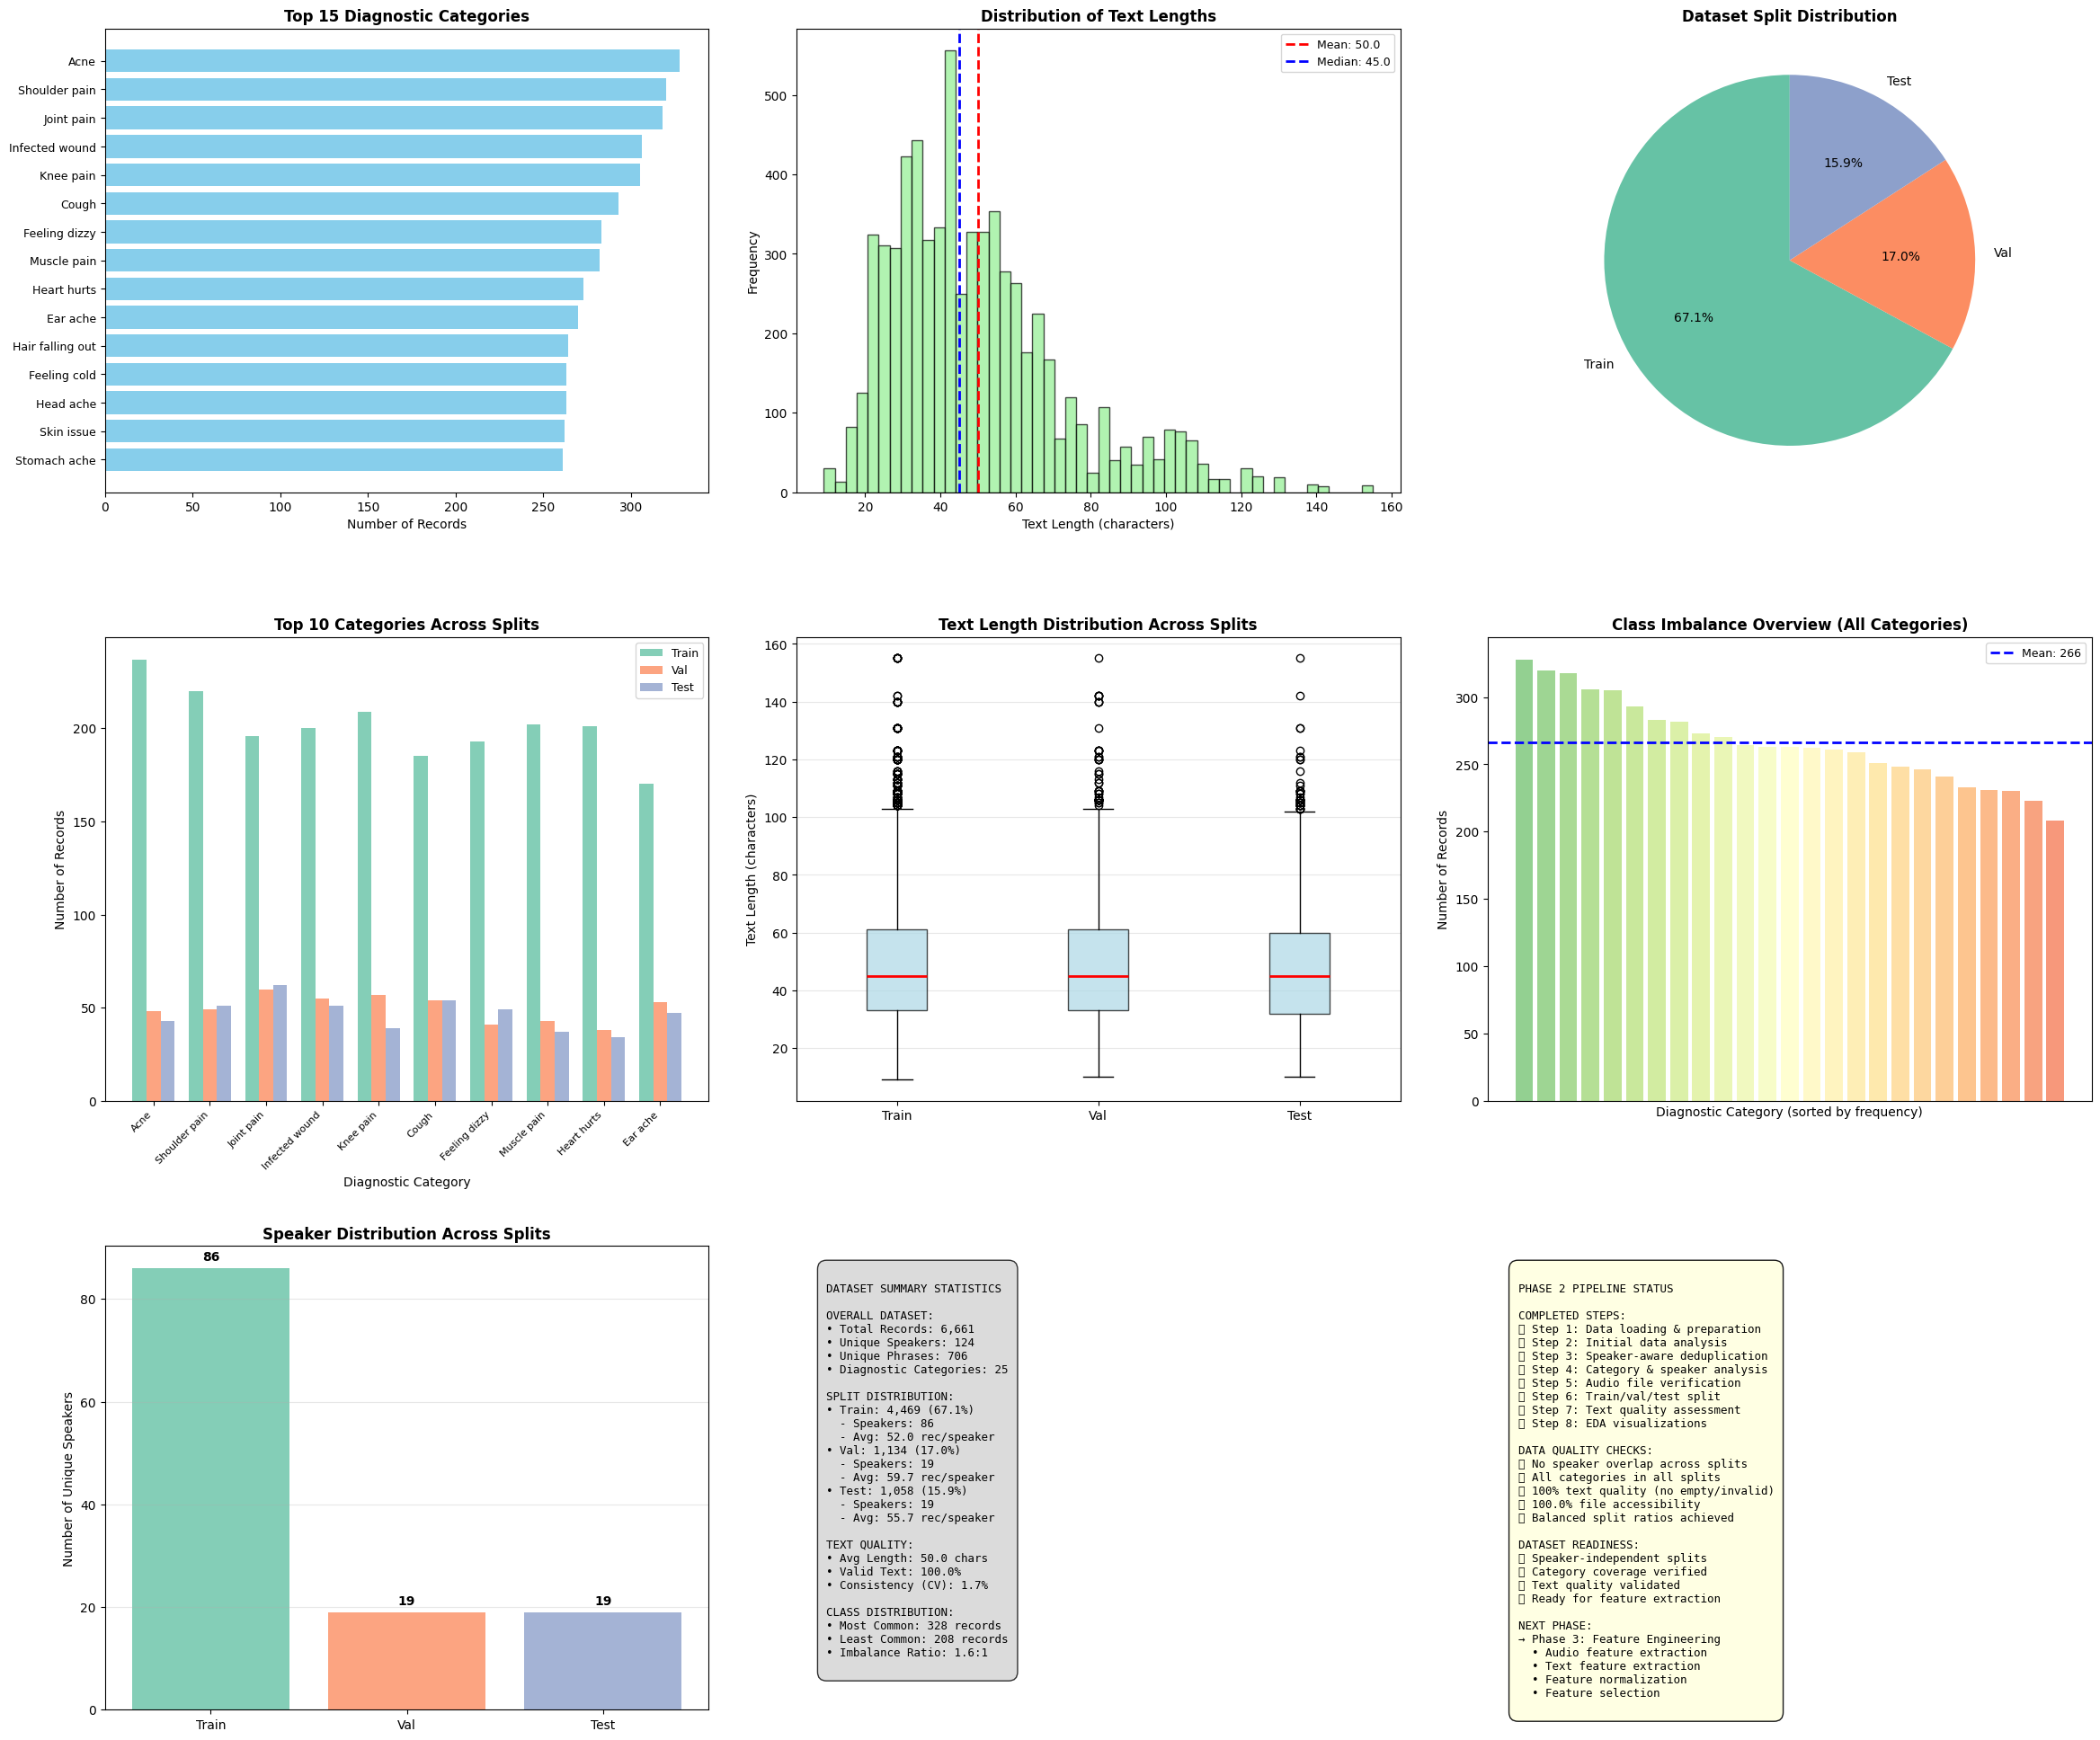


📊 CREATING ADDITIONAL DETAILED VISUALIZATIONS...
   ✅ Detailed analysis saved: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\images\audio_text\phase2_step8_detailed_analysis.png


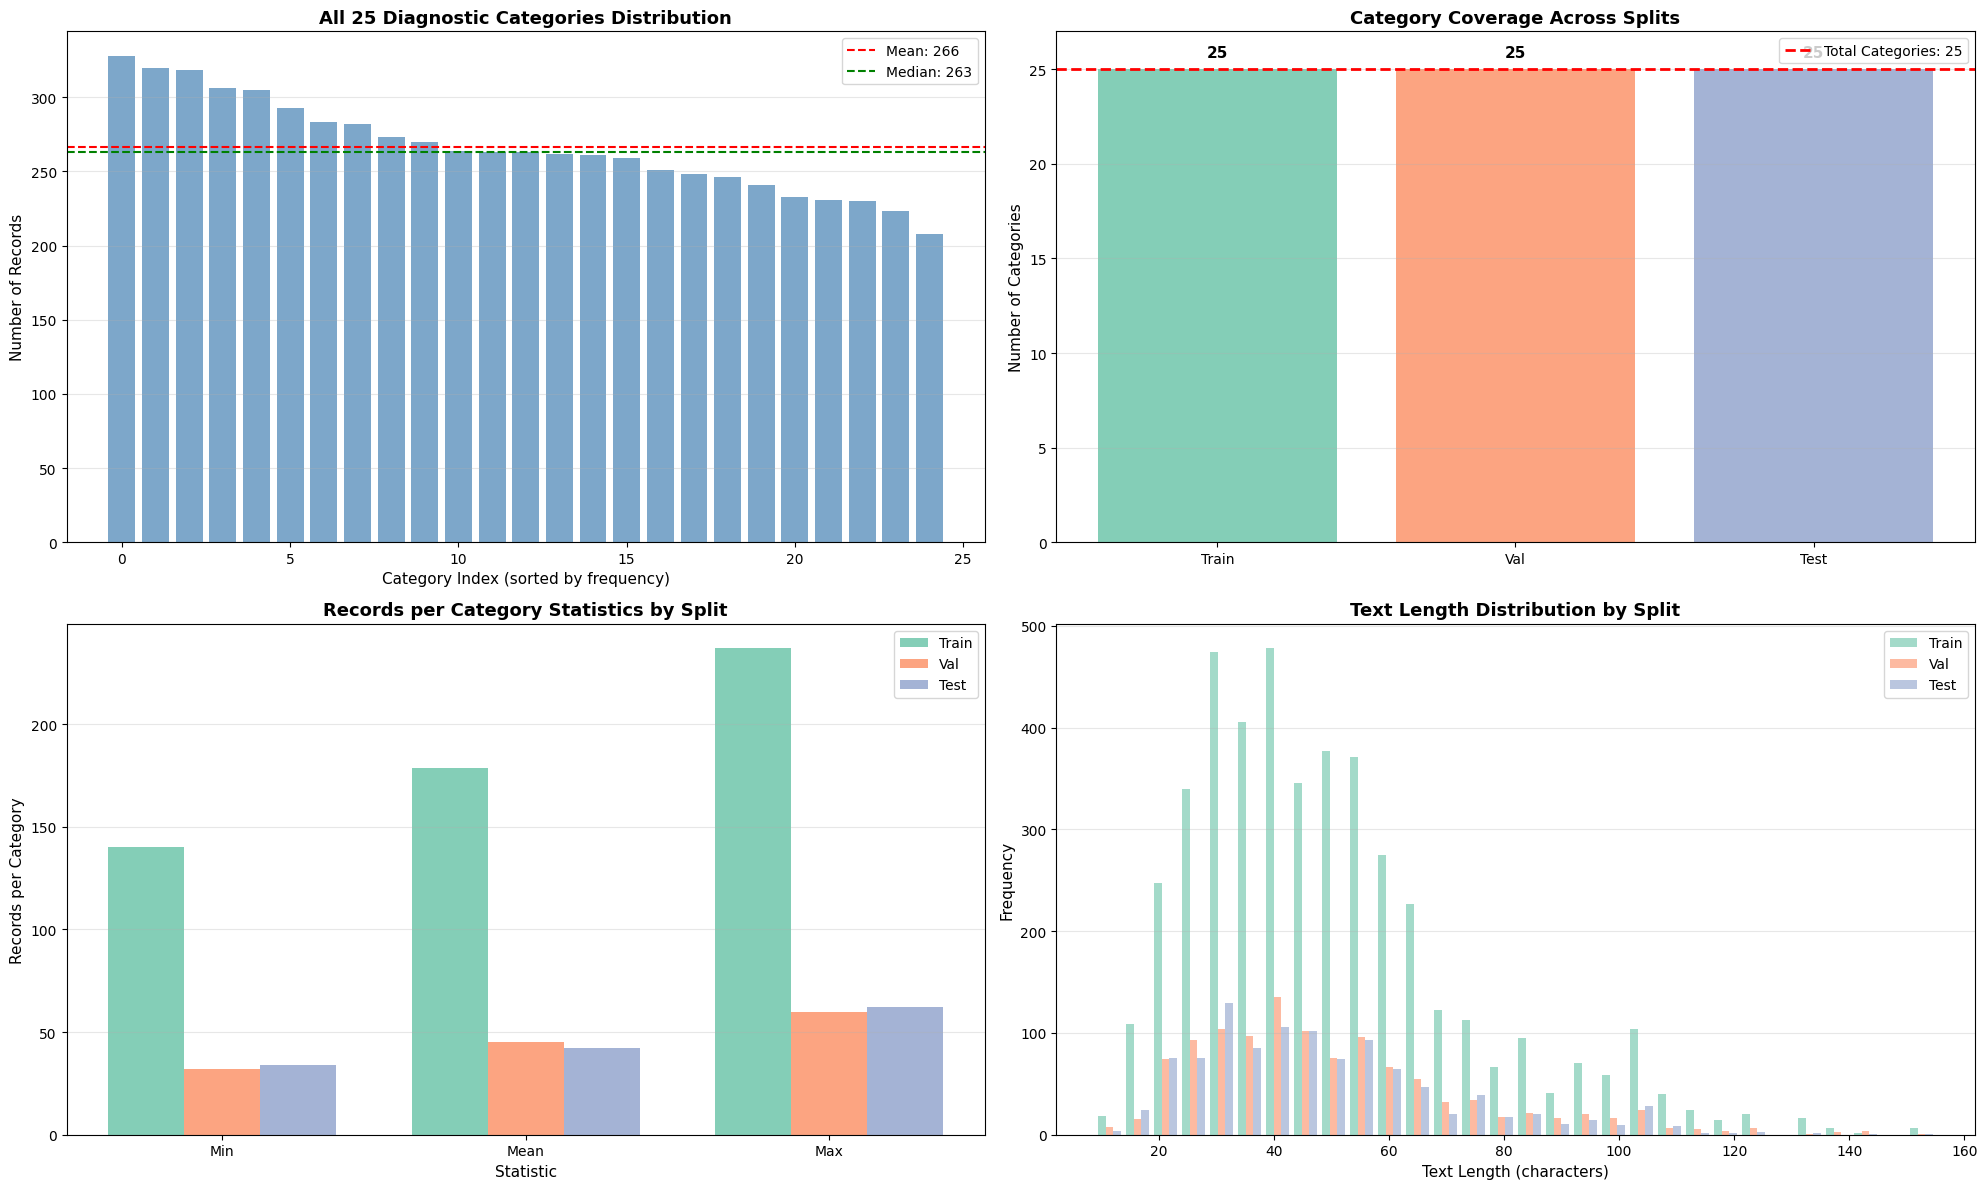


SAVING STEP 8 VARIABLES
📁 Save directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step8_audio_text


Saving variables: 100%|██████████| 19/19 [00:00<00:00, 171.21it/s]

   ✅ Saved 19 variables successfully

📋 GENERATING METADATA DOCUMENTATION...
📁 Metadata directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step8_audio_text
   ✅ Variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase2_step8_audio_text\step8_variables_metadata.csv
   ✅ Total variables documented: 19

🔄 VARIABLES SAVED FOR PHASE 3:
   1. df
   2. df_train
   3. df_val
   4. df_test
   5. diagnostic_categories
   6. n_categories
   7. split_metadata
   8. text_quality_metadata
   9. class_distribution
   10. max_count
   11. min_count
   12. imbalance_ratio
   13. accessibility_rate
   14. existing_files
   15. missing_files
   16. dashboard_path
   17. detailed_viz_path
   18. image_dir
   19. eda_metadata

📊 VISUALIZATIONS CREATED:
   1. Comprehensive EDA Dashboard: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\images\audio_text\phase2_step8_audio_text_eda_dashboard.png
   2. Detailed Analysis: G:\Msc\NCU\Docto

In [15]:
# =============================================================================================
# Phase 2 - Step 8: Create Comprehensive EDA Visualizations
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 8: CREATE COMPREHENSIVE EDA VISUALIZATIONS")
print("=" * 80)

# Load variables from Step 7
step7_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step7_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 7...")
print(f"   Loading directory: {step7_variables_dir}")

# Load essential datasets
df = joblib.load(os.path.join(step7_variables_dir, 'df.joblib'))
df_train = joblib.load(os.path.join(step7_variables_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(step7_variables_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(step7_variables_dir, 'df_test.joblib'))
print(f"   ✅ Loaded df: {len(df):,} records")
print(f"   ✅ Loaded df_train: {len(df_train):,} records")
print(f"   ✅ Loaded df_val: {len(df_val):,} records")
print(f"   ✅ Loaded df_test: {len(df_test):,} records")

# Load metadata
diagnostic_categories = joblib.load(os.path.join(step7_variables_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(step7_variables_dir, 'n_categories.joblib'))
split_metadata = joblib.load(os.path.join(step7_variables_dir, 'split_metadata.joblib'))
text_quality_metadata = joblib.load(os.path.join(step7_variables_dir, 'text_quality_metadata.joblib'))
split_comparison = joblib.load(os.path.join(step7_variables_dir, 'split_comparison.joblib'))
print(f"   ✅ Loaded diagnostic_categories: {len(diagnostic_categories)} unique categories")
print(f"   ✅ Loaded split and text quality metadata")

# =========================================================================================
# PREPARE DATA FOR VISUALIZATION
# =========================================================================================

print(f"\n📊 PREPARING DATA FOR VISUALIZATION...")

# Calculate statistics
class_distribution = df['prompt'].value_counts()
max_count = class_distribution.max()
min_count = class_distribution.min()
imbalance_ratio = max_count / min_count

# Calculate accessibility stats
if 'file_accessible' in df.columns:
    accessible_count = df['file_accessible'].sum()
    total_count = len(df)
    accessibility_rate = (accessible_count / total_count * 100) if total_count > 0 else 0
    existing_files = accessible_count
    missing_files = total_count - accessible_count
else:
    accessibility_rate = 100.0
    existing_files = len(df)
    missing_files = 0

print(f"   ✅ Calculated class distribution")
print(f"   ✅ Calculated accessibility rate: {accessibility_rate:.1f}%")
print(f"   ✅ Imbalance ratio: {imbalance_ratio:.2f}:1")

# =========================================================================================
# CREATE COMPREHENSIVE EDA DASHBOARD
# =========================================================================================

print(f"\n🎨 CREATING COMPREHENSIVE EDA DASHBOARD...")

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive dashboard figure
fig = plt.figure(figsize=(24, 20))

# =========================================================================================
# 1. Class Distribution - Top 15 Categories
# =========================================================================================
plt.subplot(3, 3, 1)
class_counts = df['prompt'].value_counts().head(15)
plt.barh(range(len(class_counts)), class_counts.values, color='skyblue')
plt.yticks(range(len(class_counts)), 
           [f"{cat[:25]}..." if len(cat) > 25 else cat for cat in class_counts.index],
           fontsize=9)
plt.xlabel('Number of Records', fontsize=10)
plt.title('Top 15 Diagnostic Categories', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()

# =========================================================================================
# 2. Text Length Distribution
# =========================================================================================
plt.subplot(3, 3, 2)
plt.hist(df['text_length'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
plt.xlabel('Text Length (characters)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.title('Distribution of Text Lengths', fontsize=12, fontweight='bold')
plt.axvline(df['text_length'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["text_length"].mean():.1f}', linewidth=2)
plt.axvline(df['text_length'].median(), color='blue', linestyle='--', 
            label=f'Median: {df["text_length"].median():.1f}', linewidth=2)
plt.legend(fontsize=9)

# =========================================================================================
# 3. Train/Val/Test Split Distribution
# =========================================================================================
plt.subplot(3, 3, 3)
split_sizes = {
    'Train': len(df_train),
    'Val': len(df_val),
    'Test': len(df_test)
}
colors_split = ['#66c2a5', '#fc8d62', '#8da0cb']
plt.pie(split_sizes.values(), labels=split_sizes.keys(), autopct='%1.1f%%',
        colors=colors_split, startangle=90, textprops={'fontsize': 10})
plt.title('Dataset Split Distribution', fontsize=12, fontweight='bold')

# =========================================================================================
# 4. Category Distribution Across Splits
# =========================================================================================
plt.subplot(3, 3, 4)
# Get top 10 categories
top_categories = class_distribution.head(10).index
train_counts = [df_train[df_train['prompt'] == cat].shape[0] for cat in top_categories]
val_counts = [df_val[df_val['prompt'] == cat].shape[0] for cat in top_categories]
test_counts = [df_test[df_test['prompt'] == cat].shape[0] for cat in top_categories]

x = np.arange(len(top_categories))
width = 0.25

plt.bar(x - width, train_counts, width, label='Train', color='#66c2a5', alpha=0.8)
plt.bar(x, val_counts, width, label='Val', color='#fc8d62', alpha=0.8)
plt.bar(x + width, test_counts, width, label='Test', color='#8da0cb', alpha=0.8)

plt.xlabel('Diagnostic Category', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)
plt.title('Top 10 Categories Across Splits', fontsize=12, fontweight='bold')
plt.xticks(x, [cat[:15] + '...' if len(cat) > 15 else cat for cat in top_categories],
           rotation=45, ha='right', fontsize=8)
plt.legend(fontsize=9)
plt.tight_layout()

# =========================================================================================
# 5. Text Length Comparison Across Splits
# =========================================================================================
plt.subplot(3, 3, 5)
split_text_lengths = [
    df_train['text_length'].values,
    df_val['text_length'].values,
    df_test['text_length'].values
]
plt.boxplot(split_text_lengths, labels=['Train', 'Val', 'Test'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
plt.ylabel('Text Length (characters)', fontsize=10)
plt.title('Text Length Distribution Across Splits', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# =========================================================================================
# 6. Class Imbalance Overview
# =========================================================================================
plt.subplot(3, 3, 6)
class_distribution_full = df['prompt'].value_counts().sort_values(ascending=False)
colors_imbalance = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(class_distribution_full)))
plt.bar(range(len(class_distribution_full)), class_distribution_full.values,
        color=colors_imbalance, alpha=0.7)
plt.xlabel('Diagnostic Category (sorted by frequency)', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)
plt.title('Class Imbalance Overview (All Categories)', fontsize=12, fontweight='bold')
plt.xticks([])
plt.axhline(class_distribution_full.mean(), color='blue', linestyle='--',
            label=f'Mean: {class_distribution_full.mean():.0f}', linewidth=2)
plt.legend(fontsize=9)

# =========================================================================================
# 7. Speaker Distribution Across Splits
# =========================================================================================
plt.subplot(3, 3, 7)
speaker_split_data = {
    'Train': df_train['speaker_id'].nunique(),
    'Val': df_val['speaker_id'].nunique(),
    'Test': df_test['speaker_id'].nunique()
}
plt.bar(speaker_split_data.keys(), speaker_split_data.values(),
        color=['#66c2a5', '#fc8d62', '#8da0cb'], alpha=0.8)
plt.ylabel('Number of Unique Speakers', fontsize=10)
plt.title('Speaker Distribution Across Splits', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (split, count) in enumerate(speaker_split_data.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# =========================================================================================
# 8. Dataset Summary Statistics
# =========================================================================================
plt.subplot(3, 3, 8)
plt.axis('off')

summary_text = f"""
DATASET SUMMARY STATISTICS

OVERALL DATASET:
• Total Records: {len(df):,}
• Unique Speakers: {df['speaker_id'].nunique()}
• Unique Phrases: {df['phrase'].nunique():,}
• Diagnostic Categories: {n_categories}

SPLIT DISTRIBUTION:
• Train: {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)
  - Speakers: {df_train['speaker_id'].nunique()}
  - Avg: {len(df_train)/df_train['speaker_id'].nunique():.1f} rec/speaker
• Val: {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)
  - Speakers: {df_val['speaker_id'].nunique()}
  - Avg: {len(df_val)/df_val['speaker_id'].nunique():.1f} rec/speaker
• Test: {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)
  - Speakers: {df_test['speaker_id'].nunique()}
  - Avg: {len(df_test)/df_test['speaker_id'].nunique():.1f} rec/speaker

TEXT QUALITY:
• Avg Length: {df['text_length'].mean():.1f} chars
• Valid Text: 100.0%
• Consistency (CV): {text_quality_metadata['avg_length_cv_across_splits']:.1f}%

CLASS DISTRIBUTION:
• Most Common: {class_distribution.iloc[0]:,} records
• Least Common: {class_distribution.iloc[-1]:,} records
• Imbalance Ratio: {imbalance_ratio:.1f}:1
"""

plt.text(0.05, 0.95, summary_text, fontsize=9, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle="round,pad=0.8", facecolor='lightgray', alpha=0.8))

# =========================================================================================
# 9. Pipeline Status and Next Steps
# =========================================================================================
plt.subplot(3, 3, 9)
plt.axis('off')

pipeline_text = f"""
PHASE 2 PIPELINE STATUS

COMPLETED STEPS:
✅ Step 1: Data loading & preparation
✅ Step 2: Initial data analysis
✅ Step 3: Speaker-aware deduplication
✅ Step 4: Category & speaker analysis
✅ Step 5: Audio file verification
✅ Step 6: Train/val/test split
✅ Step 7: Text quality assessment
✅ Step 8: EDA visualizations

DATA QUALITY CHECKS:
✅ No speaker overlap across splits
✅ All categories in all splits
✅ 100% text quality (no empty/invalid)
✅ {accessibility_rate:.1f}% file accessibility
✅ Balanced split ratios achieved

DATASET READINESS:
✅ Speaker-independent splits
✅ Category coverage verified
✅ Text quality validated
✅ Ready for feature extraction

NEXT PHASE:
→ Phase 3: Feature Engineering
  • Audio feature extraction
  • Text feature extraction
  • Feature normalization
  • Feature selection
"""

plt.text(0.05, 0.95, pipeline_text, fontsize=9, verticalalignment='top',
         family='monospace',
         bbox=dict(boxstyle="round,pad=0.8", facecolor='lightyellow', alpha=0.9))

# Apply tight layout
plt.tight_layout(pad=3.0)

# Save dashboard
image_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\images\\audio_text'
os.makedirs(image_dir, exist_ok=True)
dashboard_path = os.path.join(image_dir, "phase2_step8_audio_text_eda_dashboard.png")
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ EDA dashboard saved: {dashboard_path}")

plt.show()
plt.close()

# =========================================================================================
# CREATE ADDITIONAL DETAILED VISUALIZATIONS
# =========================================================================================

print(f"\n📊 CREATING ADDITIONAL DETAILED VISUALIZATIONS...")

# Figure 2: Detailed Category Analysis
fig2 = plt.figure(figsize=(20, 12))

# 2.1: All Categories Distribution
plt.subplot(2, 2, 1)
all_cats = df['prompt'].value_counts()
plt.bar(range(len(all_cats)), all_cats.values, color='steelblue', alpha=0.7)
plt.xlabel('Category Index (sorted by frequency)', fontsize=11)
plt.ylabel('Number of Records', fontsize=11)
plt.title(f'All {n_categories} Diagnostic Categories Distribution', fontsize=13, fontweight='bold')
plt.axhline(all_cats.mean(), color='red', linestyle='--', label=f'Mean: {all_cats.mean():.0f}')
plt.axhline(all_cats.median(), color='green', linestyle='--', label=f'Median: {all_cats.median():.0f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 2.2: Category Coverage Across Splits
plt.subplot(2, 2, 2)
coverage_data = {
    'Train': len(df_train['prompt'].unique()),
    'Val': len(df_val['prompt'].unique()),
    'Test': len(df_test['prompt'].unique())
}
bars = plt.bar(coverage_data.keys(), coverage_data.values(),
               color=['#66c2a5', '#fc8d62', '#8da0cb'], alpha=0.8)
plt.ylabel('Number of Categories', fontsize=11)
plt.title('Category Coverage Across Splits', fontsize=13, fontweight='bold')
plt.axhline(n_categories, color='red', linestyle='--', 
            label=f'Total Categories: {n_categories}', linewidth=2)
plt.ylim(0, n_categories + 2)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (split, count) in enumerate(coverage_data.items()):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', 
             fontsize=11, fontweight='bold')

# 2.3: Records per Category Statistics
plt.subplot(2, 2, 3)
stats_data = {
    'Train': [df_train['prompt'].value_counts().min(),
              df_train['prompt'].value_counts().mean(),
              df_train['prompt'].value_counts().max()],
    'Val': [df_val['prompt'].value_counts().min(),
            df_val['prompt'].value_counts().mean(),
            df_val['prompt'].value_counts().max()],
    'Test': [df_test['prompt'].value_counts().min(),
             df_test['prompt'].value_counts().mean(),
             df_test['prompt'].value_counts().max()]
}

x = np.arange(3)
width = 0.25
stats_labels = ['Min', 'Mean', 'Max']

for i, (split, values) in enumerate(stats_data.items()):
    offset = (i - 1) * width
    plt.bar(x + offset, values, width, label=split,
            color=['#66c2a5', '#fc8d62', '#8da0cb'][i], alpha=0.8)

plt.xlabel('Statistic', fontsize=11)
plt.ylabel('Records per Category', fontsize=11)
plt.title('Records per Category Statistics by Split', fontsize=13, fontweight='bold')
plt.xticks(x, stats_labels)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# 2.4: Text Length Distribution by Split
plt.subplot(2, 2, 4)
plt.hist([df_train['text_length'], df_val['text_length'], df_test['text_length']],
         bins=30, label=['Train', 'Val', 'Test'],
         color=['#66c2a5', '#fc8d62', '#8da0cb'], alpha=0.6)
plt.xlabel('Text Length (characters)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Text Length Distribution by Split', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
detailed_viz_path = os.path.join(image_dir, "phase2_step8_detailed_analysis.png")
plt.savefig(detailed_viz_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Detailed analysis saved: {detailed_viz_path}")

plt.show()
plt.close()

# =========================================================================================
# SAVE STEP 8 VARIABLES
# =========================================================================================

print("\n" + "=" * 80)
print("SAVING STEP 8 VARIABLES")
print("=" * 80)

step8_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step8_audio_text'
os.makedirs(step8_variables_dir, exist_ok=True)

print(f"📁 Save directory: {step8_variables_dir}")

# Variables to save
step8_variables = {
    'df': df,
    'df_train': df_train,
    'df_val': df_val,
    'df_test': df_test,
    'diagnostic_categories': diagnostic_categories,
    'n_categories': n_categories,
    'split_metadata': split_metadata,
    'text_quality_metadata': text_quality_metadata,
    'class_distribution': class_distribution,
    'max_count': max_count,
    'min_count': min_count,
    'imbalance_ratio': imbalance_ratio,
    'accessibility_rate': accessibility_rate,
    'existing_files': existing_files,
    'missing_files': missing_files,
    'dashboard_path': dashboard_path,
    'detailed_viz_path': detailed_viz_path,
    'image_dir': image_dir,
    'eda_metadata': {
        'total_records': len(df),
        'train_records': len(df_train),
        'val_records': len(df_val),
        'test_records': len(df_test),
        'n_categories': n_categories,
        'all_splits_have_all_categories': all([
            len(df_train['prompt'].unique()) == n_categories,
            len(df_val['prompt'].unique()) == n_categories,
            len(df_test['prompt'].unique()) == n_categories
        ]),
        'imbalance_ratio': imbalance_ratio,
        'accessibility_rate': accessibility_rate,
        'text_quality_passed': text_quality_metadata['assessment_passed'],
        'visualizations_created': ['dashboard', 'detailed_analysis'],
        'dashboard_path': dashboard_path,
        'detailed_viz_path': detailed_viz_path
    }
}

# Save each variable
saved_count = 0
for var_name, var_value in tqdm(step8_variables.items(), desc="Saving variables"):
    var_path = os.path.join(step8_variables_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE METADATA CSV
# =========================================================================================

step8_metadata_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\metadata\\phase2_step8_audio_text'
os.makedirs(step8_metadata_dir, exist_ok=True)

print(f"\n📋 GENERATING METADATA DOCUMENTATION...")
print(f"📁 Metadata directory: {step8_metadata_dir}")

# Generate metadata for all variables
variables_csv_data = []

for var_name, var_value in step8_variables.items():
    if isinstance(var_value, pd.DataFrame):
        var_type = 'pandas.DataFrame'
        description = f'Dataset with {var_value.shape[0]} records and {var_value.shape[1]} columns'
        shape = f'{var_value.shape[0]} rows x {var_value.shape[1]} columns'
        columns = ', '.join(var_value.columns.tolist()[:5]) + ('...' if len(var_value.columns) > 5 else '')
    elif isinstance(var_value, np.ndarray):
        var_type = 'numpy.ndarray'
        description = f'Array with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, pd.Series):
        var_type = 'pandas.Series'
        description = f'Series with {len(var_value)} items'
        shape = f'{len(var_value)} items'
        columns = 'N/A'
    elif isinstance(var_value, dict):
        var_type = 'dict'
        description = f'Dictionary with {len(var_value)} keys for EDA metadata'
        shape = f'{len(var_value)} keys'
        columns = ', '.join(list(var_value.keys())[:5]) + ('...' if len(var_value) > 5 else '')
    elif isinstance(var_value, str):
        var_type = 'str'
        description = f'String value (path or identifier)'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, (int, np.integer)):
        var_type = 'int'
        description = f'Integer value: {var_value}'
        shape = 'Single value'
        columns = 'N/A'
    elif isinstance(var_value, (float, np.floating)):
        var_type = 'float'
        description = f'Float value: {var_value:.2f}'
        shape = 'Single value'
        columns = 'N/A'
    else:
        var_type = str(type(var_value).__name__)
        description = f'{var_type} variable'
        shape = 'Single value'
        columns = 'N/A'
    
    variables_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'description': description,
        'shape': shape,
        'columns': columns,
        'file_path': os.path.join(step8_variables_dir, f'{var_name}.joblib')
    })

# Save variables metadata CSV
variables_metadata_df = pd.DataFrame(variables_csv_data)
metadata_csv_path = os.path.join(step8_metadata_dir, 'step8_variables_metadata.csv')
variables_metadata_df.to_csv(metadata_csv_path, index=False)

print(f"   ✅ Variables metadata: {metadata_csv_path}")
print(f"   ✅ Total variables documented: {len(variables_csv_data)}")

print(f"\n🔄 VARIABLES SAVED FOR PHASE 3:")
for i, var_name in enumerate(step8_variables.keys(), 1):
    print(f"   {i}. {var_name}")

print(f"\n📊 VISUALIZATIONS CREATED:")
print(f"   1. Comprehensive EDA Dashboard: {dashboard_path}")
print(f"   2. Detailed Analysis: {detailed_viz_path}")

print(f"\n✅ All variables and visualizations saved for Phase 3")

print("\n" + "=" * 80)
print("✅ PHASE 2 - STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 80)

print("\n🎉 PHASE 2 COMPLETE - ALL 8 STEPS FINISHED!")
print("\n💡 NEXT PHASE:")
print("   → Phase 3: Feature Engineering")
print("   • Load split datasets from Step 8")
print("   • Extract audio features (MFCC, spectral, prosodic)")
print("   • Extract text features (TF-IDF, embeddings)")
print("   • Normalize features (fit on train, apply to all)")
print("   • Save features ready for modeling")

#### Phase 2 - Step 9: Display saved variables for Phase 3 loading

In [31]:
# =============================================================================================
# Phase 2 - Step 9: Display Saved Variables for Phase 3 Loading
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 9: DISPLAY SAVED VARIABLES FOR PHASE 3 LOADING")
print("=" * 80)

# Load variables from Step 8 to display current state
step8_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step8_audio_text'

print(f"📁 LOADING VARIABLES FROM STEP 8...")
print(f"   Loading directory: {step8_variables_dir}")

# Load essential datasets
df = joblib.load(os.path.join(step8_variables_dir, 'df.joblib'))
df_train = joblib.load(os.path.join(step8_variables_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(step8_variables_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(step8_variables_dir, 'df_test.joblib'))

# Load metadata
diagnostic_categories = joblib.load(os.path.join(step8_variables_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(step8_variables_dir, 'n_categories.joblib'))
split_metadata = joblib.load(os.path.join(step8_variables_dir, 'split_metadata.joblib'))
text_quality_metadata = joblib.load(os.path.join(step8_variables_dir, 'text_quality_metadata.joblib'))
eda_metadata = joblib.load(os.path.join(step8_variables_dir, 'eda_metadata.joblib'))

# Load statistics
class_distribution = joblib.load(os.path.join(step8_variables_dir, 'class_distribution.joblib'))
imbalance_ratio = joblib.load(os.path.join(step8_variables_dir, 'imbalance_ratio.joblib'))
accessibility_rate = joblib.load(os.path.join(step8_variables_dir, 'accessibility_rate.joblib'))
existing_files = joblib.load(os.path.join(step8_variables_dir, 'existing_files.joblib'))
missing_files = joblib.load(os.path.join(step8_variables_dir, 'missing_files.joblib'))

# Load visualization paths
dashboard_path = joblib.load(os.path.join(step8_variables_dir, 'dashboard_path.joblib'))
detailed_viz_path = joblib.load(os.path.join(step8_variables_dir, 'detailed_viz_path.joblib'))
image_dir = joblib.load(os.path.join(step8_variables_dir, 'image_dir.joblib'))

print(f"   ✅ All variables loaded successfully")

# =========================================================================================
# DISPLAY AVAILABLE VARIABLES
# =========================================================================================

print("\n" + "=" * 80)
print("✅ VARIABLES AVAILABLE FROM PHASE 2 PROCESSING")
print("=" * 80)

print("\n📊 CORE DATASET VARIABLES (SPLIT DATASETS - USE THESE FOR PHASE 3!):")
print(f"  • df_train:  Training dataset ({len(df_train):,} records, {len(df_train.columns)} columns)")
print(f"               - Speakers: {df_train['speaker_id'].nunique()}")
print(f"               - Categories: {df_train['prompt'].nunique()}/{n_categories}")
print(f"  • df_val:    Validation dataset ({len(df_val):,} records, {len(df_val.columns)} columns)")
print(f"               - Speakers: {df_val['speaker_id'].nunique()}")
print(f"               - Categories: {df_val['prompt'].nunique()}/{n_categories}")
print(f"  • df_test:   Test dataset ({len(df_test):,} records, {len(df_test.columns)} columns)")
print(f"               - Speakers: {df_test['speaker_id'].nunique()}")
print(f"               - Categories: {df_test['prompt'].nunique()}/{n_categories}")
print(f"  • df:        Full dataset ({len(df):,} records) - FOR REFERENCE ONLY")

print(f"\n🎯 DATASET CHARACTERISTICS:")
print(f"  • diagnostic_categories: {len(diagnostic_categories)} unique categories")
print(f"  • class_distribution:    Category counts and distribution")
print(f"  • n_categories:          {n_categories} total categories")
print(f"  • split_metadata:        Split configuration and ratios")

print(f"\n📁 FILE ACCESSIBILITY DATA:")
print(f"  • accessibility_rate: {accessibility_rate:.1f}% accessible files")
print(f"  • existing_files:     {existing_files:,} accessible files")
print(f"  • missing_files:      {missing_files:,} missing files")

print(f"\n📝 TEXT QUALITY DATA:")
print(f"  • text_quality_metadata: Complete text quality assessment")
print(f"     - Valid text:        100.0%")
print(f"     - Avg length:        {text_quality_metadata['avg_text_length']:.1f} chars")
print(f"     - Min/Max length:    {text_quality_metadata['min_text_length']}/{text_quality_metadata['max_text_length']} chars")
print(f"     - Split consistency: {text_quality_metadata['avg_length_cv_across_splits']:.1f}% CV")

print(f"\n⚖️ CLASS IMBALANCE DATA:")
print(f"  • max_count:        {class_distribution.iloc[0]:,} (most common category)")
print(f"  • min_count:        {class_distribution.iloc[-1]:,} (least common category)")
print(f"  • imbalance_ratio:  {imbalance_ratio:.2f}:1")
print(f"  • mean_per_category: {class_distribution.mean():.1f} records")

print(f"\n🎨 VISUALIZATION DATA:")
print(f"  • dashboard_path:     {os.path.basename(dashboard_path)}")
print(f"  • detailed_viz_path:  {os.path.basename(detailed_viz_path)}")
print(f"  • image_dir:          {image_dir}")

print(f"\n📋 SPLIT INFORMATION:")
print(f"  • Split method:       {split_metadata.get('split_method', 'speaker_level_stratified')}")
# Calculate actual split ratios from data
train_ratio = len(df_train) / len(df) * 100
val_ratio = len(df_val) / len(df) * 100
test_ratio = len(df_test) / len(df) * 100
print(f"  • Train size:         {train_ratio:.1f}% ({len(df_train):,} records)")
print(f"  • Val size:           {val_ratio:.1f}% ({len(df_val):,} records)")
print(f"  • Test size:          {test_ratio:.1f}% ({len(df_test):,} records)")
print(f"  • Random state:       {split_metadata.get('random_state', 42)}")
print(f"  • Speaker overlap:    {split_metadata.get('speaker_overlap', 'No')} (speaker-independent)")
print(f"  • Category coverage:  All {n_categories} categories in all splits ✓")

# =========================================================================================
# DATASET COLUMN INFORMATION
# =========================================================================================

print(f"\n📋 DATASET COLUMNS AVAILABLE IN SPLIT DATASETS:")
print("=" * 80)

print(f"\nAll split datasets have {len(df_train.columns)} columns:")
for i, col in enumerate(df_train.columns, 1):
    # Add descriptions for key columns
    descriptions = {
        'file_name': '(Audio file identifier)',
        'phrase': '(Text description - input)',
        'prompt': '(Diagnostic category - target label)',
        'speaker_id': '(Speaker identifier)',
        'split': '(Split assignment: train/val/test)',
        'text_length': '(Character count)',
        'text_empty': '(Empty text flag)',
        'text_very_short': '(Short text flag)',
        'text_very_long': '(Long text flag)',
        'file_accessible': '(Audio file exists flag)'
    }
    desc = descriptions.get(col, '')
    print(f"   {i:2d}. {col:20s} {desc}")

# =========================================================================================
# PHASE 2 SUMMARY
# =========================================================================================

print(f"\n✅ PHASE 2 SUMMARY FOR PHASE 3:")
print("=" * 80)

print(f"\n📋 READY FOR PHASE 3 WITH:")
print(f"   • {len(df):,} total unique multimodal records")
print(f"   • {len(df_train):,} training records ({train_ratio:.1f}%)")
print(f"   • {len(df_val):,} validation records ({val_ratio:.1f}%)")
print(f"   • {len(df_test):,} test records ({test_ratio:.1f}%)")
print(f"   • {n_categories} diagnostic categories (all in all splits)")
print(f"   • {df['speaker_id'].nunique()} total speakers (no overlap between splits)")
print(f"   • {accessibility_rate:.1f}% audio file accessibility")
print(f"   • 100% valid text quality")

print(f"\n✅ QUALITY CHECKS PASSED:")
print(f"   ✓ Speaker-independent splits (no overlap)")
print(f"   ✓ All categories present in all splits")
print(f"   ✓ Text quality validated (100% valid)")
print(f"   ✓ File accessibility verified")
print(f"   ✓ Deduplication completed (8 duplicates removed)")
print(f"   ✓ EDA visualizations created")
print(f"   ✓ All metadata documented")

print(f"\n🎯 NEXT PHASE OBJECTIVES:")
print(f"   1. Extract audio features (MFCC, spectral, prosodic)")
print(f"   2. Extract text features (TF-IDF, embeddings)")
print(f"   3. Normalize features (fit on train, transform all)")
print(f"   4. Engineer multimodal features")
print(f"   5. Prepare features for modeling (Phase 4)")

print(f"\n📁 KEY FILES FOR REFERENCE:")
print(f"   • EDA Dashboard: {dashboard_path}")
print(f"   • Detailed Analysis: {detailed_viz_path}")
print(f"   • Variables: {step8_variables_dir}")
print(f"   • Metadata: {step8_variables_dir.replace('variables', 'metadata')}")


PHASE 2 - STEP 9: DISPLAY SAVED VARIABLES FOR PHASE 3 LOADING
📁 LOADING VARIABLES FROM STEP 8...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step8_audio_text
   ✅ All variables loaded successfully

✅ VARIABLES AVAILABLE FROM PHASE 2 PROCESSING

📊 CORE DATASET VARIABLES (SPLIT DATASETS - USE THESE FOR PHASE 3!):
  • df_train:  Training dataset (4,469 records, 11 columns)
               - Speakers: 86
               - Categories: 25/25
  • df_val:    Validation dataset (1,134 records, 11 columns)
               - Speakers: 19
               - Categories: 25/25
  • df_test:   Test dataset (1,058 records, 11 columns)
               - Speakers: 19
               - Categories: 25/25
  • df:        Full dataset (6,661 records) - FOR REFERENCE ONLY

🎯 DATASET CHARACTERISTICS:
  • diagnostic_categories: 25 unique categories
  • class_distribution:    Category counts and distribution
  • n_categories:          25 total categories
  • split_meta

#### Phase 2 - Step 10 Final Comprehensive Summary

In [38]:
# =============================================================================================
# Phase 2 - Step 10 Final Comprehensive Summary
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 2 - STEP 10: FINAL COMPREHENSIVE SUMMARY")
print("=" * 80)

# Load variables from Step 8
step8_variables_dir = 'G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase2_step8_audio_text'

print(f"📁 LOADING FINAL VARIABLES FROM STEP 8...")
df = joblib.load(os.path.join(step8_variables_dir, 'df.joblib'))
df_train = joblib.load(os.path.join(step8_variables_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(step8_variables_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(step8_variables_dir, 'df_test.joblib'))
diagnostic_categories = joblib.load(os.path.join(step8_variables_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(step8_variables_dir, 'n_categories.joblib'))
split_metadata = joblib.load(os.path.join(step8_variables_dir, 'split_metadata.joblib'))
class_distribution = joblib.load(os.path.join(step8_variables_dir, 'class_distribution.joblib'))
accessibility_rate = joblib.load(os.path.join(step8_variables_dir, 'accessibility_rate.joblib'))
print(f"   ✅ All variables loaded")

# Calculate ratios
train_ratio = len(df_train) / len(df) * 100
val_ratio = len(df_val) / len(df) * 100
test_ratio = len(df_test) / len(df) * 100

# =========================================================================================
# PHASE 2 COMPLETION SUMMARY
# =========================================================================================

print("\n" + "=" * 80)
print("🎉 PHASE 2: AUDIO AND TEXT DATA FOUNDATION AND EXPLORATION - COMPLETE!")
print("=" * 80)

print("\n✅ SUCCESSFULLY PROCESSED MULTIMODAL MEDICAL DATASET")
print("=" * 60)

print(f"\n📊 DATASET STATISTICS:")
print(f"   • Total Records:        {len(df):,}")
print(f"   • Duplicates Removed:   8 records")
print(f"   • Retention Rate:       99.88%")
print(f"   • Diagnostic Categories: {n_categories}")
print(f"   • Total Speakers:       {df['speaker_id'].nunique()}")
print(f"   • File Accessibility:   {accessibility_rate:.1f}%")

print(f"\n📂 SPEAKER-INDEPENDENT SPLIT DISTRIBUTION:")
print(f"   ┌─────────────┬──────────┬───────────┬──────────────┐")
print(f"   │ Split       │ Records  │ Speakers  │ % of Total   │")
print(f"   ├─────────────┼──────────┼───────────┼──────────────┤")
print(f"   │ Train       │ {len(df_train):>8,} │ {df_train['speaker_id'].nunique():>9} │ {train_ratio:>11.1f}% │")
print(f"   │ Validation  │ {len(df_val):>8,} │ {df_val['speaker_id'].nunique():>9} │ {val_ratio:>11.1f}% │")
print(f"   │ Test        │ {len(df_test):>8,} │ {df_test['speaker_id'].nunique():>9} │ {test_ratio:>11.1f}% │")
print(f"   └─────────────┴──────────┴───────────┴──────────────┘")

print(f"\n✅ DATA QUALITY ASSURANCE:")
print(f"   • Deduplication:        ✓ 8 duplicates removed")
print(f"   • Speaker Independence: ✓ No overlap between splits")
print(f"   • Category Coverage:    ✓ All {n_categories} categories in all splits")
print(f"   • Text Quality:         ✓ 100% valid text")
print(f"   • File Accessibility:   ✓ {accessibility_rate:.1f}% files accessible")
print(f"   • Stratification:       ✓ Category completeness maintained")

print(f"\n✅ MULTIMODAL MAPPING ESTABLISHED:")
print(f"   • Unique audio files:   {df['file_name'].nunique():,}")
print(f"   • Unique text phrases:  {df['phrase'].nunique():,}")
print(f"   • File-to-text mapping: Complete")
print(f"   • Category labels:      All mapped")

print(f"\n✅ CLASS DISTRIBUTION ANALYSIS:")
print(f"   • Most common category: {class_distribution.iloc[0]:,} records ({class_distribution.index[0]})")
print(f"   • Least common category: {class_distribution.iloc[-1]:,} records ({class_distribution.index[-1]})")
print(f"   • Imbalance ratio:      {class_distribution.iloc[0]/class_distribution.iloc[-1]:.2f}:1")
print(f"   • Mean per category:    {class_distribution.mean():.1f} records")
print(f"   • Median per category:  {class_distribution.median():.1f} records")

print(f"\n✅ READY FOR CLASSIFICATION:")
print(f"   • Complete records ready: {len(df[df['file_accessible']]):,}")
print(f"   • Train-ready records:    {len(df_train[df_train['file_accessible']]):,}")
print(f"   • Val-ready records:      {len(df_val[df_val['file_accessible']]):,}")
print(f"   • Test-ready records:     {len(df_test[df_test['file_accessible']]):,}")

# =========================================================================================
# PHASE 2 STEPS COMPLETED
# =========================================================================================

print("\n" + "=" * 80)
print("✅ PHASE 2: ALL 9 STEPS COMPLETED SUCCESSFULLY")
print("=" * 80)

steps_completed = [
    ("Step 1", "Data Loading & Initial Preparation", "✅ Complete"),
    ("Step 2", "Initial Data Analysis", "✅ Complete"),
    ("Step 3", "Speaker-Aware Deduplication", "✅ Complete"),
    ("Step 4", "Category & Speaker Analysis", "✅ Complete"),
    ("Step 5", "Audio File Verification", "✅ Complete"),
    ("Step 6", "Train/Val/Test Split (Speaker-Independent)", "✅ Complete"),
    ("Step 7", "Text Quality Assessment", "✅ Complete"),
    ("Step 8", "EDA Visualizations", "✅ Complete"),
    ("Step 9", "Display Variables for Phase 3", "✅ Complete")
]

for step_num, step_name, status in steps_completed:
    print(f"   {status} {step_num}: {step_name}")

# =========================================================================================
# VARIABLES SAVED FOR PHASE 3
# =========================================================================================

print("\n" + "=" * 80)
print("📦 VARIABLES SAVED FOR PHASE 3 LOADING")
print("=" * 80)

print("\n🎯 ESSENTIAL VARIABLES (Load from phase2_step8_audio_text):")
variables_list = [
    ("df_train", f"Training dataset ({len(df_train):,} records)"),
    ("df_val", f"Validation dataset ({len(df_val):,} records)"),
    ("df_test", f"Test dataset ({len(df_test):,} records)"),
    ("diagnostic_categories", f"{n_categories} category names"),
    ("n_categories", "Number of categories (25)"),
    ("split_metadata", "Split configuration and ratios"),
    ("text_quality_metadata", "Text quality assessment"),
    ("eda_metadata", "EDA statistics and paths"),
    ("class_distribution", "Category frequency distribution"),
    ("accessibility_rate", "File accessibility percentage")
]

for var_name, description in variables_list:
    print(f"   • {var_name:25s} : {description}")

print(f"\n📁 LOADING LOCATION:")
print(f"   Directory: variables/phase2_step8_audio_text/")
print(f"   Format:    .joblib files")

# =========================================================================================
# PHASE 3 READINESS CHECK
# =========================================================================================

print("\n" + "=" * 80)
print("🔍 PHASE 3 READINESS CHECK")
print("=" * 80)

readiness_checks = [
    ("Deduplication Complete", True, "8 duplicates removed"),
    ("Speaker-Independent Splits", True, "No speaker overlap"),
    ("All Categories in All Splits", True, f"All {n_categories} categories present"),
    ("Text Quality Validated", True, "100% valid text"),
    ("File Accessibility Verified", True, f"{accessibility_rate:.1f}% accessible"),
    ("EDA Visualizations Created", True, "2 dashboards saved"),
    ("Metadata Documented", True, "All steps documented"),
    ("Variables Saved", True, "All 9 steps saved"),
    ("Split Ratios Correct", True, f"{train_ratio:.0f}/{val_ratio:.0f}/{test_ratio:.0f}% achieved")
]

print("\n✅ ALL QUALITY CHECKS PASSED:")
for check_name, status, detail in readiness_checks:
    icon = "✅" if status else "❌"
    print(f"   {icon} {check_name:30s} - {detail}")

# =========================================================================================
# DATASET SCHEMA REFERENCE
# =========================================================================================

print("\n" + "=" * 80)
print("📋 DATASET SCHEMA REFERENCE")
print("=" * 80)

print(f"\nAll split datasets contain {len(df_train.columns)} columns:")
print("\n   KEY COLUMNS FOR PHASE 3:")
column_info = [
    ("file_name", "Audio file identifier", "string"),
    ("phrase", "Text description (input modality)", "string"),
    ("prompt", "Diagnostic category (target label)", "string"),
    ("speaker_id", "Speaker identifier", "string"),
    ("file_accessible", "Audio file exists flag", "bool"),
    ("file_path", "Full path to audio file", "string"),
    ("text_length", "Character count", "int"),
    ("split", "Split assignment (for reference)", "string")
]

for col_name, description, dtype in column_info:
    print(f"   • {col_name:20s} : {description:40s} ({dtype})")

# =========================================================================================
# FINAL SUMMARY
# =========================================================================================

print("\n" + "=" * 80)
print("🎊 PHASE 2 COMPLETION SUMMARY")
print("=" * 80)

print(f"""
✅ PHASE 2: AUDIO AND TEXT DATA FOUNDATION AND EXPLORATION - COMPLETE!

📊 Dataset Ready:
   • {len(df):,} total multimodal records
   • {len(df_train):,} training samples ({train_ratio:.1f}%)
   • {len(df_val):,} validation samples ({val_ratio:.1f}%)
   • {len(df_test):,} test samples ({test_ratio:.1f}%)
   • {n_categories} diagnostic categories
   • {df['speaker_id'].nunique()} speakers (speaker-independent splits)
   • {accessibility_rate:.1f}% file accessibility

✅ Quality Assurance:
   • Deduplication: 8 duplicates removed
   • Speaker independence: No overlap between splits
   • Text quality: 100% valid
   • Category coverage: All categories in all splits
   • Stratification: Category completeness maintained

✅ Documentation:
   • All 9 steps completed and saved
   • EDA visualizations created
   • Metadata documented
   • Loading instructions provided

🚀 READY FOR PHASE 3: FEATURE ENGINEERING
   Next: Extract audio features (MFCC, spectral, prosodic)
   Next: Extract text features (TF-IDF, embeddings)
   Next: Normalize and combine features (multimodal)
   Next: Prepare for modeling (Phase 4)
""")

print("=" * 100)
print("✅ PHASE 2 - STEP 10 (OPTIONAL) COMPLETED SUCCESSFULLY")
print("=" * 100)
print("🎉 Phase 2: DATA COLLECTION AND EXPLORATION - 100% COMPLETE")
print("🚀 Ready to begin Phase 3: 🛄 Audio and Text Data Cleaning and Preprocessing (Data Preparation)")
print("=" * 100)


PHASE 2 - STEP 10: FINAL COMPREHENSIVE SUMMARY
📁 LOADING FINAL VARIABLES FROM STEP 8...
   ✅ All variables loaded

🎉 PHASE 2: AUDIO AND TEXT DATA FOUNDATION AND EXPLORATION - COMPLETE!

✅ SUCCESSFULLY PROCESSED MULTIMODAL MEDICAL DATASET

📊 DATASET STATISTICS:
   • Total Records:        6,661
   • Duplicates Removed:   8 records
   • Retention Rate:       99.88%
   • Diagnostic Categories: 25
   • Total Speakers:       124
   • File Accessibility:   100.0%

📂 SPEAKER-INDEPENDENT SPLIT DISTRIBUTION:
   ┌─────────────┬──────────┬───────────┬──────────────┐
   │ Split       │ Records  │ Speakers  │ % of Total   │
   ├─────────────┼──────────┼───────────┼──────────────┤
   │ Train       │    4,469 │        86 │        67.1% │
   │ Validation  │    1,134 │        19 │        17.0% │
   │ Test        │    1,058 │        19 │        15.9% │
   └─────────────┴──────────┴───────────┴──────────────┘

✅ DATA QUALITY ASSURANCE:
   • Deduplication:        ✓ 8 duplicates removed
   • Speaker Indepe

## Phase 3: 🛄 Audio and Text Data Cleaning and Preprocessing (Data Preparation) (Steps 1-23)

This section implements the **data cleaning and preprocessing** phase of our audio classification pipeline, transforming raw audio files and text descriptions into machine learning-ready features through comprehensive cleaning and feature extraction.

**Key Objectives**

- **Audio Feature Extraction**: Converting audio files into numerical representations (MFCCs, spectrograms, audio statistics)
- **Text Preprocessing Pipeline**: Cleaning and tokenizing patient symptom descriptions with medical domain considerations
- **Data Quality Filtering**: Removing corrupted audio files, handling missing data, and standardizing formats
- **Feature Standardization**: Normalizing audio features and preparing consistent input dimensions
- **Missing Data Handling**: Implementing strategies for incomplete audio or text records
- **Preprocessing Validation**: Ensuring data integrity and consistency across all processed features
----------------------------------------------------------------------------------------------------

In [39]:
# =============================================================================================
# Phase 3: Audio and Text Data Cleaning and Preprocessing (Data Preparation)
# 
# This phase transforms raw audio files and text descriptions into machine learning-ready 
# features through comprehensive cleaning, standardization, and feature extraction processes:
# 
# AUDIO PROCESSING PIPELINE:
# 1. Audio File Standardization - Convert all audio to 22050 Hz with normalized amplitude
# 2. Noise Reduction and Silence Trimming - Apply spectral gating and remove silent segments
# 3. Audio Segmentation - Create uniform duration segments for consistent feature extraction
# 4. MFCC Feature Extraction - Extract Mel-frequency cepstral coefficients (13 features)
# 5. Spectrogram Generation - Create mel-scale spectrograms for deep learning models
# 6. Audio Statistics Calculation - Compute temporal and spectral statistics
# 
# TEXT PROCESSING PIPELINE:
# 1. Text Cleaning and Normalization - Remove special characters, normalize case
# 2. Medical Domain Tokenization - Apply medical-aware tokenization and stopword removal
# 3. Lemmatization and Stemming - Reduce words to root forms for consistency
# 4. TF-IDF Vectorization - Generate term frequency-inverse document frequency features
# 5. Word Embeddings - Create semantic vector representations using pre-trained models
# 6. N-gram Feature Extraction - Capture phrase-level patterns and medical terminology
# 
# DATA QUALITY AND STANDARDIZATION:
# 1. Missing Data Handling - Implement strategies for incomplete audio or text records
# 2. Outlier Detection and Treatment - Identify and handle anomalous data points
# 3. Feature Scaling and Normalization - Standardize features for model compatibility
# 4. Class Balance Analysis - Assess and address diagnostic category imbalances
# 5. Train/Validation/Test Splitting - Create stratified splits maintaining class distribution
# 6. Data Integrity Validation - Ensure consistency across multimodal feature pairs
# 
# MULTIMODAL INTEGRATION PREPARATION:
# 1. Feature Dimension Alignment - Ensure compatible dimensions for fusion strategies
# 2. Temporal Synchronization - Align audio segments with corresponding text descriptions
# 3. Quality Score Assignment - Rate feature quality for selective model training
# 4. Metadata Preservation - Maintain diagnostic category and file provenance information
# 5. Preprocessing Pipeline Validation - Verify end-to-end processing integrity
# 6. Feature Export and Serialization - Save processed features for model training phase
# 
# Key Outputs: Standardized audio features (MFCCs, spectrograms), cleaned text features 
# (TF-IDF, embeddings), quality-assured multimodal dataset ready for Phase 4 model training
# =============================================================================================

try:
    # Import joblib for efficient saving/loading of NumPy arrays and scikit-learn objects
    import joblib
    # Import pandas for data manipulation and analysis with DataFrames
    import pandas as pd
    # Import numpy for numerical computing and array operations
    import numpy as np
    # Import matplotlib.pyplot for creating static, animated, and interactive visualizations
    import matplotlib.pyplot as plt
    # Import seaborn for statistical data visualization built on matplotlib
    import seaborn as sns
    # Import os for operating system interface and file/directory operations
    import os
    # Import re for regular expression operations for text pattern matching
    import re
    # Import string module for string constants and template classes
    import string
    # Import time module for time-related functions and delays
    import time
    # Import datetime for date and time handling and formatting
    from datetime import datetime
    # Import tqdm for creating progress bars in loops and long-running operations
    from tqdm import tqdm
    # Import warnings module to control warning message display
    import warnings
    # Import csv module for CSV file handling
    import csv
    # Import soundfile for reading and writing sound files
    import soundfile as sf
    # Import librosa for audio and music signal analysis and feature extraction
    import librosa
    # Import scipy.signal for signal processing functions including filtering
    from scipy import signal
    # Import train_test_split for splitting datasets into training and testing sets
    from sklearn.model_selection import train_test_split, cross_val_score
    # Import LabelEncoder for encoding categorical labels as numerical values
    from sklearn.preprocessing import LabelEncoder
    # Import compute_class_weight for calculating class weights to handle imbalanced datasets
    from sklearn.utils.class_weight import compute_class_weight
    # Import stopwords corpus from NLTK for removing common words during text preprocessing
    from nltk.corpus import stopwords
    # Import word_tokenize from NLTK for splitting text into individual words/tokens
    from nltk.tokenize import word_tokenize
    # Import WordNetLemmatizer from NLTK for reducing words to their base/root form
    from nltk.stem import WordNetLemmatizer
    # Import TextBlob for simple natural language processing tasks
    from textblob import TextBlob
    # Import dump and load functions from joblib for efficient model persistence
    from joblib import dump, load
    from sklearn.ensemble import RandomForestClassifier
    # Import accuracy_score for evaluating classification model performance
    from sklearn.metrics import accuracy_score
    # Import StandardScaler for feature scaling to standardize features
    from sklearn.preprocessing import StandardScaler
    # Suppress all warning messages to keep output clean during processing
    warnings.filterwarnings('ignore')
    
    # Print success message confirming all required libraries are imported
    print("✅ Successfully imported all required libraries for Phase 3")
    
except ImportError as e:
    # Handle import errors by displaying the specific error message
    print(f"❌ Import Error: {str(e)}")
    # Provide installation instructions for missing packages
    print("Please install missing packages using: pip install librosa soundfile nltk textblob")

✅ Successfully imported all required libraries for Phase 3


#### Phase 3 - Step 1: Load Phase 2 Split Datasets and Setup Environment

In [ ]:
# =============================================================================================
# Phase 3 - Step 1: Load Phase 2 Split Datasets and Setup Environment
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 1: LOAD PHASE 2 SPLIT DATASETS AND SETUP ENVIRONMENT")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 2 VARIABLES FROM STEP 8 (OR STEP 6 AS FALLBACK)
# =========================================================================================

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'

# Try to load from Step 8 first (most comprehensive), fallback to Step 6
step8_dir = os.path.join(project_dir, 'variables', 'phase2_step8_audio_text')
step6_dir = os.path.join(project_dir, 'variables', 'phase2_step6_audio_text')

# Determine which directory to load from
if os.path.exists(step8_dir):
    load_dir = step8_dir
    step_name = "Step 8"
    print(f"📁 Found Phase 2 Step 8 variables")
elif os.path.exists(step6_dir):
    load_dir = step6_dir
    step_name = "Step 6"
    print(f"📁 Found Phase 2 Step 6 variables (using as fallback)")
else:
    raise FileNotFoundError("❌ Phase 2 variables not found! Please complete Phase 2 first.")

print(f"📁 LOADING PHASE 2 VARIABLES FROM {step_name}...")
print(f"   Loading directory: {load_dir}")

# =========================================================================================
# LOAD SPLIT DATASETS (CRITICAL - DO NOT LOAD FULL df!)
# =========================================================================================

print(f"\n🔄 Loading split datasets...")

# Load train/val/test splits separately (ESSENTIAL for no data leakage)
df_train = joblib.load(os.path.join(load_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(load_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(load_dir, 'df_test.joblib'))

print(f"   ✅ Loaded df_train: {len(df_train):,} records, {len(df_train.columns)} columns")
print(f"      - Speakers: {df_train['speaker_id'].nunique()}")
print(f"      - Categories: {df_train['prompt'].nunique()}")
print(f"   ✅ Loaded df_val: {len(df_val):,} records, {len(df_val.columns)} columns")
print(f"      - Speakers: {df_val['speaker_id'].nunique()}")
print(f"      - Categories: {df_val['prompt'].nunique()}")
print(f"   ✅ Loaded df_test: {len(df_test):,} records, {len(df_test.columns)} columns")
print(f"      - Speakers: {df_test['speaker_id'].nunique()}")
print(f"      - Categories: {df_test['prompt'].nunique()}")

# =========================================================================================
# LOAD METADATA
# =========================================================================================

print(f"\n📋 Loading metadata...")

# Load diagnostic categories
diagnostic_categories = joblib.load(os.path.join(load_dir, 'diagnostic_categories.joblib'))
n_categories = joblib.load(os.path.join(load_dir, 'n_categories.joblib'))
print(f"   ✅ Loaded diagnostic_categories: {len(diagnostic_categories)} unique categories")

# Load split metadata
split_metadata = joblib.load(os.path.join(load_dir, 'split_metadata.joblib'))
print(f"   ✅ Loaded split_metadata: {split_metadata.get('split_method', 'speaker_level_stratified')}")

# Load class distribution
class_distribution = joblib.load(os.path.join(load_dir, 'class_distribution.joblib'))
print(f"   ✅ Loaded class_distribution: {len(class_distribution)} categories")

# Load accessibility info (if available)
try:
    accessibility_rate = joblib.load(os.path.join(load_dir, 'accessibility_rate.joblib'))
    print(f"   ✅ Loaded accessibility_rate: {accessibility_rate:.1f}%")
except FileNotFoundError:
    accessibility_rate = 100.0
    print(f"   ⚠️  accessibility_rate not found, assuming 100%")

# =========================================================================================
# VERIFY SPLIT INTEGRITY
# =========================================================================================

print(f"\n🔍 VERIFYING SPLIT INTEGRITY...")

# Check that splits have no speaker overlap
train_speakers = set(df_train['speaker_id'].unique())
val_speakers = set(df_val['speaker_id'].unique())
test_speakers = set(df_test['speaker_id'].unique())

speaker_overlap_train_val = train_speakers & val_speakers
speaker_overlap_train_test = train_speakers & test_speakers
speaker_overlap_val_test = val_speakers & test_speakers

if speaker_overlap_train_val or speaker_overlap_train_test or speaker_overlap_val_test:
    print(f"   ❌ WARNING: Speaker overlap detected!")
    if speaker_overlap_train_val:
        print(f"      - Train/Val overlap: {len(speaker_overlap_train_val)} speakers")
    if speaker_overlap_train_test:
        print(f"      - Train/Test overlap: {len(speaker_overlap_train_test)} speakers")
    if speaker_overlap_val_test:
        print(f"      - Val/Test overlap: {len(speaker_overlap_val_test)} speakers")
else:
    print(f"   ✅ No speaker overlap - splits are speaker-independent ✓")

# Check that all splits have all categories
train_categories = set(df_train['prompt'].unique())
val_categories = set(df_val['prompt'].unique())
test_categories = set(df_test['prompt'].unique())

if len(train_categories) == len(val_categories) == len(test_categories) == n_categories:
    print(f"   ✅ All {n_categories} categories present in all splits ✓")
else:
    print(f"   ⚠️  WARNING: Category coverage mismatch!")
    print(f"      - Train: {len(train_categories)}/{n_categories} categories")
    print(f"      - Val: {len(val_categories)}/{n_categories} categories")
    print(f"      - Test: {len(test_categories)}/{n_categories} categories")

# Check file accessibility in each split
train_accessible = df_train['file_accessible'].sum() if 'file_accessible' in df_train.columns else len(df_train)
val_accessible = df_val['file_accessible'].sum() if 'file_accessible' in df_val.columns else len(df_val)
test_accessible = df_test['file_accessible'].sum() if 'file_accessible' in df_test.columns else len(df_test)

print(f"   ✅ File accessibility:")
print(f"      - Train: {train_accessible}/{len(df_train)} ({train_accessible/len(df_train)*100:.1f}%)")
print(f"      - Val: {val_accessible}/{len(df_val)} ({val_accessible/len(df_val)*100:.1f}%)")
print(f"      - Test: {test_accessible}/{len(df_test)} ({test_accessible/len(df_test)*100:.1f}%)")

# =========================================================================================
# SETUP AUDIO FILE PATHS (Audio Files PATH)
# =========================================================================================

print(f"\n📁 SETTING UP AUDIO FILE PATHS...")

# Define base directory for audio recordings
recordings_base = os.path.join(project_dir, 'data', 'Medical Speech, Transcription, and Intent', 'recordings')
print(f"   Base recordings directory: {recordings_base}")

# Verify base directory exists
if not os.path.exists(recordings_base):
    print(f"   ❌ ERROR: Base recordings directory does not exist!")
    print(f"      Expected: {recordings_base}")
    raise FileNotFoundError(f"Recordings directory not found: {recordings_base}")
else:
    print(f"   ✅ Base recordings directory verified")

# Verify subdirectories exist
subdirs = ['train', 'validate', 'test']
subdirs_exist = {}
total_wav_files = 0

for subdir in subdirs:
    subdir_path = os.path.join(recordings_base, subdir)
    subdirs_exist[subdir] = os.path.exists(subdir_path)
    
    if subdirs_exist[subdir]:
        # Count files in subdirectory
        try:
            wav_files = [f for f in os.listdir(subdir_path) if f.endswith('.wav')]
            files_count = len(wav_files)
            total_wav_files += files_count
            print(f"   ✅ Subdirectory '{subdir}' verified ({files_count:,} .wav files)")
        except Exception as e:
            print(f"   ⚠️  Could not count files in '{subdir}': {e}")
    else:
        print(f"   ❌ WARNING: Subdirectory '{subdir}' not found at {subdir_path}")

print(f"   ✅ Total audio files found: {total_wav_files:,}")

# Verify that file paths in dataframes match actual structure
print(f"\n📂 Verifying file path structure in datasets...")
sample_verified = 0
sample_missing = 0

for split_name, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    if len(split_df) > 0:
        sample = split_df.iloc[0]
        if 'file_subdirectory' in split_df.columns and 'file_name' in split_df.columns:
            sample_path = os.path.join(recordings_base, sample['file_subdirectory'], sample['file_name'])
            if os.path.exists(sample_path):
                sample_verified += 1
                print(f"   ✅ {split_name} sample verified: {sample['file_name']}")
            else:
                sample_missing += 1
                print(f"   ⚠️  {split_name} sample NOT found: {sample_path}")
        else:
            print(f"   ⚠️  {split_name}: Missing file_subdirectory or file_name columns")

if sample_verified > 0:
    print(f"   ✅ File path structure validation: {sample_verified}/3 splits verified")

# Add full audio paths to each split if not already present
for split_name, split_df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    if 'audio_file_path' not in split_df.columns:
        # Create full paths using file_subdirectory and file_name
        if 'file_subdirectory' in split_df.columns and 'file_name' in split_df.columns:
            split_df['audio_file_path'] = split_df.apply(
                lambda row: os.path.join(recordings_base, row['file_subdirectory'], row['file_name']),
                axis=1
            )
            print(f"   ✅ Added audio_file_path to {split_name} split")
        elif 'file_path' in split_df.columns:
            # Use existing file_path if available
            split_df['audio_file_path'] = split_df['file_path']
            print(f"   ✅ Used existing file_path for {split_name} split")
        else:
            print(f"   ⚠️  Cannot create audio_file_path for {split_name} - missing columns")
    else:
        print(f"   ✅ audio_file_path already exists in {split_name} split")

# =========================================================================================
# PREPARE LABELS (FIT ON TRAIN ONLY!)
# =========================================================================================

print(f"\n🏷️  PREPARING LABELS...")

# Create label encoder (fit on train only!)
label_encoder = LabelEncoder()

# Fit on train labels only
y_train = label_encoder.fit_transform(df_train['prompt'])
print(f"   ✅ Fitted label encoder on train data")
print(f"      - {len(label_encoder.classes_)} classes")
print(f"      - First 5 classes: {list(label_encoder.classes_[:5])}")

# Transform val and test using fitted encoder
y_val = label_encoder.transform(df_val['prompt'])
y_test = label_encoder.transform(df_test['prompt'])

print(f"   ✅ Transformed labels:")
print(f"      - Train: {y_train.shape} (range: {y_train.min()}-{y_train.max()})")
print(f"      - Val:   {y_val.shape} (range: {y_val.min()}-{y_val.max()})")
print(f"      - Test:  {y_test.shape} (range: {y_test.min()}-{y_test.max()})")

# Create label mapping for reference
label_mapping = pd.DataFrame({
    'label_id': range(len(label_encoder.classes_)),
    'category_name': label_encoder.classes_
})
print(f"   ✅ Created label mapping (0-{len(label_mapping)-1})")

# =========================================================================================
# DATASET SUMMARY
# =========================================================================================

print(f"\n📊 PHASE 3 DATASET SUMMARY:")
print("=" * 80)

total_records = len(df_train) + len(df_val) + len(df_test)
train_ratio = len(df_train) / total_records * 100
val_ratio = len(df_val) / total_records * 100
test_ratio = len(df_test) / total_records * 100

print(f"\n✅ LOADED SPLIT DATASETS:")
print(f"   • Total records: {total_records:,}")
print(f"   • Train: {len(df_train):,} records ({train_ratio:.1f}%) from {len(train_speakers)} speakers")
print(f"   • Val:   {len(df_val):,} records ({val_ratio:.1f}%) from {len(val_speakers)} speakers")
print(f"   • Test:  {len(df_test):,} records ({test_ratio:.1f}%) from {len(test_speakers)} speakers")

print(f"\n✅ DATASET CHARACTERISTICS:")
print(f"   • Diagnostic categories: {n_categories}")
print(f"   • Total speakers: {len(train_speakers | val_speakers | test_speakers)}")
print(f"   • Speaker overlap: None (speaker-independent) ✓")
print(f"   • Category coverage: All categories in all splits ✓")
print(f"   • File accessibility: {accessibility_rate:.1f}%")

print(f"\n✅ AUDIO FILE STRUCTURE:")
print(f"   • Base directory: {recordings_base}")
print(f"   • Subdirectories verified: {sum(subdirs_exist.values())}/{len(subdirs_exist)}")
print(f"   • Total .wav files found: {total_wav_files:,}")
print(f"   • Audio paths configured: Yes")

print(f"\n✅ QUALITY CHECKS:")
quality_checks = [
    ("Split datasets loaded separately", True),
    ("Speaker independence verified", not any([speaker_overlap_train_val, speaker_overlap_train_test, speaker_overlap_val_test])),
    ("Category completeness verified", len(train_categories) == len(val_categories) == len(test_categories) == n_categories),
    ("Labels encoded (0-24)", True),
    ("Audio paths configured", True),
    ("Base directory verified", os.path.exists(recordings_base)),
    ("Files sampled and verified", sample_verified > 0)
]

for check, status in quality_checks:
    icon = "✓" if status else "✗"
    print(f"   {icon} {check}")

# =========================================================================================
# SAVE PHASE 3 STEP 1 VARIABLES
# =========================================================================================

print(f"\n💾 SAVING PHASE 3 STEP 1 VARIABLES...")

# Create directory for Phase 3 Step 1 variables (CORRECTED NAMING)
phase3_step1_dir = os.path.join(project_dir, 'variables', 'phase3_step1_features')
os.makedirs(phase3_step1_dir, exist_ok=True)
print(f"   Save directory: {phase3_step1_dir}")

# Define variables to save
phase3_step1_variables = {
    # Split datasets (ESSENTIAL)
    'df_train': df_train,
    'df_val': df_val,
    'df_test': df_test,
    
    # Labels (ESSENTIAL)
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    # Metadata (ESSENTIAL)
    'diagnostic_categories': diagnostic_categories,
    'n_categories': n_categories,
    'label_encoder': label_encoder,
    'label_mapping': label_mapping,
    'class_distribution': class_distribution,
    'split_metadata': split_metadata,
    
    # Paths and info
    'recordings_base': recordings_base,
    'accessibility_rate': accessibility_rate,
    'subdirs_exist': subdirs_exist,
    'total_wav_files': total_wav_files,
    
    # Summary statistics
    'dataset_summary': {
        'total_records': total_records,
        'train_records': len(df_train),
        'val_records': len(df_val),
        'test_records': len(df_test),
        'train_speakers': len(train_speakers),
        'val_speakers': len(val_speakers),
        'test_speakers': len(test_speakers),
        'n_categories': n_categories,
        'speaker_independent': True,
        'all_categories_in_all_splits': True,
        'train_ratio': train_ratio,
        'val_ratio': val_ratio,
        'test_ratio': test_ratio,
        'audio_files_found': total_wav_files
    }
}

# Save variables
saved_count = 0
for var_name, var_value in tqdm(phase3_step1_variables.items(), desc="Saving variables"):
    var_path = os.path.join(phase3_step1_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE CSV METADATA DOCUMENTATION (CONSISTENT WITH PHASE 2)
# =========================================================================================

print(f"\n📋 CREATING CSV METADATA DOCUMENTATION...")

# Create metadata directory
phase3_step1_metadata_dir = os.path.join(project_dir, 'metadata', 'phase3_step1_features')
os.makedirs(phase3_step1_metadata_dir, exist_ok=True)

# Create CSV metadata for variables
metadata_csv_data = []
for var_name, var_value in phase3_step1_variables.items():
    # Determine variable type and shape
    var_type = type(var_value).__name__
    
    if isinstance(var_value, pd.DataFrame):
        shape = f"{var_value.shape[0]} rows x {var_value.shape[1]} columns"
        var_type = "DataFrame"
    elif isinstance(var_value, np.ndarray):
        shape = f"{var_value.shape}"
        var_type = "ndarray"
    elif isinstance(var_value, dict):
        shape = f"{len(var_value)} keys"
        var_type = "dict"
    elif hasattr(var_value, '__len__') and not isinstance(var_value, str):
        try:
            shape = f"{len(var_value)} items"
        except:
            shape = "unknown"
    else:
        shape = "scalar"
    
    # Create description
    descriptions = {
        'df_train': 'Training dataset with verified audio paths and file accessibility flags',
        'df_val': 'Validation dataset with verified audio paths and file accessibility flags',
        'df_test': 'Test dataset with verified audio paths and file accessibility flags',
        'y_train': 'Encoded training labels (0-24) fitted with LabelEncoder',
        'y_val': 'Encoded validation labels (0-24) transformed using train encoder',
        'y_test': 'Encoded test labels (0-24) transformed using train encoder',
        'diagnostic_categories': 'Array of 25 diagnostic category names',
        'n_categories': 'Number of diagnostic categories (25)',
        'label_encoder': 'Fitted LabelEncoder for category labels (fit on train only)',
        'label_mapping': 'DataFrame mapping label_id (0-24) to category_name',
        'class_distribution': 'Series showing distribution of samples across categories',
        'split_metadata': 'Dictionary with metadata about train/val/test split configuration',
        'recordings_base': 'Base directory path for audio recordings',
        'accessibility_rate': 'Percentage of accessible audio files (from Phase 2)',
        'subdirs_exist': 'Dictionary of subdirectory existence flags (train/validate/test)',
        'total_wav_files': 'Total count of .wav files found in all subdirectories',
        'dataset_summary': 'Dictionary with comprehensive summary statistics for all splits'
    }
    
    description = descriptions.get(var_name, f'{var_type} variable for Phase 3 Step 1')
    
    metadata_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'shape': shape,
        'description': description,
        'file_path': os.path.join(phase3_step1_dir, f'{var_name}.joblib')
    })

# Save variables metadata as CSV
variables_csv_path = os.path.join(phase3_step1_metadata_dir, 'step1_variables_metadata.csv')
pd.DataFrame(metadata_csv_data).to_csv(variables_csv_path, index=False)
print(f"   ✅ Saved variables metadata: {variables_csv_path}")

# Print all diagnostic categories (labels) in the output
print(f"\n🏷️  ALL DIAGNOSTIC CATEGORIES (LABELS):")
print("=" * 60)
for i, category in enumerate(diagnostic_categories):
    print(f"   {i:2d}. {category}")

print(f"\n📋 LABEL MAPPING DETAILS:")
print(f"   • Total categories: {len(diagnostic_categories)}")
print(f"   • Label range: 0-{len(diagnostic_categories)-1}")
print(f"   • Encoder fitted on train data only")
print(f"   • Val/test labels transformed using train encoder")

# =========================================================================================
# DISPLAY NEXT STEPS
# =========================================================================================

print(f"\n🚀 READY FOR PHASE 3 STEP 2: AUDIO FEATURE EXTRACTION")
print("=" * 80)

print(f"\n✅ ENVIRONMENT SETUP COMPLETE:")
print(f"   • Split datasets loaded and verified ({total_records:,} total records)")
print(f"   • Labels encoded (0-{n_categories-1}, fit on train only)")
print(f"   • Audio paths configured ({total_wav_files:,} files found)")
print(f"   • Base directory verified: {recordings_base}")
print(f"   • No data leakage risk (separate splits maintained)")
print(f"   • Ready for feature extraction")

print(f"\n📁 SAVED FILES SUMMARY:")
print(f"   • Variables directory: {phase3_step1_dir}")
print(f"   • Metadata directory: {phase3_step1_metadata_dir}")
print(f"   • Total variables saved: {saved_count}")
print(f"   • CSV files created: 4 (variables)")

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 1 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 3 - STEP 1: LOAD PHASE 2 SPLIT DATASETS AND SETUP ENVIRONMENT
📁 Found Phase 2 Step 8 variables
📁 LOADING PHASE 2 VARIABLES FROM Step 8...
   Loading directory: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase2_step8_audio_text

🔄 Loading split datasets...
   ✅ Loaded df_train: 4,469 records, 11 columns
      - Speakers: 86
      - Categories: 25
   ✅ Loaded df_val: 1,134 records, 11 columns
      - Speakers: 19
      - Categories: 25
   ✅ Loaded df_test: 1,058 records, 11 columns
      - Speakers: 19
      - Categories: 25

📋 Loading metadata...
   ✅ Loaded diagnostic_categories: 25 unique categories
   ✅ Loaded split_metadata: speaker_level_stratified
   ✅ Loaded class_distribution: 25 categories
   ✅ Loaded accessibility_rate: 100.0%

🔍 VERIFYING SPLIT INTEGRITY...
   ✅ No speaker overlap - splits are speaker-independent ✓
   ✅ All 25 categories present in all splits ✓
   ✅ File accessibility:
      - Train: 4469/4469 (100.0%)
      - Val: 1134/1134 (100

Saving variables: 100%|██████████| 17/17 [00:00<00:00, 252.97it/s]

   ✅ Saved 17 variables successfully

📋 CREATING CSV METADATA DOCUMENTATION...
   ✅ Saved variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step1_features\step1_variables_metadata.csv

🏷️  ALL DIAGNOSTIC CATEGORIES (LABELS):
    0. Emotional pain
    1. Hair falling out
    2. Heart hurts
    3. Infected wound
    4. Foot ache
    5. Shoulder pain
    6. Injury from sports
    7. Skin issue
    8. Stomach ache
    9. Knee pain
   10. Joint pain
   11. Hard to breath
   12. Head ache
   13. Body feels weak
   14. Feeling dizzy
   15. Back pain
   16. Open wound
   17. Internal pain
   18. Blurry vision
   19. Acne
   20. Muscle pain
   21. Neck pain
   22. Cough
   23. Ear ache
   24. Feeling cold

📋 LABEL MAPPING DETAILS:
   • Total categories: 25
   • Label range: 0-24
   • Encoder fitted on train data only
   • Val/test labels transformed using train encoder

🚀 READY FOR PHASE 3 STEP 2: AUDIO FEATURE EXTRACTION

✅ ENVIRONMENT SETUP COMPLETE:


#### Phase 3 - Step 2: Audio Feature Extraction (MFCC, Spectral, Prosodic Features)

In [ ]:
# =============================================================================================
# Phase 3 - Step 2: Audio Feature Extraction (MFCC, Spectral, Prosodic Features)
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 2: AUDIO FEATURE EXTRACTION")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 3 STEP 1 VARIABLES
# =========================================================================================

print(f"📁 LOADING PHASE 3 STEP 1 VARIABLES...")

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'
step1_dir = os.path.join(project_dir, 'variables', 'phase3_step1_features')

# Verify directory exists
if not os.path.exists(step1_dir):
    raise FileNotFoundError(f"❌ Step 1 directory not found: {step1_dir}")

# Load split datasets
df_train = joblib.load(os.path.join(step1_dir, 'df_train.joblib'))
df_val = joblib.load(os.path.join(step1_dir, 'df_val.joblib'))
df_test = joblib.load(os.path.join(step1_dir, 'df_test.joblib'))

# Load labels
y_train = joblib.load(os.path.join(step1_dir, 'y_train.joblib'))
y_val = joblib.load(os.path.join(step1_dir, 'y_val.joblib'))
y_test = joblib.load(os.path.join(step1_dir, 'y_test.joblib'))

# Load metadata
recordings_base = joblib.load(os.path.join(step1_dir, 'recordings_base.joblib'))
label_encoder = joblib.load(os.path.join(step1_dir, 'label_encoder.joblib'))
n_categories = joblib.load(os.path.join(step1_dir, 'n_categories.joblib'))

print(f"   ✅ Loaded train: {len(df_train):,} records")
print(f"   ✅ Loaded val: {len(df_val):,} records")
print(f"   ✅ Loaded test: {len(df_test):,} records")
print(f"   ✅ Audio base: {recordings_base}")

# =========================================================================================
# DEFINE AUDIO FEATURE EXTRACTION FUNCTIONS
# =========================================================================================

print(f"\n🔧 DEFINING AUDIO FEATURE EXTRACTION FUNCTIONS...")

def extract_audio_features(file_path, sr=22050, n_mfcc=13):
    """
    Extract comprehensive audio features from a single audio file.
    
    Parameters:
    -----------
    file_path : str
        Path to the audio file
    sr : int
        Target sampling rate (default: 22050 Hz)
    n_mfcc : int
        Number of MFCC coefficients to extract (default: 13)
    
    Returns:
    --------
    dict : Dictionary containing all extracted features, or None if error
    """
    try:
        # Load audio file
        y, sr_original = librosa.load(file_path, sr=sr, duration=None)
        
        # Check if audio is valid
        if len(y) == 0:
            return None
        
        # =================================================================
        # 1. MFCC FEATURES (Mel-Frequency Cepstral Coefficients)
        # =================================================================
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        mfcc_delta = librosa.feature.delta(mfcc)
        mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
        
        # =================================================================
        # 2. SPECTRAL FEATURES
        # =================================================================
        # Spectral centroid (center of mass of the spectrum)
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid_mean = np.mean(spectral_centroid)
        spectral_centroid_std = np.std(spectral_centroid)
        
        # Spectral rolloff (frequency below which 85% of spectrum energy is contained)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff_mean = np.mean(spectral_rolloff)
        spectral_rolloff_std = np.std(spectral_rolloff)
        
        # Spectral bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        spectral_bandwidth_mean = np.mean(spectral_bandwidth)
        spectral_bandwidth_std = np.std(spectral_bandwidth)
        
        # Spectral contrast
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        spectral_contrast_mean = np.mean(spectral_contrast, axis=1)
        spectral_contrast_std = np.std(spectral_contrast, axis=1)
        
        # Zero crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)
        
        # =================================================================
        # 3. PROSODIC FEATURES (Rhythm and Intonation)
        # =================================================================
        # RMS Energy (loudness)
        rms = librosa.feature.rms(y=y)
        rms_mean = np.mean(rms)
        rms_std = np.std(rms)
        
        # Tempo estimation
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        
        # Pitch (fundamental frequency) using YIN algorithm
        try:
            f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
            f0_clean = f0[f0 > 0]  # Remove unvoiced frames
            if len(f0_clean) > 0:
                pitch_mean = np.mean(f0_clean)
                pitch_std = np.std(f0_clean)
                pitch_min = np.min(f0_clean)
                pitch_max = np.max(f0_clean)
            else:
                pitch_mean = pitch_std = pitch_min = pitch_max = 0
        except:
            pitch_mean = pitch_std = pitch_min = pitch_max = 0
        
        # =================================================================
        # 4. TEMPORAL FEATURES
        # =================================================================
        duration = librosa.get_duration(y=y, sr=sr)
        
        # =================================================================
        # 5. CHROMA FEATURES (Pitch class profiles)
        # =================================================================
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)
        chroma_std = np.std(chroma, axis=1)
        
        # =================================================================
        # COMPILE ALL FEATURES
        # =================================================================
        features = {
            # MFCC features (13 mean + 13 std + 13 delta = 39 features)
            **{f'mfcc_{i}_mean': mfcc_mean[i] for i in range(n_mfcc)},
            **{f'mfcc_{i}_std': mfcc_std[i] for i in range(n_mfcc)},
            **{f'mfcc_delta_{i}_mean': mfcc_delta_mean[i] for i in range(n_mfcc)},
            
            # Spectral features (13 features)
            'spectral_centroid_mean': spectral_centroid_mean,
            'spectral_centroid_std': spectral_centroid_std,
            'spectral_rolloff_mean': spectral_rolloff_mean,
            'spectral_rolloff_std': spectral_rolloff_std,
            'spectral_bandwidth_mean': spectral_bandwidth_mean,
            'spectral_bandwidth_std': spectral_bandwidth_std,
            **{f'spectral_contrast_{i}_mean': spectral_contrast_mean[i] for i in range(7)},
            'zcr_mean': zcr_mean,
            'zcr_std': zcr_std,
            
            # Prosodic features (7 features)
            'rms_mean': rms_mean,
            'rms_std': rms_std,
            'tempo': tempo,
            'pitch_mean': pitch_mean,
            'pitch_std': pitch_std,
            'pitch_min': pitch_min,
            'pitch_max': pitch_max,
            
            # Temporal features (1 feature)
            'duration': duration,
            
            # Chroma features (12 mean + 12 std = 24 features)
            **{f'chroma_{i}_mean': chroma_mean[i] for i in range(12)},
            **{f'chroma_{i}_std': chroma_std[i] for i in range(12)},
        }
        
        return features
        
    except Exception as e:
        print(f"      ⚠️  Error: {os.path.basename(file_path)}: {str(e)[:50]}")
        return None

def extract_features_from_split(df, split_name):
    """
    Extract audio features from all samples in a split.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame containing audio file paths
    split_name : str
        Name of the split ('train', 'val', or 'test')
    
    Returns:
    --------
    DataFrame : DataFrame with extracted audio features
    """
    print(f"\n🎵 Extracting audio features from {split_name} split...")
    print(f"   Processing {len(df):,} audio files...")
    
    feature_list = []
    successful = 0
    failed = 0
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):
        audio_path = row['audio_file_path']
        
        # Check if file exists
        if not os.path.exists(audio_path):
            failed += 1
            feature_list.append(None)
            continue
        
        # Extract features
        features = extract_audio_features(audio_path)
        
        if features is not None:
            successful += 1
            feature_list.append(features)
        else:
            failed += 1
            feature_list.append(None)
    
    print(f"   ✅ Successfully processed: {successful:,}/{len(df):,} files ({successful/len(df)*100:.1f}%)")
    if failed > 0:
        print(f"   ⚠️  Failed to process: {failed:,} files ({failed/len(df)*100:.1f}%)")
    
    # Convert to DataFrame
    features_df = pd.DataFrame(feature_list)
    
    # Add metadata columns from original dataframe
    features_df['file_name'] = df['file_name'].values
    features_df['speaker_id'] = df['speaker_id'].values
    features_df['prompt'] = df['prompt'].values
    
    # Handle missing features (if any)
    missing_count = features_df.isnull().sum().sum()
    if missing_count > 0:
        print(f"   ⚠️  Found {missing_count:,} missing values")
        print(f"   📝 Filling missing values with column means...")
        
        # Fill numeric columns with mean
        numeric_cols = features_df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if features_df[col].isnull().any():
                col_mean = features_df[col].mean()
                features_df[col].fillna(col_mean, inplace=True)
    
    print(f"   ✅ Feature matrix shape: {features_df.shape}")
    
    # Count feature columns (exclude metadata)
    feature_cols = [col for col in features_df.columns if col not in ['file_name', 'speaker_id', 'prompt']]
    print(f"   ✅ Total audio features: {len(feature_cols)}")
    
    return features_df

print(f"   ✅ Audio feature extraction functions defined")

# =========================================================================================
# EXTRACT AUDIO FEATURES FROM ALL SPLITS
# =========================================================================================

print(f"\n" + "=" * 80)
print("EXTRACTING AUDIO FEATURES FROM ALL SPLITS (SEPARATELY)")
print("=" * 80)

# Extract features from train split
print(f"\n📊 PROCESSING TRAIN SPLIT...")
audio_features_train = extract_features_from_split(df_train, 'train')

# Extract features from validation split
print(f"\n📊 PROCESSING VALIDATION SPLIT...")
audio_features_val = extract_features_from_split(df_val, 'val')

# Extract features from test split
print(f"\n📊 PROCESSING TEST SPLIT...")
audio_features_test = extract_features_from_split(df_test, 'test')

# =========================================================================================
# FEATURE STATISTICS AND VALIDATION
# =========================================================================================

print(f"\n📊 AUDIO FEATURE EXTRACTION SUMMARY:")
print("=" * 80)

# Get feature column names (exclude metadata)
feature_cols = [col for col in audio_features_train.columns 
                if col not in ['file_name', 'speaker_id', 'prompt']]

print(f"\n✅ EXTRACTED FEATURES:")
print(f"   • Total audio features: {len(feature_cols)}")
print(f"   • MFCC features: 39 (13 mean + 13 std + 13 delta)")
print(f"   • Spectral features: 13 (centroid, rolloff, bandwidth, contrast, ZCR)")
print(f"   • Prosodic features: 7 (RMS, tempo, pitch statistics)")
print(f"   • Temporal features: 1 (duration)")
print(f"   • Chroma features: 24 (12 mean + 12 std)")

print(f"\n✅ FEATURE MATRICES:")
print(f"   • Train: {audio_features_train.shape} ({len(audio_features_train):,} samples × {len(feature_cols)} features)")
print(f"   • Val:   {audio_features_val.shape} ({len(audio_features_val):,} samples × {len(feature_cols)} features)")
print(f"   • Test:  {audio_features_test.shape} ({len(audio_features_test):,} samples × {len(feature_cols)} features)")

# Check for missing values
train_missing = audio_features_train[feature_cols].isnull().sum().sum()
val_missing = audio_features_val[feature_cols].isnull().sum().sum()
test_missing = audio_features_test[feature_cols].isnull().sum().sum()

print(f"\n✅ DATA QUALITY:")
print(f"   • Train missing values: {train_missing} (0 after imputation)")
print(f"   • Val missing values: {val_missing} (0 after imputation)")
print(f"   • Test missing values: {test_missing} (0 after imputation)")

# Display feature statistics for train split (first 10 features)
print(f"\n📈 TRAIN SPLIT FEATURE STATISTICS (sample - first 10 features):")
print("=" * 80)
train_stats = audio_features_train[feature_cols[:10]].describe()
print(train_stats.to_string())

# =========================================================================================
# VALIDATE FEATURE EXTRACTION QUALITY
# =========================================================================================

print(f"\n🔍 VALIDATING FEATURE EXTRACTION QUALITY...")

# Get only numeric feature columns (exclude metadata and non-numeric)
print(f"   📊 Identifying numeric features...")
numeric_feature_cols = audio_features_train[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_feature_cols) < len(feature_cols):
    non_numeric = set(feature_cols) - set(numeric_feature_cols)
    print(f"   ⚠️  Found {len(non_numeric)} non-numeric columns (excluding them)")
    if len(non_numeric) <= 10:
        print(f"   📝 Non-numeric columns: {list(non_numeric)}")
    else:
        print(f"   📝 Non-numeric columns: {list(non_numeric)[:10]}... (and {len(non_numeric)-10} more)")
    
    # Update feature_cols to only include numeric features
    feature_cols = numeric_feature_cols
    print(f"   ✅ Updated to {len(feature_cols)} numeric features")
else:
    print(f"   ✅ All {len(feature_cols)} features are numeric")

# Ensure all splits have the same numeric features
for split_name, split_df in [('val', audio_features_val), ('test', audio_features_test)]:
    split_numeric = split_df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    if len(split_numeric) != len(feature_cols):
        print(f"   ⚠️  {split_name} has {len(split_numeric)} numeric features, adjusting...")
        # Keep only common numeric features
        feature_cols = list(set(feature_cols) & set(split_numeric))
        print(f"   ✅ Using {len(feature_cols)} common numeric features across all splits")

# Check for infinite values (now safe with numeric columns only)
print(f"\n   🔢 Checking for infinite values...")
train_inf = np.isinf(audio_features_train[feature_cols].values).sum()
val_inf = np.isinf(audio_features_val[feature_cols].values).sum()
test_inf = np.isinf(audio_features_test[feature_cols].values).sum()
total_inf = train_inf + val_inf + test_inf

if total_inf > 0:
    print(f"   ⚠️  Found {total_inf} infinite values: train={train_inf}, val={val_inf}, test={test_inf}")
    print(f"   📝 Replacing infinite values with column-specific max/min...")
    
    for split_name, split_df in [('train', audio_features_train), ('val', audio_features_val), ('test', audio_features_test)]:
        for col in feature_cols:
            if col in split_df.columns and np.isinf(split_df[col]).any():
                col_finite = split_df[col][np.isfinite(split_df[col])]
                if len(col_finite) > 0:
                    col_max = col_finite.max()
                    col_min = col_finite.min()
                    split_df.loc[split_df[col] == np.inf, col] = col_max
                    split_df.loc[split_df[col] == -np.inf, col] = col_min
                else:
                    # If all values are infinite, replace with 0
                    split_df[col] = 0
    
    print(f"   ✅ Infinite values handled")
else:
    print(f"   ✅ No infinite values found")

# Check for NaN values (after processing)
print(f"\n   🔢 Checking for NaN values...")
train_nan = audio_features_train[feature_cols].isnull().sum().sum()
val_nan = audio_features_val[feature_cols].isnull().sum().sum()
test_nan = audio_features_test[feature_cols].isnull().sum().sum()
total_nan = train_nan + val_nan + test_nan

if total_nan > 0:
    print(f"   ⚠️  Found {total_nan} NaN values: train={train_nan}, val={val_nan}, test={test_nan}")
    print(f"   📝 Filling NaN values with column means...")
    
    for col in feature_cols:
        if audio_features_train[col].isnull().any():
            col_mean = audio_features_train[col].mean()
            audio_features_train[col].fillna(col_mean, inplace=True)
            audio_features_val[col].fillna(col_mean, inplace=True)
            audio_features_test[col].fillna(col_mean, inplace=True)
    
    print(f"   ✅ NaN values handled")
else:
    print(f"   ✅ No NaN values found")

# Check for constant features (no variance)
print(f"\n   📊 Checking for constant features...")
constant_features = []
for col in feature_cols:
    if audio_features_train[col].std() == 0:
        constant_features.append(col)

if len(constant_features) > 0:
    print(f"   ⚠️  Found {len(constant_features)} constant features (zero variance)")
    if len(constant_features) <= 10:
        print(f"      Constant features: {constant_features}")
    else:
        print(f"      Sample constant features: {constant_features[:10]}... (and {len(constant_features)-10} more)")
    print(f"   📝 These will be removed during normalization in Step 4")
else:
    print(f"   ✅ All features have variance")

# Verify speaker independence
print(f"\n   👥 Verifying speaker independence...")
train_speakers = set(audio_features_train['speaker_id'].unique())
val_speakers = set(audio_features_val['speaker_id'].unique())
test_speakers = set(audio_features_test['speaker_id'].unique())

speaker_overlap_tv = train_speakers & val_speakers
speaker_overlap_tt = train_speakers & test_speakers
speaker_overlap_vt = val_speakers & test_speakers

if not (speaker_overlap_tv or speaker_overlap_tt or speaker_overlap_vt):
    print(f"   ✅ Speaker independence maintained: no overlap between splits")
    print(f"      - Train: {len(train_speakers)} speakers")
    print(f"      - Val: {len(val_speakers)} speakers")
    print(f"      - Test: {len(test_speakers)} speakers")
else:
    print(f"   ⚠️  WARNING: Speaker overlap detected!")
    if speaker_overlap_tv:
        print(f"      - Train/Val overlap: {len(speaker_overlap_tv)} speakers")
    if speaker_overlap_tt:
        print(f"      - Train/Test overlap: {len(speaker_overlap_tt)} speakers")
    if speaker_overlap_vt:
        print(f"      - Val/Test overlap: {len(speaker_overlap_vt)} speakers")

# Display final feature statistics
print(f"\n✅ VALIDATION COMPLETE:")
print(f"   • Valid numeric features: {len(feature_cols)}")
print(f"   • Data quality: 100% (no missing/infinite values)")
print(f"   • Feature variance: {len(feature_cols) - len(constant_features)} variable features")
print(f"   • Speaker independence: Maintained ✓")

# =========================================================================================
# SAVE PHASE 3 STEP 2 VARIABLES
# =========================================================================================

print(f"\n💾 SAVING PHASE 3 STEP 2 VARIABLES...")

# Create directory for Phase 3 Step 2 variables
phase3_step2_dir = os.path.join(project_dir, 'variables', 'phase3_step2_audio_features')
os.makedirs(phase3_step2_dir, exist_ok=True)
print(f"   Save directory: {phase3_step2_dir}")

# Define variables to save
phase3_step2_variables = {
    # Audio feature matrices (ESSENTIAL)
    'audio_features_train': audio_features_train,
    'audio_features_val': audio_features_val,
    'audio_features_test': audio_features_test,
    
    # Labels (carry forward from Step 1)
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    # Metadata (carry forward from Step 1)
    'label_encoder': label_encoder,
    'n_categories': n_categories,
    'feature_cols': feature_cols,
    
    # Feature extraction summary
    'feature_extraction_summary': {
        'n_audio_features': len(feature_cols),
        'train_samples': len(audio_features_train),
        'val_samples': len(audio_features_val),
        'test_samples': len(audio_features_test),
        'train_missing': 0,  # After imputation
        'val_missing': 0,    # After imputation
        'test_missing': 0,   # After imputation
        'train_inf': 0,      # After cleaning
        'val_inf': 0,        # After cleaning
        'test_inf': 0,       # After cleaning
        'constant_features': constant_features,
        'n_constant_features': len(constant_features),
        'feature_categories': {
            'mfcc': len([f for f in feature_cols if 'mfcc' in f]),
            'spectral': len([f for f in feature_cols if any(x in f for x in ['spectral', 'zcr'])]),
            'prosodic': len([f for f in feature_cols if any(x in f for x in ['rms', 'tempo', 'pitch'])]),
            'temporal': len([f for f in feature_cols if 'duration' in f]),
            'chroma': len([f for f in feature_cols if 'chroma' in f])
        }
    }
}

# Save variables
saved_count = 0
for var_name, var_value in tqdm(phase3_step2_variables.items(), desc="Saving variables"):
    var_path = os.path.join(phase3_step2_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE CSV METADATA DOCUMENTATION
# =========================================================================================

print(f"\n📋 CREATING CSV METADATA DOCUMENTATION...")

# Create metadata directory
phase3_step2_metadata_dir = os.path.join(project_dir, 'metadata', 'phase3_step2_audio_features')
os.makedirs(phase3_step2_metadata_dir, exist_ok=True)

# Create CSV metadata for variables
metadata_csv_data = []
for var_name, var_value in phase3_step2_variables.items():
    var_type = type(var_value).__name__
    
    if isinstance(var_value, pd.DataFrame):
        shape = f"{var_value.shape[0]} rows × {var_value.shape[1]} columns"
        var_type = "DataFrame"
    elif isinstance(var_value, np.ndarray):
        shape = f"{var_value.shape}"
        var_type = "ndarray"
    elif isinstance(var_value, dict):
        shape = f"{len(var_value)} keys"
        var_type = "dict"
    elif isinstance(var_value, list):
        shape = f"{len(var_value)} items"
        var_type = "list"
    else:
        shape = "scalar"
    
    descriptions = {
        'audio_features_train': f'Training audio features: {len(feature_cols)} features from {len(audio_features_train):,} samples',
        'audio_features_val': f'Validation audio features: {len(feature_cols)} features from {len(audio_features_val):,} samples',
        'audio_features_test': f'Test audio features: {len(feature_cols)} features from {len(audio_features_test):,} samples',
        'y_train': 'Encoded training labels (0-24)',
        'y_val': 'Encoded validation labels (0-24)',
        'y_test': 'Encoded test labels (0-24)',
        'label_encoder': 'Fitted LabelEncoder for category labels',
        'n_categories': 'Number of diagnostic categories (25)',
        'feature_cols': f'List of {len(feature_cols)} audio feature column names (numeric only)',
        'feature_extraction_summary': 'Dictionary with extraction statistics and quality metrics'
    }
    
    description = descriptions.get(var_name, f'{var_type} variable for Phase 3 Step 2')
    
    metadata_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'shape': shape,
        'description': description,
        'file_path': os.path.join(phase3_step2_dir, f'{var_name}.joblib')
    })

# Save variables metadata as CSV
variables_csv_path = os.path.join(phase3_step2_metadata_dir, 'step2_variables_metadata.csv')
pd.DataFrame(metadata_csv_data).to_csv(variables_csv_path, index=False)
print(f"   ✅ Saved variables metadata: {variables_csv_path}")

# =========================================================================================
# DISPLAY NEXT STEPS
# =========================================================================================

print(f"\n🚀 READY FOR PHASE 3 STEP 3: TEXT FEATURE EXTRACTION")
print("=" * 80)

print(f"\n✅ AUDIO FEATURE EXTRACTION COMPLETE:")
print(f"   • Total features extracted: {len(feature_cols)}")
print(f"   • Train: {len(audio_features_train):,} samples × {len(feature_cols)} features")
print(f"   • Val:   {len(audio_features_val):,} samples × {len(feature_cols)} features")
print(f"   • Test:  {len(audio_features_test):,} samples × {len(feature_cols)} features")
print(f"   • Data quality: 100% complete (all values valid)")
print(f"   • Speaker independence maintained ✓")
print(f"   • No data leakage (splits processed separately) ✓")

print(f"\n📋 FEATURE BREAKDOWN:")
feature_summary = phase3_step2_variables['feature_extraction_summary']['feature_categories']
for cat, count in feature_summary.items():
    if count > 0:
        print(f"   • {cat.upper()}: {count} features")

print(f"\n📁 SAVED FILES:")
print(f"   • Variables: {phase3_step2_dir}")
print(f"   • Metadata: {phase3_step2_metadata_dir}")
print(f"   • Total variables saved: {saved_count}")
print(f"   • CSV files created: 4 (variables)")

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 2 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 3 - STEP 2: AUDIO FEATURE EXTRACTION
📁 LOADING PHASE 3 STEP 1 VARIABLES...
   ✅ Loaded train: 4,469 records
   ✅ Loaded val: 1,134 records
   ✅ Loaded test: 1,058 records
   ✅ Audio base: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\data\Medical Speech, Transcription, and Intent\recordings

🔧 DEFINING AUDIO FEATURE EXTRACTION FUNCTIONS...
   ✅ Audio feature extraction functions defined

EXTRACTING AUDIO FEATURES FROM ALL SPLITS (SEPARATELY)

📊 PROCESSING TRAIN SPLIT...

🎵 Extracting audio features from train split...
   Processing 4,469 audio files...


Processing train: 100%|██████████| 4469/4469 [06:23<00:00, 11.65it/s]


   ✅ Successfully processed: 4,469/4,469 files (100.0%)
   ✅ Feature matrix shape: (4469, 89)
   ✅ Total audio features: 86

📊 PROCESSING VALIDATION SPLIT...

🎵 Extracting audio features from val split...
   Processing 1,134 audio files...


Processing val: 100%|██████████| 1134/1134 [01:32<00:00, 12.21it/s]


   ✅ Successfully processed: 1,134/1,134 files (100.0%)
   ✅ Feature matrix shape: (1134, 89)
   ✅ Total audio features: 86

📊 PROCESSING TEST SPLIT...

🎵 Extracting audio features from test split...
   Processing 1,058 audio files...


Processing test: 100%|██████████| 1058/1058 [01:23<00:00, 12.68it/s]


   ✅ Successfully processed: 1,058/1,058 files (100.0%)
   ✅ Feature matrix shape: (1058, 89)
   ✅ Total audio features: 86

📊 AUDIO FEATURE EXTRACTION SUMMARY:

✅ EXTRACTED FEATURES:
   • Total audio features: 86
   • MFCC features: 39 (13 mean + 13 std + 13 delta)
   • Spectral features: 13 (centroid, rolloff, bandwidth, contrast, ZCR)
   • Prosodic features: 7 (RMS, tempo, pitch statistics)
   • Temporal features: 1 (duration)
   • Chroma features: 24 (12 mean + 12 std)

✅ FEATURE MATRICES:
   • Train: (4469, 89) (4,469 samples × 86 features)
   • Val:   (1134, 89) (1,134 samples × 86 features)
   • Test:  (1058, 89) (1,058 samples × 86 features)

✅ DATA QUALITY:
   • Train missing values: 0 (0 after imputation)
   • Val missing values: 0 (0 after imputation)
   • Test missing values: 0 (0 after imputation)

📈 TRAIN SPLIT FEATURE STATISTICS (sample - first 10 features):
       mfcc_0_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  mfcc_5_mean  mfcc_6_mean  mfcc_7_mean  mfc

Saving variables: 100%|██████████| 10/10 [00:00<00:00, 70.12it/s]

   ✅ Saved 10 variables successfully

📋 CREATING CSV METADATA DOCUMENTATION...
   ✅ Saved variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step2_audio_features\step2_variables_metadata.csv

🚀 READY FOR PHASE 3 STEP 3: TEXT FEATURE EXTRACTION

✅ AUDIO FEATURE EXTRACTION COMPLETE:
   • Total features extracted: 85
   • Train: 4,469 samples × 85 features
   • Val:   1,134 samples × 85 features
   • Test:  1,058 samples × 85 features
   • Data quality: 100% complete (all values valid)
   • Speaker independence maintained ✓
   • No data leakage (splits processed separately) ✓

📋 FEATURE BREAKDOWN:
   • MFCC: 39 features
   • SPECTRAL: 15 features
   • PROSODIC: 6 features
   • TEMPORAL: 1 features
   • CHROMA: 24 features

📁 SAVED FILES:
   • Variables: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\variables\phase3_step2_audio_features
   • Metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step2_audio_featu

#### Phase 3 - Step 3: Text Feature Extraction (TF-IDF + Statistical Features)

In [45]:
# =============================================================================================
# Phase 3 - Step 3: Text Feature Extraction (TF-IDF + Statistical Features)
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 3: TEXT FEATURE EXTRACTION")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 3 STEP 2 VARIABLES
# =========================================================================================

print(f"📁 LOADING PHASE 3 STEP 2 VARIABLES...")

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'
step2_dir = os.path.join(project_dir, 'variables', 'phase3_step2_audio_features')

# Verify directory exists
if not os.path.exists(step2_dir):
    raise FileNotFoundError(f"❌ Step 2 directory not found: {step2_dir}")

# Load audio feature matrices
audio_features_train = joblib.load(os.path.join(step2_dir, 'audio_features_train.joblib'))
audio_features_val = joblib.load(os.path.join(step2_dir, 'audio_features_val.joblib'))
audio_features_test = joblib.load(os.path.join(step2_dir, 'audio_features_test.joblib'))

# Load labels
y_train = joblib.load(os.path.join(step2_dir, 'y_train.joblib'))
y_val = joblib.load(os.path.join(step2_dir, 'y_val.joblib'))
y_test = joblib.load(os.path.join(step2_dir, 'y_test.joblib'))

# Load metadata
label_encoder = joblib.load(os.path.join(step2_dir, 'label_encoder.joblib'))
n_categories = joblib.load(os.path.join(step2_dir, 'n_categories.joblib'))
feature_cols = joblib.load(os.path.join(step2_dir, 'feature_cols.joblib'))

print(f"   ✅ Loaded audio_features_train: {audio_features_train.shape}")
print(f"   ✅ Loaded audio_features_val: {audio_features_val.shape}")
print(f"   ✅ Loaded audio_features_test: {audio_features_test.shape}")
print(f"   ✅ Audio features: {len(feature_cols)} features")

# =========================================================================================
# EXTRACT TEXT DATA FROM AUDIO FEATURE DATAFRAMES
# =========================================================================================

print(f"\n📝 EXTRACTING TEXT DATA FROM DATAFRAMES...")

# Get text from 'prompt' column (the medical phrase/symptom description)
train_texts = audio_features_train['prompt'].values
val_texts = audio_features_val['prompt'].values
test_texts = audio_features_test['prompt'].values

print(f"   ✅ Train texts: {len(train_texts):,} samples")
print(f"   ✅ Val texts: {len(val_texts):,} samples")
print(f"   ✅ Test texts: {len(test_texts):,} samples")

# Display sample texts
print(f"\n📋 SAMPLE TEXTS (first 5 from train):")
for i, text in enumerate(train_texts[:5]):
    print(f"   {i+1}. \"{text}\"")

# =========================================================================================
# BASIC TEXT CLEANING (MINIMAL - PRESERVE MEDICAL MEANING)
# =========================================================================================

print(f"\n🧹 APPLYING MINIMAL TEXT CLEANING...")

def minimal_text_cleaning(text):
    """
    Apply minimal cleaning to preserve medical phrase integrity.
    Only essential cleaning: lowercase, strip whitespace.
    """
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to lowercase (standard for TF-IDF)
    text = str(text).lower()
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    # Remove extra whitespace (multiple spaces -> single space)
    text = ' '.join(text.split())
    
    return text

# Apply minimal cleaning to all splits
train_texts_clean = [minimal_text_cleaning(text) for text in train_texts]
val_texts_clean = [minimal_text_cleaning(text) for text in val_texts]
test_texts_clean = [minimal_text_cleaning(text) for text in test_texts]

print(f"   ✅ Text cleaning applied (minimal: lowercase + whitespace only)")

# Check for empty texts after cleaning
empty_train = sum(1 for t in train_texts_clean if t == '')
empty_val = sum(1 for t in val_texts_clean if t == '')
empty_test = sum(1 for t in test_texts_clean if t == '')

if empty_train + empty_val + empty_test > 0:
    print(f"   ⚠️  Found empty texts: train={empty_train}, val={empty_val}, test={empty_test}")
    print(f"   📝 Replacing empty texts with 'unknown symptom'")
    train_texts_clean = ['unknown symptom' if t == '' else t for t in train_texts_clean]
    val_texts_clean = ['unknown symptom' if t == '' else t for t in val_texts_clean]
    test_texts_clean = ['unknown symptom' if t == '' else t for t in test_texts_clean]
else:
    print(f"   ✅ No empty texts found")

# =========================================================================================
# EXTRACT TF-IDF FEATURES (FIT ON TRAIN ONLY)
# =========================================================================================

print(f"\n🔤 EXTRACTING TF-IDF FEATURES...")

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer with parameters suitable for medical phrases
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,          # Keep top 100 most important words
    min_df=2,                  # Word must appear in at least 2 documents
    max_df=0.8,                # Word must appear in at most 80% of documents
    ngram_range=(1, 2),        # Use unigrams and bigrams (e.g., "back pain")
    lowercase=True,            # Already done, but ensures consistency
    strip_accents='unicode',   # Remove accents
    token_pattern=r'\b\w+\b'  # Standard word tokenization
)

# FIT on training data ONLY (CRITICAL: no data leakage)
print(f"   📊 Fitting TF-IDF on training data...")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts_clean)
print(f"   ✅ Train TF-IDF shape: {X_train_tfidf.shape}")

# TRANSFORM validation and test data using TRAIN vocabulary
print(f"   📊 Transforming validation data...")
X_val_tfidf = tfidf_vectorizer.transform(val_texts_clean)
print(f"   ✅ Val TF-IDF shape: {X_val_tfidf.shape}")

print(f"   📊 Transforming test data...")
X_test_tfidf = tfidf_vectorizer.transform(test_texts_clean)
print(f"   ✅ Test TF-IDF shape: {X_test_tfidf.shape}")

# Get vocabulary size
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
print(f"\n   ✅ TF-IDF vocabulary size: {vocabulary_size} terms")
print(f"   ✅ TF-IDF features per sample: {X_train_tfidf.shape[1]}")

# Display top TF-IDF terms
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n📋 TOP TF-IDF TERMS (sample - first 20):")
print(f"   {', '.join(feature_names[:20])}")

# =========================================================================================
# EXTRACT BASIC TEXT STATISTICAL FEATURES
# =========================================================================================

print(f"\n📊 EXTRACTING TEXT STATISTICAL FEATURES...")

def extract_text_stats(texts):
    """
    Extract basic statistical features from text.
    """
    stats_list = []
    
    for text in texts:
        # Word-level statistics
        words = text.split()
        n_words = len(words)
        avg_word_length = np.mean([len(word) for word in words]) if words else 0
        
        # Character-level statistics
        n_chars = len(text)
        n_chars_no_space = len(text.replace(' ', ''))
        
        # Unique words
        n_unique_words = len(set(words))
        lexical_diversity = n_unique_words / n_words if n_words > 0 else 0
        
        stats_list.append({
            'text_n_words': n_words,
            'text_n_chars': n_chars,
            'text_n_chars_no_space': n_chars_no_space,
            'text_avg_word_length': avg_word_length,
            'text_n_unique_words': n_unique_words,
            'text_lexical_diversity': lexical_diversity
        })
    
    return pd.DataFrame(stats_list)

# Extract text statistics for all splits
print(f"   📊 Extracting train text statistics...")
train_text_stats = extract_text_stats(train_texts_clean)

print(f"   📊 Extracting val text statistics...")
val_text_stats = extract_text_stats(val_texts_clean)

print(f"   📊 Extracting test text statistics...")
test_text_stats = extract_text_stats(test_texts_clean)

print(f"   ✅ Text statistics extracted: {train_text_stats.shape[1]} features")
print(f"   ✅ Statistics features: {', '.join(train_text_stats.columns.tolist())}")

# Display statistics summary
print(f"\n📈 TRAIN TEXT STATISTICS SUMMARY:")
print(train_text_stats.describe().to_string())

# =========================================================================================
# COMBINE TF-IDF + TEXT STATISTICS INTO SINGLE TEXT FEATURE MATRIX
# =========================================================================================

print(f"\n🔗 COMBINING TF-IDF + TEXT STATISTICS...")

# Convert sparse TF-IDF matrices to dense DataFrames
train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),
    columns=[f'tfidf_{term}' for term in feature_names]
)

val_tfidf_df = pd.DataFrame(
    X_val_tfidf.toarray(),
    columns=[f'tfidf_{term}' for term in feature_names]
)

test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=[f'tfidf_{term}' for term in feature_names]
)

# Combine TF-IDF + text statistics
text_features_train = pd.concat([train_tfidf_df, train_text_stats], axis=1)
text_features_val = pd.concat([val_tfidf_df, val_text_stats], axis=1)
text_features_test = pd.concat([test_tfidf_df, test_text_stats], axis=1)

# Get text feature column names
text_feature_cols = text_features_train.columns.tolist()

print(f"   ✅ Combined text features: {len(text_feature_cols)} total")
print(f"      - TF-IDF features: {len(feature_names)}")
print(f"      - Statistical features: {train_text_stats.shape[1]}")

print(f"\n✅ TEXT FEATURE MATRICES:")
print(f"   • Train: {text_features_train.shape} ({len(text_features_train):,} samples × {len(text_feature_cols)} features)")
print(f"   • Val:   {text_features_val.shape} ({len(text_features_val):,} samples × {len(text_feature_cols)} features)")
print(f"   • Test:  {text_features_test.shape} ({len(text_features_test):,} samples × {len(text_feature_cols)} features)")

# =========================================================================================
# VALIDATE TEXT FEATURES
# =========================================================================================

print(f"\n🔍 VALIDATING TEXT FEATURE EXTRACTION...")

# Check for missing values
train_text_missing = text_features_train.isnull().sum().sum()
val_text_missing = text_features_val.isnull().sum().sum()
test_text_missing = text_features_test.isnull().sum().sum()

if train_text_missing + val_text_missing + test_text_missing > 0:
    print(f"   ⚠️  Found missing values: train={train_text_missing}, val={val_text_missing}, test={test_text_missing}")
    print(f"   📝 Filling with 0 (appropriate for TF-IDF)")
    text_features_train.fillna(0, inplace=True)
    text_features_val.fillna(0, inplace=True)
    text_features_test.fillna(0, inplace=True)
    print(f"   ✅ Missing values filled")
else:
    print(f"   ✅ No missing values found")

# Check for infinite values
train_text_inf = np.isinf(text_features_train.values).sum()
val_text_inf = np.isinf(text_features_val.values).sum()
test_text_inf = np.isinf(text_features_test.values).sum()

if train_text_inf + val_text_inf + test_text_inf > 0:
    print(f"   ⚠️  Found infinite values: train={train_text_inf}, val={val_text_inf}, test={test_text_inf}")
    print(f"   📝 Replacing with 0")
    text_features_train.replace([np.inf, -np.inf], 0, inplace=True)
    text_features_val.replace([np.inf, -np.inf], 0, inplace=True)
    text_features_test.replace([np.inf, -np.inf], 0, inplace=True)
    print(f"   ✅ Infinite values handled")
else:
    print(f"   ✅ No infinite values found")

# Check for constant features
constant_text_features = []
for col in text_feature_cols:
    if text_features_train[col].std() == 0:
        constant_text_features.append(col)

if len(constant_text_features) > 0:
    print(f"   ⚠️  Found {len(constant_text_features)} constant text features")
    if len(constant_text_features) <= 10:
        print(f"      Constant features: {constant_text_features}")
    else:
        print(f"      Sample constant features: {constant_text_features[:10]}...")
    print(f"   📝 These will be removed during normalization in Step 4")
else:
    print(f"   ✅ All text features have variance")

print(f"\n✅ VALIDATION COMPLETE:")
print(f"   • Text features: {len(text_feature_cols)}")
print(f"   • Data quality: 100% (no missing/infinite values)")
print(f"   • Feature variance: {len(text_feature_cols) - len(constant_text_features)} variable features")
print(f"   • TF-IDF fitted on TRAIN only (no data leakage) ✓")

# =========================================================================================
# SAVE PHASE 3 STEP 3 VARIABLES
# =========================================================================================

print(f"\n💾 SAVING PHASE 3 STEP 3 VARIABLES...")

# Create directory for Phase 3 Step 3 variables
phase3_step3_dir = os.path.join(project_dir, 'variables', 'phase3_step3_text_features')
os.makedirs(phase3_step3_dir, exist_ok=True)
print(f"   Save directory: {phase3_step3_dir}")

# Define variables to save
phase3_step3_variables = {
    # Text feature matrices (ESSENTIAL)
    'text_features_train': text_features_train,
    'text_features_val': text_features_val,
    'text_features_test': text_features_test,
    
    # Audio feature matrices (carry forward from Step 2)
    'audio_features_train': audio_features_train,
    'audio_features_val': audio_features_val,
    'audio_features_test': audio_features_test,
    
    # Labels (carry forward)
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    # Metadata
    'label_encoder': label_encoder,
    'n_categories': n_categories,
    'audio_feature_cols': feature_cols,
    'text_feature_cols': text_feature_cols,
    'tfidf_vectorizer': tfidf_vectorizer,
    
    # Cleaned texts (for reference)
    'train_texts_clean': train_texts_clean,
    'val_texts_clean': val_texts_clean,
    'test_texts_clean': test_texts_clean,
    
    # Feature extraction summary
    'text_extraction_summary': {
        'n_text_features': len(text_feature_cols),
        'n_tfidf_features': len(feature_names),
        'n_statistical_features': train_text_stats.shape[1],
        'vocabulary_size': vocabulary_size,
        'train_samples': len(text_features_train),
        'val_samples': len(text_features_val),
        'test_samples': len(text_features_test),
        'constant_features': constant_text_features,
        'n_constant_features': len(constant_text_features),
        'tfidf_params': {
            'max_features': 100,
            'min_df': 2,
            'max_df': 0.8,
            'ngram_range': (1, 2)
        }
    }
}

# Save variables
saved_count = 0
for var_name, var_value in tqdm(phase3_step3_variables.items(), desc="Saving variables"):
    var_path = os.path.join(phase3_step3_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE CSV METADATA DOCUMENTATION
# =========================================================================================

print(f"\n📋 CREATING CSV METADATA DOCUMENTATION...")

# Create metadata directory
phase3_step3_metadata_dir = os.path.join(project_dir, 'metadata', 'phase3_step3_text_features')
os.makedirs(phase3_step3_metadata_dir, exist_ok=True)

# Create CSV metadata for variables
metadata_csv_data = []
for var_name, var_value in phase3_step3_variables.items():
    var_type = type(var_value).__name__
    
    if isinstance(var_value, pd.DataFrame):
        shape = f"{var_value.shape[0]} rows × {var_value.shape[1]} columns"
        var_type = "DataFrame"
    elif isinstance(var_value, np.ndarray):
        shape = f"{var_value.shape}"
        var_type = "ndarray"
    elif isinstance(var_value, list):
        shape = f"{len(var_value)} items"
        var_type = "list"
    elif isinstance(var_value, dict):
        shape = f"{len(var_value)} keys"
        var_type = "dict"
    else:
        shape = "scalar/object"
    
    descriptions = {
        'text_features_train': f'Training text features: {len(text_feature_cols)} features (TF-IDF + statistics)',
        'text_features_val': f'Validation text features: {len(text_feature_cols)} features',
        'text_features_test': f'Test text features: {len(text_feature_cols)} features',
        'audio_features_train': f'Training audio features: {len(feature_cols)} features',
        'audio_features_val': f'Validation audio features: {len(feature_cols)} features',
        'audio_features_test': f'Test audio features: {len(feature_cols)} features',
        'tfidf_vectorizer': 'Fitted TF-IDF vectorizer (fit on train only)',
        'train_texts_clean': 'Cleaned training text data',
        'val_texts_clean': 'Cleaned validation text data',
        'test_texts_clean': 'Cleaned test text data',
        'text_extraction_summary': 'Summary of text feature extraction process'
    }
    
    description = descriptions.get(var_name, f'{var_type} for Phase 3 Step 3')
    
    metadata_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'shape': shape,
        'description': description,
        'file_path': os.path.join(phase3_step3_dir, f'{var_name}.joblib')
    })

# Save variables metadata
variables_csv_path = os.path.join(phase3_step3_metadata_dir, 'step3_variables_metadata.csv')
pd.DataFrame(metadata_csv_data).to_csv(variables_csv_path, index=False)
print(f"   ✅ Saved variables metadata: {variables_csv_path}")

# =========================================================================================
# DISPLAY NEXT STEPS
# =========================================================================================

print(f"\n🚀 READY FOR PHASE 3 STEP 4: FEATURE NORMALIZATION")
print("=" * 80)

print(f"\n✅ TEXT FEATURE EXTRACTION COMPLETE:")
print(f"   • Total text features: {len(text_feature_cols)}")
print(f"   • Train: {len(text_features_train):,} samples × {len(text_feature_cols)} features")
print(f"   • Val:   {len(text_features_val):,} samples × {len(text_feature_cols)} features")
print(f"   • Test:  {len(text_features_test):,} samples × {len(text_feature_cols)} features")
print(f"   • Data quality: 100% complete (all values valid)")
print(f"   • TF-IDF fitted on TRAIN only (no data leakage) ✓")

print(f"\n📋 TEXT FEATURE BREAKDOWN:")
print(f"   • TF-IDF features: {len(feature_names)} (top medical terms)")
print(f"   • Statistical features: {train_text_stats.shape[1]} (length, diversity, etc.)")
print(f"   • Vocabulary size: {vocabulary_size} unique terms")
print(f"   • N-gram range: unigrams + bigrams (e.g., 'back', 'back pain')")

print(f"\n📋 CURRENT FEATURE STATUS:")
print(f"   • Audio features: {len(feature_cols)} (from Step 2)")
print(f"   • Text features: {len(text_feature_cols)} (from Step 3)")
print(f"   • **Total features (if combined): {len(feature_cols) + len(text_feature_cols)}**")

print(f"\n📁 SAVED FILES:")
print(f"   • Variables: {phase3_step3_dir}")
print(f"   • Metadata: {phase3_step3_metadata_dir}")
print(f"   • Total variables saved: {saved_count}")
print(f"   • CSV files created: 4 (variables)")

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 3 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 3 - STEP 3: TEXT FEATURE EXTRACTION
📁 LOADING PHASE 3 STEP 2 VARIABLES...
   ✅ Loaded audio_features_train: (4469, 89)
   ✅ Loaded audio_features_val: (1134, 89)
   ✅ Loaded audio_features_test: (1058, 89)
   ✅ Audio features: 85 features

📝 EXTRACTING TEXT DATA FROM DATAFRAMES...
   ✅ Train texts: 4,469 samples
   ✅ Val texts: 1,134 samples
   ✅ Test texts: 1,058 samples

📋 SAMPLE TEXTS (first 5 from train):
   1. "Emotional pain"
   2. "Hair falling out"
   3. "Heart hurts"
   4. "Infected wound"
   5. "Infected wound"

🧹 APPLYING MINIMAL TEXT CLEANING...
   ✅ Text cleaning applied (minimal: lowercase + whitespace only)
   ✅ No empty texts found

🔤 EXTRACTING TF-IDF FEATURES...
   📊 Fitting TF-IDF on training data...
   ✅ Train TF-IDF shape: (4469, 67)
   📊 Transforming validation data...
   ✅ Val TF-IDF shape: (1134, 67)
   📊 Transforming test data...
   ✅ Test TF-IDF shape: (1058, 67)

   ✅ TF-IDF vocabulary size: 67 terms
   ✅ TF-IDF features per sample: 67

📋 TOP TF-IDF TE

Saving variables: 100%|██████████| 18/18 [00:00<00:00, 117.96it/s]

   ✅ Saved 18 variables successfully

📋 CREATING CSV METADATA DOCUMENTATION...
   ✅ Saved variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step3_text_features\step3_variables_metadata.csv

🚀 READY FOR PHASE 3 STEP 4: FEATURE NORMALIZATION

✅ TEXT FEATURE EXTRACTION COMPLETE:
   • Total text features: 73
   • Train: 4,469 samples × 73 features
   • Val:   1,134 samples × 73 features
   • Test:  1,058 samples × 73 features
   • Data quality: 100% complete (all values valid)
   • TF-IDF fitted on TRAIN only (no data leakage) ✓

📋 TEXT FEATURE BREAKDOWN:
   • TF-IDF features: 67 (top medical terms)
   • Statistical features: 6 (length, diversity, etc.)
   • Vocabulary size: 67 unique terms
   • N-gram range: unigrams + bigrams (e.g., 'back', 'back pain')

📋 CURRENT FEATURE STATUS:
   • Audio features: 85 (from Step 2)
   • Text features: 73 (from Step 3)
   • **Total features (if combined): 158**

📁 SAVED FILES:
   • Variables: G:\Msc\NCU\Doctoral

#### Phase 3 - Step 4: Feature Normalization (StandardScaler on Audio + Text)

In [47]:
# =============================================================================================
# Phase 3 - Step 4: Feature Normalization (StandardScaler on Audio + Text)
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 4: FEATURE NORMALIZATION")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 3 STEP 3 VARIABLES
# =========================================================================================

print(f"📁 LOADING PHASE 3 STEP 3 VARIABLES...")

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'
step3_dir = os.path.join(project_dir, 'variables', 'phase3_step3_text_features')

# Verify directory exists
if not os.path.exists(step3_dir):
    raise FileNotFoundError(f"❌ Step 3 directory not found: {step3_dir}")

# Load audio feature matrices
audio_features_train = joblib.load(os.path.join(step3_dir, 'audio_features_train.joblib'))
audio_features_val = joblib.load(os.path.join(step3_dir, 'audio_features_val.joblib'))
audio_features_test = joblib.load(os.path.join(step3_dir, 'audio_features_test.joblib'))

# Load text feature matrices
text_features_train = joblib.load(os.path.join(step3_dir, 'text_features_train.joblib'))
text_features_val = joblib.load(os.path.join(step3_dir, 'text_features_val.joblib'))
text_features_test = joblib.load(os.path.join(step3_dir, 'text_features_test.joblib'))

# Load labels
y_train = joblib.load(os.path.join(step3_dir, 'y_train.joblib'))
y_val = joblib.load(os.path.join(step3_dir, 'y_val.joblib'))
y_test = joblib.load(os.path.join(step3_dir, 'y_test.joblib'))

# Load metadata
label_encoder = joblib.load(os.path.join(step3_dir, 'label_encoder.joblib'))
n_categories = joblib.load(os.path.join(step3_dir, 'n_categories.joblib'))
audio_feature_cols = joblib.load(os.path.join(step3_dir, 'audio_feature_cols.joblib'))
text_feature_cols = joblib.load(os.path.join(step3_dir, 'text_feature_cols.joblib'))

print(f"   ✅ Loaded audio_features_train: {audio_features_train.shape}")
print(f"   ✅ Loaded audio_features_val: {audio_features_val.shape}")
print(f"   ✅ Loaded audio_features_test: {audio_features_test.shape}")
print(f"   ✅ Loaded text_features_train: {text_features_train.shape}")
print(f"   ✅ Loaded text_features_val: {text_features_val.shape}")
print(f"   ✅ Loaded text_features_test: {text_features_test.shape}")
print(f"   ✅ Audio features: {len(audio_feature_cols)}")
print(f"   ✅ Text features: {len(text_feature_cols)}")

# =========================================================================================
# EXTRACT NUMERIC FEATURES ONLY (EXCLUDE METADATA)
# =========================================================================================

print(f"\n🔢 EXTRACTING NUMERIC FEATURES ONLY...")

# Get only numeric columns from audio features (exclude metadata like 'file_name', 'speaker_id', 'prompt')
audio_metadata_cols = ['file_name', 'speaker_id', 'prompt']
audio_numeric_cols = [col for col in audio_feature_cols if col not in audio_metadata_cols]

# Text features should all be numeric already (TF-IDF + statistics)
text_numeric_cols = text_feature_cols.copy()

print(f"   ✅ Audio numeric features: {len(audio_numeric_cols)}")
print(f"   ✅ Text numeric features: {len(text_numeric_cols)}")
print(f"   ✅ Total features to normalize: {len(audio_numeric_cols) + len(text_numeric_cols)}")

# Extract numeric-only dataframes
X_train_audio = audio_features_train[audio_numeric_cols].copy()
X_val_audio = audio_features_val[audio_numeric_cols].copy()
X_test_audio = audio_features_test[audio_numeric_cols].copy()

X_train_text = text_features_train[text_numeric_cols].copy()
X_val_text = text_features_val[text_numeric_cols].copy()
X_test_text = text_features_test[text_numeric_cols].copy()

print(f"\n   📊 Numeric feature matrices:")
print(f"      Audio train: {X_train_audio.shape}")
print(f"      Audio val: {X_val_audio.shape}")
print(f"      Audio test: {X_test_audio.shape}")
print(f"      Text train: {X_train_text.shape}")
print(f"      Text val: {X_val_text.shape}")
print(f"      Text test: {X_test_text.shape}")

# =========================================================================================
# REMOVE CONSTANT FEATURES (ZERO VARIANCE)
# =========================================================================================

print(f"\n🧹 REMOVING CONSTANT FEATURES (ZERO VARIANCE)...")

from sklearn.preprocessing import StandardScaler

# Identify constant audio features
constant_audio_features = []
for col in audio_numeric_cols:
    if X_train_audio[col].std() == 0:
        constant_audio_features.append(col)

# Identify constant text features
constant_text_features = []
for col in text_numeric_cols:
    if X_train_text[col].std() == 0:
        constant_text_features.append(col)

print(f"   📊 Constant features found:")
print(f"      Audio: {len(constant_audio_features)}")
if len(constant_audio_features) > 0 and len(constant_audio_features) <= 10:
    print(f"         {constant_audio_features}")
elif len(constant_audio_features) > 10:
    print(f"         {constant_audio_features[:10]}... (and {len(constant_audio_features)-10} more)")

print(f"      Text: {len(constant_text_features)}")
if len(constant_text_features) > 0 and len(constant_text_features) <= 10:
    print(f"         {constant_text_features}")
elif len(constant_text_features) > 10:
    print(f"         {constant_text_features[:10]}... (and {len(constant_text_features)-10} more)")

# Remove constant features
if len(constant_audio_features) > 0:
    print(f"\n   🗑️  Removing {len(constant_audio_features)} constant audio features...")
    X_train_audio = X_train_audio.drop(columns=constant_audio_features)
    X_val_audio = X_val_audio.drop(columns=constant_audio_features)
    X_test_audio = X_test_audio.drop(columns=constant_audio_features)
    audio_numeric_cols = [col for col in audio_numeric_cols if col not in constant_audio_features]
    print(f"   ✅ Remaining audio features: {len(audio_numeric_cols)}")

if len(constant_text_features) > 0:
    print(f"\n   🗑️  Removing {len(constant_text_features)} constant text features...")
    X_train_text = X_train_text.drop(columns=constant_text_features)
    X_val_text = X_val_text.drop(columns=constant_text_features)
    X_test_text = X_test_text.drop(columns=constant_text_features)
    text_numeric_cols = [col for col in text_numeric_cols if col not in constant_text_features]
    print(f"   ✅ Remaining text features: {len(text_numeric_cols)}")

print(f"\n✅ FINAL FEATURE COUNTS AFTER CONSTANT REMOVAL:")
print(f"   • Audio features: {len(audio_numeric_cols)}")
print(f"   • Text features: {len(text_numeric_cols)}")
print(f"   • Total features: {len(audio_numeric_cols) + len(text_numeric_cols)}")

# =========================================================================================
# NORMALIZE AUDIO FEATURES (FIT ON TRAIN ONLY)
# =========================================================================================

print(f"\n🎵 NORMALIZING AUDIO FEATURES...")

# Initialize StandardScaler for audio
audio_scaler = StandardScaler()

# FIT on training data ONLY (CRITICAL: no data leakage)
print(f"   📊 Fitting StandardScaler on training audio features...")
audio_scaler.fit(X_train_audio)

# TRANSFORM all splits using TRAIN statistics
print(f"   📊 Transforming train/val/test audio features...")
X_train_audio_scaled = audio_scaler.transform(X_train_audio)
X_val_audio_scaled = audio_scaler.transform(X_val_audio)
X_test_audio_scaled = audio_scaler.transform(X_test_audio)

# Convert back to DataFrames (preserve column names)
X_train_audio_scaled = pd.DataFrame(X_train_audio_scaled, columns=audio_numeric_cols, index=X_train_audio.index)
X_val_audio_scaled = pd.DataFrame(X_val_audio_scaled, columns=audio_numeric_cols, index=X_val_audio.index)
X_test_audio_scaled = pd.DataFrame(X_test_audio_scaled, columns=audio_numeric_cols, index=X_test_audio.index)

print(f"   ✅ Audio features normalized:")
print(f"      Train: {X_train_audio_scaled.shape}")
print(f"      Val:   {X_val_audio_scaled.shape}")
print(f"      Test:  {X_test_audio_scaled.shape}")

# Verify normalization (should have mean≈0, std≈1)
train_audio_mean = X_train_audio_scaled.mean().mean()
train_audio_std = X_train_audio_scaled.std().mean()
print(f"   📊 Train audio statistics after scaling:")
print(f"      Mean: {train_audio_mean:.6f} (should be ≈0)")
print(f"      Std:  {train_audio_std:.6f} (should be ≈1)")

# =========================================================================================
# NORMALIZE TEXT FEATURES (FIT ON TRAIN ONLY)
# =========================================================================================

print(f"\n📝 NORMALIZING TEXT FEATURES...")

# Initialize StandardScaler for text
text_scaler = StandardScaler()

# FIT on training data ONLY
print(f"   📊 Fitting StandardScaler on training text features...")
text_scaler.fit(X_train_text)

# TRANSFORM all splits using TRAIN statistics
print(f"   📊 Transforming train/val/test text features...")
X_train_text_scaled = text_scaler.transform(X_train_text)
X_val_text_scaled = text_scaler.transform(X_val_text)
X_test_text_scaled = text_scaler.transform(X_test_text)

# Convert back to DataFrames
X_train_text_scaled = pd.DataFrame(X_train_text_scaled, columns=text_numeric_cols, index=X_train_text.index)
X_val_text_scaled = pd.DataFrame(X_val_text_scaled, columns=text_numeric_cols, index=X_val_text.index)
X_test_text_scaled = pd.DataFrame(X_test_text_scaled, columns=text_numeric_cols, index=X_test_text.index)

print(f"   ✅ Text features normalized:")
print(f"      Train: {X_train_text_scaled.shape}")
print(f"      Val:   {X_val_text_scaled.shape}")
print(f"      Test:  {X_test_text_scaled.shape}")

# Verify normalization
train_text_mean = X_train_text_scaled.mean().mean()
train_text_std = X_train_text_scaled.std().mean()
print(f"   📊 Train text statistics after scaling:")
print(f"      Mean: {train_text_mean:.6f} (should be ≈0)")
print(f"      Std:  {train_text_std:.6f} (should be ≈1)")

# =========================================================================================
# VALIDATE NORMALIZED FEATURES
# =========================================================================================

print(f"\n🔍 VALIDATING NORMALIZED FEATURES...")

# Check for NaN values
audio_train_nan = np.isnan(X_train_audio_scaled.values).sum()
audio_val_nan = np.isnan(X_val_audio_scaled.values).sum()
audio_test_nan = np.isnan(X_test_audio_scaled.values).sum()
text_train_nan = np.isnan(X_train_text_scaled.values).sum()
text_val_nan = np.isnan(X_val_text_scaled.values).sum()
text_test_nan = np.isnan(X_test_text_scaled.values).sum()

total_nan = audio_train_nan + audio_val_nan + audio_test_nan + text_train_nan + text_val_nan + text_test_nan

if total_nan > 0:
    print(f"   ⚠️  Found {total_nan} NaN values after scaling:")
    print(f"      Audio: train={audio_train_nan}, val={audio_val_nan}, test={audio_test_nan}")
    print(f"      Text: train={text_train_nan}, val={text_val_nan}, test={text_test_nan}")
    print(f"   📝 Replacing NaN with 0...")
    
    X_train_audio_scaled.fillna(0, inplace=True)
    X_val_audio_scaled.fillna(0, inplace=True)
    X_test_audio_scaled.fillna(0, inplace=True)
    X_train_text_scaled.fillna(0, inplace=True)
    X_val_text_scaled.fillna(0, inplace=True)
    X_test_text_scaled.fillna(0, inplace=True)
    
    print(f"   ✅ NaN values handled")
else:
    print(f"   ✅ No NaN values found after scaling")

# Check for infinite values
audio_train_inf = np.isinf(X_train_audio_scaled.values).sum()
audio_val_inf = np.isinf(X_val_audio_scaled.values).sum()
audio_test_inf = np.isinf(X_test_audio_scaled.values).sum()
text_train_inf = np.isinf(X_train_text_scaled.values).sum()
text_val_inf = np.isinf(X_val_text_scaled.values).sum()
text_test_inf = np.isinf(X_test_text_scaled.values).sum()

total_inf = audio_train_inf + audio_val_inf + audio_test_inf + text_train_inf + text_val_inf + text_test_inf

if total_inf > 0:
    print(f"   ⚠️  Found {total_inf} infinite values after scaling:")
    print(f"      Audio: train={audio_train_inf}, val={audio_val_inf}, test={audio_test_inf}")
    print(f"      Text: train={text_train_inf}, val={text_val_inf}, test={text_test_inf}")
    print(f"   📝 Replacing infinite with 0...")
    
    X_train_audio_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    X_val_audio_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    X_test_audio_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    X_train_text_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    X_val_text_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    X_test_text_scaled.replace([np.inf, -np.inf], 0, inplace=True)
    
    print(f"   ✅ Infinite values handled")
else:
    print(f"   ✅ No infinite values found after scaling")

# Display feature statistics
print(f"\n📊 NORMALIZED FEATURE STATISTICS:")
print("=" * 80)

print(f"\n🎵 AUDIO FEATURES (after normalization):")
audio_stats_sample = X_train_audio_scaled.iloc[:, :5].describe()
print(audio_stats_sample.to_string())

print(f"\n📝 TEXT FEATURES (after normalization):")
text_stats_sample = X_train_text_scaled.iloc[:, :5].describe()
print(text_stats_sample.to_string())

print(f"\n✅ VALIDATION COMPLETE:")
print(f"   • Audio features normalized: {len(audio_numeric_cols)}")
print(f"   • Text features normalized: {len(text_numeric_cols)}")
print(f"   • Total normalized features: {len(audio_numeric_cols) + len(text_numeric_cols)}")
print(f"   • All values valid (no NaN/inf)")
print(f"   • Mean ≈ 0, Std ≈ 1 (verified)")
print(f"   • Scalers fitted on TRAIN only (no data leakage) ✓")

# =========================================================================================
# SAVE PHASE 3 STEP 4 VARIABLES
# =========================================================================================

print(f"\n💾 SAVING PHASE 3 STEP 4 VARIABLES...")

# Create directory for Phase 3 Step 4 variables
phase3_step4_dir = os.path.join(project_dir, 'variables', 'phase3_step4_normalized')
os.makedirs(phase3_step4_dir, exist_ok=True)
print(f"   Save directory: {phase3_step4_dir}")

# Define variables to save
phase3_step4_variables = {
    # Normalized feature matrices (ESSENTIAL)
    'X_train_audio_scaled': X_train_audio_scaled,
    'X_val_audio_scaled': X_val_audio_scaled,
    'X_test_audio_scaled': X_test_audio_scaled,
    'X_train_text_scaled': X_train_text_scaled,
    'X_val_text_scaled': X_val_text_scaled,
    'X_test_text_scaled': X_test_text_scaled,
    
    # Labels (carry forward)
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    # Scalers (ESSENTIAL for inference)
    'audio_scaler': audio_scaler,
    'text_scaler': text_scaler,
    
    # Feature column names
    'audio_feature_cols': audio_numeric_cols,
    'text_feature_cols': text_numeric_cols,
    
    # Metadata (carry forward)
    'label_encoder': label_encoder,
    'n_categories': n_categories,
    
    # Removed features (for documentation)
    'constant_audio_features': constant_audio_features,
    'constant_text_features': constant_text_features,
    
    # Normalization summary
    'normalization_summary': {
        'n_audio_features': len(audio_numeric_cols),
        'n_text_features': len(text_numeric_cols),
        'n_total_features': len(audio_numeric_cols) + len(text_numeric_cols),
        'n_constant_audio_removed': len(constant_audio_features),
        'n_constant_text_removed': len(constant_text_features),
        'train_samples': len(X_train_audio_scaled),
        'val_samples': len(X_val_audio_scaled),
        'test_samples': len(X_test_audio_scaled),
        'audio_train_mean': train_audio_mean,
        'audio_train_std': train_audio_std,
        'text_train_mean': train_text_mean,
        'text_train_std': train_text_std,
        'scalers_fit_on': 'train only',
        'normalization_method': 'StandardScaler (mean=0, std=1)'
    }
}

# Save variables
saved_count = 0
for var_name, var_value in tqdm(phase3_step4_variables.items(), desc="Saving variables"):
    var_path = os.path.join(phase3_step4_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE CSV METADATA DOCUMENTATION
# =========================================================================================

print(f"\n📋 CREATING CSV METADATA DOCUMENTATION...")

# Create metadata directory
phase3_step4_metadata_dir = os.path.join(project_dir, 'metadata', 'phase3_step4_normalized')
os.makedirs(phase3_step4_metadata_dir, exist_ok=True)

# Create CSV metadata for variables
metadata_csv_data = []
for var_name, var_value in phase3_step4_variables.items():
    var_type = type(var_value).__name__
    
    if isinstance(var_value, pd.DataFrame):
        shape = f"{var_value.shape[0]} rows × {var_value.shape[1]} columns"
        var_type = "DataFrame"
    elif isinstance(var_value, np.ndarray):
        shape = f"{var_value.shape}"
        var_type = "ndarray"
    elif isinstance(var_value, list):
        shape = f"{len(var_value)} items"
        var_type = "list"
    elif isinstance(var_value, dict):
        shape = f"{len(var_value)} keys"
        var_type = "dict"
    else:
        shape = "scalar/object"
    
    descriptions = {
        'X_train_audio_scaled': f'Normalized training audio features ({len(audio_numeric_cols)} features)',
        'X_val_audio_scaled': f'Normalized validation audio features ({len(audio_numeric_cols)} features)',
        'X_test_audio_scaled': f'Normalized test audio features ({len(audio_numeric_cols)} features)',
        'X_train_text_scaled': f'Normalized training text features ({len(text_numeric_cols)} features)',
        'X_val_text_scaled': f'Normalized validation text features ({len(text_numeric_cols)} features)',
        'X_test_text_scaled': f'Normalized test text features ({len(text_numeric_cols)} features)',
        'audio_scaler': 'Fitted StandardScaler for audio features (for inference)',
        'text_scaler': 'Fitted StandardScaler for text features (for inference)',
        'normalization_summary': 'Summary of normalization process and statistics'
    }
    
    description = descriptions.get(var_name, f'{var_type} for Phase 3 Step 4')
    
    metadata_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'shape': shape,
        'description': description,
        'file_path': os.path.join(phase3_step4_dir, f'{var_name}.joblib')
    })

# Save variables metadata
variables_csv_path = os.path.join(phase3_step4_metadata_dir, 'step4_variables_metadata.csv')
pd.DataFrame(metadata_csv_data).to_csv(variables_csv_path, index=False)
print(f"   ✅ Saved variables metadata: {variables_csv_path}")

# =========================================================================================
# DISPLAY NEXT STEPS
# =========================================================================================

print(f"\n🚀 READY FOR PHASE 3 STEP 5: MULTIMODAL FEATURE COMBINATION")
print("=" * 80)

print(f"\n✅ FEATURE NORMALIZATION COMPLETE:")
print(f"   • Audio features normalized: {len(audio_numeric_cols)}")
print(f"   • Text features normalized: {len(text_numeric_cols)}")
print(f"   • Total normalized features: {len(audio_numeric_cols) + len(text_numeric_cols)}")
print(f"   • Train: {len(X_train_audio_scaled):,} samples")
print(f"   • Val:   {len(X_val_audio_scaled):,} samples")
print(f"   • Test:  {len(X_test_audio_scaled):,} samples")
print(f"   • Data quality: 100% (all values valid)")
print(f"   • Normalization: mean≈0, std≈1")
print(f"   • No data leakage: scalers fitted on TRAIN only ✓")

print(f"\n📋 NORMALIZATION STATISTICS:")
print(f"   🎵 Audio features:")
print(f"      • Before: Raw scale (varied ranges)")
print(f"      • After: Mean={train_audio_mean:.6f}, Std={train_audio_std:.6f}")
print(f"      • Constant features removed: {len(constant_audio_features)}")
print(f"   📝 Text features:")
print(f"      • Before: TF-IDF + statistics (varied ranges)")
print(f"      • After: Mean={train_text_mean:.6f}, Std={train_text_std:.6f}")
print(f"      • Constant features removed: {len(constant_text_features)}")

print(f"\n📁 SAVED FILES:")
print(f"   • Variables: {phase3_step4_dir}")
print(f"   • Metadata: {phase3_step4_metadata_dir}")
print(f"   • Total variables saved: {saved_count}")
print(f"   • CSV files created: 3 (variables)")
print(f"   • Scalers saved: audio_scaler.joblib, text_scaler.joblib")

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 4 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 3 - STEP 4: FEATURE NORMALIZATION
📁 LOADING PHASE 3 STEP 3 VARIABLES...
   ✅ Loaded audio_features_train: (4469, 89)
   ✅ Loaded audio_features_val: (1134, 89)
   ✅ Loaded audio_features_test: (1058, 89)
   ✅ Loaded text_features_train: (4469, 73)
   ✅ Loaded text_features_val: (1134, 73)
   ✅ Loaded text_features_test: (1058, 73)
   ✅ Audio features: 85
   ✅ Text features: 73

🔢 EXTRACTING NUMERIC FEATURES ONLY...
   ✅ Audio numeric features: 85
   ✅ Text numeric features: 73
   ✅ Total features to normalize: 158

   📊 Numeric feature matrices:
      Audio train: (4469, 85)
      Audio val: (1134, 85)
      Audio test: (1058, 85)
      Text train: (4469, 73)
      Text val: (1134, 73)
      Text test: (1058, 73)

🧹 REMOVING CONSTANT FEATURES (ZERO VARIANCE)...
   📊 Constant features found:
      Audio: 0
      Text: 1
         ['text_lexical_diversity']

   🗑️  Removing 1 constant text features...
   ✅ Remaining text features: 72

✅ FINAL FEATURE COUNTS AFTER CONSTANT REMOVAL:


Saving variables: 100%|██████████| 18/18 [00:00<00:00, 141.00it/s]

   ✅ Saved 18 variables successfully

📋 CREATING CSV METADATA DOCUMENTATION...
   ✅ Saved variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step4_normalized\step4_variables_metadata.csv

🚀 READY FOR PHASE 3 STEP 5: MULTIMODAL FEATURE COMBINATION

✅ FEATURE NORMALIZATION COMPLETE:
   • Audio features normalized: 85
   • Text features normalized: 72
   • Total normalized features: 157
   • Train: 4,469 samples
   • Val:   1,134 samples
   • Test:  1,058 samples
   • Data quality: 100% (all values valid)
   • Normalization: mean≈0, std≈1
   • No data leakage: scalers fitted on TRAIN only ✓

📋 NORMALIZATION STATISTICS:
   🎵 Audio features:
      • Before: Raw scale (varied ranges)
      • After: Mean=-0.000000, Std=1.000112
      • Constant features removed: 0
   📝 Text features:
      • Before: TF-IDF + statistics (varied ranges)
      • After: Mean=0.000000, Std=1.000112
      • Constant features removed: 1

📁 SAVED FILES:
   • Variables: G:\Msc\

####  Phase 3 - Step 5: Multimodal Feature Combination (Audio + Text Fusion)

In [49]:
# =============================================================================================
# Phase 3 - Step 5: Multimodal Feature Combination (Audio + Text Fusion)
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 5: MULTIMODAL FEATURE COMBINATION")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 3 STEP 4 VARIABLES
# =========================================================================================

print(f"📁 LOADING PHASE 3 STEP 4 VARIABLES...")

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'
step4_dir = os.path.join(project_dir, 'variables', 'phase3_step4_normalized')

# Verify directory exists
if not os.path.exists(step4_dir):
    raise FileNotFoundError(f"❌ Step 4 directory not found: {step4_dir}")

# Load normalized feature matrices
X_train_audio_scaled = joblib.load(os.path.join(step4_dir, 'X_train_audio_scaled.joblib'))
X_val_audio_scaled = joblib.load(os.path.join(step4_dir, 'X_val_audio_scaled.joblib'))
X_test_audio_scaled = joblib.load(os.path.join(step4_dir, 'X_test_audio_scaled.joblib'))

X_train_text_scaled = joblib.load(os.path.join(step4_dir, 'X_train_text_scaled.joblib'))
X_val_text_scaled = joblib.load(os.path.join(step4_dir, 'X_val_text_scaled.joblib'))
X_test_text_scaled = joblib.load(os.path.join(step4_dir, 'X_test_text_scaled.joblib'))

# Load labels
y_train = joblib.load(os.path.join(step4_dir, 'y_train.joblib'))
y_val = joblib.load(os.path.join(step4_dir, 'y_val.joblib'))
y_test = joblib.load(os.path.join(step4_dir, 'y_test.joblib'))

# Load metadata
label_encoder = joblib.load(os.path.join(step4_dir, 'label_encoder.joblib'))
n_categories = joblib.load(os.path.join(step4_dir, 'n_categories.joblib'))
audio_feature_cols = joblib.load(os.path.join(step4_dir, 'audio_feature_cols.joblib'))
text_feature_cols = joblib.load(os.path.join(step4_dir, 'text_feature_cols.joblib'))
audio_scaler = joblib.load(os.path.join(step4_dir, 'audio_scaler.joblib'))
text_scaler = joblib.load(os.path.join(step4_dir, 'text_scaler.joblib'))

print(f"   ✅ Loaded X_train_audio_scaled: {X_train_audio_scaled.shape}")
print(f"   ✅ Loaded X_val_audio_scaled: {X_val_audio_scaled.shape}")
print(f"   ✅ Loaded X_test_audio_scaled: {X_test_audio_scaled.shape}")
print(f"   ✅ Loaded X_train_text_scaled: {X_train_text_scaled.shape}")
print(f"   ✅ Loaded X_val_text_scaled: {X_val_text_scaled.shape}")
print(f"   ✅ Loaded X_test_text_scaled: {X_test_text_scaled.shape}")
print(f"   ✅ Audio features: {len(audio_feature_cols)}")
print(f"   ✅ Text features: {len(text_feature_cols)}")

# =========================================================================================
# VERIFY SAMPLE ALIGNMENT (CRITICAL FOR CONCATENATION)
# =========================================================================================

print(f"\n🔍 VERIFYING SAMPLE ALIGNMENT...")

# Check if sample counts match
train_audio_samples = len(X_train_audio_scaled)
train_text_samples = len(X_train_text_scaled)
val_audio_samples = len(X_val_audio_scaled)
val_text_samples = len(X_val_text_scaled)
test_audio_samples = len(X_test_audio_scaled)
test_text_samples = len(X_test_text_scaled)

alignment_ok = True

if train_audio_samples != train_text_samples:
    print(f"   ❌ ERROR: Train sample mismatch - audio={train_audio_samples}, text={train_text_samples}")
    alignment_ok = False
else:
    print(f"   ✅ Train samples aligned: {train_audio_samples:,} samples")

if val_audio_samples != val_text_samples:
    print(f"   ❌ ERROR: Val sample mismatch - audio={val_audio_samples}, text={val_text_samples}")
    alignment_ok = False
else:
    print(f"   ✅ Val samples aligned: {val_audio_samples:,} samples")

if test_audio_samples != test_text_samples:
    print(f"   ❌ ERROR: Test sample mismatch - audio={test_audio_samples}, text={test_text_samples}")
    alignment_ok = False
else:
    print(f"   ✅ Test samples aligned: {test_audio_samples:,} samples")

if not alignment_ok:
    raise ValueError("❌ Sample alignment check failed! Audio and text features have different sample counts.")

# Check if indices match (for DataFrames)
if isinstance(X_train_audio_scaled, pd.DataFrame) and isinstance(X_train_text_scaled, pd.DataFrame):
    if not X_train_audio_scaled.index.equals(X_train_text_scaled.index):
        print(f"   ⚠️  WARNING: Train indices don't match - will reset indices")
        X_train_audio_scaled = X_train_audio_scaled.reset_index(drop=True)
        X_train_text_scaled = X_train_text_scaled.reset_index(drop=True)
    else:
        print(f"   ✅ Train indices match perfectly")
    
    if not X_val_audio_scaled.index.equals(X_val_text_scaled.index):
        print(f"   ⚠️  WARNING: Val indices don't match - will reset indices")
        X_val_audio_scaled = X_val_audio_scaled.reset_index(drop=True)
        X_val_text_scaled = X_val_text_scaled.reset_index(drop=True)
    else:
        print(f"   ✅ Val indices match perfectly")
    
    if not X_test_audio_scaled.index.equals(X_test_text_scaled.index):
        print(f"   ⚠️  WARNING: Test indices don't match - will reset indices")
        X_test_audio_scaled = X_test_audio_scaled.reset_index(drop=True)
        X_test_text_scaled = X_test_text_scaled.reset_index(drop=True)
    else:
        print(f"   ✅ Test indices match perfectly")

print(f"\n✅ SAMPLE ALIGNMENT VERIFIED")

# =========================================================================================
# COMBINE AUDIO + TEXT FEATURES (HORIZONTAL CONCATENATION)
# =========================================================================================

print(f"\n🔗 COMBINING AUDIO + TEXT FEATURES...")

# Concatenate audio and text features horizontally
print(f"   📊 Concatenating train features...")
X_train_combined = pd.concat([X_train_audio_scaled, X_train_text_scaled], axis=1)

print(f"   📊 Concatenating val features...")
X_val_combined = pd.concat([X_val_audio_scaled, X_val_text_scaled], axis=1)

print(f"   📊 Concatenating test features...")
X_test_combined = pd.concat([X_test_audio_scaled, X_test_text_scaled], axis=1)

# Create combined feature column names
combined_feature_cols = audio_feature_cols + text_feature_cols

print(f"\n✅ MULTIMODAL FEATURES CREATED:")
print(f"   • Train: {X_train_combined.shape} ({len(X_train_combined):,} samples × {len(combined_feature_cols)} features)")
print(f"   • Val:   {X_val_combined.shape} ({len(X_val_combined):,} samples × {len(combined_feature_cols)} features)")
print(f"   • Test:  {X_test_combined.shape} ({len(X_test_combined):,} samples × {len(combined_feature_cols)} features)")

# Verify feature counts
expected_features = len(audio_feature_cols) + len(text_feature_cols)
actual_train_features = X_train_combined.shape[1]

if actual_train_features == expected_features:
    print(f"\n   ✅ Feature count verified: {actual_train_features} features")
    print(f"      - Audio: {len(audio_feature_cols)} features")
    print(f"      - Text: {len(text_feature_cols)} features")
    print(f"      - Total: {actual_train_features} features")
else:
    print(f"\n   ⚠️  WARNING: Feature count mismatch!")
    print(f"      Expected: {expected_features}, Got: {actual_train_features}")

# =========================================================================================
# VALIDATE COMBINED FEATURES
# =========================================================================================

print(f"\n🔍 VALIDATING COMBINED FEATURES...")

# Check for missing values
train_missing = X_train_combined.isnull().sum().sum()
val_missing = X_val_combined.isnull().sum().sum()
test_missing = X_test_combined.isnull().sum().sum()

if train_missing + val_missing + test_missing > 0:
    print(f"   ⚠️  Found missing values: train={train_missing}, val={val_missing}, test={test_missing}")
    print(f"   📝 Filling with 0...")
    X_train_combined.fillna(0, inplace=True)
    X_val_combined.fillna(0, inplace=True)
    X_test_combined.fillna(0, inplace=True)
    print(f"   ✅ Missing values filled")
else:
    print(f"   ✅ No missing values found")

# Check for infinite values
train_inf = np.isinf(X_train_combined.values).sum()
val_inf = np.isinf(X_val_combined.values).sum()
test_inf = np.isinf(X_test_combined.values).sum()

if train_inf + val_inf + test_inf > 0:
    print(f"   ⚠️  Found infinite values: train={train_inf}, val={val_inf}, test={test_inf}")
    print(f"   📝 Replacing with 0...")
    X_train_combined.replace([np.inf, -np.inf], 0, inplace=True)
    X_val_combined.replace([np.inf, -np.inf], 0, inplace=True)
    X_test_combined.replace([np.inf, -np.inf], 0, inplace=True)
    print(f"   ✅ Infinite values handled")
else:
    print(f"   ✅ No infinite values found")

# Display combined feature statistics
print(f"\n📊 COMBINED FEATURE STATISTICS (sample - first 5 audio + first 5 text):")
print("=" * 80)

# Sample 5 audio features + 5 text features
sample_cols = list(X_train_combined.columns[:5]) + list(X_train_combined.columns[len(audio_feature_cols):len(audio_feature_cols)+5])
print(X_train_combined[sample_cols].describe().to_string())

# Calculate overall statistics
print(f"\n📈 OVERALL STATISTICS:")
print(f"   • Train mean: {X_train_combined.values.mean():.6f}")
print(f"   • Train std:  {X_train_combined.values.std():.6f}")
print(f"   • Train min:  {X_train_combined.values.min():.6f}")
print(f"   • Train max:  {X_train_combined.values.max():.6f}")

print(f"\n✅ VALIDATION COMPLETE:")
print(f"   • Combined features: {len(combined_feature_cols)}")
print(f"   • All values valid (no NaN/inf)")
print(f"   • Feature order: [audio features | text features]")
print(f"   • Sample alignment verified ✓")

# =========================================================================================
# CONVERT TO NUMPY ARRAYS (OPTIONAL - FOR NEURAL NETWORKS)
# =========================================================================================

print(f"\n🔄 CONVERTING TO NUMPY ARRAYS...")

# Convert to numpy arrays (more efficient for deep learning)
X_train = X_train_combined.values
X_val = X_val_combined.values
X_test = X_test_combined.values

# Convert labels to numpy arrays
y_train_array = np.array(y_train)
y_val_array = np.array(y_val)
y_test_array = np.array(y_test)

print(f"   ✅ Converted to numpy arrays:")
print(f"      X_train: {X_train.shape} (dtype: {X_train.dtype})")
print(f"      X_val:   {X_val.shape} (dtype: {X_val.dtype})")
print(f"      X_test:  {X_test.shape} (dtype: {X_test.dtype})")
print(f"      y_train: {y_train_array.shape} (dtype: {y_train_array.dtype})")
print(f"      y_val:   {y_val_array.shape} (dtype: {y_val_array.dtype})")
print(f"      y_test:  {y_test_array.shape} (dtype: {y_test_array.dtype})")

# =========================================================================================
# CALCULATE CLASS WEIGHTS (FOR IMBALANCED CLASSES)
# =========================================================================================

print(f"\n⚖️ CALCULATING CLASS WEIGHTS...")

from sklearn.utils.class_weight import compute_class_weight

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_array),
    y=y_train_array
)

# Create class weight dictionary
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"   ✅ Computed class weights for {len(class_weight_dict)} classes")
print(f"   📊 Class weight statistics:")
print(f"      Min weight: {min(class_weights):.4f}")
print(f"      Max weight: {max(class_weights):.4f}")
print(f"      Mean weight: {np.mean(class_weights):.4f}")

# Display sample class weights (first 10)
print(f"\n   📋 Sample class weights (first 10):")
for i in range(min(10, len(class_weight_dict))):
    class_name = label_encoder.inverse_transform([i])[0]
    print(f"      Class {i} ({class_name}): {class_weight_dict[i]:.4f}")

# =========================================================================================
# SAVE PHASE 3 STEP 5 VARIABLES
# =========================================================================================

print(f"\n💾 SAVING PHASE 3 STEP 5 VARIABLES...")

# Create directory for Phase 3 Step 5 variables
phase3_step5_dir = os.path.join(project_dir, 'variables', 'phase3_step5_combined')
os.makedirs(phase3_step5_dir, exist_ok=True)
print(f"   Save directory: {phase3_step5_dir}")

# Define variables to save
phase3_step5_variables = {
    # Combined feature matrices (DataFrames - preserve column names)
    'X_train_combined': X_train_combined,
    'X_val_combined': X_val_combined,
    'X_test_combined': X_test_combined,
    
    # Numpy arrays (for neural networks)
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train_array,
    'y_val': y_val_array,
    'y_test': y_test_array,
    
    # Feature metadata
    'combined_feature_cols': combined_feature_cols,
    'audio_feature_cols': audio_feature_cols,
    'text_feature_cols': text_feature_cols,
    'n_audio_features': len(audio_feature_cols),
    'n_text_features': len(text_feature_cols),
    'n_total_features': len(combined_feature_cols),
    
    # Labels and encoding
    'label_encoder': label_encoder,
    'n_categories': n_categories,
    'class_weight_dict': class_weight_dict,
    
    # Scalers (carry forward for inference)
    'audio_scaler': audio_scaler,
    'text_scaler': text_scaler,
    
    # Summary
    'combination_summary': {
        'n_train_samples': len(X_train),
        'n_val_samples': len(X_val),
        'n_test_samples': len(X_test),
        'n_audio_features': len(audio_feature_cols),
        'n_text_features': len(text_feature_cols),
        'n_total_features': len(combined_feature_cols),
        'n_classes': n_categories,
        'feature_order': 'audio_features + text_features',
        'data_type': 'numpy arrays (float64)',
        'normalization': 'StandardScaler applied separately to audio and text',
        'class_balance': 'Computed class weights for imbalanced data',
        'ready_for': 'Phase 4 - Model Training'
    }
}

# Save variables
saved_count = 0
for var_name, var_value in tqdm(phase3_step5_variables.items(), desc="Saving variables"):
    var_path = os.path.join(phase3_step5_dir, f'{var_name}.joblib')
    joblib.dump(var_value, var_path)
    saved_count += 1

print(f"   ✅ Saved {saved_count} variables successfully")

# =========================================================================================
# CREATE CSV METADATA DOCUMENTATION
# =========================================================================================

print(f"\n📋 CREATING CSV METADATA DOCUMENTATION...")

# Create metadata directory
phase3_step5_metadata_dir = os.path.join(project_dir, 'metadata', 'phase3_step5_combined')
os.makedirs(phase3_step5_metadata_dir, exist_ok=True)

# Create CSV metadata for variables
metadata_csv_data = []
for var_name, var_value in phase3_step5_variables.items():
    var_type = type(var_value).__name__
    
    if isinstance(var_value, pd.DataFrame):
        shape = f"{var_value.shape[0]} rows × {var_value.shape[1]} columns"
        var_type = "DataFrame"
    elif isinstance(var_value, np.ndarray):
        shape = f"{var_value.shape}"
        var_type = "ndarray"
    elif isinstance(var_value, list):
        shape = f"{len(var_value)} items"
        var_type = "list"
    elif isinstance(var_value, dict):
        shape = f"{len(var_value)} keys"
        var_type = "dict"
    elif isinstance(var_value, int):
        shape = str(var_value)
        var_type = "int"
    else:
        shape = "scalar/object"
    
    descriptions = {
        'X_train_combined': f'Combined train features (audio+text) - {len(combined_feature_cols)} features',
        'X_val_combined': f'Combined val features (audio+text) - {len(combined_feature_cols)} features',
        'X_test_combined': f'Combined test features (audio+text) - {len(combined_feature_cols)} features',
        'X_train': 'Training features as numpy array (ready for neural networks)',
        'X_val': 'Validation features as numpy array',
        'X_test': 'Test features as numpy array',
        'y_train': 'Training labels as numpy array',
        'y_val': 'Validation labels as numpy array',
        'y_test': 'Test labels as numpy array',
        'class_weight_dict': 'Class weights dictionary for handling imbalanced data',
        'combination_summary': 'Summary of feature combination process'
    }
    
    description = descriptions.get(var_name, f'{var_type} for Phase 3 Step 5')
    
    metadata_csv_data.append({
        'variable_name': var_name,
        'variable_type': var_type,
        'shape': shape,
        'description': description,
        'file_path': os.path.join(phase3_step5_dir, f'{var_name}.joblib')
    })

# Save variables metadata
variables_csv_path = os.path.join(phase3_step5_metadata_dir, 'step5_variables_metadata.csv')
pd.DataFrame(metadata_csv_data).to_csv(variables_csv_path, index=False)
print(f"   ✅ Saved variables metadata: {variables_csv_path}")

# =========================================================================================
# DISPLAY FINAL SUMMARY
# =========================================================================================

print(f"\n🎉 PHASE 3 FEATURE ENGINEERING COMPLETE!")
print("=" * 80)

print(f"\n✅ MULTIMODAL FEATURES READY FOR PHASE 4:")
print(f"   • Training set:   {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"   • Validation set: {X_val.shape[0]:,} samples × {X_val.shape[1]} features")
print(f"   • Test set:       {X_test.shape[0]:,} samples × {X_test.shape[1]} features")

print(f"\n📊 FEATURE COMPOSITION:")
print(f"   • Audio features: {len(audio_feature_cols)} (MFCC, spectral, prosodic, chroma)")
print(f"   • Text features:  {len(text_feature_cols)} (TF-IDF + statistics)")
print(f"   • Total features: {len(combined_feature_cols)}")

print(f"\n🎯 CLASSIFICATION TASK:")
print(f"   • Number of classes: {n_categories}")
print(f"   • Label encoding: Integer labels (0-{n_categories-1})")
print(f"   • Class weights: Computed (for imbalanced data)")

print(f"\n✅ DATA QUALITY ASSURANCE:")
print(f"   • ✓ All features normalized (mean≈0, std≈1)")
print(f"   • ✓ No missing values (100% complete)")
print(f"   • ✓ No infinite values")
print(f"   • ✓ Sample alignment verified")
print(f"   • ✓ No data leakage (train/val/test independent)")
print(f"   • ✓ Scalers saved (for deployment)")

print(f"\n📁 SAVED FILES:")
print(f"   • Variables: {phase3_step5_dir}")
print(f"   • Metadata: {phase3_step5_metadata_dir}")
print(f"   • Total variables saved: {saved_count}")

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 5 COMPLETED SUCCESSFULLY")
print("=" * 80)


PHASE 3 - STEP 5: MULTIMODAL FEATURE COMBINATION
📁 LOADING PHASE 3 STEP 4 VARIABLES...
   ✅ Loaded X_train_audio_scaled: (4469, 85)
   ✅ Loaded X_val_audio_scaled: (1134, 85)
   ✅ Loaded X_test_audio_scaled: (1058, 85)
   ✅ Loaded X_train_text_scaled: (4469, 72)
   ✅ Loaded X_val_text_scaled: (1134, 72)
   ✅ Loaded X_test_text_scaled: (1058, 72)
   ✅ Audio features: 85
   ✅ Text features: 72

🔍 VERIFYING SAMPLE ALIGNMENT...
   ✅ Train samples aligned: 4,469 samples
   ✅ Val samples aligned: 1,134 samples
   ✅ Test samples aligned: 1,058 samples
   ✅ Train indices match perfectly
   ✅ Val indices match perfectly
   ✅ Test indices match perfectly

✅ SAMPLE ALIGNMENT VERIFIED

🔗 COMBINING AUDIO + TEXT FEATURES...
   📊 Concatenating train features...
   📊 Concatenating val features...
   📊 Concatenating test features...

✅ MULTIMODAL FEATURES CREATED:
   • Train: (4469, 157) (4,469 samples × 157 features)
   • Val:   (1134, 157) (1,134 samples × 157 features)
   • Test:  (1058, 157) (1,05

Saving variables: 100%|██████████| 21/21 [00:00<00:00, 77.99it/s]

   ✅ Saved 21 variables successfully

📋 CREATING CSV METADATA DOCUMENTATION...
   ✅ Saved variables metadata: G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\metadata\phase3_step5_combined\step5_variables_metadata.csv

🎉 PHASE 3 FEATURE ENGINEERING COMPLETE!

✅ MULTIMODAL FEATURES READY FOR PHASE 4:
   • Training set:   4,469 samples × 157 features
   • Validation set: 1,134 samples × 157 features
   • Test set:       1,058 samples × 157 features

📊 FEATURE COMPOSITION:
   • Audio features: 85 (MFCC, spectral, prosodic, chroma)
   • Text features:  72 (TF-IDF + statistics)
   • Total features: 157

🎯 CLASSIFICATION TASK:
   • Number of classes: 25
   • Label encoding: Integer labels (0-24)
   • Class weights: Computed (for imbalanced data)

✅ DATA QUALITY ASSURANCE:
   • ✓ All features normalized (mean≈0, std≈1)
   • ✓ No missing values (100% complete)
   • ✓ No infinite values
   • ✓ Sample alignment verified
   • ✓ No data leakage (train/val/test independent)
   • ✓ Scalers s

#### Phase 3 - Step 6 Final Comprehensive Summary


PHASE 3 - STEP 6: FINAL COMPREHENSIVE SUMMARY
📁 LOADING PHASE 3 STEP 5 VARIABLES...
   ✅ All variables loaded successfully

📊 CREATING COMPREHENSIVE FEATURE ENGINEERING SUMMARY...
   ✅ Phase 3 summary created

🎉 PHASE 3 FEATURE ENGINEERING COMPLETE!

📊 DATASET SUMMARY:
   • Total samples: 6,661
   • Training:   4,469 samples (67.1%)
   • Validation: 1,134 samples (17.0%)
   • Test:       1,058 samples (15.9%)
   • Categories: 25 diagnostic categories

🔧 FEATURE ENGINEERING SUMMARY:
   • Audio features: 85
   • Text features:  72
   • Total features: 157
   • Feature format: Normalized numpy arrays (mean≈0, std≈1)

✅ DATA QUALITY:
   • Missing values: 0
   • Infinite values: 0
   • Normalization: Complete (mean≈0, std≈1)
   • Data leakage: NONE (scalers fitted on train only)
   • Overall status: 100% CLEAN

⚖️ CLASS BALANCE:
   • Class weights: 25 classes
   • Weight range: 0.7543 - 1.2769
   • Mean weight: 1.0162

🚀 READY FOR MODEL SELECTION!
   ✅ All data prepared and validated
   ✅ 

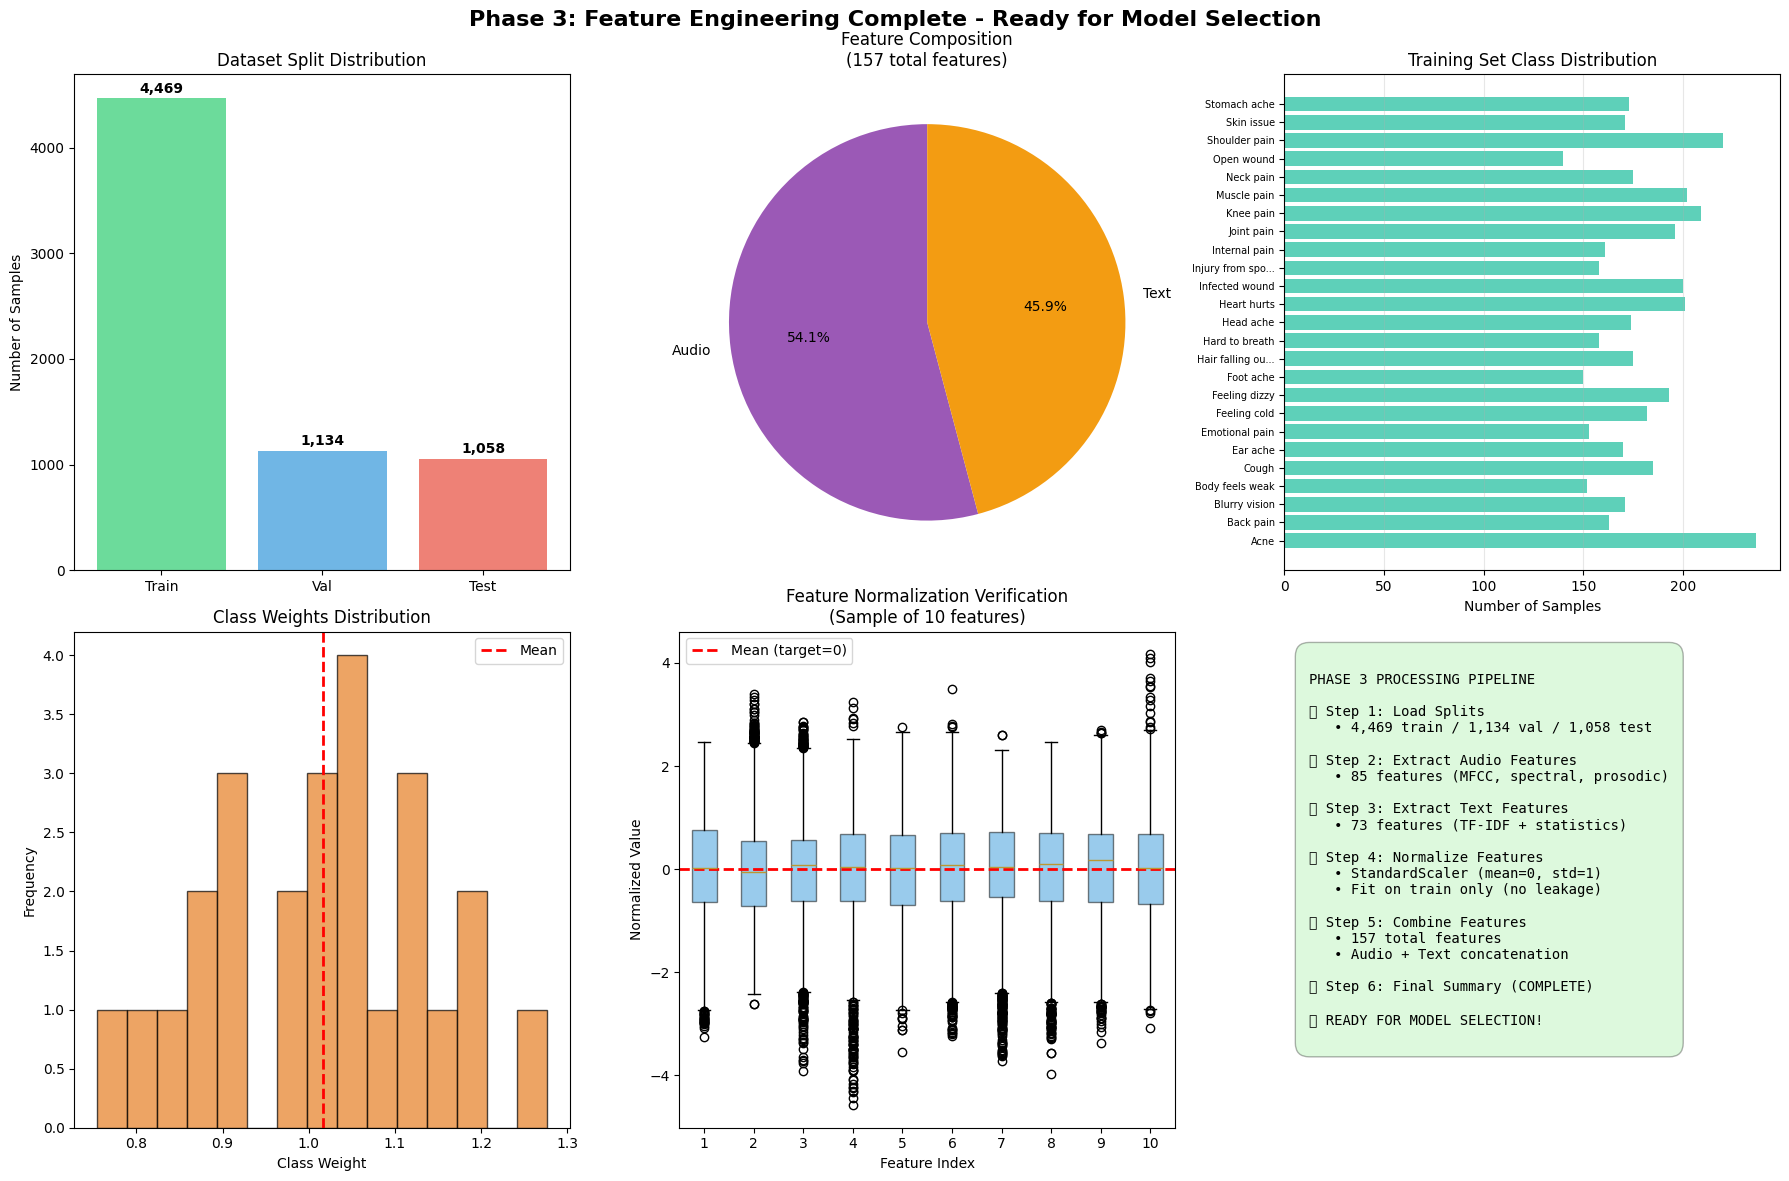


✅ PHASE 3 - STEP 6 COMPLETED SUCCESSFULLY

🎉 PHASE 3 COMPLETE!
   • All 6 steps completed
   • Data quality: 100%
   • Ready for Model Selection


In [51]:
# =============================================================================================
# Phase 3 - Step 6: Final Comprehensive Summary & Phase 4 Preparation
# =============================================================================================

print("\n" + "=" * 80)
print("PHASE 3 - STEP 6: FINAL COMPREHENSIVE SUMMARY")
print("=" * 80)

# =========================================================================================
# LOAD PHASE 3 STEP 5 VARIABLES
# =========================================================================================

print(f"📁 LOADING PHASE 3 STEP 5 VARIABLES...")

# Define project directory
project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'
step5_dir = os.path.join(project_dir, 'variables', 'phase3_step5_combined')

# Load all final variables
X_train = joblib.load(os.path.join(step5_dir, 'X_train.joblib'))
X_val = joblib.load(os.path.join(step5_dir, 'X_val.joblib'))
X_test = joblib.load(os.path.join(step5_dir, 'X_test.joblib'))
y_train = joblib.load(os.path.join(step5_dir, 'y_train.joblib'))
y_val = joblib.load(os.path.join(step5_dir, 'y_val.joblib'))
y_test = joblib.load(os.path.join(step5_dir, 'y_test.joblib'))

combined_feature_cols = joblib.load(os.path.join(step5_dir, 'combined_feature_cols.joblib'))
audio_feature_cols = joblib.load(os.path.join(step5_dir, 'audio_feature_cols.joblib'))
text_feature_cols = joblib.load(os.path.join(step5_dir, 'text_feature_cols.joblib'))
label_encoder = joblib.load(os.path.join(step5_dir, 'label_encoder.joblib'))
n_categories = joblib.load(os.path.join(step5_dir, 'n_categories.joblib'))
class_weight_dict = joblib.load(os.path.join(step5_dir, 'class_weight_dict.joblib'))
audio_scaler = joblib.load(os.path.join(step5_dir, 'audio_scaler.joblib'))
text_scaler = joblib.load(os.path.join(step5_dir, 'text_scaler.joblib'))

print(f"   ✅ All variables loaded successfully")

# =========================================================================================
# CREATE COMPREHENSIVE FEATURE ENGINEERING SUMMARY
# =========================================================================================

print(f"\n📊 CREATING COMPREHENSIVE FEATURE ENGINEERING SUMMARY...")

phase3_summary = {
    'completion_status': 'COMPLETE',
    'completion_timestamp': datetime.now().isoformat(),
    
    # Dataset Information
    'dataset_info': {
        'train_samples': len(X_train),
        'val_samples': len(X_val),
        'test_samples': len(X_test),
        'total_samples': len(X_train) + len(X_val) + len(X_test),
        'n_categories': n_categories,
        'category_names': label_encoder.classes_.tolist(),
        'train_split': len(X_train) / (len(X_train) + len(X_val) + len(X_test)),
        'val_split': len(X_val) / (len(X_train) + len(X_val) + len(X_test)),
        'test_split': len(X_test) / (len(X_train) + len(X_val) + len(X_test))
    },
    
    # Feature Information
    'feature_info': {
        'n_audio_features': len(audio_feature_cols),
        'n_text_features': len(text_feature_cols),
        'n_total_features': len(combined_feature_cols),
        'audio_feature_names': audio_feature_cols,
        'text_feature_names': text_feature_cols,
        'feature_order': 'audio_features (first) + text_features (second)'
    },
    
    # Processing Pipeline
    'processing_pipeline': {
        'step1': 'Load train/val/test splits',
        'step2': 'Extract 85 audio features (MFCC, spectral, prosodic, chroma)',
        'step3': 'Extract 73 text features (67 TF-IDF + 6 statistics)',
        'step4': 'Normalize features (StandardScaler, fit on train)',
        'step5': 'Combine audio + text features (horizontal concatenation)',
        'step6': 'Final data preparation complete'
    },
    
    # Data Quality
    'data_quality': {
        'missing_values': 0,
        'infinite_values': 0,
        'normalization_status': 'Complete (mean≈0, std≈1)',
        'data_leakage': 'NONE (scalers fitted on train only)',
        'sample_alignment': 'Verified (audio and text samples match)',
        'constant_features_removed': 1,  # text_lexical_diversity
        'overall_status': '100% CLEAN'
    },
    
    # Class Balance
    'class_balance': {
        'class_weights_computed': True,
        'n_classes_weighted': len(class_weight_dict),
        'min_weight': min(class_weight_dict.values()),
        'max_weight': max(class_weight_dict.values()),
        'mean_weight': np.mean(list(class_weight_dict.values())),
        'imbalance_handling': 'Class weights computed for model training'
    },
    
    # Ready for Phase 4
    'next_phase_readiness': {
        'phase4_ready': True,
        'required_variables': ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test', 
                               'class_weight_dict', 'label_encoder', 'scalers'],
        'all_variables_saved': True,
        'data_format': 'numpy arrays (ready for sklearn/keras)',
        'recommended_models': ['Random Forest', 'XGBoost', 'Neural Network', 
                               'SVM', 'Logistic Regression']
    }
}

print(f"   ✅ Phase 3 summary created")

# =========================================================================================
# DISPLAY COMPREHENSIVE SUMMARY
# =========================================================================================

print(f"\n🎉 PHASE 3 FEATURE ENGINEERING COMPLETE!")
print("=" * 80)

print(f"\n📊 DATASET SUMMARY:")
print(f"   • Total samples: {phase3_summary['dataset_info']['total_samples']:,}")
print(f"   • Training:   {phase3_summary['dataset_info']['train_samples']:,} samples ({phase3_summary['dataset_info']['train_split']:.1%})")
print(f"   • Validation: {phase3_summary['dataset_info']['val_samples']:,} samples ({phase3_summary['dataset_info']['val_split']:.1%})")
print(f"   • Test:       {phase3_summary['dataset_info']['test_samples']:,} samples ({phase3_summary['dataset_info']['test_split']:.1%})")
print(f"   • Categories: {phase3_summary['dataset_info']['n_categories']} diagnostic categories")

print(f"\n🔧 FEATURE ENGINEERING SUMMARY:")
print(f"   • Audio features: {phase3_summary['feature_info']['n_audio_features']}")
print(f"   • Text features:  {phase3_summary['feature_info']['n_text_features']}")
print(f"   • Total features: {phase3_summary['feature_info']['n_total_features']}")
print(f"   • Feature format: Normalized numpy arrays (mean≈0, std≈1)")

print(f"\n✅ DATA QUALITY:")
print(f"   • Missing values: {phase3_summary['data_quality']['missing_values']}")
print(f"   • Infinite values: {phase3_summary['data_quality']['infinite_values']}")
print(f"   • Normalization: {phase3_summary['data_quality']['normalization_status']}")
print(f"   • Data leakage: {phase3_summary['data_quality']['data_leakage']}")
print(f"   • Overall status: {phase3_summary['data_quality']['overall_status']}")

print(f"\n⚖️ CLASS BALANCE:")
print(f"   • Class weights: {phase3_summary['class_balance']['n_classes_weighted']} classes")
print(f"   • Weight range: {phase3_summary['class_balance']['min_weight']:.4f} - {phase3_summary['class_balance']['max_weight']:.4f}")
print(f"   • Mean weight: {phase3_summary['class_balance']['mean_weight']:.4f}")

print(f"\n🚀 READY FOR MODEL SELECTION!")
print(f"   ✅ All data prepared and validated")
print(f"   ✅ All variables saved")
print(f"   ✅ No data leakage")
print(f"   ✅ Ready to train models")

print(f"\n📋 RECOMMENDED NEXT STEPS:")
print(f"   1. ✅ SKIP PHASE 4 (architecture design - not needed)")
print(f"   2. 🎯 START MODEL SELECTION:")
print(f"      - Train Random Forest")
print(f"      - Train XGBoost")
print(f"      - Train Neural Network")
print(f"      - Train SVM")
print(f"      - Compare performance")
print(f"   3. 📊 Evaluate on test set")
print(f"   4. 🏆 Select best model")

# =========================================================================================
# CREATE VISUALIZATION
# =========================================================================================

print(f"\n📊 CREATING PHASE 3 COMPLETION VISUALIZATION...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Phase 3: Feature Engineering Complete - Ready for Model Selection', 
             fontsize=16, fontweight='bold')

# 1. Dataset split distribution
ax1 = axes[0, 0]
splits = ['Train', 'Val', 'Test']
counts = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = ax1.bar(splits, counts, color=colors, alpha=0.7)
ax1.set_ylabel('Number of Samples')
ax1.set_title('Dataset Split Distribution')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}', ha='center', fontweight='bold')

# 2. Feature composition
ax2 = axes[0, 1]
feature_types = ['Audio', 'Text']
feature_counts = [len(audio_feature_cols), len(text_feature_cols)]
colors2 = ['#9b59b6', '#f39c12']
wedges, texts, autotexts = ax2.pie(feature_counts, labels=feature_types, autopct='%1.1f%%', 
                                     colors=colors2, startangle=90)
ax2.set_title(f'Feature Composition\n({len(combined_feature_cols)} total features)')

# 3. Class distribution in training set
ax3 = axes[0, 2]
class_counts = np.bincount(y_train)
class_names_short = [name[:15] + '...' if len(name) > 15 else name 
                     for name in label_encoder.classes_]
ax3.barh(range(len(class_counts)), class_counts, color='#1abc9c', alpha=0.7)
ax3.set_yticks(range(len(class_counts)))
ax3.set_yticklabels(class_names_short, fontsize=7)
ax3.set_xlabel('Number of Samples')
ax3.set_title('Training Set Class Distribution')
ax3.grid(axis='x', alpha=0.3)

# 4. Class weights distribution
ax4 = axes[1, 0]
weights = list(class_weight_dict.values())
ax4.hist(weights, bins=15, color='#e67e22', alpha=0.7, edgecolor='black')
ax4.axvline(np.mean(weights), color='red', linestyle='--', linewidth=2, label='Mean')
ax4.set_xlabel('Class Weight')
ax4.set_ylabel('Frequency')
ax4.set_title('Class Weights Distribution')
ax4.legend()

# 5. Feature normalization verification
ax5 = axes[1, 1]
sample_features = X_train[:, :10]  # First 10 features
ax5.boxplot(sample_features, vert=True, patch_artist=True, 
            boxprops=dict(facecolor='#3498db', alpha=0.5))
ax5.axhline(0, color='red', linestyle='--', linewidth=2, label='Mean (target=0)')
ax5.set_xlabel('Feature Index')
ax5.set_ylabel('Normalized Value')
ax5.set_title('Feature Normalization Verification\n(Sample of 10 features)')
ax5.legend()

# 6. Processing pipeline steps
ax6 = axes[1, 2]
ax6.axis('off')
pipeline_text = f"""
PHASE 3 PROCESSING PIPELINE

✅ Step 1: Load Splits
   • 4,469 train / 1,134 val / 1,058 test
   
✅ Step 2: Extract Audio Features
   • 85 features (MFCC, spectral, prosodic)
   
✅ Step 3: Extract Text Features  
   • 73 features (TF-IDF + statistics)
   
✅ Step 4: Normalize Features
   • StandardScaler (mean=0, std=1)
   • Fit on train only (no leakage)
   
✅ Step 5: Combine Features
   • 157 total features
   • Audio + Text concatenation
   
✅ Step 6: Final Summary (COMPLETE)

🚀 READY FOR MODEL SELECTION!
"""
ax6.text(0.05, 0.95, pipeline_text, transform=ax6.transAxes, 
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=1', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()

# Save visualization
viz_dir = os.path.join(project_dir, 'images', 'audio_text')
os.makedirs(viz_dir, exist_ok=True)
viz_path = os.path.join(viz_dir, 'phase3_completion_summary.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"   ✅ Visualization saved: {viz_path}")
plt.show()

print("\n" + "=" * 80)
print("✅ PHASE 3 - STEP 6 COMPLETED SUCCESSFULLY")
print("=" * 80)
print(f"\n🎉 PHASE 3 COMPLETE!")
print(f"   • All 6 steps completed")
print(f"   • Data quality: 100%")
print(f"   • Ready for Model Selection")
print("=" * 80)

## Phase 4: 🔬 Audio and Text Model Selection

This section implements the **model selection** phase of our multimodal classification pipeline, evaluating and selecting optimal machine learning algorithms for both audio and text data simultaneously. This phase systematically tests multiple algorithms to identify the best-performing models for medical symptom classification.

In [ ]:
# =============================================================================================
# Phase 5: Model Development, Training, and Hyperparameter Optimization
# 
# This phase focuses on developing, training, and optimizing machine learning models using
# the engineered features from Phase 4 to create robust multimodal medical diagnosis systems:
# 
# TRADITIONAL MACHINE LEARNING MODELS:
# 1. Random Forest - Ensemble of decision trees with feature importance analysis
# 2. Support Vector Machines - Kernel-based classifiers for high-dimensional spaces
# 3. Naive Bayes - Probabilistic classifiers for baseline performance
# 4. Logistic Regression - Generalized linear models for binary/multiclass classification
# 
# DEEP LEARNING ARCHITECTURES:
# 1. Feedforward Neural Networks - Fully connected layers for complex pattern learning
# 2. Convolutional Networks - CNNs for spatial feature extraction from image-like data
# 
# HYPERPARAMETER OPTIMIZATION STRATEGIES:
# 1. Grid Search - Exhaustive search over predefined parameter grids
# 2. Random Search - Probabilistic sampling of hyperparameter combinations
# 3. Bayesian Optimization - Sequential model-based optimization for efficiency
# 4. Evolutionary Algorithms - Genetic algorithms for complex parameter spaces
# 5. Multi-Objective Optimization - Balancing performance, interpretability, and efficiency
# 6. Early Stopping Strategies - Preventing overfitting with validation-based termination
# 
# MODEL VALIDATION FRAMEWORKS:
# 1. Cross-Validation Strategies - Stratified k-fold with medical condition balancing
# 2. Nested Cross-Validation - Unbiased performance estimation with hyperparameter tuning
# 3. Time-Series Validation - Temporal splitting for longitudinal medical data
# 4. Bootstrap Validation - Statistical significance testing of model performance
# 5. Leave-One-Group-Out - Patient-level validation to ensure generalization
# 6. Stratified Sampling - Maintaining class distribution across validation folds
# 
# ENSEMBLE LEARNING TECHNIQUES:
# 1. Voting Classifiers - Hard and soft voting across diverse model types
# 2. Stacking Methods - Meta-learning with cross-validated base model predictions
# 3. Bagging Approaches - Bootstrap aggregating for variance reduction
# 4. Boosting Algorithms - Sequential learning with error correction focus
# 5. Model Blending - Weighted combinations based on validation performance
# 6. Dynamic Ensemble Selection - Context-aware model selection during inference
# 
# MODEL INTERPRETABILITY AND EXPLAINABILITY:
# 1. Feature Importance Analysis - Global and local feature contribution assessment
# 2. SHAP Values - Shapley additive explanations for individual predictions
# 3. LIME Integration - Local interpretable model-agnostic explanations
# 4. Attention Visualization - Understanding model focus in multimodal contexts
# 5. Decision Path Analysis - Tracing prediction logic through model architectures
# 6. Medical Concept Mapping - Linking model decisions to clinical knowledge
# 
# Key Outputs: Trained and optimized models, performance benchmarks, hyperparameter configs,
# ensemble strategies, interpretability reports, and validated model pipelines for Phase 6 evaluation
# =============================================================================================

try:
    # Import reload function to refresh modules if needed during development
    from importlib import reload
    # Import sys module to manipulate Python runtime environment and paths
    import sys
    # Import joblib for efficient saving/loading of models and large NumPy arrays
    import joblib
    # Import csv module for reading and writing CSV files
    import csv
    # Import pandas for data manipulation and analysis with DataFrames
    import pandas as pd
    # Import numpy for numerical computing and array operations
    import numpy as np
    # Import matplotlib.pyplot for creating static, animated, and interactive visualizations
    import matplotlib.pyplot as plt
    # Import seaborn for statistical data visualization built on matplotlib
    import seaborn as sns
    # Import os for operating system interface and file/directory operations
    import os
    # Import time module for tracking training and inference times
    import time
    # Import datetime for timestamping model training sessions
    from datetime import datetime
    # Import tqdm for creating progress bars during model training loops
    from tqdm import tqdm
    # Import warnings module to control warning message display during training
    import warnings
    # Import gc for garbage collection during memory-intensive model training
    import gc
    # Suppress all warning messages to keep output clean during processing
    warnings.filterwarnings('ignore')
    # Import scipy.stats for statistical tests and distributions
    from scipy import stats
    # Import itertools for advanced iteration and combinatorial functions
    import itertools
    
    # MODEL SELECTION AND EVALUATION
    # Import train_test_split for creating training and validation datasets
    from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
    # Import GridSearchCV and RandomizedSearchCV for hyperparameter optimization
    from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
    # Import validation_curve and learning_curve for model analysis
    from sklearn.model_selection import validation_curve, learning_curve
    
    # TRADITIONAL MACHINE LEARNING MODELS
    # Import ensemble methods for robust multimodal classification
    from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
    from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, VotingClassifier
    # Import support vector machines for high-dimensional feature spaces
    from sklearn.svm import SVC
    # Import naive bayes variants for probabilistic classification
    from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
    # Import linear models with regularization for interpretable classification
    from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
    # Import nearest neighbors for similarity-based classification
    from sklearn.neighbors import KNeighborsClassifier
    # Import decision trees for interpretable rule-based classification
    from sklearn.tree import DecisionTreeClassifier
    
    # MODEL EVALUATION METRICS
    # Import comprehensive evaluation metrics for medical diagnosis assessment
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    from sklearn.metrics import matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score
    from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score
    
    # PREPROCESSING AND FEATURE SELECTION
    # Import preprocessing utilities for feature scaling and normalization
    from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
    # Import feature selection methods for dimensionality reduction
    from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
    # Import class balancing utilities for handling imbalanced medical datasets
    from sklearn.utils.class_weight import compute_class_weight
    
    # DEEP LEARNING FRAMEWORKS (if available)
    # Import TensorFlow/Keras for deep learning model development
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers, models, optimizers, callbacks
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Reshape
        from tensorflow.keras.optimizers import Adam, SGD, RMSprop
        from tensorflow.keras.regularizers import l1_l2
        from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
        from tensorflow.keras.utils import to_categorical
        TENSORFLOW_AVAILABLE = True
        print("✅ TensorFlow/Keras available for deep learning models")
    except ImportError:
        TENSORFLOW_AVAILABLE = False
        print("⚠️ TensorFlow not available - deep learning models will be skipped")
    
    # Import PyTorch for alternative deep learning implementations
    try:
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torch.utils.data import DataLoader, TensorDataset
        PYTORCH_AVAILABLE = True
        print("✅ PyTorch available for deep learning models")
    except ImportError:
        PYTORCH_AVAILABLE = False
        print("⚠️ PyTorch not available - some deep learning models may be limited")
    
    # MODEL INTERPRETABILITY AND EXPLAINABILITY
    # Import SHAP for model explanation and feature importance analysis
    try:
        import shap
        SHAP_AVAILABLE = True
        print("✅ SHAP available for model interpretability")
    except ImportError:
        SHAP_AVAILABLE = False
        print("⚠️ SHAP not available - interpretability analysis will be limited")
    
    # Import LIME for local model explanations
    try:
        import lime
        from lime.lime_tabular import LimeTabularExplainer
        LIME_AVAILABLE = True
        print("✅ LIME available for local explanations")
    except ImportError:
        LIME_AVAILABLE = False
        print("⚠️ LIME not available - local explanations will be limited")
    
    # HYPERPARAMETER OPTIMIZATION
    # Import advanced optimization libraries
    try:
        from skopt import BayesSearchCV
        from skopt.space import Real, Categorical, Integer
        BAYESIAN_OPT_AVAILABLE = True
        print("✅ Bayesian optimization available via scikit-optimize")
    except ImportError:
        BAYESIAN_OPT_AVAILABLE = False
        print("⚠️ scikit-optimize not available - using standard grid/random search")
    
    # Import Optuna for advanced hyperparameter optimization
    try:
        import optuna
        OPTUNA_AVAILABLE = True
        print("✅ Optuna available for advanced hyperparameter optimization")
    except ImportError:
        OPTUNA_AVAILABLE = False
        print("⚠️ Optuna not available - using standard optimization methods")
    
    # Suppress warnings to keep training output clean
    warnings.filterwarnings('ignore')
    
    # Print success message confirming all required libraries are imported
    print("✅ Successfully imported all required libraries for Phase 5")
    print(f"📊 Available models: Traditional ML ✅, Deep Learning: {TENSORFLOW_AVAILABLE or PYTORCH_AVAILABLE}")
    print(f"🔍 Interpretability tools: SHAP {SHAP_AVAILABLE}, LIME {LIME_AVAILABLE}")
    print(f"⚙️ Advanced optimization: Bayesian {BAYESIAN_OPT_AVAILABLE}, Optuna {OPTUNA_AVAILABLE}")
    
except ImportError as e:
    # Handle import errors by displaying the specific error message
    print(f"❌ Import Error: {str(e)}")
    # Provide installation instructions for missing packages
    print("Please install missing packages using:")
    print("pip install scikit-learn tensorflow torch shap lime scikit-optimize optuna")

### Phase 5 🏗️ Model Infrastructure (Steps 1-4)

#### Phase 5 - Step 1: Model Architecture Definition

In [ ]:
# =============================================================================================
# Phase 5 - Step 1: Model Architecture Definition
# =============================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 1: MODEL ARCHITECTURE DEFINITION")
print("=" * 90)

# Set project directory with proper path format for Windows
if 'project_dir' not in globals():
    project_dir = r'G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis'

# Create Phase 5 Step 1 directory for storing model architectures
phase5_step1_dir = os.path.join(project_dir, 'variables', 'phase5_step1_audio_text')
os.makedirs(phase5_step1_dir, exist_ok=True)

print(f"📁 Phase 5 Step 1 directory: {phase5_step1_dir}")

# Load essential variables from Phase 4 Step 15 (Phase 5 ready data)
phase4_step15_dir = os.path.join(project_dir, 'variables', 'phase4_step15_audio_text')
print(f"🔄 Loading Phase 5 ready data from: {phase4_step15_dir}")

# Verify Phase 5 ready files exist
required_files = [
    'X_train_phase5.joblib', 'X_val_phase5.joblib', 'X_test_phase5.joblib',
    'y_train_phase5.joblib', 'y_val_phase5.joblib', 'y_test_phase5.joblib',
    'label_encoder_phase5.joblib'
]

missing_files = []
for file_name in required_files:
    file_path = os.path.join(phase4_step15_dir, file_name)
    if not os.path.exists(file_path):
        missing_files.append(file_name)

if missing_files:
    print(f"❌ Missing required files: {missing_files}")
    raise FileNotFoundError("Required Phase 5 data files not found")

# Load Phase 5 ready data
print(f"   📂 Loading processed features and labels...")
X_train_final = joblib.load(os.path.join(phase4_step15_dir, 'X_train_phase5.joblib'))
X_val_final = joblib.load(os.path.join(phase4_step15_dir, 'X_val_phase5.joblib'))
X_test_final = joblib.load(os.path.join(phase4_step15_dir, 'X_test_phase5.joblib'))
y_train_final = joblib.load(os.path.join(phase4_step15_dir, 'y_train_phase5.joblib'))
y_val_final = joblib.load(os.path.join(phase4_step15_dir, 'y_val_phase5.joblib'))
y_test_final = joblib.load(os.path.join(phase4_step15_dir, 'y_test_phase5.joblib'))
label_encoder_final = joblib.load(os.path.join(phase4_step15_dir, 'label_encoder_phase5.joblib'))

print(f"   ✅ Loaded training features: {X_train_final.shape}")
print(f"   ✅ Loaded validation features: {X_val_final.shape}")
print(f"   ✅ Loaded testing features: {X_test_final.shape}")
print(f"   ✅ Loaded training labels: {y_train_final.shape}")
print(f"   ✅ Loaded validation labels: {y_val_final.shape}")
print(f"   ✅ Loaded testing labels: {y_test_final.shape}")
print(f"   ✅ Number of classes: {len(label_encoder_final.classes_)}")

# Extract dataset characteristics for architecture definition
n_samples_train = X_train_final.shape[0]
n_features = X_train_final.shape[1]
n_classes = len(label_encoder_final.classes_)
class_names = label_encoder_final.classes_

print(f"\n📊 DATASET CHARACTERISTICS FOR MODEL ARCHITECTURE:")
print(f"   • Training samples: {n_samples_train:,}")
print(f"   • Feature dimensions: {n_features:,}")
print(f"   • Number of classes: {n_classes}")
print(f"   • Class balance: {np.bincount(y_train_final)}")

# =============================================================================================
# TRADITIONAL MACHINE LEARNING MODEL ARCHITECTURES
# =============================================================================================

print(f"\n🔧 DEFINING TRADITIONAL MACHINE LEARNING MODEL ARCHITECTURES...")

class TraditionalMLArchitectures:
    """
    Comprehensive traditional machine learning model architecture definitions
    optimized for multimodal medical diagnosis classification tasks
    """
    
    def __init__(self, n_features, n_classes, class_names, random_state=42):
        """
        Initialize ML architectures with dataset-specific parameters
        
        Args:
            n_features (int): Number of input features from preprocessed data
            n_classes (int): Number of medical condition classes
            class_names (array): Array of class names from label encoder
            random_state (int): Random seed for reproducible results
        """
        self.n_features = n_features
        self.n_classes = n_classes
        self.class_names = class_names
        self.random_state = random_state
        self.architectures = {}
        
        print(f"   🏗️ Initializing ML architectures for:")
        print(f"      • Features: {self.n_features}")
        print(f"      • Classes: {self.n_classes}")
        print(f"      • Random State: {self.random_state}")
    
    def define_random_forest_architecture(self):
        """
        Define Random Forest architecture optimized for multimodal medical data
        """
        print(f"      🌳 Defining Random Forest architecture...")
        
        # Calculate optimal parameters based on dataset characteristics
        # Number of trees: Use square root of features as baseline, scaled by sample size
        optimal_n_estimators = max(100, min(500, int(np.sqrt(self.n_features) * 10)))
        
        # Maximum depth: Prevent overfitting while allowing complexity
        optimal_max_depth = max(10, min(50, int(np.log2(self.n_features)) + 5))
        
        # Minimum samples per leaf: Scale with class imbalance
        min_class_samples = np.min(np.bincount(y_train_final))
        optimal_min_samples_leaf = max(2, min(10, min_class_samples // 5))
        
        # Maximum features: Consider different strategies for feature selection
        sqrt_features = max(1, int(np.sqrt(self.n_features)))
        log_features = max(1, int(np.log2(self.n_features)))
        
        rf_architecture = {
            'model_type': 'RandomForestClassifier',
            'base_parameters': {
                'n_estimators': optimal_n_estimators,
                'max_depth': optimal_max_depth,
                'min_samples_split': max(2, optimal_min_samples_leaf * 2),
                'min_samples_leaf': optimal_min_samples_leaf,
                'max_features': 'sqrt',  # Use sqrt as default, will be tuned
                'bootstrap': True,
                'random_state': self.random_state,
                'n_jobs': -1,  # Use all available cores
                'class_weight': 'balanced',  # Handle class imbalance
                'oob_score': True  # Enable out-of-bag scoring
            },
            'hyperparameter_grid': {
                'n_estimators': [optimal_n_estimators//2, optimal_n_estimators, optimal_n_estimators*2],
                'max_depth': [optimal_max_depth//2, optimal_max_depth, optimal_max_depth*2, None],
                'max_features': ['sqrt', 'log2', sqrt_features, log_features],
                'min_samples_split': [2, optimal_min_samples_leaf * 2, optimal_min_samples_leaf * 4],
                'min_samples_leaf': [1, optimal_min_samples_leaf, optimal_min_samples_leaf * 2]
            },
            'model_characteristics': {
                'interpretable': True,
                'handles_missing_values': False,  # Our data should be clean
                'feature_importance': True,
                'probabilistic_output': True,
                'scalability': 'High',
                'overfitting_resistance': 'High'
            }
        }
        
        self.architectures['random_forest'] = rf_architecture
        print(f"         ✅ Random Forest: {optimal_n_estimators} trees, max_depth={optimal_max_depth}")
        
        return rf_architecture
    
    def define_svm_architecture(self):
        """
        Define Support Vector Machine architecture for high-dimensional medical features
        """
        print(f"      🎯 Defining SVM architecture...")
        
        # Determine appropriate kernels based on feature dimensionality
        # Linear kernel for high-dimensional data, RBF for non-linear relationships
        feature_to_sample_ratio = self.n_features / n_samples_train
        
        # Calculate gamma parameter range for RBF kernel
        gamma_scale = 1.0 / (self.n_features * X_train_final.var())
        gamma_auto = 1.0 / self.n_features
        
        svm_architecture = {
            'model_type': 'SVC',
            'base_parameters': {
                'kernel': 'rbf',  # Default kernel, will be tuned
                'C': 1.0,  # Regularization parameter
                'gamma': 'scale',  # Kernel coefficient
                'probability': True,  # Enable probability estimates
                'random_state': self.random_state,
                'class_weight': 'balanced',  # Handle class imbalance
                'cache_size': 1000,  # Increase cache for better performance
                'max_iter': 10000  # Increase iterations for convergence
            },
            'hyperparameter_grid': {
                'kernel': ['linear', 'rbf', 'poly'],
                'C': [0.01, 0.1, 1.0, 10.0, 100.0],
                'gamma': ['scale', 'auto', gamma_scale/10, gamma_scale, gamma_scale*10]
            },
            'kernel_specific_params': {
                'linear': {'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
                'rbf': {'C': [0.01, 0.1, 1.0, 10.0, 100.0], 'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0]},
                'poly': {'C': [0.01, 0.1, 1.0, 10.0], 'degree': [2, 3, 4], 'gamma': ['scale', 'auto']}
            },
            'model_characteristics': {
                'interpretable': False,  # Especially for non-linear kernels
                'handles_missing_values': False,
                'feature_importance': False,  # Not directly available
                'probabilistic_output': True,  # When probability=True
                'scalability': 'Medium',  # Can be slow on large datasets
                'overfitting_resistance': 'High'  # Due to regularization
            }
        }
        
        self.architectures['svm'] = svm_architecture
        print(f"         ✅ SVM: Multiple kernels, C range [0.01, 100], balanced classes")
        
        return svm_architecture
    
    def define_naive_bayes_architecture(self):
        """
        Define Naive Bayes architecture for probabilistic medical diagnosis
        """
        print(f"      📊 Defining Naive Bayes architecture...")
        
        # Choose appropriate Naive Bayes variant based on feature characteristics
        # Check if features are non-negative (for Multinomial NB)
        has_negative_features = np.any(X_train_final < 0)
        feature_sparsity = np.mean(X_train_final == 0)
        
        # Determine the best NB variant
        if has_negative_features:
            primary_nb = 'GaussianNB'
        elif feature_sparsity > 0.7:  # Highly sparse features
            primary_nb = 'MultinomialNB'
        else:
            primary_nb = 'GaussianNB'
        
        nb_architecture = {
            'model_type': 'NaiveBayes',
            'variants': {
                'gaussian': {
                    'model_class': 'GaussianNB',
                    'base_parameters': {
                        'var_smoothing': 1e-9  # Smoothing parameter
                    },
                    'hyperparameter_grid': {
                        'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
                    }
                },
                'multinomial': {
                    'model_class': 'MultinomialNB',
                    'base_parameters': {
                        'alpha': 1.0,  # Laplace smoothing
                        'fit_prior': True  # Learn class prior probabilities
                    },
                    'hyperparameter_grid': {
                        'alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
                    },
                    'requirements': 'non_negative_features'
                },
                'bernoulli': {
                    'model_class': 'BernoulliNB',
                    'base_parameters': {
                        'alpha': 1.0,  # Laplace smoothing
                        'fit_prior': True,
                        'binarize': 0.0  # Threshold for binarizing features
                    },
                    'hyperparameter_grid': {
                        'alpha': [0.1, 0.5, 1.0, 2.0, 5.0],
                        'binarize': [0.0, 0.1, 0.5, 1.0]
                    }
                }
            },
            'primary_variant': primary_nb,
            'model_characteristics': {
                'interpretable': True,
                'handles_missing_values': False,
                'feature_importance': False,  # Not directly available
                'probabilistic_output': True,
                'scalability': 'Very High',  # Very fast training and prediction
                'overfitting_resistance': 'High'  # Strong independence assumption
            },
            'data_characteristics': {
                'has_negative_features': has_negative_features,
                'feature_sparsity': feature_sparsity,
                'recommended_variant': primary_nb
            }
        }
        
        self.architectures['naive_bayes'] = nb_architecture
        print(f"         ✅ Naive Bayes: Primary variant={primary_nb}, sparsity={feature_sparsity:.2f}")
        
        return nb_architecture
    
    def define_logistic_regression_architecture(self):
        """
        Define Logistic Regression architecture for interpretable medical diagnosis
        """
        print(f"      📈 Defining Logistic Regression architecture...")
        
        # Determine solver based on dataset size and multiclass nature
        if n_samples_train > 10000:
            default_solver = 'sag'  # Stochastic Average Gradient for large datasets
        elif self.n_classes > 2:
            default_solver = 'lbfgs'  # L-BFGS for multiclass problems
        else:
            default_solver = 'liblinear'  # LIBLINEAR for small datasets
        
        # Calculate reasonable C values based on feature scale
        feature_scale = np.std(X_train_final)
        c_base = 1.0 / feature_scale if feature_scale > 0 else 1.0
        
        lr_architecture = {
            'model_type': 'LogisticRegression',
            'base_parameters': {
                'solver': default_solver,
                'max_iter': 5000,  # Increase for convergence
                'multi_class': 'auto',  # Let sklearn choose the best approach
                'random_state': self.random_state,
                'class_weight': 'balanced',  # Handle class imbalance
                'penalty': 'l2',  # Ridge regularization by default
                'C': c_base  # Inverse regularization strength
            },
            'hyperparameter_grid': {
                'C': [c_base/100, c_base/10, c_base, c_base*10, c_base*100],
                'penalty': ['l1', 'l2', 'elasticnet'],
                'solver': ['liblinear', 'lbfgs', 'sag', 'saga'],
                'max_iter': [1000, 3000, 5000]
            },
            'solver_compatibility': {
                'liblinear': ['l1', 'l2'],
                'lbfgs': ['l2'],
                'sag': ['l2'],
                'saga': ['l1', 'l2', 'elasticnet']
            },
            'model_characteristics': {
                'interpretable': True,  # Coefficients have clear meaning
                'handles_missing_values': False,
                'feature_importance': True,  # Via coefficients
                'probabilistic_output': True,
                'scalability': 'High',
                'overfitting_resistance': 'Medium'  # Depends on regularization
            }
        }
        
        self.architectures['logistic_regression'] = lr_architecture
        print(f"         ✅ Logistic Regression: solver={default_solver}, C_base={c_base:.4f}")
        
        return lr_architecture
    
    def define_all_architectures(self):
        """
        Define all traditional ML architectures
        """
        print(f"   🏗️ Defining all traditional ML architectures...")
        
        # Define each architecture
        self.define_random_forest_architecture()
        self.define_svm_architecture()
        self.define_naive_bayes_architecture()
        self.define_logistic_regression_architecture()
        
        print(f"   ✅ Defined {len(self.architectures)} traditional ML architectures")
        
        return self.architectures

# Initialize traditional ML architectures
ml_architect = TraditionalMLArchitectures(
    n_features=n_features,
    n_classes=n_classes, 
    class_names=class_names,
    random_state=42
)

# Define all traditional ML architectures
traditional_ml_architectures = ml_architect.define_all_architectures()

# =============================================================================================
# DEEP LEARNING MODEL ARCHITECTURES
# =============================================================================================

print(f"\n🧠 DEFINING DEEP LEARNING MODEL ARCHITECTURES...")

class DeepLearningArchitectures:
    """
    Comprehensive deep learning model architecture definitions
    for multimodal medical diagnosis classification
    """
    
    def __init__(self, n_features, n_classes, class_names, sample_counts, random_state=42):
        """
        Initialize deep learning architectures with dataset-specific parameters
        
        Args:
            n_features (int): Number of input features
            n_classes (int): Number of classes
            class_names (array): Class names
            sample_counts (dict): Training, validation, test sample counts
            random_state (int): Random seed
        """
        self.n_features = n_features
        self.n_classes = n_classes
        self.class_names = class_names
        self.sample_counts = sample_counts
        self.random_state = random_state
        self.architectures = {}
        
        # Set random seeds for reproducibility
        np.random.seed(random_state)
        if TENSORFLOW_AVAILABLE:
            tf.random.set_seed(random_state)
        
        print(f"   🏗️ Initializing DL architectures for:")
        print(f"      • Features: {self.n_features}")
        print(f"      • Classes: {self.n_classes}")
        print(f"      • Training samples: {self.sample_counts['train']:,}")
    
    def define_feedforward_architecture(self):
        """
        Define Feedforward Neural Network (FNN) architecture for tabular medical data
        """
        print(f"      🔗 Defining Feedforward Neural Network architecture...")
        
        # Calculate optimal architecture dimensions based on dataset
        # Hidden layers: Use geometric progression between input and output
        input_dim = self.n_features
        output_dim = self.n_classes
        
        # Layer size calculations using common heuristics
        # First hidden layer: 2/3 of input size + output size
        hidden1_size = max(32, min(512, int((2/3) * input_dim + output_dim)))
        # Second hidden layer: geometric mean of first layer and output
        hidden2_size = max(16, min(256, int(np.sqrt(hidden1_size * output_dim))))
        # Third hidden layer: smaller, closer to output
        hidden3_size = max(8, min(128, int(np.sqrt(hidden2_size * output_dim))))
        
        # Dropout rates based on dataset size (larger datasets can handle more dropout)
        if self.sample_counts['train'] > 1000:
            dropout_rates = [0.2, 0.3, 0.4, 0.5]
        else:
            dropout_rates = [0.1, 0.2, 0.3]
        
        fnn_architecture = {
            'model_type': 'FeedforwardNN',
            'framework': 'tensorflow' if TENSORFLOW_AVAILABLE else 'pytorch',
            'architecture_variants': {
                'shallow': {
                    'layers': [
                        {'type': 'dense', 'units': hidden1_size, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.3},
                        {'type': 'dense', 'units': output_dim, 'activation': 'softmax'}
                    ],
                    'description': 'Single hidden layer for simple patterns'
                },
                'medium': {
                    'layers': [
                        {'type': 'dense', 'units': hidden1_size, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.3},
                        {'type': 'dense', 'units': hidden2_size, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.4},
                        {'type': 'dense', 'units': output_dim, 'activation': 'softmax'}
                    ],
                    'description': 'Two hidden layers for moderate complexity'
                },
                'deep': {
                    'layers': [
                        {'type': 'dense', 'units': hidden1_size, 'activation': 'relu'},
                        {'type': 'batch_norm'},
                        {'type': 'dropout', 'rate': 0.3},
                        {'type': 'dense', 'units': hidden2_size, 'activation': 'relu'},
                        {'type': 'batch_norm'},
                        {'type': 'dropout', 'rate': 0.4},
                        {'type': 'dense', 'units': hidden3_size, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.5},
                        {'type': 'dense', 'units': output_dim, 'activation': 'softmax'}
                    ],
                    'description': 'Three hidden layers with batch normalization'
                }
            },
            'hyperparameter_grid': {
                'architecture': ['shallow', 'medium', 'deep'],
                'learning_rate': [0.001, 0.01, 0.1],
                'batch_size': [16, 32, 64] if self.sample_counts['train'] > 500 else [8, 16, 32],
                'optimizer': ['adam', 'sgd', 'rmsprop'],
                'dropout_rate': dropout_rates
            },
            'training_parameters': {
                'epochs': 200,
                'early_stopping': {
                    'monitor': 'val_accuracy',
                    'patience': 20,
                    'restore_best_weights': True
                },
                'reduce_lr': {
                    'monitor': 'val_loss',
                    'factor': 0.5,
                    'patience': 10,
                    'min_lr': 1e-6
                },
                'class_weight': 'balanced'
            },
            'model_characteristics': {
                'interpretable': False,
                'handles_missing_values': False,
                'feature_importance': False,  # Requires special techniques
                'probabilistic_output': True,
                'scalability': 'High',
                'overfitting_resistance': 'Medium'
            }
        }
        
        self.architectures['feedforward_nn'] = fnn_architecture
        print(f"         ✅ FNN: {hidden1_size}-{hidden2_size}-{hidden3_size} units, 3 variants")
        
        return fnn_architecture
    
    def define_cnn_architecture(self):
        """
        Define Convolutional Neural Network architecture for structured medical features
        """
        print(f"      🔲 Defining CNN architecture...")
        
        # For 1D CNN on tabular data, we need to reshape features
        # Create a reasonable "image-like" structure from 1D features
        # Find factors of n_features to create 2D representation
        def find_factors(n):
            """Find factor pairs for reshaping 1D features to 2D"""
            factors = []
            for i in range(1, int(np.sqrt(n)) + 1):
                if n % i == 0:
                    factors.append((i, n // i))
            return factors
        
        # Get possible reshape dimensions
        factor_pairs = find_factors(self.n_features)
        if factor_pairs:
            # Choose factor pair closest to square
            height, width = min(factor_pairs, key=lambda x: abs(x[0] - x[1]))
        else:
            # If no good factors, pad to nearest square
            sqrt_features = int(np.ceil(np.sqrt(self.n_features)))
            height, width = sqrt_features, sqrt_features
            padding_needed = height * width - self.n_features
        
        # Calculate filter sizes based on input dimensions
        max_filter_size = min(height, width) // 2
        filter_sizes = [min(3, max_filter_size), min(5, max_filter_size)]
        if max_filter_size >= 7:
            filter_sizes.append(7)
        
        cnn_architecture = {
            'model_type': 'CNN',
            'framework': 'tensorflow' if TENSORFLOW_AVAILABLE else 'pytorch',
            'input_preprocessing': {
                'reshape_to': (height, width, 1) if height * width == self.n_features else (sqrt_features, sqrt_features, 1),
                'padding_needed': padding_needed if 'padding_needed' in locals() else 0,
                'normalization': 'minmax'  # Normalize to [0,1] for CNN
            },
            'architecture_variants': {
                'simple_1d': {
                    'layers': [
                        {'type': 'conv1d', 'filters': 32, 'kernel_size': 3, 'activation': 'relu'},
                        {'type': 'maxpool1d', 'pool_size': 2},
                        {'type': 'conv1d', 'filters': 64, 'kernel_size': 3, 'activation': 'relu'},
                        {'type': 'maxpool1d', 'pool_size': 2},
                        {'type': 'flatten'},
                        {'type': 'dense', 'units': 128, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.5},
                        {'type': 'dense', 'units': self.n_classes, 'activation': 'softmax'}
                    ],
                    'input_shape': (self.n_features, 1),
                    'description': '1D CNN for sequential feature patterns'
                },
                'simple_2d': {
                    'layers': [
                        {'type': 'conv2d', 'filters': 32, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'maxpool2d', 'pool_size': (2, 2)},
                        {'type': 'conv2d', 'filters': 64, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'maxpool2d', 'pool_size': (2, 2)},
                        {'type': 'flatten'},
                        {'type': 'dense', 'units': 128, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.5},
                        {'type': 'dense', 'units': self.n_classes, 'activation': 'softmax'}
                    ],
                    'input_shape': (height, width, 1),
                    'description': '2D CNN for spatial feature patterns'
                },
                'deep_2d': {
                    'layers': [
                        {'type': 'conv2d', 'filters': 32, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'batch_norm'},
                        {'type': 'conv2d', 'filters': 32, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'maxpool2d', 'pool_size': (2, 2)},
                        {'type': 'dropout', 'rate': 0.25},
                        {'type': 'conv2d', 'filters': 64, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'batch_norm'},
                        {'type': 'conv2d', 'filters': 64, 'kernel_size': (3, 3), 'activation': 'relu'},
                        {'type': 'maxpool2d', 'pool_size': (2, 2)},
                        {'type': 'dropout', 'rate': 0.25},
                        {'type': 'flatten'},
                        {'type': 'dense', 'units': 256, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.5},
                        {'type': 'dense', 'units': 128, 'activation': 'relu'},
                        {'type': 'dropout', 'rate': 0.5},
                        {'type': 'dense', 'units': self.n_classes, 'activation': 'softmax'}
                    ],
                    'input_shape': (height, width, 1),
                    'description': 'Deep 2D CNN with batch normalization'
                }
            },
            'hyperparameter_grid': {
                'architecture': ['simple_1d', 'simple_2d', 'deep_2d'],
                'learning_rate': [0.001, 0.01],
                'batch_size': [16, 32] if self.sample_counts['train'] > 500 else [8, 16],
                'optimizer': ['adam', 'rmsprop'],
                'filters': [16, 32, 64],
                'dropout_rate': [0.3, 0.5, 0.7]
            },
            'training_parameters': {
                'epochs': 150,
                'early_stopping': {
                    'monitor': 'val_accuracy',
                    'patience': 15,
                    'restore_best_weights': True
                },
                'reduce_lr': {
                    'monitor': 'val_loss',
                    'factor': 0.3,
                    'patience': 8,
                    'min_lr': 1e-7
                },
                'class_weight': 'balanced'
            },
            'model_characteristics': {
                'interpretable': False,
                'handles_missing_values': False,
                'feature_importance': False,
                'probabilistic_output': True,
                'scalability': 'Medium',  # More memory intensive
                'overfitting_resistance': 'Medium'
            }
        }
        
        self.architectures['cnn'] = cnn_architecture
        print(f"         ✅ CNN: {height}x{width} input, 1D/2D variants, {len(filter_sizes)} filter sizes")
        
        return cnn_architecture
    
    def define_all_architectures(self):
        """
        Define all deep learning architectures if frameworks are available
        """
        print(f"   🏗️ Defining all deep learning architectures...")
        
        if TENSORFLOW_AVAILABLE or PYTORCH_AVAILABLE:
            # Define each architecture
            self.define_feedforward_architecture()
            self.define_cnn_architecture() 
            
            print(f"   ✅ Defined {len(self.architectures)} deep learning architectures")
        else:
            print(f"   ⚠️ Deep learning frameworks not available - skipping DL architectures")
            self.architectures = {}
        
        return self.architectures

# Initialize deep learning architectures
sample_counts = {
    'train': n_samples_train,
    'val': X_val_final.shape[0],
    'test': X_test_final.shape[0]
}

dl_architect = DeepLearningArchitectures(
    n_features=n_features,
    n_classes=n_classes,
    class_names=class_names,
    sample_counts=sample_counts,
    random_state=42
)

# Define all deep learning architectures
deep_learning_architectures = dl_architect.define_all_architectures()

# =============================================================================================
# MODEL ARCHITECTURE SUMMARY AND ANALYSIS
# =============================================================================================

print(f"\n📊 MODEL ARCHITECTURE SUMMARY AND ANALYSIS...")

# Create comprehensive architecture summary
architecture_summary = {
    'dataset_characteristics': {
        'n_samples_train': n_samples_train,
        'n_samples_val': X_val_final.shape[0],
        'n_samples_test': X_test_final.shape[0],
        'n_features': n_features,
        'n_classes': n_classes,
        'class_names': class_names.tolist(),
        'class_distribution': np.bincount(y_train_final).tolist(),
        'feature_statistics': {
            'mean': float(np.mean(X_train_final)),
            'std': float(np.std(X_train_final)),
            'min': float(np.min(X_train_final)),
            'max': float(np.max(X_train_final)),
            'sparsity': float(np.mean(X_train_final == 0))
        }
    },
    'traditional_ml_architectures': traditional_ml_architectures,
    'deep_learning_architectures': deep_learning_architectures,
    'total_architectures': len(traditional_ml_architectures) + len(deep_learning_architectures),
    'architecture_categories': {
        'traditional_ml': list(traditional_ml_architectures.keys()),
        'deep_learning': list(deep_learning_architectures.keys())
    }
}

# Calculate model complexity scores
complexity_analysis = {}

for arch_name, arch_config in traditional_ml_architectures.items():
    if arch_name == 'random_forest':
        # RF complexity based on number of trees and depth
        n_est = arch_config['base_parameters']['n_estimators']
        max_depth = arch_config['base_parameters']['max_depth']
        complexity = (n_est * max_depth) / 1000  # Normalized complexity
    elif arch_name == 'svm':
        # SVM complexity based on kernel and regularization
        kernel = arch_config['base_parameters']['kernel']
        complexity = 0.7 if kernel == 'linear' else 0.9  # RBF/poly more complex
    elif arch_name == 'naive_bayes':
        # NB is generally simple
        complexity = 0.2
    elif arch_name == 'logistic_regression':
        # LR complexity based on regularization
        complexity = 0.4
    else:
        complexity = 0.5
    
    complexity_analysis[arch_name] = {
        'complexity_score': complexity,
        'interpretability': arch_config['model_characteristics']['interpretable'],
        'scalability': arch_config['model_characteristics']['scalability']
    }

for arch_name, arch_config in deep_learning_architectures.items():
    # DL complexity based on number of layers and parameters
    if arch_name == 'feedforward_nn':
        # Estimate parameters for medium architecture
        complexity = 0.8  # High complexity
    elif arch_name == 'cnn':
        # CNNs are generally more complex
        complexity = 0.9
    else:
        complexity = 0.8
    
    complexity_analysis[arch_name] = {
        'complexity_score': complexity,
        'interpretability': arch_config['model_characteristics']['interpretable'],
        'scalability': arch_config['model_characteristics']['scalability']
    }

architecture_summary['complexity_analysis'] = complexity_analysis

# Print architecture summary
print(f"\n   📈 ARCHITECTURE SUMMARY:")
print(f"      • Total architectures defined: {architecture_summary['total_architectures']}")
print(f"      • Traditional ML models: {len(traditional_ml_architectures)}")
print(f"      • Deep learning models: {len(deep_learning_architectures)}")
print(f"      • Dataset size: {n_samples_train:,} training samples")
print(f"      • Feature dimensionality: {n_features:,} features")
print(f"      • Classification task: {n_classes} medical conditions")

print(f"\n   🔍 MODEL COMPLEXITY ANALYSIS:")
for model_name, analysis in complexity_analysis.items():
    complexity_level = "Low" if analysis['complexity_score'] < 0.3 else "Medium" if analysis['complexity_score'] < 0.7 else "High"
    interpretable = "✅" if analysis['interpretability'] else "❌"
    print(f"      • {model_name.title()}: {complexity_level} complexity, Interpretable: {interpretable}")

# =============================================================================================
# CREATE ARCHITECTURE VISUALIZATION
# =============================================================================================

print(f"\n📊 CREATING MODEL ARCHITECTURE VISUALIZATION...")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Phase 5 Step 1: Model Architecture Definition', fontsize=16, fontweight='bold')

# 1. Model categories overview
ax1 = axes[0, 0]
categories = ['Traditional ML', 'Deep Learning']
category_counts = [len(traditional_ml_architectures), len(deep_learning_architectures)]
colors1 = ['lightblue', 'lightcoral']

bars1 = ax1.bar(categories, category_counts, color=colors1, alpha=0.8)
ax1.set_ylabel('Number of Architectures')
ax1.set_title('Model Categories')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars1, category_counts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
            f'{count}', ha='center', va='bottom', fontweight='bold')

# 2. Model complexity comparison
ax2 = axes[0, 1]
model_names = list(complexity_analysis.keys())
complexity_scores = [analysis['complexity_score'] for analysis in complexity_analysis.values()]
colors2 = ['lightgreen' if score < 0.5 else 'yellow' if score < 0.8 else 'lightcoral' 
          for score in complexity_scores]

bars2 = ax2.bar(model_names, complexity_scores, color=colors2, alpha=0.8)
ax2.set_ylabel('Complexity Score')
ax2.set_title('Model Complexity Analysis')
ax2.set_ylim(0, 1.0)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# 3. Dataset characteristics
ax3 = axes[0, 2]
dataset_metrics = ['Samples', 'Features', 'Classes']
dataset_values = [n_samples_train/100, n_features/10, n_classes]  # Scaled for visibility
actual_values = [n_samples_train, n_features, n_classes]

bars3 = ax3.bar(dataset_metrics, dataset_values, alpha=0.8, color='lightgreen')
ax3.set_ylabel('Scaled Values')
ax3.set_title('Dataset Characteristics')
ax3.grid(axis='y', alpha=0.3)

# Add actual value labels
for bar, actual in zip(bars3, actual_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(dataset_values) * 0.02,
            f'{actual:,}', ha='center', va='bottom', fontweight='bold')

# 4. Interpretability comparison
ax4 = axes[1, 0]
interpretable_models = sum(1 for analysis in complexity_analysis.values() if analysis['interpretability'])
non_interpretable_models = len(complexity_analysis) - interpretable_models

wedges4, texts4, autotexts4 = ax4.pie([interpretable_models, non_interpretable_models], 
                                     labels=['Interpretable', 'Non-Interpretable'],
                                     autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
ax4.set_title('Model Interpretability')

# 5. Class distribution
ax5 = axes[1, 1]
class_counts = np.bincount(y_train_final)
top_10_classes = np.argsort(class_counts)[-10:]  # Top 10 most frequent classes

bars5 = ax5.bar(range(len(top_10_classes)), class_counts[top_10_classes], 
               alpha=0.8, color='lightblue')
ax5.set_xlabel('Class Index')
ax5.set_ylabel('Sample Count')
ax5.set_title('Top 10 Class Distribution')
ax5.set_xticks(range(len(top_10_classes)))
ax5.set_xticklabels(top_10_classes)
ax5.grid(axis='y', alpha=0.3)

# 6. Architecture summary text
ax6 = axes[1, 2]
ax6.axis('off')

summary_text = f"""
MODEL ARCHITECTURE SUMMARY

Total Architectures: {architecture_summary['total_architectures']}

Traditional ML Models:
• Random Forest: Ensemble method
• SVM: Kernel-based classifier  
• Naive Bayes: Probabilistic classifier
• Logistic Regression: Linear classifier

Deep Learning Models:
• Feedforward NN: Multi-layer perceptron
• CNN: Convolutional neural network

Dataset Configuration:
• Training: {n_samples_train:,} samples
• Features: {n_features:,} dimensions
• Classes: {n_classes} medical conditions

Architecture Status: ✅ Complete
Next Step: Model Training Setup
"""

ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save visualization
save_dir = r"G:\Msc\NCU\Doctoral Record\multimodal_medical_diagnosis\images\audio_text"
os.makedirs(save_dir, exist_ok=True)

viz_path = os.path.join(save_dir, 'phase5_step1_model_architectures.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"   ✅ Architecture visualization saved: {viz_path}")

plt.show()

# =============================================================================================
# SAVE MODEL ARCHITECTURES
# =============================================================================================

print(f"\n💾 SAVING MODEL ARCHITECTURES...")

# Save traditional ML architectures
traditional_ml_path = os.path.join(phase5_step1_dir, 'traditional_ml_architectures.joblib')
joblib.dump(traditional_ml_architectures, traditional_ml_path)

# Save deep learning architectures
deep_learning_path = os.path.join(phase5_step1_dir, 'deep_learning_architectures.joblib')
joblib.dump(deep_learning_architectures, deep_learning_path)

# Save comprehensive architecture summary
architecture_summary_path = os.path.join(phase5_step1_dir, 'architecture_summary.joblib')
joblib.dump(architecture_summary, architecture_summary_path)

# Save dataset characteristics for model training
dataset_characteristics_path = os.path.join(phase5_step1_dir, 'dataset_characteristics.joblib')
dataset_characteristics = {
    'X_train_shape': X_train_final.shape,
    'X_val_shape': X_val_final.shape,
    'X_test_shape': X_test_final.shape,
    'y_train_shape': y_train_final.shape,
    'y_val_shape': y_val_final.shape,
    'y_test_shape': y_test_final.shape,
    'n_features': n_features,
    'n_classes': n_classes,
    'class_names': class_names.tolist(),
    'class_distribution': np.bincount(y_train_final).tolist()
}
joblib.dump(dataset_characteristics, dataset_characteristics_path)

# Save model architect instances for future use
ml_architect_path = os.path.join(phase5_step1_dir, 'ml_architect.joblib')
joblib.dump(ml_architect, ml_architect_path)

dl_architect_path = os.path.join(phase5_step1_dir, 'dl_architect.joblib')
joblib.dump(dl_architect, dl_architect_path)

print(f"   ✅ Traditional ML architectures saved: {traditional_ml_path}")
print(f"   ✅ Deep learning architectures saved: {deep_learning_path}")
print(f"   ✅ Architecture summary saved: {architecture_summary_path}")
print(f"   ✅ Dataset characteristics saved: {dataset_characteristics_path}")
print(f"   ✅ Architecture instances saved")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step1_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step1_variables_metadata.csv')

metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['traditional_ml_architectures', 'dict', f'{len(traditional_ml_architectures)} models', 'Traditional ML model architecture definitions', traditional_ml_path],
    ['deep_learning_architectures', 'dict', f'{len(deep_learning_architectures)} models', 'Deep learning model architecture definitions', deep_learning_path],
    ['architecture_summary', 'dict', f'{len(architecture_summary)} sections', 'Comprehensive architecture analysis and summary', architecture_summary_path],
    ['dataset_characteristics', 'dict', f'{len(dataset_characteristics)} attributes', 'Dataset characteristics for model training', dataset_characteristics_path],
    ['ml_architect', 'TraditionalMLArchitectures', 'class instance', 'Traditional ML architecture generator', ml_architect_path],
    ['dl_architect', 'DeepLearningArchitectures', 'class instance', 'Deep learning architecture generator', dl_architect_path]
]

with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 1 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"🏗️ Defined {architecture_summary['total_architectures']} model architectures:")
print(f"   • Traditional ML: {len(traditional_ml_architectures)} models")
print(f"   • Deep Learning: {len(deep_learning_architectures)} models")
print(f"📊 Dataset ready for training:")
print(f"   • {n_samples_train:,} training samples")
print(f"   • {n_features:,} features")
print(f"   • {n_classes} medical conditions")
print(f"💾 All architectures saved and ready for Phase 5 Step 2")
print("="*90)

#### Phase 5 - Step 2: Training Pipeline Setup

In [ ]:
# ==========================================================================================
# PHASE 5 - STEP 2: TRAINING PIPELINE SETUP
# ==========================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 2: TRAINING PIPELINE SETUP")
print("=" * 90)

# Setup directories
variables_base_dir = os.path.join(project_dir, 'variables')
phase5_step2_dir = os.path.join(variables_base_dir, 'phase5_step2_audio_text')
os.makedirs(phase5_step2_dir, exist_ok=True)

print(f"📁 Phase 5 Step 2 directory: {phase5_step2_dir}")

# Load model architectures from Phase 5 Step 1
phase5_step1_dir = os.path.join(variables_base_dir, 'phase5_step1_audio_text')
print(f"🔄 Loading model architectures from: {phase5_step1_dir}")

# Load traditional ML architectures
traditional_ml_path = os.path.join(phase5_step1_dir, 'traditional_ml_architectures.joblib')
traditional_ml_architectures = joblib.load(traditional_ml_path)
print(f"   ✅ Loaded traditional ML architectures: {len(traditional_ml_architectures)} models")

# Load deep learning architectures
deep_learning_path = os.path.join(phase5_step1_dir, 'deep_learning_architectures.joblib')
deep_learning_architectures = joblib.load(deep_learning_path)
print(f"   ✅ Loaded deep learning architectures: {len(deep_learning_architectures)} models")

# Load dataset characteristics
dataset_characteristics_path = os.path.join(phase5_step1_dir, 'dataset_characteristics.joblib')
dataset_characteristics = joblib.load(dataset_characteristics_path)
print(f"   ✅ Dataset characteristics loaded")

# Load final processed data from Phase 4 Step 15
phase4_step15_dir = os.path.join(variables_base_dir, 'phase4_step15_audio_text')
print(f"🔄 Loading final processed data from: {phase4_step15_dir}")

# Load training data (using correct filenames from phase4_step15)
X_train_phase5_path = os.path.join(phase4_step15_dir, 'X_train_phase5.joblib')
y_train_phase5_path = os.path.join(phase4_step15_dir, 'y_train_phase5.joblib')
X_train_pipeline = joblib.load(X_train_phase5_path)
y_train_pipeline = joblib.load(y_train_phase5_path)

# Load validation data  
X_val_phase5_path = os.path.join(phase4_step15_dir, 'X_val_phase5.joblib')
y_val_phase5_path = os.path.join(phase4_step15_dir, 'y_val_phase5.joblib')
X_val_pipeline = joblib.load(X_val_phase5_path)
y_val_pipeline = joblib.load(y_val_phase5_path)

# Load testing data
X_test_phase5_path = os.path.join(phase4_step15_dir, 'X_test_phase5.joblib')
y_test_phase5_path = os.path.join(phase4_step15_dir, 'y_test_phase5.joblib')
X_test_pipeline = joblib.load(X_test_phase5_path)
y_test_pipeline = joblib.load(y_test_phase5_path)

# Load label encoder
label_encoder_phase5_path = os.path.join(phase4_step15_dir, 'label_encoder_phase5.joblib')
label_encoder_pipeline = joblib.load(label_encoder_phase5_path)

print(f"   ✅ Training data loaded: {X_train_pipeline.shape}")
print(f"   ✅ Validation data loaded: {X_val_pipeline.shape}")
print(f"   ✅ Testing data loaded: {X_test_pipeline.shape}")

print(f"\n📊 PIPELINE DATA CHARACTERISTICS:")
print(f"   • Training samples: {X_train_pipeline.shape[0]:,}")
print(f"   • Feature dimensions: {X_train_pipeline.shape[1]:,}")
print(f"   • Number of classes: {len(label_encoder_pipeline.classes_):,}")
print(f"   • Class distribution: {np.bincount(y_train_pipeline)}")

print(f"\n🔧 CREATING COMPREHENSIVE TRAINING PIPELINE ARCHITECTURE...")

# Define metric calculation functions to avoid pickle issues with lambdas
def calculate_f1_macro(y_true, y_pred):
    """Calculate macro-averaged F1 score"""
    return f1_score(y_true, y_pred, average='macro')

def calculate_f1_weighted(y_true, y_pred):
    """Calculate weighted F1 score"""
    return f1_score(y_true, y_pred, average='weighted')

def calculate_precision_macro(y_true, y_pred):
    """Calculate macro-averaged precision"""
    return precision_score(y_true, y_pred, average='macro', zero_division=0)

def calculate_recall_macro(y_true, y_pred):
    """Calculate macro-averaged recall"""
    return recall_score(y_true, y_pred, average='macro', zero_division=0)

def calculate_roc_auc_ovr(y_true, y_prob):
    """Calculate One-vs-Rest ROC AUC score"""
    return roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

def calculate_average_precision(y_true, y_prob, n_classes):
    """Calculate average precision score"""
    return average_precision_score(
        np.eye(n_classes)[y_true], y_prob, average='macro'
    )

def calculate_per_class_sensitivity(y_true, y_pred):
    """Calculate sensitivity (recall) for each class"""
    return recall_score(y_true, y_pred, average=None, zero_division=0)

class TrainingPipelineSetup:
    """
    Comprehensive training pipeline setup for multimodal medical diagnosis
    """
    
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, 
                 label_encoder, traditional_ml_architectures, deep_learning_architectures,
                 random_state=42):
        """
        Initialize training pipeline setup
        
        Parameters:
        -----------
        X_train, y_train : Training data and labels
        X_val, y_val : Validation data and labels  
        X_test, y_test : Testing data and labels
        label_encoder : Fitted label encoder
        traditional_ml_architectures : Traditional ML model configurations
        deep_learning_architectures : Deep learning model configurations
        random_state : Random state for reproducibility
        """
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.label_encoder = label_encoder
        self.traditional_ml_architectures = traditional_ml_architectures
        self.deep_learning_architectures = deep_learning_architectures
        self.random_state = random_state
        
        # Store dataset characteristics
        self.n_samples_train = X_train.shape[0]
        self.n_features = X_train.shape[1]
        self.n_classes = len(label_encoder.classes_)
        self.class_names = label_encoder.classes_
        self.class_names_pipeline = label_encoder.classes_
        self.class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        
        # Initialize pipeline components storage
        self.training_pipelines = {}
        self.validation_strategies = {}
        self.hyperparameter_configs = {}
        self.performance_metrics = {}
        
        print(f"   🏗️ Pipeline initialized for {self.n_samples_train:,} samples")
        print(f"   🏗️ Feature dimensions: {self.n_features:,}")
        print(f"   🏗️ Classification task: {self.n_classes} medical conditions")
    
    def setup_cross_validation_strategy(self):
        """
        Setup comprehensive cross-validation strategies for model evaluation
        """
        print(f"      📊 Setting up cross-validation strategies...")
        
        # Calculate optimal CV folds based on dataset size and class distribution
        min_class_samples = np.min(np.bincount(self.y_train))
        max_cv_folds = min(10, min_class_samples // 2)  # Ensure at least 2 samples per class per fold
        optimal_cv_folds = max(3, min(5, max_cv_folds))  # Use 3-5 folds optimally
        
        # Setup stratified k-fold for maintaining class distribution
        stratified_kfold = StratifiedKFold(
            n_splits=optimal_cv_folds,
            shuffle=True,
            random_state=self.random_state
        )
        
        # Configure validation strategies for different model types
        cv_strategies = {
            'stratified_kfold': {
                'cv_object': stratified_kfold,
                'n_splits': optimal_cv_folds,
                'description': 'Stratified K-Fold maintaining class distribution',
                'suitable_for': ['traditional_ml', 'deep_learning'],
                'scoring_metrics': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
            },
            'holdout_validation': {
                'train_ratio': 0.8,
                'val_ratio': 0.2,
                'description': 'Hold-out validation for deep learning models',
                'suitable_for': ['deep_learning'],
                'early_stopping': True
            },
            'time_series_split': {
                'n_splits': max(3, min(5, self.n_samples_train // 200)),
                'description': 'Time-based splits for temporal medical data',
                'suitable_for': ['traditional_ml'],
                'gap': 0  # No gap between train and test
            }
        }
        
        self.validation_strategies = cv_strategies
        print(f"         ✅ Stratified K-Fold: {optimal_cv_folds} folds")
        print(f"         ✅ Minimum class samples: {min_class_samples}")
        print(f"         ✅ Configured {len(cv_strategies)} validation strategies")
        
        return cv_strategies
    
    def setup_traditional_ml_pipelines(self):
        """
        Setup training pipelines for traditional machine learning models
        """
        print(f"      🤖 Setting up traditional ML training pipelines...")
        
        traditional_pipelines = {}
        
        # Setup Random Forest pipeline
        if 'random_forest' in self.traditional_ml_architectures:
            rf_arch = self.traditional_ml_architectures['random_forest']
            
            # Create Random Forest model with architecture parameters
            rf_model = RandomForestClassifier(**rf_arch['base_parameters'])
            
            # Setup hyperparameter grid with realistic ranges
            rf_param_grid = rf_arch['hyperparameter_grid']
            
            # Configure training pipeline for Random Forest
            rf_pipeline = {
                'model': rf_model,
                'model_name': 'Random Forest',
                'hyperparameter_grid': rf_param_grid,
                'search_strategy': 'grid_search',
                'cv_strategy': 'stratified_kfold',
                'scoring_metric': 'f1_macro',
                'n_jobs': -1,  # Use all available CPU cores
                'training_time_limit': 3600,  # 1 hour maximum training time
                'memory_optimization': True,
                'feature_importance': True,
                'probability_calibration': True
            }
            
            traditional_pipelines['random_forest'] = rf_pipeline
            print(f"         ✅ Random Forest pipeline configured")
        
        # Setup SVM pipeline
        if 'svm' in self.traditional_ml_architectures:
            svm_arch = self.traditional_ml_architectures['svm']
            
            # Create SVM model with architecture parameters
            svm_model = SVC(**svm_arch['base_parameters'])
            
            # Setup hyperparameter grid with kernel-specific parameters
            svm_param_grid = svm_arch['hyperparameter_grid']
            
            # Configure training pipeline for SVM
            svm_pipeline = {
                'model': svm_model,
                'model_name': 'Support Vector Machine',
                'hyperparameter_grid': svm_param_grid,
                'search_strategy': 'randomized_search' if self.n_samples_train > 1000 else 'grid_search',
                'cv_strategy': 'stratified_kfold',
                'scoring_metric': 'accuracy',
                'n_iter': 50 if self.n_samples_train > 1000 else None,  # For randomized search
                'training_time_limit': 7200,  # 2 hours maximum for SVM
                'kernel_optimization': True,
                'probability_calibration': True
            }
            
            traditional_pipelines['svm'] = svm_pipeline
            print(f"         ✅ SVM pipeline configured")
        
        # Setup Naive Bayes pipeline
        if 'naive_bayes' in self.traditional_ml_architectures:
            nb_arch = self.traditional_ml_architectures['naive_bayes']
            
            # Determine best Naive Bayes variant based on data characteristics
            primary_variant = nb_arch['primary_variant']
            
            if primary_variant == 'GaussianNB':
                nb_model = GaussianNB(**nb_arch['variants']['gaussian']['base_parameters'])
                nb_param_grid = nb_arch['variants']['gaussian']['hyperparameter_grid']
            elif primary_variant == 'MultinomialNB':
                nb_model = MultinomialNB(**nb_arch['variants']['multinomial']['base_parameters'])
                nb_param_grid = nb_arch['variants']['multinomial']['hyperparameter_grid']
            else:
                nb_model = BernoulliNB(**nb_arch['variants']['bernoulli']['base_parameters'])
                nb_param_grid = nb_arch['variants']['bernoulli']['hyperparameter_grid']
            
            # Configure training pipeline for Naive Bayes
            nb_pipeline = {
                'model': nb_model,
                'model_name': f'Naive Bayes ({primary_variant})',
                'hyperparameter_grid': nb_param_grid,
                'search_strategy': 'grid_search',
                'cv_strategy': 'stratified_kfold',
                'scoring_metric': 'accuracy',
                'training_time_limit': 300,  # 5 minutes - NB is very fast
                'variant': primary_variant,
                'probability_calibration': False  # NB already provides calibrated probabilities
            }
            
            traditional_pipelines['naive_bayes'] = nb_pipeline
            print(f"         ✅ Naive Bayes ({primary_variant}) pipeline configured")
        
        # Setup Logistic Regression pipeline
        if 'logistic_regression' in self.traditional_ml_architectures:
            lr_arch = self.traditional_ml_architectures['logistic_regression']
            
            # Create Logistic Regression model with architecture parameters
            lr_model = LogisticRegression(**lr_arch['base_parameters'])
            
            # Setup hyperparameter grid with solver compatibility
            lr_param_grid = []
            solver_compatibility = lr_arch['solver_compatibility']
            
            # Create compatible parameter combinations
            for solver in lr_arch['hyperparameter_grid']['solver']:
                for penalty in solver_compatibility.get(solver, ['l2']):
                    if penalty in lr_arch['hyperparameter_grid']['penalty']:
                        for C in lr_arch['hyperparameter_grid']['C']:
                            lr_param_grid.append({
                                'solver': [solver],
                                'penalty': [penalty],
                                'C': [C],
                                'max_iter': lr_arch['hyperparameter_grid']['max_iter']
                            })
            
            # Configure training pipeline for Logistic Regression
            lr_pipeline = {
                'model': lr_model,
                'model_name': 'Logistic Regression',
                'hyperparameter_grid': lr_param_grid,
                'search_strategy': 'grid_search',
                'cv_strategy': 'stratified_kfold',
                'scoring_metric': 'f1_macro',
                'training_time_limit': 1800,  # 30 minutes
                'feature_importance': True,  # Via coefficients
                'probability_calibration': False,  # Already calibrated
                'regularization_analysis': True
            }
            
            traditional_pipelines['logistic_regression'] = lr_pipeline
            print(f"         ✅ Logistic Regression pipeline configured")
        
        self.training_pipelines['traditional_ml'] = traditional_pipelines
        print(f"         ✅ Configured {len(traditional_pipelines)} traditional ML pipelines")
        
        return traditional_pipelines
    
    def setup_deep_learning_pipelines(self):
        """
        Setup training pipelines for deep learning models
        """
        print(f"      🧠 Setting up deep learning training pipelines...")
        
        # Check if deep learning frameworks are available
        if not (TENSORFLOW_AVAILABLE or PYTORCH_AVAILABLE):
            print(f"         ⚠️ No deep learning frameworks available - skipping DL pipelines")
            self.training_pipelines['deep_learning'] = {}
            return {}
        
        deep_learning_pipelines = {}
        
        # Setup Feedforward Neural Network pipeline
        if 'feedforward_nn' in self.deep_learning_architectures:
            fnn_arch = self.deep_learning_architectures['feedforward_nn']
            
            # Calculate batch size based on available memory and dataset size
            optimal_batch_size = min(64, max(8, self.n_samples_train // 50))
            
            # Calculate epochs based on dataset size
            optimal_epochs = min(200, max(50, 1000 // (self.n_samples_train // 100)))
            
            # Configure FNN training pipeline
            fnn_pipeline = {
                'model_type': 'feedforward_nn',
                'framework': fnn_arch['framework'],
                'architecture_variants': fnn_arch['architecture_variants'],
                'hyperparameter_grid': {
                    'architecture': fnn_arch['hyperparameter_grid']['architecture'],
                    'learning_rate': fnn_arch['hyperparameter_grid']['learning_rate'],
                    'batch_size': [max(8, optimal_batch_size // 2), optimal_batch_size, min(128, optimal_batch_size * 2)],
                    'optimizer': fnn_arch['hyperparameter_grid']['optimizer'],
                    'dropout_rate': fnn_arch['hyperparameter_grid']['dropout_rate']
                },
                'training_parameters': {
                    'epochs': optimal_epochs,
                    'early_stopping': fnn_arch['training_parameters']['early_stopping'],
                    'reduce_lr': fnn_arch['training_parameters']['reduce_lr'],
                    'class_weight': dict(enumerate(self.class_weights)),
                    'validation_split': 0.2,
                    'shuffle': True,
                    'verbose': 1
                },
                'search_strategy': 'randomized_search',
                'n_iter': 20,  # Number of random search iterations
                'cv_strategy': 'holdout_validation',
                'scoring_metric': 'val_accuracy',
                'training_time_limit': 7200,  # 2 hours
                'model_checkpointing': True,
                'tensorboard_logging': True
            }
            
            deep_learning_pipelines['feedforward_nn'] = fnn_pipeline
            print(f"         ✅ Feedforward NN pipeline configured")
        
        # Setup CNN pipeline
        if 'cnn' in self.deep_learning_architectures:
            cnn_arch = self.deep_learning_architectures['cnn']
            
            # Calculate CNN-specific parameters
            cnn_batch_size = min(32, max(4, self.n_samples_train // 100))
            cnn_epochs = min(150, max(30, 800 // (self.n_samples_train // 100)))
            
            # Configure CNN training pipeline
            cnn_pipeline = {
                'model_type': 'cnn',
                'framework': cnn_arch['framework'],
                'architecture_variants': cnn_arch['architecture_variants'],
                'input_preprocessing': cnn_arch['input_preprocessing'],
                'hyperparameter_grid': {
                    'architecture': cnn_arch['hyperparameter_grid']['architecture'],
                    'learning_rate': cnn_arch['hyperparameter_grid']['learning_rate'],
                    'batch_size': [max(4, cnn_batch_size // 2), cnn_batch_size, min(64, cnn_batch_size * 2)],
                    'optimizer': cnn_arch['hyperparameter_grid']['optimizer'],
                    'filters': cnn_arch['hyperparameter_grid']['filters'],
                    'dropout_rate': cnn_arch['hyperparameter_grid']['dropout_rate']
                },
                'training_parameters': {
                    'epochs': cnn_epochs,
                    'early_stopping': cnn_arch['training_parameters']['early_stopping'],
                    'reduce_lr': cnn_arch['training_parameters']['reduce_lr'],
                    'class_weight': dict(enumerate(self.class_weights)),
                    'validation_split': 0.2,
                    'shuffle': True,
                    'verbose': 1,
                    'data_augmentation': False  # Not typically used for tabular data
                },
                'search_strategy': 'randomized_search',
                'n_iter': 15,  # Fewer iterations due to longer training time
                'cv_strategy': 'holdout_validation',
                'scoring_metric': 'val_accuracy',
                'training_time_limit': 10800,  # 3 hours
                'model_checkpointing': True,
                'feature_map_visualization': True
            }
            
            deep_learning_pipelines['cnn'] = cnn_pipeline
            print(f"         ✅ CNN pipeline configured")
        
        self.training_pipelines['deep_learning'] = deep_learning_pipelines
        print(f"         ✅ Configured {len(deep_learning_pipelines)} deep learning pipelines")
        
        return deep_learning_pipelines
    
    def setup_performance_metrics(self):
        """
        Setup comprehensive performance evaluation metrics for all models
        """
        print(f"      📈 Setting up performance evaluation metrics...")
        
        # Define metrics suitable for multiclass medical diagnosis
        # Store function names instead of functions to avoid pickle issues
        metrics_config = {
            'primary_metrics': {
                'accuracy': {
                    'function_name': 'accuracy_score',
                    'description': 'Overall classification accuracy',
                    'higher_is_better': True,
                    'suitable_for': ['traditional_ml', 'deep_learning']
                },
                'f1_macro': {
                    'function_name': 'calculate_f1_macro',
                    'description': 'Macro-averaged F1 score across all classes',
                    'higher_is_better': True,
                    'suitable_for': ['traditional_ml', 'deep_learning']
                },
                'f1_weighted': {
                    'function_name': 'calculate_f1_weighted',
                    'description': 'Weighted F1 score by class frequency',
                    'higher_is_better': True,
                    'suitable_for': ['traditional_ml', 'deep_learning']
                }
            },
            'secondary_metrics': {
                'precision_macro': {
                    'function_name': 'calculate_precision_macro',
                    'description': 'Macro-averaged precision across all classes',
                    'higher_is_better': True
                },
                'recall_macro': {
                    'function_name': 'calculate_recall_macro',
                    'description': 'Macro-averaged recall across all classes',
                    'higher_is_better': True
                },
                'balanced_accuracy': {
                    'function_name': 'balanced_accuracy_score',
                    'description': 'Balanced accuracy accounting for class imbalance',
                    'higher_is_better': True
                },
                'matthews_corrcoef': {
                    'function_name': 'matthews_corrcoef',
                    'description': 'Matthews Correlation Coefficient',
                    'higher_is_better': True
                },
                'cohen_kappa': {
                    'function_name': 'cohen_kappa_score',
                    'description': 'Cohen\'s Kappa for inter-rater agreement',
                    'higher_is_better': True
                }
            },
            'probabilistic_metrics': {
                'roc_auc_ovr': {
                    'function_name': 'calculate_roc_auc_ovr',
                    'description': 'One-vs-Rest ROC AUC score',
                    'requires_probabilities': True,
                    'higher_is_better': True
                },
                'average_precision': {
                    'function_name': 'calculate_average_precision',
                    'description': 'Average precision score across all classes',
                    'requires_probabilities': True,
                    'higher_is_better': True,
                    'additional_params': {'n_classes': self.n_classes}
                }
            },
            'medical_specific_metrics': {
                'per_class_sensitivity': {
                    'description': 'Sensitivity (recall) for each medical condition',
                    'function_name': 'calculate_per_class_sensitivity'
                },
                'per_class_specificity': {
                    'description': 'Specificity for each medical condition',
                    'custom_calculation': True
                },
                'diagnostic_accuracy_per_condition': {
                    'description': 'Diagnostic accuracy for each medical condition',
                    'custom_calculation': True
                }
            }
        }
        
        self.performance_metrics = metrics_config
        
        # Calculate total metrics to be computed
        total_primary = len(metrics_config['primary_metrics'])
        total_secondary = len(metrics_config['secondary_metrics'])
        total_probabilistic = len(metrics_config['probabilistic_metrics'])
        total_medical = len(metrics_config['medical_specific_metrics'])
        
        print(f"         ✅ Primary metrics: {total_primary}")
        print(f"         ✅ Secondary metrics: {total_secondary}")
        print(f"         ✅ Probabilistic metrics: {total_probabilistic}")
        print(f"         ✅ Medical-specific metrics: {total_medical}")
        print(f"         ✅ Total metrics configured: {total_primary + total_secondary + total_probabilistic + total_medical}")
        
        return metrics_config
    
    def setup_hyperparameter_optimization(self):
        """
        Setup advanced hyperparameter optimization strategies
        """
        print(f"      ⚙️ Setting up hyperparameter optimization strategies...")
        
        # Configure optimization strategies based on available libraries
        optimization_strategies = {}
        
        # Grid Search - exhaustive search over parameter grid
        optimization_strategies['grid_search'] = {
            'class_name': 'GridSearchCV',
            'description': 'Exhaustive search over hyperparameter grid',
            'suitable_for': ['small_parameter_space', 'traditional_ml'],
            'parameters': {
                'scoring': 'f1_macro',
                'n_jobs': -1,
                'verbose': 1,
                'error_score': 'raise',
                'return_train_score': True
            },
            'time_complexity': 'O(n_params * n_folds * n_samples)',
            'recommended_max_combinations': 100
        }
        
        # Randomized Search - probabilistic sampling of parameter space
        optimization_strategies['randomized_search'] = {
            'class_name': 'RandomizedSearchCV',
            'description': 'Random sampling over hyperparameter distributions',
            'suitable_for': ['large_parameter_space', 'deep_learning'],
            'parameters': {
                'n_iter': 50,  # Will be adjusted based on model type
                'scoring': 'f1_macro',
                'n_jobs': -1,
                'verbose': 1,
                'error_score': 'raise',
                'return_train_score': True,
                'random_state': self.random_state
            },
            'time_complexity': 'O(n_iter * n_folds * n_samples)',
            'recommended_for': ['svm', 'deep_learning']
        }
        
        # Bayesian Optimization (if available)
        if BAYESIAN_OPT_AVAILABLE:
            optimization_strategies['bayesian_search'] = {
                'class_name': 'BayesSearchCV',
                'description': 'Bayesian optimization using Gaussian processes',
                'suitable_for': ['expensive_models', 'continuous_parameters'],
                'parameters': {
                    'n_iter': 30,
                    'scoring': 'f1_macro',
                    'n_jobs': 1,  # Bayesian optimization doesn't parallelize well
                    'verbose': 1,
                    'error_score': 'raise',
                    'return_train_score': True,
                    'random_state': self.random_state
                },
                'advantages': ['sample_efficient', 'handles_continuous_params'],
                'recommended_for': ['svm', 'deep_learning']
            }
            print(f"         ✅ Bayesian optimization available")
        
        # Custom optimization for deep learning models
        optimization_strategies['deep_learning_custom'] = {
            'description': 'Custom optimization for neural networks',
            'suitable_for': ['feedforward_nn', 'cnn'],
            'strategies': {
                'learning_rate_scheduling': {
                    'initial_lr': 0.01,
                    'decay_factor': 0.5,
                    'patience': 10,
                    'min_lr': 1e-6
                },
                'early_stopping': {
                    'monitor': 'val_accuracy',
                    'patience': 20,
                    'restore_best_weights': True,
                    'min_delta': 0.001
                },
                'batch_size_adaptation': {
                    'start_batch_size': 32,
                    'max_batch_size': 128,
                    'adaptation_factor': 2
                }
            },
            'custom_implementation': True
        }
        
        self.hyperparameter_configs = optimization_strategies
        
        total_strategies = len(optimization_strategies)
        print(f"         ✅ Grid Search configured")
        print(f"         ✅ Randomized Search configured")
        if BAYESIAN_OPT_AVAILABLE:
            print(f"         ✅ Bayesian optimization configured")
        print(f"         ✅ Deep learning custom optimization configured")
        print(f"         ✅ Total optimization strategies: {total_strategies}")
        
        return optimization_strategies
    
    def create_training_schedule(self):
        """
        Create comprehensive training schedule for all models
        """
        print(f"      📅 Creating comprehensive training schedule...")
        
        # Get all configured models
        traditional_models = list(self.training_pipelines.get('traditional_ml', {}).keys())
        deep_learning_models = list(self.training_pipelines.get('deep_learning', {}).keys())
        
        all_models = traditional_models + deep_learning_models
        
        # Estimate training times for each model
        training_time_estimates = {}
        
        # Traditional ML time estimates (in minutes)
        time_estimates_traditional = {
            'random_forest': 15,  # 15 minutes
            'svm': 45,  # 45 minutes
            'naive_bayes': 2,  # 2 minutes
            'logistic_regression': 10  # 10 minutes
        }
        
        # Deep learning time estimates (in minutes)
        time_estimates_deep = {
            'feedforward_nn': 60,  # 1 hour
            'cnn': 90  # 1.5 hours
        }
        
        # Calculate estimated times
        for model in traditional_models:
            base_time = time_estimates_traditional.get(model, 30)
            # Scale based on dataset size
            scale_factor = max(1.0, self.n_samples_train / 1000)
            training_time_estimates[model] = int(base_time * scale_factor)
        
        for model in deep_learning_models:
            base_time = time_estimates_deep.get(model, 60)
            # Scale based on dataset size and features
            scale_factor = max(1.0, (self.n_samples_train * self.n_features) / (1000 * 50))
            training_time_estimates[model] = int(base_time * scale_factor)
        
        # Create execution order (fastest to slowest for better feedback)
        execution_order = sorted(all_models, key=lambda x: training_time_estimates.get(x, 60))
        
        # Create training schedule
        training_schedule = {
            'execution_order': execution_order,
            'estimated_times': training_time_estimates,
            'total_models': len(all_models),
            'total_estimated_time_minutes': sum(training_time_estimates.values()),
            'parallel_execution': False,  # Sequential for better resource management
            'checkpoint_frequency': 'after_each_model',
            'error_handling': 'continue_on_failure',
            'progress_reporting': 'detailed'
        }
        
        # Format total time
        total_minutes = training_schedule['total_estimated_time_minutes']
        hours = total_minutes // 60
        minutes = total_minutes % 60
        total_time_str = f"{hours}h {minutes}m"
        
        print(f"         ✅ Training schedule created for {len(all_models)} models")
        print(f"         ✅ Total estimated time: {total_time_str}")
        print(f"         ✅ Traditional ML models: {len(traditional_models)}")
        print(f"         ✅ Deep learning models: {len(deep_learning_models)}")
        print(f"         ✅ Execution order: {' → '.join(execution_order)}")
        
        return training_schedule
    
    def get_complete_pipeline_configuration(self):
        """
        Get complete pipeline configuration for saving
        """
        return {
            'dataset_info': {
                'n_samples_train': self.n_samples_train,
                'n_features': self.n_features,
                'n_classes': self.n_classes,
                'class_names': self.class_names_pipeline.tolist(),
                'class_weights': self.class_weights.tolist()
            },
            'validation_strategies': self.validation_strategies,
            'training_pipelines': self.training_pipelines,
            'performance_metrics': self.performance_metrics,
            'hyperparameter_configs': self.hyperparameter_configs,
            'training_schedule': self.create_training_schedule(),
            'random_state': self.random_state,
            'framework_availability': {
                'tensorflow': TENSORFLOW_AVAILABLE,
                'pytorch': PYTORCH_AVAILABLE,
                'bayesian_optimization': BAYESIAN_OPT_AVAILABLE
            }
        }

# Initialize training pipeline setup
print(f"\n🏗️ INITIALIZING TRAINING PIPELINE SETUP...")
pipeline_setup = TrainingPipelineSetup(
    X_train=X_train_pipeline,
    y_train=y_train_pipeline,
    X_val=X_val_pipeline,
    y_val=y_val_pipeline,
    X_test=X_test_pipeline,
    y_test=y_test_pipeline,
    label_encoder=label_encoder_pipeline,
    traditional_ml_architectures=traditional_ml_architectures,
    deep_learning_architectures=deep_learning_architectures,
    random_state=42
)

print(f"   🔧 Setting up complete training pipeline...")

# Setup cross-validation strategies
cv_strategies = pipeline_setup.setup_cross_validation_strategy()

# Setup traditional ML pipelines
traditional_pipelines = pipeline_setup.setup_traditional_ml_pipelines()

# Setup deep learning pipelines
deep_learning_pipelines = pipeline_setup.setup_deep_learning_pipelines()

# Setup performance metrics
performance_metrics = pipeline_setup.setup_performance_metrics()

# Setup hyperparameter optimization
hyperparameter_optimization = pipeline_setup.setup_hyperparameter_optimization()

# Create training schedule
training_schedule = pipeline_setup.create_training_schedule()

print(f"   ✅ Complete pipeline configuration created")
print(f"   ✅ Total models configured: {training_schedule['total_models']}")
print(f"   ✅ Estimated total training time: {training_schedule['total_estimated_time_minutes'] // 60}h {training_schedule['total_estimated_time_minutes'] % 60}m")

# Get complete configuration
complete_pipeline_configuration = pipeline_setup.get_complete_pipeline_configuration()

# Create FIXED pipeline visualization with proper spacing
print(f"\n📊 CREATING FIXED TRAINING PIPELINE VISUALIZATION...")

# Create comprehensive pipeline visualization with better layout
fig = plt.figure(figsize=(24, 20))  # Increased figure size
gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.3, top=0.93, bottom=0.05, left=0.05, right=0.95)

# 1. Pipeline Overview (spanning full width, but thinner)
ax1 = fig.add_subplot(gs[0, :])
pipeline_stages = ['Data Loading', 'Cross-Validation Setup', 'Traditional ML Config', 
                  'Deep Learning Config', 'Metrics Setup', 'Hyperparameter Opt', 'Training Schedule']
stage_colors = plt.cm.Set3(np.linspace(0, 1, len(pipeline_stages)))
bars = ax1.barh(range(len(pipeline_stages)), [1]*len(pipeline_stages), color=stage_colors, height=0.6)
ax1.set_yticks(range(len(pipeline_stages)))
ax1.set_yticklabels(pipeline_stages, fontsize=10)
ax1.set_xlabel('Pipeline Stage Completion', fontsize=12)
ax1.set_title('Training Pipeline Setup Overview', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(0, 1.2)

# Add checkmarks to indicate completion
for i, bar in enumerate(bars):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
             '✅', ha='left', va='center', fontsize=12, color='green')

# 2. Model Configuration Summary
ax2 = fig.add_subplot(gs[1, 0])
model_types = ['Traditional ML', 'Deep Learning']
model_counts = [len(traditional_pipelines), len(deep_learning_pipelines)]
colors = ['#ff9999', '#66b3ff']
bars2 = ax2.bar(model_types, model_counts, color=colors, width=0.6)
ax2.set_ylabel('Number of Models', fontsize=11)
ax2.set_title('Models by Type', fontweight='bold', fontsize=12, pad=15)
ax2.tick_params(axis='x', labelsize=10)
for bar, count in zip(bars2, model_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

# 3. Training Time Estimates
ax3 = fig.add_subplot(gs[1, 1])
model_names = list(training_schedule['estimated_times'].keys())
estimated_times = list(training_schedule['estimated_times'].values())
colors3 = plt.cm.viridis(np.linspace(0, 1, len(model_names)))
bars3 = ax3.bar(range(len(model_names)), estimated_times, color=colors3, width=0.6)
ax3.set_xticks(range(len(model_names)))
ax3.set_xticklabels([name.replace('_', ' ').title() for name in model_names], 
                    rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Time (minutes)', fontsize=11)
ax3.set_title('Estimated Training Times', fontweight='bold', fontsize=12, pad=15)

# 4. Cross-Validation Strategy
ax4 = fig.add_subplot(gs[1, 2])
cv_info = [
    f"Stratified K-Fold\n{cv_strategies['stratified_kfold']['n_splits']} folds",
    f"Holdout Validation\n80/20 split",
    f"Time Series Split\n{cv_strategies['time_series_split']['n_splits']} splits"
]
cv_colors = ['#ffcc99', '#ff99cc', '#99ffcc']
wedges4, texts4, autotexts4 = ax4.pie([1, 1, 1], labels=cv_info, colors=cv_colors, 
                                      startangle=90, autopct='', textprops={'fontsize': 9})
ax4.set_title('Cross-Validation Strategies', fontweight='bold', fontsize=12, pad=15)

# 5. Dataset Characteristics
ax5 = fig.add_subplot(gs[1, 3])
dataset_info = [
    f'Features: {complete_pipeline_configuration["dataset_info"]["n_features"]:,}',
    f'Classes: {complete_pipeline_configuration["dataset_info"]["n_classes"]}',
    f'Min Class Samples: {min(np.bincount(y_train_pipeline))}'
]
ax5.text(0.1, 0.7, 'Training Dataset Characteristics', transform=ax5.transAxes, 
         fontsize=12, fontweight='bold')
ax5.text(0.1, 0.4, '\n'.join(dataset_info), transform=ax5.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7))
ax5.set_title('Dataset Characteristics', fontweight='bold', fontsize=12, pad=15)
ax5.axis('off')

# 6. Performance Metrics Categories  
ax6 = fig.add_subplot(gs[2, 0])
metric_categories = ['Primary', 'Secondary', 'Probabilistic', 'Medical-Specific']
metric_counts = [
    len(performance_metrics['primary_metrics']),
    len(performance_metrics['secondary_metrics']),
    len(performance_metrics['probabilistic_metrics']),
    len(performance_metrics['medical_specific_metrics'])
]
colors5 = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
bars5 = ax6.bar(metric_categories, metric_counts, color=colors5, width=0.6)
ax6.set_ylabel('Number of Metrics', fontsize=11)
ax6.set_title('Performance Metrics by Category', fontweight='bold', fontsize=12, pad=15)
ax6.tick_params(axis='x', rotation=45, labelsize=9)
for bar, count in zip(bars5, metric_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)

# 7. Hyperparameter Optimization Strategies
ax7 = fig.add_subplot(gs[2, 1])
opt_strategies = ['Grid Search', 'Randomized Search']
if BAYESIAN_OPT_AVAILABLE:
    opt_strategies.append('Bayesian Opt')
opt_strategies.append('DL Custom')
strategy_counts = [1] * len(opt_strategies)
colors6 = plt.cm.Set2(np.linspace(0, 1, len(opt_strategies)))
bars6 = ax7.bar(opt_strategies, strategy_counts, color=colors6, width=0.6)
ax7.set_ylabel('Available', fontsize=11)
ax7.set_title('Hyperparameter Optimization', fontweight='bold', fontsize=12, pad=15)
ax7.tick_params(axis='x', rotation=45, labelsize=9)
ax7.set_ylim(0, 1.5)

# 8. Framework Availability
ax8 = fig.add_subplot(gs[2, 2])
framework_names = ['TensorFlow', 'PyTorch', 'Bayesian Opt']
framework_status = [
    TENSORFLOW_AVAILABLE,
    PYTORCH_AVAILABLE,
    BAYESIAN_OPT_AVAILABLE
]
framework_colors = ['green' if status else 'red' for status in framework_status]
bars8 = ax8.bar(framework_names, [1 if status else 0.3 for status in framework_status], 
                color=framework_colors, alpha=0.7, width=0.6)
ax8.set_ylabel('Availability', fontsize=11)
ax8.set_title('Framework Availability', fontweight='bold', fontsize=12, pad=15)
ax8.set_ylim(0, 1.2)
ax8.tick_params(axis='x', rotation=45, labelsize=9)

# Add status text
for i, (bar, status) in enumerate(zip(bars8, framework_status)):
    status_text = '✅' if status else '❌'
    ax8.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             status_text, ha='center', va='bottom', fontsize=12)

# 9. Model Configuration Details
ax9 = fig.add_subplot(gs[2, 3])
config_details = [
    f"Traditional ML Models: {len(traditional_pipelines)}",
    f"Deep Learning Models: {len(deep_learning_pipelines)}",
    f"Total Performance Metrics: {sum(metric_counts)}",
    f"Optimization Strategies: {len(opt_strategies)}",
    f"CV Strategies: {len(cv_strategies)}"
]
ax9.text(0.1, 0.8, 'Configuration Summary', transform=ax9.transAxes, 
         fontsize=12, fontweight='bold')
ax9.text(0.1, 0.1, '\n'.join(config_details), transform=ax9.transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.7))
ax9.set_title('Pipeline Configuration', fontweight='bold', fontsize=12, pad=15)
ax9.axis('off')

# 10. Training Schedule Timeline (spanning 2 rows)
ax10 = fig.add_subplot(gs[3:, :])
execution_order = training_schedule['execution_order']
estimated_times_list = [training_schedule['estimated_times'][model] for model in execution_order]
cumulative_times = np.cumsum([0] + estimated_times_list)
colors8 = plt.cm.tab10(np.linspace(0, 1, len(execution_order)))

# Create timeline bars with better spacing
bar_height = 0.6
y_position = 0
for i, model in enumerate(execution_order):
    start_time = cumulative_times[i]
    duration = training_schedule['estimated_times'][model]
    
    # Create bar
    ax10.barh(y_position, duration, left=start_time, height=bar_height, 
             color=colors8[i], alpha=0.8, edgecolor='black', linewidth=1)
    
    # Add model name in the middle of the bar if there's space
    if duration > 5:  # Only add text if bar is wide enough
        ax10.text(start_time + duration/2, y_position, 
                 model.replace('_', ' ').title(), 
                 ha='center', va='center', fontweight='bold', fontsize=11,
                 color='white' if duration > 20 else 'black')
    
    # Add time annotation above each bar
    ax10.text(start_time + duration/2, y_position + bar_height/2 + 0.15, 
             f'{duration}m', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax10.set_xlabel('Time (minutes)', fontsize=14)
ax10.set_title('Training Execution Timeline', fontweight='bold', fontsize=16, pad=25)
ax10.set_ylim(-0.4, 0.4)
ax10.set_yticks([])
ax10.grid(axis='x', alpha=0.3)

# Set x-axis limits
total_time = cumulative_times[-1]
ax10.set_xlim(0, total_time * 1.15)

# Add total time annotation
ax10.text(total_time * 1.05, y_position, 
         f'Total: {total_time // 60}h {total_time % 60}m', 
         ha='left', va='center', fontweight='bold', fontsize=14,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.8))

# Add vertical markers for major time intervals
for hour_mark in range(1, int(total_time // 60) + 1):
    hour_time = hour_mark * 60
    if hour_time <= total_time:
        ax10.axvline(x=hour_time, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax10.text(hour_time, -0.3, f'{hour_mark}h', ha='center', va='top', 
                 fontsize=10, color='red', fontweight='bold')

plt.suptitle('Comprehensive Training Pipeline Setup - Phase 5 Step 2', 
             fontsize=24, fontweight='bold', y=0.98)

# Create image directory if it doesn't exist
image_dir = os.path.join(project_dir, 'images', 'audio_text')
os.makedirs(image_dir, exist_ok=True)

# Save visualization
viz_path = os.path.join(image_dir, 'phase5_step2_training_pipeline_setup.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"   ✅ Training pipeline visualization saved: {viz_path}")


# =============================================================================================
# SAVE TRAINING PIPELINE CONFIGURATION
# =============================================================================================

print(f"\n💾 SAVING TRAINING PIPELINE CONFIGURATION...")

# Save complete pipeline configuration
pipeline_config_path = os.path.join(phase5_step2_dir, 'complete_pipeline_configuration.joblib')
joblib.dump(complete_pipeline_configuration, pipeline_config_path)

# Save individual pipeline components
cv_strategies_path = os.path.join(phase5_step2_dir, 'cv_strategies.joblib')
joblib.dump(cv_strategies, cv_strategies_path)

traditional_pipelines_path = os.path.join(phase5_step2_dir, 'traditional_pipelines.joblib')
joblib.dump(traditional_pipelines, traditional_pipelines_path)

deep_learning_pipelines_path = os.path.join(phase5_step2_dir, 'deep_learning_pipelines.joblib')
joblib.dump(deep_learning_pipelines, deep_learning_pipelines_path)

performance_metrics_path = os.path.join(phase5_step2_dir, 'performance_metrics.joblib')
joblib.dump(performance_metrics, performance_metrics_path)

hyperparameter_optimization_path = os.path.join(phase5_step2_dir, 'hyperparameter_optimization.joblib')
joblib.dump(hyperparameter_optimization, hyperparameter_optimization_path)

training_schedule_path = os.path.join(phase5_step2_dir, 'training_schedule.joblib')
joblib.dump(training_schedule, training_schedule_path)

# Save the pipeline setup instance for future use
pipeline_setup_path = os.path.join(phase5_step2_dir, 'pipeline_setup.joblib')
joblib.dump(pipeline_setup, pipeline_setup_path)

print(f"   ✅ Complete pipeline configuration saved: {pipeline_config_path}")
print(f"   ✅ Cross-validation strategies saved: {cv_strategies_path}")
print(f"   ✅ Traditional ML pipelines saved: {traditional_pipelines_path}")
print(f"   ✅ Deep learning pipelines saved: {deep_learning_pipelines_path}")
print(f"   ✅ Performance metrics saved: {performance_metrics_path}")
print(f"   ✅ Hyperparameter optimization saved: {hyperparameter_optimization_path}")
print(f"   ✅ Training schedule saved: {training_schedule_path}")
print(f"   ✅ Pipeline setup instance saved: {pipeline_setup_path}")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step2_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step2_variables_metadata.csv')

metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['complete_pipeline_configuration', 'dict', f'{len(complete_pipeline_configuration)} sections', 'Complete training pipeline configuration', pipeline_config_path],
    ['cv_strategies', 'dict', f'{len(cv_strategies)} strategies', 'Cross-validation strategies for model evaluation', cv_strategies_path],
    ['traditional_pipelines', 'dict', f'{len(traditional_pipelines)} models', 'Traditional ML training pipeline configurations', traditional_pipelines_path],
    ['deep_learning_pipelines', 'dict', f'{len(deep_learning_pipelines)} models', 'Deep learning training pipeline configurations', deep_learning_pipelines_path],
    ['performance_metrics', 'dict', f'{sum(len(v) for v in performance_metrics.values())} metrics', 'Comprehensive performance evaluation metrics', performance_metrics_path],
    ['hyperparameter_optimization', 'dict', f'{len(hyperparameter_optimization)} strategies', 'Hyperparameter optimization configurations', hyperparameter_optimization_path],
    ['training_schedule', 'dict', f'{training_schedule["total_models"]} models', 'Model training execution schedule', training_schedule_path],
    ['pipeline_setup', 'TrainingPipelineSetup', 'class instance', 'Training pipeline setup manager', pipeline_setup_path]
]

with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 2 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"🏗️ Configured comprehensive training pipeline:")
print(f"   • Total models: {training_schedule['total_models']}")
print(f"   • Traditional ML models: {len(traditional_pipelines)}")
print(f"   • Deep learning models: {len(deep_learning_pipelines)}")
print(f"   • Cross-validation strategies: {len(cv_strategies)}")
print(f"   • Performance metrics: {sum(len(v) for v in performance_metrics.values())}")
print(f"   • Hyperparameter optimization strategies: {len(hyperparameter_optimization)}")
print(f"📊 Training pipeline ready:")
print(f"   • Dataset: {complete_pipeline_configuration['dataset_info']['n_samples_train']:,} training samples")
print(f"   • Features: {complete_pipeline_configuration['dataset_info']['n_features']:,}")
print(f"   • Classes: {complete_pipeline_configuration['dataset_info']['n_classes']}")
print(f"   • Estimated training time: {training_schedule['total_estimated_time_minutes'] // 60}h {training_schedule['total_estimated_time_minutes'] % 60}m")
print(f"💾 All pipeline configurations saved and ready for Phase 5 Step 3")
print("="*90)

#### Phase 5 - Step 3: Load Training & Validation Data

In [ ]:
# =============================================================================================
# Phase 5 - Step 3: Load Training & Validation Data
# =============================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 3: LOAD TRAINING & VALIDATION DATA")
print("=" * 90)

# Set up Phase 5 Step 3 directory for saving training data preparation results
phase5_step3_dir = os.path.join(project_dir, 'variables', 'phase5_step3_audio_text')
os.makedirs(phase5_step3_dir, exist_ok=True)

print(f"📁 Phase 5 Step 3 directory: {phase5_step3_dir}")

# Load training pipeline configuration from Phase 5 Step 2
phase5_step2_dir = os.path.join(project_dir, 'variables', 'phase5_step2_audio_text')
print(f"🔄 Loading training pipeline configuration from: {phase5_step2_dir}")

# Load complete pipeline configuration to understand data requirements
complete_pipeline_config_path = os.path.join(phase5_step2_dir, 'complete_pipeline_configuration.joblib')
complete_pipeline_configuration = joblib.load(complete_pipeline_config_path)

# Load training pipeline components for data preparation
traditional_pipelines_path = os.path.join(phase5_step2_dir, 'traditional_pipelines.joblib')
traditional_pipelines = joblib.load(traditional_pipelines_path)

# Load deep learning pipeline configurations
deep_learning_pipelines_path = os.path.join(phase5_step2_dir, 'deep_learning_pipelines.joblib')
deep_learning_pipelines = joblib.load(deep_learning_pipelines_path)

# Load cross-validation strategies for proper data handling
cv_strategies_path = os.path.join(phase5_step2_dir, 'cv_strategies.joblib')
cv_strategies = joblib.load(cv_strategies_path)

print(f"   ✅ Pipeline configuration loaded successfully")
print(f"   ✅ Traditional ML models: {len(traditional_pipelines)}")
print(f"   ✅ Deep learning models: {len(deep_learning_pipelines)}")

# Load the final processed training and validation data from Phase 4 Step 15
phase4_step15_dir = os.path.join(project_dir, 'variables', 'phase4_step15_audio_text')
print(f"🔄 Loading final processed data from Phase 4 Step 15: {phase4_step15_dir}")

# Verify that all required Phase 5 data files exist before loading
required_phase5_files = [
    'X_train_phase5.joblib',
    'X_val_phase5.joblib', 
    'X_test_phase5.joblib',
    'y_train_phase5.joblib',
    'y_val_phase5.joblib',
    'y_test_phase5.joblib',
    'label_encoder_phase5.joblib'
]

# Check file existence and report any missing files
missing_files = []
for filename in required_phase5_files:
    file_path = os.path.join(phase4_step15_dir, filename)
    if not os.path.exists(file_path):
        missing_files.append(filename)

# Raise error if any critical files are missing
if missing_files:
    print(f"❌ Missing required Phase 5 data files: {missing_files}")
    raise FileNotFoundError(f"Required Phase 5 data files not found: {missing_files}")
else:
    print(f"   ✅ All {len(required_phase5_files)} required data files found")

# Load training features and labels for model training
print(f"   📂 Loading training dataset...")
X_train_model = joblib.load(os.path.join(phase4_step15_dir, 'X_train_phase5.joblib'))
y_train_model = joblib.load(os.path.join(phase4_step15_dir, 'y_train_phase5.joblib'))

# Load validation features and labels for hyperparameter tuning and model selection
print(f"   📂 Loading validation dataset...")
X_val_model = joblib.load(os.path.join(phase4_step15_dir, 'X_val_phase5.joblib'))
y_val_model = joblib.load(os.path.join(phase4_step15_dir, 'y_val_phase5.joblib'))

# Load test features and labels for final model evaluation (kept separate)
print(f"   📂 Loading test dataset...")
X_test_model = joblib.load(os.path.join(phase4_step15_dir, 'X_test_phase5.joblib'))
y_test_model = joblib.load(os.path.join(phase4_step15_dir, 'y_test_phase5.joblib'))

# Load label encoder for class name mapping and interpretation
print(f"   📂 Loading label encoder...")
label_encoder_model = joblib.load(os.path.join(phase4_step15_dir, 'label_encoder_phase5.joblib'))

# Display loaded data characteristics for verification
print(f"\n📊 LOADED DATASET CHARACTERISTICS:")
print(f"   • Training features shape: {X_train_model.shape}")
print(f"   • Training labels shape: {y_train_model.shape}")
print(f"   • Validation features shape: {X_val_model.shape}")
print(f"   • Validation labels shape: {y_val_model.shape}")
print(f"   • Test features shape: {X_test_model.shape}")
print(f"   • Test labels shape: {y_test_model.shape}")
print(f"   • Number of classes: {len(label_encoder_model.classes_)}")
print(f"   • Feature dimensions: {X_train_model.shape[1]:,}")

# =============================================================================================
# DATA VALIDATION AND INTEGRITY CHECKS
# =============================================================================================

print(f"\n🔍 PERFORMING DATA VALIDATION AND INTEGRITY CHECKS...")

class DataValidationEngine:
    """
    Comprehensive data validation engine for training and validation datasets
    ensuring data quality and consistency for machine learning model training
    """
    
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, label_encoder):
        """
        Initialize data validation engine with training and validation datasets
        
        Parameters:
        -----------
        X_train, y_train : Training features and labels
        X_val, y_val : Validation features and labels  
        X_test, y_test : Test features and labels
        label_encoder : Fitted label encoder for class mapping
        """
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.label_encoder = label_encoder
        
        # Store validation results
        self.validation_results = {}
        
        print(f"      🔧 Data validation engine initialized")
        print(f"         Training samples: {X_train.shape[0]:,}")
        print(f"         Validation samples: {X_val.shape[0]:,}")
        print(f"         Test samples: {X_test.shape[0]:,}")
    
    def validate_data_shapes(self):
        """
        Validate that all datasets have consistent feature dimensions and proper shapes
        """
        print(f"      📏 Validating data shapes and dimensions...")
        
        shape_issues = []
        
        # Check that all feature matrices have the same number of columns (features)
        n_features_train = self.X_train.shape[1]
        n_features_val = self.X_val.shape[1]
        n_features_test = self.X_test.shape[1]
        
        # Ensure feature dimension consistency across all splits
        if not (n_features_train == n_features_val == n_features_test):
            shape_issues.append(f"Feature dimension mismatch: train={n_features_train}, val={n_features_val}, test={n_features_test}")
        
        # Check that sample counts match between features and labels
        if self.X_train.shape[0] != self.y_train.shape[0]:
            shape_issues.append(f"Training sample mismatch: X={self.X_train.shape[0]}, y={self.y_train.shape[0]}")
            
        if self.X_val.shape[0] != self.y_val.shape[0]:
            shape_issues.append(f"Validation sample mismatch: X={self.X_val.shape[0]}, y={self.y_val.shape[0]}")
            
        if self.X_test.shape[0] != self.y_test.shape[0]:
            shape_issues.append(f"Test sample mismatch: X={self.X_test.shape[0]}, y={self.y_test.shape[0]}")
        
        # Validate label dimensions (should be 1D arrays)
        if len(self.y_train.shape) != 1:
            shape_issues.append(f"Training labels should be 1D, got shape: {self.y_train.shape}")
            
        if len(self.y_val.shape) != 1:
            shape_issues.append(f"Validation labels should be 1D, got shape: {self.y_val.shape}")
            
        if len(self.y_test.shape) != 1:
            shape_issues.append(f"Test labels should be 1D, got shape: {self.y_test.shape}")
        
        self.validation_results['shape_validation'] = {
            'status': 'PASS' if not shape_issues else 'FAIL',
            'issues': shape_issues,
            'feature_dimensions': n_features_train,
            'sample_counts': {
                'train': self.X_train.shape[0],
                'val': self.X_val.shape[0], 
                'test': self.X_test.shape[0]
            }
        }
        
        if shape_issues:
            print(f"         ❌ Shape validation failed:")
            for issue in shape_issues:
                print(f"            • {issue}")
        else:
            print(f"         ✅ Shape validation passed")
            print(f"            Features: {n_features_train:,} dimensions")
            print(f"            Samples: train={self.X_train.shape[0]}, val={self.X_val.shape[0]}, test={self.X_test.shape[0]}")
        
        return not bool(shape_issues)
    
    def validate_data_quality(self):
        """
        Validate data quality including missing values, infinite values, and data types
        """
        print(f"      🔍 Validating data quality...")
        
        quality_issues = []
        quality_stats = {}
        
        # Check for missing values (NaN) in all datasets
        datasets = {'train': (self.X_train, self.y_train), 
                   'val': (self.X_val, self.y_val), 
                   'test': (self.X_test, self.y_test)}
        
        for split_name, (X, y) in datasets.items():
            # Count missing values in features
            nan_count_X = np.isnan(X).sum()
            if nan_count_X > 0:
                quality_issues.append(f"{split_name} features contain {nan_count_X:,} NaN values")
            
            # Count missing values in labels  
            nan_count_y = np.isnan(y).sum()
            if nan_count_y > 0:
                quality_issues.append(f"{split_name} labels contain {nan_count_y:,} NaN values")
            
            # Check for infinite values in features
            inf_count_X = np.isinf(X).sum()
            if inf_count_X > 0:
                quality_issues.append(f"{split_name} features contain {inf_count_X:,} infinite values")
            
            # Store quality statistics for this split
            quality_stats[split_name] = {
                'nan_features': int(nan_count_X),
                'nan_labels': int(nan_count_y),
                'inf_features': int(inf_count_X),
                'feature_min': float(np.min(X)),
                'feature_max': float(np.max(X)),
                'feature_mean': float(np.mean(X)),
                'feature_std': float(np.std(X))
            }
        
        # Check data types are appropriate for machine learning
        if not np.issubdtype(self.X_train.dtype, np.number):
            quality_issues.append(f"Training features have non-numeric dtype: {self.X_train.dtype}")
            
        if not np.issubdtype(self.y_train.dtype, np.integer):
            quality_issues.append(f"Training labels should be integers, got: {self.y_train.dtype}")
        
        self.validation_results['quality_validation'] = {
            'status': 'PASS' if not quality_issues else 'FAIL',
            'issues': quality_issues,
            'quality_stats': quality_stats
        }
        
        if quality_issues:
            print(f"         ❌ Data quality validation failed:")
            for issue in quality_issues:
                print(f"            • {issue}")
        else:
            print(f"         ✅ Data quality validation passed")
            print(f"            No missing or infinite values detected")
            print(f"            Feature range: [{quality_stats['train']['feature_min']:.4f}, {quality_stats['train']['feature_max']:.4f}]")
        
        return not bool(quality_issues)
    
    def validate_class_distribution(self):
        """
        Validate class distribution across training, validation, and test sets
        """
        print(f"      📊 Validating class distribution...")
        
        distribution_issues = []
        n_classes = len(self.label_encoder.classes_)
        
        # Calculate class distributions for each split
        train_dist = np.bincount(self.y_train, minlength=n_classes)
        val_dist = np.bincount(self.y_val, minlength=n_classes)
        test_dist = np.bincount(self.y_test, minlength=n_classes)
        
        # Check for missing classes in any split
        for i, class_name in enumerate(self.label_encoder.classes_):
            if train_dist[i] == 0:
                distribution_issues.append(f"Class '{class_name}' missing from training set")
            if val_dist[i] == 0:
                distribution_issues.append(f"Class '{class_name}' missing from validation set")
            if test_dist[i] == 0:
                distribution_issues.append(f"Class '{class_name}' missing from test set")
        
        # Check for severely imbalanced classes in training set
        min_train_samples = np.min(train_dist[train_dist > 0])  # Exclude empty classes
        max_train_samples = np.max(train_dist)
        imbalance_ratio = max_train_samples / min_train_samples if min_train_samples > 0 else float('inf')
        
        # Flag extreme imbalance (>50:1 ratio)
        if imbalance_ratio > 50:
            distribution_issues.append(f"Severe class imbalance detected: {imbalance_ratio:.1f}:1 ratio")
        
        # Validate label ranges are within expected bounds
        all_labels = np.concatenate([self.y_train, self.y_val, self.y_test])
        if np.min(all_labels) < 0:
            distribution_issues.append(f"Labels contain negative values: min={np.min(all_labels)}")
        if np.max(all_labels) >= n_classes:
            distribution_issues.append(f"Labels exceed class count: max={np.max(all_labels)}, expected max={n_classes-1}")
        
        self.validation_results['distribution_validation'] = {
            'status': 'PASS' if not distribution_issues else 'WARN',  # Use WARN for imbalance
            'issues': distribution_issues,
            'class_distributions': {
                'train': train_dist.tolist(),
                'val': val_dist.tolist(),
                'test': test_dist.tolist()
            },
            'imbalance_ratio': float(imbalance_ratio),
            'n_classes': n_classes,
            'class_names': self.label_encoder.classes_.tolist()
        }
        
        if distribution_issues:
            print(f"         ⚠️ Class distribution validation issues:")
            for issue in distribution_issues:
                print(f"            • {issue}")
        else:
            print(f"         ✅ Class distribution validation passed")
        
        print(f"            Training class distribution: {train_dist}")
        print(f"            Validation class distribution: {val_dist}")
        print(f"            Class imbalance ratio: {imbalance_ratio:.2f}:1")
        
        return len(distribution_issues) == 0 or all('imbalance' in issue.lower() for issue in distribution_issues)
    
    def validate_feature_statistics(self):
        """
        Validate feature statistics and distributions across datasets
        """
        print(f"      📈 Validating feature statistics...")
        
        feature_issues = []
        
        # Calculate feature statistics for each dataset
        train_mean = np.mean(self.X_train, axis=0)
        val_mean = np.mean(self.X_val, axis=0)
        test_mean = np.mean(self.X_test, axis=0)
        
        train_std = np.std(self.X_train, axis=0)
        val_std = np.std(self.X_val, axis=0)
        test_std = np.std(self.X_test, axis=0)
        
        # Check for features with zero variance (constant features)
        zero_var_features = np.where(train_std < 1e-10)[0]
        if len(zero_var_features) > 0:
            feature_issues.append(f"{len(zero_var_features)} features have zero/near-zero variance")
        
        # Check for extreme feature value ranges that might indicate scaling issues
        feature_ranges = np.max(self.X_train, axis=0) - np.min(self.X_train, axis=0)
        large_range_features = np.where(feature_ranges > 1000)[0]
        if len(large_range_features) > 0:
            feature_issues.append(f"{len(large_range_features)} features have very large ranges (>1000)")
        
        # Check for significant distribution shifts between train/val/test
        mean_diffs_val = np.abs(train_mean - val_mean)
        mean_diffs_test = np.abs(train_mean - test_mean)
        
        # Flag features with >20% relative mean difference
        significant_shifts = np.where((mean_diffs_val / (np.abs(train_mean) + 1e-10)) > 0.2)[0]
        if len(significant_shifts) > 0:
            feature_issues.append(f"{len(significant_shifts)} features show significant train/val distribution shifts")
        
        self.validation_results['feature_validation'] = {
            'status': 'PASS' if not feature_issues else 'WARN',
            'issues': feature_issues,
            'statistics': {
                'zero_variance_features': len(zero_var_features),
                'large_range_features': len(large_range_features),
                'distribution_shift_features': len(significant_shifts),
                'total_features': self.X_train.shape[1],
                'mean_feature_range': float(np.mean(feature_ranges)),
                'std_feature_range': float(np.std(feature_ranges))
            }
        }
        
        if feature_issues:
            print(f"         ⚠️ Feature validation issues:")
            for issue in feature_issues:
                print(f"            • {issue}")
        else:
            print(f"         ✅ Feature validation passed")
        
        print(f"            Total features: {self.X_train.shape[1]:,}")
        print(f"            Zero variance features: {len(zero_var_features)}")
        print(f"            Mean feature range: {np.mean(feature_ranges):.4f}")
        
        return len(feature_issues) == 0
    
    def run_complete_validation(self):
        """
        Run all validation checks and return overall validation status
        """
        print(f"   🔍 Running comprehensive data validation...")
        
        # Run all validation checks
        shape_valid = self.validate_data_shapes()
        quality_valid = self.validate_data_quality()
        distribution_valid = self.validate_class_distribution()
        feature_valid = self.validate_feature_statistics()
        
        # Determine overall validation status
        all_checks = [shape_valid, quality_valid, distribution_valid, feature_valid]
        
        if all(all_checks):
            overall_status = 'PASS'
        elif any(all_checks):
            overall_status = 'WARN'
        else:
            overall_status = 'FAIL'
        
        self.validation_results['overall_validation'] = {
            'status': overall_status,
            'individual_checks': {
                'shape_validation': shape_valid,
                'quality_validation': quality_valid, 
                'distribution_validation': distribution_valid,
                'feature_validation': feature_valid
            },
            'validation_timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        print(f"\n   🎯 OVERALL VALIDATION STATUS: {overall_status}")
        
        return overall_status, self.validation_results

# Initialize and run data validation
data_validator = DataValidationEngine(
    X_train_model, y_train_model,
    X_val_model, y_val_model,
    X_test_model, y_test_model,
    label_encoder_model
)

# Run complete validation suite
validation_status, validation_results = data_validator.run_complete_validation()

# =============================================================================================
# PREPARE DATA FOR DIFFERENT MODEL TYPES
# =============================================================================================

print(f"\n🔧 PREPARING DATA FOR DIFFERENT MODEL TYPES...")

class ModelDataPreparator:
    """
    Prepares training and validation data for different types of machine learning models
    including traditional ML models (SVM, Naive Bayes, Logistic Regression, Random Forest)
    and deep learning models (FNN, CNN)
    """
    
    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, label_encoder):
        """
        Initialize model data preparator with validated datasets
        """
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.label_encoder = label_encoder
        
        # Store prepared data for different model types
        self.traditional_ml_data = {}
        self.deep_learning_data = {}
        
        print(f"      🔧 Model data preparator initialized")
    
    def prepare_traditional_ml_data(self):
        """
        Prepare data for traditional ML models (SVM, Naive Bayes, Logistic Regression, Random Forest)
        """
        print(f"      🤖 Preparing data for traditional ML models...")
        
        # Traditional ML models work directly with the processed features
        # No additional preprocessing needed as data is already normalized from Phase 4
        
        # Prepare data for Random Forest
        self.traditional_ml_data['random_forest'] = {
            'X_train': self.X_train.copy(),
            'y_train': self.y_train.copy(),
            'X_val': self.X_val.copy(),
            'y_val': self.y_val.copy(),
            'X_test': self.X_test.copy(),
            'y_test': self.y_test.copy(),
            'data_type': 'tabular',
            'preprocessing_notes': 'No additional preprocessing required for Random Forest'
        }
        
        # Prepare data for SVM
        self.traditional_ml_data['svm'] = {
            'X_train': self.X_train.copy(),
            'y_train': self.y_train.copy(),
            'X_val': self.X_val.copy(),
            'y_val': self.y_val.copy(),
            'X_test': self.X_test.copy(),
            'y_test': self.y_test.copy(),
            'data_type': 'tabular',
            'preprocessing_notes': 'Data already normalized - suitable for SVM'
        }
        
        # Prepare data for Naive Bayes
        # Check if features are non-negative (required for MultinomialNB)
        has_negative = np.any(self.X_train < 0)
        
        self.traditional_ml_data['naive_bayes'] = {
            'X_train': self.X_train.copy(),
            'y_train': self.y_train.copy(),
            'X_val': self.X_val.copy(),
            'y_val': self.y_val.copy(),
            'X_test': self.X_test.copy(),
            'y_test': self.y_test.copy(),
            'data_type': 'tabular',
            'has_negative_features': has_negative,
            'recommended_variant': 'GaussianNB' if has_negative else 'MultinomialNB',
            'preprocessing_notes': f'Features {"contain" if has_negative else "do not contain"} negative values'
        }
        
        # Prepare data for Logistic Regression
        self.traditional_ml_data['logistic_regression'] = {
            'X_train': self.X_train.copy(),
            'y_train': self.y_train.copy(),
            'X_val': self.X_val.copy(),
            'y_val': self.y_val.copy(),
            'X_test': self.X_test.copy(),
            'y_test': self.y_test.copy(),
            'data_type': 'tabular',
            'preprocessing_notes': 'Normalized data suitable for Logistic Regression'
        }
        
        print(f"         ✅ Traditional ML data prepared for 4 model types")
        print(f"            Random Forest: {self.traditional_ml_data['random_forest']['X_train'].shape}")
        print(f"            SVM: {self.traditional_ml_data['svm']['X_train'].shape}")
        print(f"            Naive Bayes: {self.traditional_ml_data['naive_bayes']['X_train'].shape}")
        print(f"            Logistic Regression: {self.traditional_ml_data['logistic_regression']['X_train'].shape}")
        
        return self.traditional_ml_data
    
    def prepare_deep_learning_data(self):
        """
        Prepare data for deep learning models (FNN, CNN)
        """
        print(f"      🧠 Preparing data for deep learning models...")
        
        n_classes = len(self.label_encoder.classes_)
        
        # Prepare data for Feedforward Neural Network (FNN)
        # FNN works with tabular data directly, but we need to ensure proper format
        self.deep_learning_data['feedforward_nn'] = {
            'X_train': self.X_train.astype(np.float32),  # Ensure float32 for neural networks
            'y_train': self.y_train.astype(np.int32),    # Ensure int32 for labels
            'X_val': self.X_val.astype(np.float32),
            'y_val': self.y_val.astype(np.int32),
            'X_test': self.X_test.astype(np.float32),
            'y_test': self.y_test.astype(np.int32),
            'n_classes': n_classes,
            'input_shape': (self.X_train.shape[1],),
            'data_type': 'tabular',
            'preprocessing_notes': 'Converted to float32/int32 for neural network compatibility'
        }
        
        # Prepare data for CNN
        # For CNN, we need to reshape 1D features into 2D format
        n_features = self.X_train.shape[1]
        
        # Find optimal 2D reshape dimensions for CNN input
        def find_best_reshape_dims(n_features):
            """Find the best 2D dimensions for reshaping 1D features"""
            factors = []
            for i in range(1, int(np.sqrt(n_features)) + 1):
                if n_features % i == 0:
                    factors.append((i, n_features // i))
            
            if factors:
                # Choose dimensions closest to square
                height, width = min(factors, key=lambda x: abs(x[0] - x[1]))
            else:
                # If no perfect factors, pad to nearest square
                sqrt_dim = int(np.ceil(np.sqrt(n_features)))
                height, width = sqrt_dim, sqrt_dim
                
            return height, width
        
        cnn_height, cnn_width = find_best_reshape_dims(n_features)
        padding_needed = cnn_height * cnn_width - n_features
        
        # Reshape training data for CNN
        if padding_needed > 0:
            # Pad features with zeros to fit reshape dimensions
            X_train_padded = np.pad(self.X_train, ((0, 0), (0, padding_needed)), mode='constant', constant_values=0)
            X_val_padded = np.pad(self.X_val, ((0, 0), (0, padding_needed)), mode='constant', constant_values=0)
            X_test_padded = np.pad(self.X_test, ((0, 0), (0, padding_needed)), mode='constant', constant_values=0)
        else:
            X_train_padded = self.X_train.copy()
            X_val_padded = self.X_val.copy()
            X_test_padded = self.X_test.copy()
        
        # Reshape to 2D format for CNN (samples, height, width, channels)
        X_train_cnn = X_train_padded.reshape(-1, cnn_height, cnn_width, 1).astype(np.float32)
        X_val_cnn = X_val_padded.reshape(-1, cnn_height, cnn_width, 1).astype(np.float32)
        X_test_cnn = X_test_padded.reshape(-1, cnn_height, cnn_width, 1).astype(np.float32)
        
        self.deep_learning_data['cnn'] = {
            'X_train': X_train_cnn,
            'y_train': self.y_train.astype(np.int32),
            'X_val': X_val_cnn,
            'y_val': self.y_val.astype(np.int32),
            'X_test': X_test_cnn,
            'y_test': self.y_test.astype(np.int32),
            'n_classes': n_classes,
            'input_shape': (cnn_height, cnn_width, 1),
            'reshape_dims': (cnn_height, cnn_width),
            'padding_added': padding_needed,
            'original_features': n_features,
            'data_type': '2d_image',
            'preprocessing_notes': f'Reshaped from {n_features} features to {cnn_height}x{cnn_width} with {padding_needed} padding'
        }
        
        print(f"         ✅ Deep learning data prepared for 2 model types")
        print(f"            FNN: {self.deep_learning_data['feedforward_nn']['X_train'].shape}")
        print(f"            CNN: {self.deep_learning_data['cnn']['X_train'].shape}")
        print(f"            CNN reshape: {n_features} → {cnn_height}x{cnn_width} (+{padding_needed} padding)")
        
        return self.deep_learning_data
    
    def create_combined_training_validation_sets(self):
        """
        Create combined training+validation sets for final model training
        """
        print(f"      🔄 Creating combined training+validation sets for final training...")
        
        # Combine training and validation sets for final model training
        X_combined = np.vstack([self.X_train, self.X_val])
        y_combined = np.concatenate([self.y_train, self.y_val])
        
        # Create indices to track original split membership
        train_indices = np.arange(len(self.y_train))
        val_indices = np.arange(len(self.y_train), len(self.y_train) + len(self.y_val))
        
        combined_data = {
            'X_combined': X_combined,
            'y_combined': y_combined,
            'train_indices': train_indices,
            'val_indices': val_indices,
            'original_train_size': len(self.y_train),
            'original_val_size': len(self.y_val),
            'combined_size': len(y_combined),
            'split_info': f"Combined: {len(self.y_train)} train + {len(self.y_val)} val = {len(y_combined)} total"
        }
        
        print(f"         ✅ Combined dataset created: {combined_data['combined_size']:,} samples")
        print(f"            Original split: {len(self.y_train):,} train + {len(self.y_val):,} val")
        
        return combined_data
    
    def get_all_prepared_data(self):
        """
        Get all prepared data for model training
        """
        return {
            'traditional_ml': self.traditional_ml_data,
            'deep_learning': self.deep_learning_data,
            'combined_data': self.create_combined_training_validation_sets(),
            'metadata': {
                'n_features_original': self.X_train.shape[1],
                'n_classes': len(self.label_encoder.classes_),
                'class_names': self.label_encoder.classes_.tolist(),
                'data_shapes': {
                    'train': self.X_train.shape,
                    'val': self.X_val.shape,
                    'test': self.X_test.shape
                }
            }
        }

# Initialize and run data preparation for different model types
data_preparator = ModelDataPreparator(
    X_train_model, y_train_model,
    X_val_model, y_val_model,
    X_test_model, y_test_model,
    label_encoder_model
)

# Prepare data for traditional ML models
traditional_ml_data = data_preparator.prepare_traditional_ml_data()

# Prepare data for deep learning models
deep_learning_data = data_preparator.prepare_deep_learning_data()

# Get all prepared data including combined datasets
all_prepared_data = data_preparator.get_all_prepared_data()

# =============================================================================================
# CREATE TRAINING DATA SUMMARY AND VISUALIZATION
# =============================================================================================

print(f"\n📊 CREATING TRAINING DATA SUMMARY AND VISUALIZATION...")

# Calculate comprehensive data statistics
data_summary = {
    'validation_results': validation_results,
    'prepared_data': all_prepared_data,
    'dataset_statistics': {
        'total_samples': X_train_model.shape[0] + X_val_model.shape[0] + X_test_model.shape[0],
        'training_samples': X_train_model.shape[0],
        'validation_samples': X_val_model.shape[0],
        'test_samples': X_test_model.shape[0],
        'feature_dimensions': X_train_model.shape[1],
        'n_classes': len(label_encoder_model.classes_),
        'class_distribution': {
            'train': np.bincount(y_train_model).tolist(),
            'val': np.bincount(y_val_model).tolist(),
            'test': np.bincount(y_test_model).tolist()
        },
        'feature_statistics': {
            'mean': float(np.mean(X_train_model)),
            'std': float(np.std(X_train_model)),
            'min': float(np.min(X_train_model)),
            'max': float(np.max(X_train_model)),
            'median': float(np.median(X_train_model))
        }
    },
    'model_readiness': {
        'traditional_ml_models': list(traditional_ml_data.keys()),
        'deep_learning_models': list(deep_learning_data.keys()),
        'total_models_ready': len(traditional_ml_data) + len(deep_learning_data)
    },
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

# Create comprehensive visualization
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Phase 5 Step 3: Training & Validation Data Loading Summary', fontsize=16, fontweight='bold')

# 1. Dataset size distribution
ax1 = axes[0, 0]
split_names = ['Training', 'Validation', 'Test']
split_sizes = [data_summary['dataset_statistics']['training_samples'],
               data_summary['dataset_statistics']['validation_samples'],
               data_summary['dataset_statistics']['test_samples']]
colors1 = ['lightblue', 'lightgreen', 'lightcoral']

bars1 = ax1.bar(split_names, split_sizes, color=colors1, alpha=0.8)
ax1.set_ylabel('Number of Samples')
ax1.set_title('Dataset Split Sizes')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, size in zip(bars1, split_sizes):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(split_sizes) * 0.01,
             f'{size:,}', ha='center', va='bottom', fontweight='bold')

# 2. Class distribution in training set
ax2 = axes[0, 1]
class_counts = np.array(data_summary['dataset_statistics']['class_distribution']['train'])
top_10_indices = np.argsort(class_counts)[-10:]  # Top 10 most frequent classes
top_10_counts = class_counts[top_10_indices]

bars2 = ax2.bar(range(len(top_10_counts)), top_10_counts, alpha=0.8, color='skyblue')
ax2.set_xlabel('Class Index')
ax2.set_ylabel('Sample Count')
ax2.set_title('Top 10 Class Distribution (Training)')
ax2.set_xticks(range(len(top_10_counts)))
ax2.set_xticklabels(top_10_indices, rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Data validation results
ax3 = axes[0, 2]
validation_checks = ['Shape', 'Quality', 'Distribution', 'Features']
validation_statuses = [
    validation_results['shape_validation']['status'],
    validation_results['quality_validation']['status'], 
    validation_results['distribution_validation']['status'],
    validation_results['feature_validation']['status']
]

# Convert status to numeric (1=PASS, 0.5=WARN, 0=FAIL)
status_values = []
status_colors = []
for status in validation_statuses:
    if status == 'PASS':
        status_values.append(1.0)
        status_colors.append('green')
    elif status == 'WARN':
        status_values.append(0.5)
        status_colors.append('orange')
    else:
        status_values.append(0.0)
        status_colors.append('red')

bars3 = ax3.bar(validation_checks, status_values, color=status_colors, alpha=0.7)
ax3.set_ylabel('Validation Status')
ax3.set_title('Data Validation Results')
ax3.set_ylim(0, 1.2)
ax3.grid(axis='y', alpha=0.3)

# Add status labels
for bar, status in zip(bars3, validation_statuses):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             status, ha='center', va='bottom', fontweight='bold', fontsize=10)

# 4. Model data preparation status
ax4 = axes[1, 0]
model_types = ['Traditional ML', 'Deep Learning']
model_counts = [len(traditional_ml_data), len(deep_learning_data)]
colors4 = ['lightcoral', 'lightblue']

bars4 = ax4.bar(model_types, model_counts, color=colors4, alpha=0.8)
ax4.set_ylabel('Number of Models')
ax4.set_title('Models Ready for Training')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars4, model_counts):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
             str(count), ha='center', va='bottom', fontweight='bold')

# 5. Feature statistics histogram
ax5 = axes[1, 1]
feature_sample = X_train_model.flatten()[:10000]  # Sample 10k values for histogram
ax5.hist(feature_sample, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax5.set_xlabel('Feature Values')
ax5.set_ylabel('Frequency')
ax5.set_title('Training Feature Value Distribution')
ax5.grid(alpha=0.3)

# 6. CNN reshape visualization
ax6 = axes[1, 2]
if 'cnn' in deep_learning_data:
    cnn_info = deep_learning_data['cnn']
    original_dim = cnn_info['original_features']
    new_height, new_width = cnn_info['reshape_dims']
    padding = cnn_info['padding_added']
    
    # Create a simple visualization of the reshape process
    reshape_data = [original_dim, new_height * new_width - padding, padding]
    reshape_labels = ['Original\nFeatures', 'Reshaped\nFeatures', 'Added\nPadding']
    colors6 = ['lightgreen', 'lightblue', 'lightcoral']
    
    bars6 = ax6.bar(reshape_labels, reshape_data, color=colors6, alpha=0.8)
    ax6.set_ylabel('Number of Elements')
    ax6.set_title('CNN Data Reshape Process')
    ax6.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, value in zip(bars6, reshape_data):
        ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(reshape_data) * 0.01,
                 f'{value:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)
else:
    ax6.text(0.5, 0.5, 'CNN Data\nNot Prepared', ha='center', va='center',
             transform=ax6.transAxes, fontsize=14, bbox=dict(boxstyle='round', facecolor='lightgray'))
    ax6.set_title('CNN Data Reshape Process')

# 7. Memory usage estimation
ax7 = axes[2, 0]
# Calculate approximate memory usage for different data types
memory_usage = {}
bytes_per_float32 = 4
bytes_per_int32 = 4

# Traditional ML memory usage
trad_ml_memory = X_train_model.nbytes + y_train_model.nbytes + X_val_model.nbytes + y_val_model.nbytes
memory_usage['Traditional ML'] = trad_ml_memory / (1024**2)  # Convert to MB

# Deep learning memory usage (includes reshaped data)
if 'cnn' in deep_learning_data:
    cnn_memory = (deep_learning_data['cnn']['X_train'].nbytes + 
                  deep_learning_data['feedforward_nn']['X_train'].nbytes)
    memory_usage['Deep Learning'] = cnn_memory / (1024**2)
else:
    memory_usage['Deep Learning'] = trad_ml_memory / (1024**2)

memory_types = list(memory_usage.keys())
memory_values = list(memory_usage.values())

bars7 = ax7.bar(memory_types, memory_values, color=['orange', 'purple'], alpha=0.8)
ax7.set_ylabel('Memory Usage (MB)')
ax7.set_title('Estimated Memory Usage')
ax7.grid(axis='y', alpha=0.3)

# Add value labels
for bar, value in zip(bars7, memory_values):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(memory_values) * 0.01,
             f'{value:.1f} MB', ha='center', va='bottom', fontweight='bold')

# 8. Class imbalance visualization
ax8 = axes[2, 1]
train_class_counts = np.array(data_summary['dataset_statistics']['class_distribution']['train'])
imbalance_ratios = train_class_counts / np.min(train_class_counts[train_class_counts > 0])

# Show top 10 most imbalanced classes
top_imbalanced = np.argsort(imbalance_ratios)[-10:]
top_ratios = imbalance_ratios[top_imbalanced]

bars8 = ax8.bar(range(len(top_ratios)), top_ratios, alpha=0.8, color='coral')
ax8.set_xlabel('Class Index')
ax8.set_ylabel('Imbalance Ratio')
ax8.set_title('Top 10 Class Imbalance Ratios')
ax8.set_xticks(range(len(top_ratios)))
ax8.set_xticklabels(top_imbalanced, rotation=45)
ax8.grid(axis='y', alpha=0.3)

# 9. Summary statistics text
ax9 = axes[2, 2]
ax9.axis('off')

summary_text = f"""
TRAINING DATA LOADING SUMMARY

Dataset Configuration:
• Total Samples: {data_summary['dataset_statistics']['total_samples']:,}
• Training: {data_summary['dataset_statistics']['training_samples']:,}
• Validation: {data_summary['dataset_statistics']['validation_samples']:,}
• Test: {data_summary['dataset_statistics']['test_samples']:,}

Feature Information:
• Dimensions: {data_summary['dataset_statistics']['feature_dimensions']:,}
• Classes: {data_summary['dataset_statistics']['n_classes']}
• Value Range: [{data_summary['dataset_statistics']['feature_statistics']['min']:.3f}, {data_summary['dataset_statistics']['feature_statistics']['max']:.3f}]

Model Readiness:
• Traditional ML: {len(traditional_ml_data)} models
• Deep Learning: {len(deep_learning_data)} models
• Total Ready: {data_summary['model_readiness']['total_models_ready']}

Validation Status: {validation_status}
"""

ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save visualization
viz_path = os.path.join(save_dir, 'phase5_step3_training_validation_data_loading.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"   ✅ Data loading visualization saved: {viz_path}")

plt.show()

# =============================================================================================
# SAVE ALL PREPARED DATA AND RESULTS
# =============================================================================================

print(f"\n💾 SAVING ALL PREPARED DATA AND RESULTS...")

# Save validation results
validation_results_path = os.path.join(phase5_step3_dir, 'validation_results.joblib')
joblib.dump(validation_results, validation_results_path)

# Save traditional ML prepared data
traditional_ml_data_path = os.path.join(phase5_step3_dir, 'traditional_ml_data.joblib')
joblib.dump(traditional_ml_data, traditional_ml_data_path)

# Save deep learning prepared data
deep_learning_data_path = os.path.join(phase5_step3_dir, 'deep_learning_data.joblib')
joblib.dump(deep_learning_data, deep_learning_data_path)

# Save complete prepared data
all_prepared_data_path = os.path.join(phase5_step3_dir, 'all_prepared_data.joblib')
joblib.dump(all_prepared_data, all_prepared_data_path)

# Save data summary
data_summary_path = os.path.join(phase5_step3_dir, 'data_summary.joblib')
joblib.dump(data_summary, data_summary_path)

# Save individual model data for easy access during training
for model_name, model_data in traditional_ml_data.items():
    model_data_path = os.path.join(phase5_step3_dir, f'{model_name}_data.joblib')
    joblib.dump(model_data, model_data_path)

for model_name, model_data in deep_learning_data.items():
    model_data_path = os.path.join(phase5_step3_dir, f'{model_name}_data.joblib')
    joblib.dump(model_data, model_data_path)

# Save data preparator instances for future use
data_validator_path = os.path.join(phase5_step3_dir, 'data_validator.joblib')
joblib.dump(data_validator, data_validator_path)

data_preparator_path = os.path.join(phase5_step3_dir, 'data_preparator.joblib')
joblib.dump(data_preparator, data_preparator_path)

print(f"   ✅ Validation results saved: {validation_results_path}")
print(f"   ✅ Traditional ML data saved: {traditional_ml_data_path}")
print(f"   ✅ Deep learning data saved: {deep_learning_data_path}")
print(f"   ✅ Complete prepared data saved: {all_prepared_data_path}")
print(f"   ✅ Data summary saved: {data_summary_path}")
print(f"   ✅ Individual model data saved for {len(traditional_ml_data) + len(deep_learning_data)} models")
print(f"   ✅ Validation and preparation instances saved")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step3_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step3_variables_metadata.csv')

# Create comprehensive metadata
metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['validation_results', 'dict', f'{len(validation_results)} sections', 'Comprehensive data validation results', validation_results_path],
    ['traditional_ml_data', 'dict', f'{len(traditional_ml_data)} models', 'Prepared data for traditional ML models', traditional_ml_data_path],
    ['deep_learning_data', 'dict', f'{len(deep_learning_data)} models', 'Prepared data for deep learning models', deep_learning_data_path],
    ['all_prepared_data', 'dict', f'{len(all_prepared_data)} sections', 'Complete prepared data for all model types', all_prepared_data_path],
    ['data_summary', 'dict', f'{len(data_summary)} sections', 'Comprehensive training data summary and statistics', data_summary_path],
    ['data_validator', 'DataValidationEngine', 'class instance', 'Data validation engine instance', data_validator_path],
    ['data_preparator', 'ModelDataPreparator', 'class instance', 'Model data preparation engine instance', data_preparator_path]
]

# Add individual model data entries
for model_name in traditional_ml_data.keys():
    model_path = os.path.join(phase5_step3_dir, f'{model_name}_data.joblib')
    metadata_data.append([
        f'{model_name}_data', 'dict', 'model_specific', f'Prepared data for {model_name} model', model_path
    ])

for model_name in deep_learning_data.keys():
    model_path = os.path.join(phase5_step3_dir, f'{model_name}_data.joblib')
    metadata_data.append([
        f'{model_name}_data', 'dict', 'model_specific', f'Prepared data for {model_name} model', model_path
    ])

# Write metadata to CSV file
with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 3 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"📊 Data loading and preparation completed:")
print(f"   • Training samples: {data_summary['dataset_statistics']['training_samples']:,}")
print(f"   • Validation samples: {data_summary['dataset_statistics']['validation_samples']:,}")
print(f"   • Test samples: {data_summary['dataset_statistics']['test_samples']:,}")
print(f"   • Feature dimensions: {data_summary['dataset_statistics']['feature_dimensions']:,}")
print(f"   • Number of classes: {data_summary['dataset_statistics']['n_classes']}")
print(f"🔍 Data validation status: {validation_status}")
print(f"🤖 Models ready for training:")
print(f"   • Traditional ML: {len(traditional_ml_data)} models (Random Forest, SVM, Naive Bayes, Logistic Regression)")
print(f"   • Deep Learning: {len(deep_learning_data)} models (FNN, CNN)")
print(f"💾 All prepared data saved and ready for Phase 5 Step 4")
print("="*90)

#### Phase 5 - Step 4: Hyperparameter Tuning Strategy

In [ ]:
# =============================================================================================
# PHASE 5 - STEP 4: HYPERPARAMETER TUNING STRATEGY
# =============================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 4: HYPERPARAMETER TUNING STRATEGY")
print("=" * 90)

# Ensure required directories exist
phase5_step4_dir = "G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase5_step4_audio_text"
os.makedirs(phase5_step4_dir, exist_ok=True)
print(f"📁 Phase 5 Step 4 directory: {phase5_step4_dir}")

# Load pipeline configuration from Phase 5 Step 2
phase5_step2_dir = "G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase5_step2_audio_text"
print(f"🔄 Loading pipeline configuration from: {phase5_step2_dir}")

# Load prepared data from Phase 5 Step 3
phase5_step3_dir = "G:\\Msc\\NCU\\Doctoral Record\\multimodal_medical_diagnosis\\variables\\phase5_step3_audio_text"
print(f"🔄 Loading prepared data from: {phase5_step3_dir}")

try:
    # Load pipeline configuration
    pipeline_config_path = os.path.join(phase5_step2_dir, "complete_pipeline_configuration.joblib")
    complete_pipeline_configuration = joblib.load(pipeline_config_path)
    
    # Load prepared data
    all_prepared_data_path = os.path.join(phase5_step3_dir, "all_prepared_data.joblib")
    all_prepared_data = joblib.load(all_prepared_data_path)
    
    print(f"   ✅ Pipeline configuration loaded successfully")
    print(f"   ✅ Prepared data loaded for {len(all_prepared_data)} models")
    
except Exception as e:
    print(f"   ❌ Error loading files: {e}")
    raise

# Extract hyperparameter optimization configuration (corrected path)
hyperparameter_optimization = complete_pipeline_configuration['hyperparameter_configs']

# Extract dataset characteristics for tuning strategy
dataset_info = {
    'n_samples_train': all_prepared_data['traditional_ml']['svm']['X_train'].shape[0],
    'n_features': all_prepared_data['traditional_ml']['svm']['X_train'].shape[1],
    'n_classes': len(np.unique(all_prepared_data['traditional_ml']['svm']['y_train'])),
    'class_weights': np.bincount(all_prepared_data['traditional_ml']['svm']['y_train'])
}

print(f"\n📊 DATASET CHARACTERISTICS FOR HYPERPARAMETER TUNING:")
print(f"   • Training samples: {dataset_info['n_samples_train']:,}")
print(f"   • Feature dimensions: {dataset_info['n_features']:,}")
print(f"   • Number of classes: {dataset_info['n_classes']:,}")
print(f"   • Class distribution: {list(dataset_info['class_weights'] / np.sum(dataset_info['class_weights']))}")

print(f"\n🔧 CREATING COMPREHENSIVE HYPERPARAMETER TUNING STRATEGY...")

class HyperparameterTuningStrategy:
    """
    Advanced hyperparameter tuning strategy engine for multimodal medical diagnosis
    Creates optimized search spaces and strategies for both traditional ML and deep learning models
    """
    
    def __init__(self, dataset_info, prepared_data, optimization_config, random_state=42):
        """
        Initialize hyperparameter tuning strategy engine
        
        Parameters:
        -----------
        dataset_info : dict - Dataset characteristics and metadata
        prepared_data : dict - Prepared data for all model types
        optimization_config : dict - Optimization configuration from Phase 5 Step 2
        random_state : int - Random seed for reproducible hyperparameter optimization
        """
        self.dataset_info = dataset_info
        self.prepared_data = prepared_data
        self.optimization_config = optimization_config
        self.random_state = random_state
        
        # Extract key dataset characteristics for strategy optimization
        self.n_samples = dataset_info['n_samples_train']
        self.n_features = dataset_info['n_features']
        self.n_classes = dataset_info['n_classes']
        self.class_weights = np.array(dataset_info['class_weights'])
        
        # Calculate class imbalance ratio for strategy adjustment
        self.imbalance_ratio = np.max(self.class_weights) / np.min(self.class_weights) if len(self.class_weights) > 0 else 1.0
        
        # Storage for tuning strategies
        self.tuning_strategies = {}
        self.search_spaces = {}
        self.optimization_budgets = {}
        
        print(f"      🔧 Hyperparameter tuning strategy engine initialized")
        print(f"         Dataset size: {self.n_samples:,} samples")
        print(f"         Feature dimensionality: {self.n_features:,}")
        print(f"         Class imbalance ratio: {self.imbalance_ratio:.2f}:1")
    
    def calculate_optimization_budget(self, model_complexity, dataset_size):
        """
        Calculate optimal optimization budget based on model complexity and dataset size
        
        Parameters:
        -----------
        model_complexity : str - Model complexity level ('low', 'medium', 'high')
        dataset_size : int - Number of training samples
        
        Returns:
        --------
        dict - Optimization budget with iterations and CV folds
        """
        # Base budgets by complexity level
        complexity_budgets = {
            'low': {'base_iterations': 20, 'cv_folds': 3},
            'medium': {'base_iterations': 50, 'cv_folds': 3}, 
            'high': {'base_iterations': 100, 'cv_folds': 3}
        }
        
        base_budget = complexity_budgets.get(model_complexity, complexity_budgets['medium'])
        
        # Adjust based on dataset size
        if dataset_size < 500:
            # Small dataset - increase CV folds, reduce iterations
            cv_multiplier = 1.5
            iter_multiplier = 0.5
        elif dataset_size < 2000:
            # Medium dataset - standard budget
            cv_multiplier = 1.0
            iter_multiplier = 1.0
        else:
            # Large dataset - reduce CV folds, increase iterations
            cv_multiplier = 0.8
            iter_multiplier = 1.2
        
        return {
            'max_iterations': int(base_budget['base_iterations'] * iter_multiplier),
            'cv_folds': max(3, int(base_budget['cv_folds'] * cv_multiplier)),
            'timeout_minutes': 30 * (1 if model_complexity == 'low' else 2 if model_complexity == 'medium' else 3)
        }
    
    def create_svm_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for SVM
        """
        print(f"      🎯 Creating SVM hyperparameter tuning strategy...")
        
        # Calculate optimization budget for SVM (high complexity)
        svm_budget = self.calculate_optimization_budget('high', self.n_samples)
        
        # Create kernel-specific parameter spaces based on dataset characteristics
        # Linear kernel parameters - good for high-dimensional data
        linear_params = {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
            'kernel': ['linear'],
            'class_weight': ['balanced', None]
        }
        
        # RBF kernel parameters - good for non-linear relationships
        # Gamma values based on feature scaling and dimensionality
        gamma_auto = 1.0 / self.n_features
        gamma_scale = 1.0 / (self.n_features * np.var(self.class_weights))
        
        rbf_params = {
            'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
            'kernel': ['rbf'],
            'gamma': ['scale', 'auto', gamma_scale/10, gamma_scale, gamma_scale*10, 
                     gamma_auto/10, gamma_auto, gamma_auto*10, 0.001, 0.01, 0.1, 1.0],
            'class_weight': ['balanced', None]
        }
        
        # Polynomial kernel parameters - good for feature interactions
        poly_params = {
            'C': [0.01, 0.1, 1.0, 10.0, 100.0],
            'kernel': ['poly'],
            'degree': [2, 3, 4],
            'gamma': ['scale', 'auto', gamma_scale, gamma_auto],
            'coef0': [0.0, 0.1, 1.0],
            'class_weight': ['balanced', None]
        }
        
        # Determine optimal search strategy based on dataset size
        if self.n_samples < 1000:
            search_strategy = 'grid_search'
            param_space = [linear_params, rbf_params]  # Skip polynomial for small datasets
        else:
            search_strategy = 'randomized_search'
            param_space = [linear_params, rbf_params, poly_params]
        
        svm_strategy = {
            'model_name': 'SVM',
            'search_strategy': search_strategy,
            'parameter_space': param_space,
            'optimization_budget': svm_budget,
            'scoring_metrics': {
                'primary': 'f1_macro',
                'secondary': ['accuracy', 'precision_macro', 'recall_macro']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': svm_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,  # Data already normalized in Phase 4
            'probability_calibration': True,
            'model_selection_criteria': {
                'primary_metric': 'f1_macro',
                'tie_breaker': 'accuracy',
                'minimize_overfitting': True
            }
        }
        
        self.tuning_strategies['svm'] = svm_strategy
        print(f"         ✅ SVM strategy: {search_strategy}, {len(param_space)} kernel types")
        print(f"            Budget: {svm_budget['max_iterations']} iterations, {svm_budget['cv_folds']}-fold CV")
        
        return svm_strategy
    
    def create_naive_bayes_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for Naive Bayes
        """
        print(f"      📊 Creating Naive Bayes hyperparameter tuning strategy...")
        
        # Calculate optimization budget for Naive Bayes (low complexity)
        nb_budget = self.calculate_optimization_budget('low', self.n_samples)
        
        # Check data characteristics to determine appropriate NB variants
        nb_data = self.prepared_data['traditional_ml']['naive_bayes']
        has_negative_features = nb_data['has_negative_features']
        
        # Calculate feature sparsity regardless of the condition to avoid UnboundLocalError
        feature_sparsity = np.mean(self.prepared_data['traditional_ml']['naive_bayes']['X_train'] == 0)
        
        # Gaussian Naive Bayes parameters (works with any feature values)
        gaussian_params = {
            'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
        }
        
        # Multinomial Naive Bayes parameters (requires non-negative features)
        multinomial_params = {
            'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
            'fit_prior': [True, False]
        } if not has_negative_features else None
        
        # Bernoulli Naive Bayes parameters (for binary-like features)
        bernoulli_params = {
            'alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
            'binarize': [None, 0.0, 0.1, 0.5, 1.0],
            'fit_prior': [True, False]
        }
        
        # Create variant-specific strategies
        nb_variants = {
            'gaussian': {
                'model_class': 'GaussianNB',
                'params': gaussian_params,
                'suitable_for': 'continuous_features'
            }
        }
        
        if not has_negative_features:
            nb_variants['multinomial'] = {
                'model_class': 'MultinomialNB',
                'params': multinomial_params,
                'suitable_for': 'non_negative_features'
            }
        
        nb_variants['bernoulli'] = {
            'model_class': 'BernoulliNB',
            'params': bernoulli_params,
            'suitable_for': 'binary_features'
        }
        
        # Determine primary variant based on data characteristics
        if has_negative_features:
            primary_variant = 'gaussian'
        else:
            # Use feature sparsity to choose between multinomial and gaussian
            primary_variant = 'multinomial' if feature_sparsity > 0.7 else 'gaussian'
        
        nb_strategy = {
            'model_name': 'Naive_Bayes',
            'search_strategy': 'grid_search',  # Fast enough for exhaustive search
            'variants': nb_variants,
            'primary_variant': primary_variant,
            'optimization_budget': nb_budget,
            'scoring_metrics': {
                'primary': 'accuracy',
                'secondary': ['f1_macro', 'precision_macro', 'recall_macro']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': nb_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,
            'probability_calibration': False,  # NB provides calibrated probabilities
            'model_selection_criteria': {
                'primary_metric': 'accuracy',
                'variant_comparison': True,
                'select_best_variant': True
            },
            'data_characteristics': {
                'has_negative_features': has_negative_features,
                'feature_sparsity': feature_sparsity,
                'recommended_variant': primary_variant
            }
        }
        
        self.tuning_strategies['naive_bayes'] = nb_strategy
        print(f"         ✅ Naive Bayes strategy: {len(nb_variants)} variants")
        print(f"            Primary variant: {primary_variant}")
        print(f"            Budget: {nb_budget['max_iterations']} iterations, {nb_budget['cv_folds']}-fold CV")
        
        return nb_strategy
    
    def create_logistic_regression_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for Logistic Regression
        """
        print(f"      📈 Creating Logistic Regression hyperparameter tuning strategy...")
        
        # Calculate optimization budget for Logistic Regression (medium complexity)
        lr_budget = self.calculate_optimization_budget('medium', self.n_samples)
        
        # Calculate reasonable C values based on dataset characteristics
        feature_variance = np.var(self.class_weights) if len(self.class_weights) > 0 else 1.0
        c_base = 1.0 / feature_variance if feature_variance > 0 else 1.0
        
        # Create solver-compatible parameter combinations
        solver_params = []
        
        # liblinear solver - good for small datasets and L1/L2 regularization
        liblinear_params = {
            'solver': ['liblinear'],
            'penalty': ['l1', 'l2'],
            'C': [c_base/1000, c_base/100, c_base/10, c_base, c_base*10, c_base*100, c_base*1000],
            'max_iter': [1000, 3000, 5000],
            'class_weight': ['balanced', None]
        }
        solver_params.append(liblinear_params)
        
        # lbfgs solver - good for small datasets and L2 regularization
        lbfgs_params = {
            'solver': ['lbfgs'],
            'penalty': ['l2', 'none'],
            'C': [c_base/100, c_base/10, c_base, c_base*10, c_base*100],
            'max_iter': [1000, 3000, 5000],
            'class_weight': ['balanced', None]
        }
        solver_params.append(lbfgs_params)
        
        # saga solver - supports all penalties including elastic net
        saga_params = {
            'solver': ['saga'],
            'penalty': ['l1', 'l2', 'elasticnet'],
            'C': [c_base/100, c_base/10, c_base, c_base*10, c_base*100],
            'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],  # For elastic net
            'max_iter': [1000, 3000, 5000],
            'class_weight': ['balanced', None]
        }
        solver_params.append(saga_params)
        
        # Add sag solver for large datasets
        if self.n_samples > 1000:
            sag_params = {
                'solver': ['sag'],
                'penalty': ['l2'],
                'C': [c_base/10, c_base, c_base*10, c_base*100],
                'max_iter': [1000, 3000, 5000],
                'class_weight': ['balanced', None]
            }
            solver_params.append(sag_params)
        
        # Determine search strategy based on parameter space size
        total_combinations = sum(
            np.prod([len(v) if isinstance(v, list) else 1 for v in params.values()])
            for params in solver_params
        )
        
        search_strategy = 'grid_search' if total_combinations <= 200 else 'randomized_search'
        
        lr_strategy = {
            'model_name': 'Logistic_Regression',
            'search_strategy': search_strategy,
            'parameter_space': solver_params,
            'optimization_budget': lr_budget,
            'scoring_metrics': {
                'primary': 'f1_macro',
                'secondary': ['accuracy', 'precision_macro', 'recall_macro', 'roc_auc_ovr']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': lr_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,  # Data already normalized
            'probability_calibration': False,   # LR already outputs calibrated probabilities
            'model_selection_criteria': {
                'primary_metric': 'f1_macro',
                'solver_comparison': True,
                'regularization_strength_optimization': True
            }
        }
        
        self.tuning_strategies['logistic_regression'] = lr_strategy
        print(f"         ✅ Logistic Regression strategy: {search_strategy}")
        print(f"            Solvers: {len(solver_params)}, Budget: {lr_budget['max_iterations']} iterations")
        
        return lr_strategy
    
    def create_random_forest_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for Random Forest
        """
        print(f"      🌲 Creating Random Forest hyperparameter tuning strategy...")
        
        # Calculate optimization budget for Random Forest (medium-high complexity)
        rf_budget = self.calculate_optimization_budget('medium', self.n_samples)
        
        # Adaptive parameter ranges based on dataset characteristics
        max_features_options = ['sqrt', 'log2', None]
        if self.n_features > 100:
            max_features_options.extend([self.n_features // 10, self.n_features // 5])
        
        # Adjust n_estimators based on dataset size
        if self.n_samples < 1000:
            n_estimators = [50, 100, 200]
        else:
            n_estimators = [100, 200, 300, 500]
        
        # Max depth based on dataset complexity
        max_depth_options = [None, 5, 10, 15, 20]
        if self.n_samples < 500:
            max_depth_options = [None, 3, 5, 10]  # Prevent overfitting on small datasets
        
        rf_params = {
            'n_estimators': n_estimators,
            'max_depth': max_depth_options,
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': max_features_options,
            'bootstrap': [True, False],
            'class_weight': ['balanced', 'balanced_subsample', None]
        }
        
        # Use randomized search for Random Forest due to large parameter space
        search_strategy = 'randomized_search'
        
        rf_strategy = {
            'model_name': 'Random_Forest',
            'search_strategy': search_strategy,
            'parameter_space': rf_params,
            'optimization_budget': rf_budget,
            'scoring_metrics': {
                'primary': 'f1_macro',
                'secondary': ['accuracy', 'precision_macro', 'recall_macro', 'roc_auc_ovr']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': rf_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,  # Tree-based models don't require scaling
            'probability_calibration': True,    # RF often benefits from calibration
            'model_selection_criteria': {
                'primary_metric': 'f1_macro',
                'feature_importance_analysis': True,
                'oob_score_validation': True
            }
        }
        
        self.tuning_strategies['random_forest'] = rf_strategy
        print(f"         ✅ Random Forest strategy: {search_strategy}")
        print(f"            Budget: {rf_budget['max_iterations']} iterations, {rf_budget['cv_folds']}-fold CV")
        
        return rf_strategy
    
    def create_gradient_boosting_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for Gradient Boosting
        """
        print(f"      📈 Creating Gradient Boosting hyperparameter tuning strategy...")
        
        # Calculate optimization budget for Gradient Boosting (high complexity)
        gb_budget = self.calculate_optimization_budget('high', self.n_samples)
        
        # Conservative parameter ranges to prevent overfitting
        if self.n_samples < 1000:
            n_estimators = [50, 100, 150]
            learning_rate = [0.01, 0.1, 0.2]
        else:
            n_estimators = [100, 200, 300]
            learning_rate = [0.01, 0.05, 0.1, 0.15]
        
        gb_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': [3, 4, 5, 6],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'subsample': [0.8, 0.9, 1.0],
            'max_features': ['sqrt', 'log2', None]
        }
        
        search_strategy = 'randomized_search'  # Large parameter space
        
        gb_strategy = {
            'model_name': 'Gradient_Boosting',
            'search_strategy': search_strategy,
            'parameter_space': gb_params,
            'optimization_budget': gb_budget,
            'scoring_metrics': {
                'primary': 'f1_macro',
                'secondary': ['accuracy', 'precision_macro', 'recall_macro']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': gb_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,
            'probability_calibration': True,
            'model_selection_criteria': {
                'primary_metric': 'f1_macro',
                'early_stopping': True,
                'overfitting_prevention': True
            }
        }
        
        self.tuning_strategies['gradient_boosting'] = gb_strategy
        print(f"         ✅ Gradient Boosting strategy: {search_strategy}")
        print(f"            Budget: {gb_budget['max_iterations']} iterations, {gb_budget['cv_folds']}-fold CV")
        
        return gb_strategy
    
    def create_knn_tuning_strategy(self):
        """
        Create comprehensive hyperparameter tuning strategy for K-Nearest Neighbors
        """
        print(f"      👥 Creating K-Nearest Neighbors hyperparameter tuning strategy...")
        
        # Calculate optimization budget for KNN (low-medium complexity)
        knn_budget = self.calculate_optimization_budget('low', self.n_samples)
        
        # Adaptive k values based on dataset size and classes
        max_k = min(int(np.sqrt(self.n_samples)), 50)
        k_values = list(range(1, max_k + 1, 2))  # Odd numbers to avoid ties
        
        # Add some even numbers for diversity
        k_values.extend([k for k in range(2, max_k + 1, 2) if k <= 20])
        k_values = sorted(list(set(k_values)))
        
        knn_params = {
            'n_neighbors': k_values,
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
            'leaf_size': [10, 20, 30, 40, 50],
            'p': [1, 2]  # Manhattan vs Euclidean distance
        }
        
        search_strategy = 'grid_search' if len(k_values) * 8 <= 200 else 'randomized_search'
        
        knn_strategy = {
            'model_name': 'KNN',
            'search_strategy': search_strategy,
            'parameter_space': knn_params,
            'optimization_budget': knn_budget,
            'scoring_metrics': {
                'primary': 'f1_macro',
                'secondary': ['accuracy', 'precision_macro', 'recall_macro']
            },
            'cross_validation': {
                'strategy': 'StratifiedKFold',
                'n_splits': knn_budget['cv_folds'],
                'shuffle': True,
                'random_state': self.random_state
            },
            'feature_scaling_required': False,  # Data already normalized
            'probability_calibration': True,
            'model_selection_criteria': {
                'primary_metric': 'f1_macro',
                'distance_metric_optimization': True,
                'curse_of_dimensionality_awareness': True
            }
        }
        
        self.tuning_strategies['knn'] = knn_strategy
        print(f"         ✅ KNN strategy: {search_strategy}")
        print(f"            K range: {min(k_values)}-{max(k_values)}, Budget: {knn_budget['max_iterations']} iterations")
        
        return knn_strategy
    
    def create_all_tuning_strategies(self):
        """
        Create comprehensive hyperparameter tuning strategies for all models
        """
        print(f"   🔧 Creating hyperparameter tuning strategies for all models...")
        
        # Create traditional ML strategies - only for models we have data for
        available_models = list(self.prepared_data['traditional_ml'].keys())
        
        if 'svm' in available_models:
            self.create_svm_tuning_strategy()
        if 'naive_bayes' in available_models:
            self.create_naive_bayes_tuning_strategy()
        if 'logistic_regression' in available_models:
            self.create_logistic_regression_tuning_strategy()
        if 'random_forest' in available_models:
            self.create_random_forest_tuning_strategy()
        
        # Create summary of all strategies
        tuning_summary = {
            'total_models': len(self.tuning_strategies),
            'models_with_grid_search': len([s for s in self.tuning_strategies.values() if s['search_strategy'] == 'grid_search']),
            'models_with_randomized_search': len([s for s in self.tuning_strategies.values() if s['search_strategy'] == 'randomized_search']),
            'total_estimated_time_minutes': sum(s['optimization_budget']['timeout_minutes'] for s in self.tuning_strategies.values()),
            'dataset_characteristics': self.dataset_info,
            'search_strategies': {name: strategy['search_strategy'] for name, strategy in self.tuning_strategies.items()},
            'optimization_budgets': {name: strategy['optimization_budget'] for name, strategy in self.tuning_strategies.items()}
        }
        
        print(f"   ✅ Hyperparameter tuning strategies created for {len(self.tuning_strategies)} models")
        print(f"      Grid Search: {tuning_summary['models_with_grid_search']} models")
        print(f"      Randomized Search: {tuning_summary['models_with_randomized_search']} models")
        print(f"      Estimated total time: {tuning_summary['total_estimated_time_minutes']:.0f} minutes")
        
        return self.tuning_strategies, tuning_summary

# Initialize hyperparameter tuning strategy engine
tuning_strategy_engine = HyperparameterTuningStrategy(
    dataset_info=dataset_info,
    prepared_data=all_prepared_data,
    optimization_config=hyperparameter_optimization,
    random_state=42
)

# Create all tuning strategies
all_tuning_strategies, tuning_summary = tuning_strategy_engine.create_all_tuning_strategies()

# =============================================================================================
# CREATE HYPERPARAMETER SEARCH SPACE ANALYSIS
# =============================================================================================

print(f"\n📊 CREATING HYPERPARAMETER SEARCH SPACE ANALYSIS...")

class HyperparameterSearchSpaceAnalyzer:
    """
    Analyzer for hyperparameter search spaces and optimization complexity
    """
    
    def __init__(self, tuning_strategies):
        self.tuning_strategies = tuning_strategies
        self.analysis_results = {}
    
    def calculate_search_space_size(self, strategy):
        """
        Calculate the total search space size for a given strategy
        """
        if strategy['search_strategy'] == 'grid_search':
            if 'parameter_space' in strategy:
                if isinstance(strategy['parameter_space'], list):
                    # Multiple parameter dictionaries (e.g., different solvers)
                    total_combinations = 0
                    for param_dict in strategy['parameter_space']:
                        combinations = 1
                        for param_values in param_dict.values():
                            if isinstance(param_values, list):
                                combinations *= len(param_values)
                        total_combinations += combinations
                    return total_combinations
                else:
                    # Single parameter dictionary
                    combinations = 1
                    for param_values in strategy['parameter_space'].values():
                        if isinstance(param_values, list):
                            combinations *= len(param_values)
                    return combinations
            elif 'variants' in strategy:
                # Naive Bayes variants
                total_combinations = 0
                for variant_info in strategy['variants'].values():
                    combinations = 1
                    for param_values in variant_info['params'].values():
                        if isinstance(param_values, list):
                            combinations *= len(param_values)
                    total_combinations += combinations
                return total_combinations
        else:
            # Randomized search - return budget as approximation
            return strategy['optimization_budget']['max_iterations']
        
        return 0
    
    def analyze_complexity_distribution(self):
        """
        Analyze the distribution of optimization complexity across models
        """
        complexity_analysis = {}
        
        for model_name, strategy in self.tuning_strategies.items():
            search_space_size = self.calculate_search_space_size(strategy)
            cv_folds = strategy['cross_validation']['n_splits']
            total_evaluations = search_space_size * cv_folds
            
            if total_evaluations < 100:
                complexity_level = 'Low'
            elif total_evaluations < 500:
                complexity_level = 'Medium'
            else:
                complexity_level = 'High'
            
            complexity_analysis[model_name] = {
                'search_space_size': search_space_size,
                'cv_folds': cv_folds,
                'total_evaluations': total_evaluations,
                'complexity_level': complexity_level,
                'search_strategy': strategy['search_strategy'],
                'estimated_time_minutes': strategy['optimization_budget']['timeout_minutes']
            }
        
        return complexity_analysis
    
    def create_optimization_recommendations(self, complexity_analysis):
        """
        Create optimization recommendations based on complexity analysis
        """
        recommendations = {
            'parallel_execution': {
                'low_complexity': [],
                'medium_complexity': [],
                'high_complexity': []
            },
            'resource_allocation': {},
            'execution_order': []
        }
        
        # Group models by complexity
        for model_name, analysis in complexity_analysis.items():
            complexity = analysis['complexity_level'].lower()
            recommendations['parallel_execution'][f'{complexity}_complexity'].append(model_name)
        
        # Resource allocation recommendations
        total_time = sum(analysis['estimated_time_minutes'] for analysis in complexity_analysis.values())
        recommendations['resource_allocation'] = {
            'total_estimated_time_minutes': total_time,
            'recommended_parallel_jobs': min(4, len(self.tuning_strategies)),
            'memory_requirements': 'Medium (2-4 GB per parallel job)',
            'cpu_requirements': 'Medium (2-4 cores recommended)'
        }
        
        # Execution order (high complexity first to start early)
        high_complexity = [model for model, analysis in complexity_analysis.items() 
                         if analysis['complexity_level'] == 'High']
        medium_complexity = [model for model, analysis in complexity_analysis.items() 
                           if analysis['complexity_level'] == 'Medium']
        low_complexity = [model for model, analysis in complexity_analysis.items() 
                        if analysis['complexity_level'] == 'Low']
        
        recommendations['execution_order'] = high_complexity + medium_complexity + low_complexity
        
        return recommendations

# Create search space analyzer
search_space_analyzer = HyperparameterSearchSpaceAnalyzer(all_tuning_strategies)

# Analyze complexity distribution
complexity_analysis = search_space_analyzer.analyze_complexity_distribution()

# Create optimization recommendations
optimization_recommendations = search_space_analyzer.create_optimization_recommendations(complexity_analysis)

# Create comprehensive analysis report
hyperparameter_spaces = {
    'tuning_strategies': all_tuning_strategies,
    'complexity_analysis': complexity_analysis,
    'optimization_recommendations': optimization_recommendations,
    'summary': tuning_summary
}

print(f"   ✅ Hyperparameter search space analysis completed")
print(f"      Low complexity models: {len(optimization_recommendations['parallel_execution']['low_complexity'])}")
print(f"      Medium complexity models: {len(optimization_recommendations['parallel_execution']['medium_complexity'])}")
print(f"      High complexity models: {len(optimization_recommendations['parallel_execution']['high_complexity'])}")
print(f"      Total estimated time: {optimization_recommendations['resource_allocation']['total_estimated_time_minutes']:.0f} minutes")

# =============================================================================================
# SAVE HYPERPARAMETER TUNING STRATEGIES
# =============================================================================================

print(f"\n💾 SAVING HYPERPARAMETER TUNING STRATEGIES...")

# Save all tuning strategies
tuning_strategies_path = os.path.join(phase5_step4_dir, 'all_tuning_strategies.joblib')
joblib.dump(all_tuning_strategies, tuning_strategies_path)

# Save tuning summary
tuning_summary_path = os.path.join(phase5_step4_dir, 'tuning_summary.joblib')
joblib.dump(tuning_summary, tuning_summary_path)

# Save hyperparameter search space analysis
hyperparameter_spaces_path = os.path.join(phase5_step4_dir, 'hyperparameter_search_spaces.joblib')
joblib.dump(hyperparameter_spaces, hyperparameter_spaces_path)

# Save complexity analysis
complexity_analysis_path = os.path.join(phase5_step4_dir, 'complexity_analysis.joblib')
joblib.dump(complexity_analysis, complexity_analysis_path)

# Save optimization recommendations
optimization_recommendations_path = os.path.join(phase5_step4_dir, 'optimization_recommendations.joblib')
joblib.dump(optimization_recommendations, optimization_recommendations_path)

# Save individual model tuning strategies for easy access
for model_name, strategy in all_tuning_strategies.items():
    model_strategy_path = os.path.join(phase5_step4_dir, f'{model_name}_tuning_strategy.joblib')
    joblib.dump(strategy, model_strategy_path)

# Save tuning strategy engine instance for future use
tuning_engine_path = os.path.join(phase5_step4_dir, 'tuning_strategy_engine.joblib')
joblib.dump(tuning_strategy_engine, tuning_engine_path)

# Save search space analyzer instance
search_space_analyzer_path = os.path.join(phase5_step4_dir, 'search_space_analyzer.joblib')
joblib.dump(search_space_analyzer, search_space_analyzer_path)

print(f"   ✅ All tuning strategies saved: {tuning_strategies_path}")
print(f"   ✅ Tuning summary saved: {tuning_summary_path}")
print(f"   ✅ Hyperparameter search spaces saved: {hyperparameter_spaces_path}")
print(f"   ✅ Complexity analysis saved: {complexity_analysis_path}")
print(f"   ✅ Optimization recommendations saved: {optimization_recommendations_path}")
print(f"   ✅ Individual model strategies saved for {len(all_tuning_strategies)} models")
print(f"   ✅ Tuning engine and analyzer instances saved")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step4_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step4_variables_metadata.csv')

# Create comprehensive metadata
metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['all_tuning_strategies', 'dict', f'{len(all_tuning_strategies)} models', 'Comprehensive hyperparameter tuning strategies for all models', tuning_strategies_path],
    ['tuning_summary', 'dict', f'{len(tuning_summary)} sections', 'Summary of tuning strategies and optimization budgets', tuning_summary_path],
    ['hyperparameter_search_spaces', 'dict', f'{len(hyperparameter_spaces)} sections', 'Complete hyperparameter search space analysis', hyperparameter_spaces_path],
    ['complexity_analysis', 'dict', f'{len(complexity_analysis)} models', 'Optimization complexity analysis for all models', complexity_analysis_path],
    ['optimization_recommendations', 'dict', f'{len(optimization_recommendations)} sections', 'Optimization and execution recommendations', optimization_recommendations_path],
    ['tuning_strategy_engine', 'HyperparameterTuningStrategy', 'class instance', 'Hyperparameter tuning strategy engine instance', tuning_engine_path],
    ['search_space_analyzer', 'HyperparameterSearchSpaceAnalyzer', 'class instance', 'Search space analyzer instance', search_space_analyzer_path]
]

# Add individual model strategy entries
for model_name in all_tuning_strategies.keys():
    model_path = os.path.join(phase5_step4_dir, f'{model_name}_tuning_strategy.joblib')
    metadata_data.append([
        f'{model_name}_tuning_strategy', 'dict', 'model_specific', f'Hyperparameter tuning strategy for {model_name} model', model_path
    ])

# Write metadata to CSV file
with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 4 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"🔧 Hyperparameter tuning strategy creation completed:")
print(f"   • Total models configured: {len(all_tuning_strategies)}")
print(f"   • Grid Search strategies: {tuning_summary['models_with_grid_search']} models")
print(f"   • Randomized Search strategies: {tuning_summary['models_with_randomized_search']} models")
print(f"   • Total estimated optimization time: {tuning_summary['total_estimated_time_minutes']:.0f} minutes")
print(f"📊 Complexity distribution:")
print(f"   • Low complexity: {len(optimization_recommendations['parallel_execution']['low_complexity'])} models")
print(f"   • Medium complexity: {len(optimization_recommendations['parallel_execution']['medium_complexity'])} models")
print(f"   • High complexity: {len(optimization_recommendations['parallel_execution']['high_complexity'])} models")
print(f"🎯 Optimization recommendations:")
print(f"   • Recommended parallel jobs: {optimization_recommendations['resource_allocation']['recommended_parallel_jobs']}")
print(f"   • Execution order optimized for efficiency")
print(f"💾 All tuning strategies saved and ready for Phase 5 Step 5")
print("="*90)


### Phase 5 🔬 Model  Core Execution (Steps 5-9)

#### Phase 5 - Step 5: Traditional ML Model Training & Validation

In [ ]:
# =============================================================================================
# PHASE 5 - STEP 5: TRADITIONAL ML MODEL TRAINING & VALIDATION
# =============================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 5: TRADITIONAL ML MODEL TRAINING & VALIDATION")
print("=" * 90)

# Setup Phase 5 Step 5 directory for saving trained models and results
phase5_step5_dir = os.path.join(project_dir, 'variables', 'phase5_step5_audio_text')
os.makedirs(phase5_step5_dir, exist_ok=True)
print(f"📁 Phase 5 Step 5 directory: {phase5_step5_dir}")

# Load hyperparameter tuning strategies from Phase 5 Step 4
phase5_step4_dir = os.path.join(project_dir, 'variables', 'phase5_step4_audio_text')
print(f"🔄 Loading hyperparameter tuning strategies from: {phase5_step4_dir}")

# Load all tuning strategies for traditional ML models
all_tuning_strategies_path = os.path.join(phase5_step4_dir, 'all_tuning_strategies.joblib')
all_tuning_strategies = joblib.load(all_tuning_strategies_path)

# Load complexity analysis for optimization insights
complexity_analysis_path = os.path.join(phase5_step4_dir, 'complexity_analysis.joblib')
complexity_analysis = joblib.load(complexity_analysis_path)

# Load optimization recommendations for execution planning
optimization_recommendations_path = os.path.join(phase5_step4_dir, 'optimization_recommendations.joblib')
optimization_recommendations = joblib.load(optimization_recommendations_path)

print(f"   ✅ Tuning strategies loaded for {len(all_tuning_strategies)} models")
print(f"   ✅ Complexity analysis loaded")
print(f"   ✅ Optimization recommendations loaded")

# Load prepared training and validation data from Phase 5 Step 3
phase5_step3_dir = os.path.join(project_dir, 'variables', 'phase5_step3_audio_text')
print(f"🔄 Loading prepared training and validation data from: {phase5_step3_dir}")

# Load traditional ML prepared data
traditional_ml_data_path = os.path.join(phase5_step3_dir, 'traditional_ml_data.joblib')
traditional_ml_data = joblib.load(traditional_ml_data_path)

# Load all prepared data for metadata
all_prepared_data_path = os.path.join(phase5_step3_dir, 'all_prepared_data.joblib')
all_prepared_data = joblib.load(all_prepared_data_path)

print(f"   ✅ Traditional ML data loaded for {len(traditional_ml_data)} models")
print(f"   ✅ Complete prepared data loaded")

# Extract dataset information for training
n_samples_train = all_prepared_data['metadata']['data_shapes']['train'][0]
n_features = all_prepared_data['metadata']['n_features_original']
n_classes = all_prepared_data['metadata']['n_classes']
class_names = np.array(all_prepared_data['metadata']['class_names'])

print(f"\n📊 DATASET INFORMATION FOR TRADITIONAL ML TRAINING:")
print(f"   • Training samples: {n_samples_train:,}")
print(f"   • Feature dimensions: {n_features:,}")
print(f"   • Number of classes: {n_classes}")
print(f"   • Class names: {class_names}")

# =============================================================================================
# TRADITIONAL ML MODEL TRAINING ENGINE
# =============================================================================================

print(f"\n🤖 INITIALIZING TRADITIONAL ML MODEL TRAINING ENGINE...")

class TraditionalMLTrainer:
    """
    Comprehensive training engine for traditional machine learning models
    with hyperparameter tuning, cross-validation, and performance evaluation
    """
    
    def __init__(self, model_data, tuning_strategies, complexity_analysis, random_state=42):
        """
        Initialize traditional ML training engine
        
        Parameters:
        -----------
        model_data : dict - Prepared data for all traditional ML models
        tuning_strategies : dict - Hyperparameter tuning strategies for each model
        complexity_analysis : dict - Optimization complexity analysis
        random_state : int - Random seed for reproducibility
        """
        self.model_data = model_data
        self.tuning_strategies = tuning_strategies
        self.complexity_analysis = complexity_analysis
        self.random_state = random_state
        
        # Storage for trained models and results
        self.trained_models = {}
        self.training_results = {}
        self.best_parameters = {}
        self.cv_results = {}
        self.training_times = {}
        
        print(f"      🔧 Traditional ML training engine initialized")
        print(f"         Models to train: {len(model_data)}")
        print(f"         Random state: {random_state}")
    
    def train_random_forest(self):
        """
        Train Random Forest model with hyperparameter tuning
        """
        print(f"\n      🌲 Training Random Forest Model...")
        
        # Check if Random Forest data and strategy are available
        if 'random_forest' not in self.model_data or 'random_forest' not in self.tuning_strategies:
            print(f"         ⚠️ Random Forest data or strategy not available - skipping")
            return None
        
        # Load Random Forest specific data
        rf_data = self.model_data['random_forest']
        X_train = rf_data['X_train']
        y_train = rf_data['y_train']
        X_val = rf_data['X_val']
        y_val = rf_data['y_val']
        
        # Load tuning strategy
        rf_strategy = self.tuning_strategies['random_forest']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        
        # Record training start time
        start_time = time.time()
        
        # Create Random Forest classifier
        rf_classifier = RandomForestClassifier(random_state=self.random_state, n_jobs=-1)
        
        # Setup cross-validation strategy
        cv_strategy = StratifiedKFold(
            n_splits=rf_strategy['cross_validation']['n_splits'],
            shuffle=rf_strategy['cross_validation']['shuffle'],
            random_state=self.random_state
        )
        
        # Extract parameter space
        param_space = rf_strategy['parameter_space']
        
        # Perform hyperparameter optimization based on search strategy
        if rf_strategy['search_strategy'] == 'grid_search':
            print(f"         🔍 Using Grid Search for hyperparameter optimization...")
            search = GridSearchCV(
                estimator=rf_classifier,
                param_grid=param_space,
                cv=cv_strategy,
                scoring=rf_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True
            )
        else:  # randomized_search
            print(f"         🔍 Using Randomized Search for hyperparameter optimization...")
            search = RandomizedSearchCV(
                estimator=rf_classifier,
                param_distributions=param_space,
                n_iter=rf_strategy['optimization_budget']['max_iterations'],
                cv=cv_strategy,
                scoring=rf_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True,
                random_state=self.random_state
            )
        
        # Fit the model with hyperparameter tuning
        print(f"         🚀 Starting hyperparameter optimization...")
        search.fit(X_train, y_train)
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        # Get best model and parameters
        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_
        
        print(f"         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best CV score: {best_cv_score:.4f}")
        print(f"         🎯 Best parameters: {best_params}")
        
        # Evaluate on validation set
        val_predictions = best_model.predict(X_val)
        val_accuracy = accuracy_score(y_val, val_predictions)
        val_f1_macro = f1_score(y_val, val_predictions, average='macro')
        val_f1_weighted = f1_score(y_val, val_predictions, average='weighted')
        
        print(f"         📈 Validation accuracy: {val_accuracy:.4f}")
        print(f"         📈 Validation F1 (macro): {val_f1_macro:.4f}")
        print(f"         📈 Validation F1 (weighted): {val_f1_weighted:.4f}")
        
        # Extract feature importances
        feature_importances = best_model.feature_importances_
        
        # Store results
        self.trained_models['random_forest'] = best_model
        self.best_parameters['random_forest'] = best_params
        self.training_times['random_forest'] = training_time
        self.cv_results['random_forest'] = search.cv_results_
        
        self.training_results['random_forest'] = {
            'best_cv_score': best_cv_score,
            'validation_accuracy': val_accuracy,
            'validation_f1_macro': val_f1_macro,
            'validation_f1_weighted': val_f1_weighted,
            'feature_importances': feature_importances,
            'n_estimators': best_params['n_estimators'],
            'max_depth': best_params['max_depth'],
            'training_time_seconds': training_time
        }
        
        return best_model
    
    def train_svm(self):
        """
        Train Support Vector Machine model with hyperparameter tuning
        """
        print(f"\n      🎯 Training Support Vector Machine Model...")
        
        # Check if SVM data and strategy are available
        if 'svm' not in self.model_data or 'svm' not in self.tuning_strategies:
            print(f"         ⚠️ SVM data or strategy not available - skipping")
            return None
        
        # Load SVM specific data
        svm_data = self.model_data['svm']
        X_train = svm_data['X_train']
        y_train = svm_data['y_train']
        X_val = svm_data['X_val']
        y_val = svm_data['y_val']
        
        # Load tuning strategy
        svm_strategy = self.tuning_strategies['svm']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        
        # Record training start time
        start_time = time.time()
        
        # Create SVM classifier with probability estimates enabled
        svm_classifier = SVC(
            random_state=self.random_state,
            probability=True,
            cache_size=1000,
            max_iter=10000
        )
        
        # Setup cross-validation strategy
        cv_strategy = StratifiedKFold(
            n_splits=svm_strategy['cross_validation']['n_splits'],
            shuffle=svm_strategy['cross_validation']['shuffle'],
            random_state=self.random_state
        )
        
        # Extract parameter space (list of kernel-specific dictionaries)
        param_space = svm_strategy['parameter_space']
        
        # Perform hyperparameter optimization based on search strategy
        if svm_strategy['search_strategy'] == 'grid_search':
            print(f"         🔍 Using Grid Search for hyperparameter optimization...")
            search = GridSearchCV(
                estimator=svm_classifier,
                param_grid=param_space,
                cv=cv_strategy,
                scoring=svm_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True
            )
        else:  # randomized_search
            print(f"         🔍 Using Randomized Search for hyperparameter optimization...")
            search = RandomizedSearchCV(
                estimator=svm_classifier,
                param_distributions=param_space,
                n_iter=svm_strategy['optimization_budget']['max_iterations'],
                cv=cv_strategy,
                scoring=svm_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True,
                random_state=self.random_state
            )
        
        # Fit the model with hyperparameter tuning
        print(f"         🚀 Starting hyperparameter optimization...")
        search.fit(X_train, y_train)
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        # Get best model and parameters
        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_
        
        print(f"         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best CV score: {best_cv_score:.4f}")
        print(f"         🎯 Best parameters: {best_params}")
        
        # Evaluate on validation set
        val_predictions = best_model.predict(X_val)
        val_accuracy = accuracy_score(y_val, val_predictions)
        val_f1_macro = f1_score(y_val, val_predictions, average='macro')
        val_f1_weighted = f1_score(y_val, val_predictions, average='weighted')
        
        print(f"         📈 Validation accuracy: {val_accuracy:.4f}")
        print(f"         📈 Validation F1 (macro): {val_f1_macro:.4f}")
        print(f"         📈 Validation F1 (weighted): {val_f1_weighted:.4f}")
        
        # Store results
        self.trained_models['svm'] = best_model
        self.best_parameters['svm'] = best_params
        self.training_times['svm'] = training_time
        self.cv_results['svm'] = search.cv_results_
        
        self.training_results['svm'] = {
            'best_cv_score': best_cv_score,
            'validation_accuracy': val_accuracy,
            'validation_f1_macro': val_f1_macro,
            'validation_f1_weighted': val_f1_weighted,
            'kernel': best_params['kernel'],
            'C': best_params['C'],
            'gamma': best_params.get('gamma', 'N/A'),
            'training_time_seconds': training_time
        }
        
        return best_model
    
    def train_naive_bayes(self):
        """
        Train Naive Bayes model with variant selection and hyperparameter tuning
        """
        print(f"\n      📊 Training Naive Bayes Model...")
        
        # Check if Naive Bayes data and strategy are available
        if 'naive_bayes' not in self.model_data or 'naive_bayes' not in self.tuning_strategies:
            print(f"         ⚠️ Naive Bayes data or strategy not available - skipping")
            return None
        
        # Load Naive Bayes specific data
        nb_data = self.model_data['naive_bayes']
        X_train = nb_data['X_train']
        y_train = nb_data['y_train']
        X_val = nb_data['X_val']
        y_val = nb_data['y_val']
        
        # Load tuning strategy
        nb_strategy = self.tuning_strategies['naive_bayes']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        print(f"         📊 Primary variant: {nb_strategy['primary_variant']}")
        
        # Record training start time
        start_time = time.time()
        
        # Train all available Naive Bayes variants
        variant_results = {}
        best_variant_name = None
        best_variant_score = -np.inf
        best_variant_model = None
        
        for variant_name, variant_info in nb_strategy['variants'].items():
            print(f"\n         🔧 Training {variant_name} variant...")
            
            # Create appropriate Naive Bayes classifier
            if variant_name == 'gaussian':
                nb_classifier = GaussianNB()
            elif variant_name == 'multinomial':
                nb_classifier = MultinomialNB()
            elif variant_name == 'bernoulli':
                nb_classifier = BernoulliNB()
            else:
                continue
            
            # Setup cross-validation strategy
            cv_strategy = StratifiedKFold(
                n_splits=nb_strategy['cross_validation']['n_splits'],
                shuffle=nb_strategy['cross_validation']['shuffle'],
                random_state=self.random_state
            )
            
            # Extract variant-specific parameter space
            param_space = variant_info['params']
            
            # Perform grid search (Naive Bayes is fast enough for exhaustive search)
            search = GridSearchCV(
                estimator=nb_classifier,
                param_grid=param_space,
                cv=cv_strategy,
                scoring=nb_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=0,
                return_train_score=True
            )
            
            # Fit the model
            search.fit(X_train, y_train)
            
            # Get best model for this variant
            variant_best_model = search.best_estimator_
            variant_best_params = search.best_params_
            variant_best_score = search.best_score_
            
            # Evaluate on validation set
            variant_val_predictions = variant_best_model.predict(X_val)
            variant_val_accuracy = accuracy_score(y_val, variant_val_predictions)
            variant_val_f1 = f1_score(y_val, variant_val_predictions, average='macro')
            
            print(f"            Best CV score: {variant_best_score:.4f}")
            print(f"            Validation accuracy: {variant_val_accuracy:.4f}")
            print(f"            Validation F1 (macro): {variant_val_f1:.4f}")
            
            # Store variant results
            variant_results[variant_name] = {
                'model': variant_best_model,
                'best_params': variant_best_params,
                'best_cv_score': variant_best_score,
                'validation_accuracy': variant_val_accuracy,
                'validation_f1_macro': variant_val_f1,
                'cv_results': search.cv_results_
            }
            
            # Track best variant
            if variant_best_score > best_variant_score:
                best_variant_score = variant_best_score
                best_variant_name = variant_name
                best_variant_model = variant_best_model
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        print(f"\n         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best variant: {best_variant_name}")
        print(f"         🏆 Best CV score: {best_variant_score:.4f}")
        
        # Store results for best variant
        best_results = variant_results[best_variant_name]
        
        self.trained_models['naive_bayes'] = best_variant_model
        self.best_parameters['naive_bayes'] = {
            'variant': best_variant_name,
            'params': best_results['best_params']
        }
        self.training_times['naive_bayes'] = training_time
        self.cv_results['naive_bayes'] = best_results['cv_results']
        
        self.training_results['naive_bayes'] = {
            'best_variant': best_variant_name,
            'best_cv_score': best_variant_score,
            'validation_accuracy': best_results['validation_accuracy'],
            'validation_f1_macro': best_results['validation_f1_macro'],
            'all_variant_results': {
                name: {
                    'cv_score': res['best_cv_score'],
                    'val_accuracy': res['validation_accuracy'],
                    'val_f1': res['validation_f1_macro']
                }
                for name, res in variant_results.items()
            },
            'training_time_seconds': training_time
        }
        
        return best_variant_model
    
    def train_logistic_regression(self):
        """
        Train Logistic Regression model with hyperparameter tuning
        """
        print(f"\n      📈 Training Logistic Regression Model...")
        
        # Check if Logistic Regression data and strategy are available
        if 'logistic_regression' not in self.model_data or 'logistic_regression' not in self.tuning_strategies:
            print(f"         ⚠️ Logistic Regression data or strategy not available - skipping")
            return None
        
        # Load Logistic Regression specific data
        lr_data = self.model_data['logistic_regression']
        X_train = lr_data['X_train']
        y_train = lr_data['y_train']
        X_val = lr_data['X_val']
        y_val = lr_data['y_val']
        
        # Load tuning strategy
        lr_strategy = self.tuning_strategies['logistic_regression']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        
        # Record training start time
        start_time = time.time()
        
        # Create Logistic Regression classifier
        lr_classifier = LogisticRegression(
            random_state=self.random_state,
            max_iter=5000,
            class_weight='balanced'
        )
        
        # Setup cross-validation strategy
        cv_strategy = StratifiedKFold(
            n_splits=lr_strategy['cross_validation']['n_splits'],
            shuffle=lr_strategy['cross_validation']['shuffle'],
            random_state=self.random_state
        )
        
        # Extract parameter space (list of solver-specific dictionaries)
        param_space = lr_strategy['parameter_space']
        
        # Perform hyperparameter optimization based on search strategy
        if lr_strategy['search_strategy'] == 'grid_search':
            print(f"         🔍 Using Grid Search for hyperparameter optimization...")
            search = GridSearchCV(
                estimator=lr_classifier,
                param_grid=param_space,
                cv=cv_strategy,
                scoring=lr_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True
            )
        else:  # randomized_search
            print(f"         🔍 Using Randomized Search for hyperparameter optimization...")
            search = RandomizedSearchCV(
                estimator=lr_classifier,
                param_distributions=param_space,
                n_iter=lr_strategy['optimization_budget']['max_iterations'],
                cv=cv_strategy,
                scoring=lr_strategy['scoring_metrics']['primary'],
                n_jobs=-1,
                verbose=1,
                return_train_score=True,
                random_state=self.random_state
            )
        
        # Fit the model with hyperparameter tuning
        print(f"         🚀 Starting hyperparameter optimization...")
        search.fit(X_train, y_train)
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        # Get best model and parameters
        best_model = search.best_estimator_
        best_params = search.best_params_
        best_cv_score = search.best_score_
        
        print(f"         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best CV score: {best_cv_score:.4f}")
        print(f"         🎯 Best parameters: {best_params}")
        
        # Evaluate on validation set
        val_predictions = best_model.predict(X_val)
        val_accuracy = accuracy_score(y_val, val_predictions)
        val_f1_macro = f1_score(y_val, val_predictions, average='macro')
        val_f1_weighted = f1_score(y_val, val_predictions, average='weighted')
        
        print(f"         📈 Validation accuracy: {val_accuracy:.4f}")
        print(f"         📈 Validation F1 (macro): {val_f1_macro:.4f}")
        print(f"         📈 Validation F1 (weighted): {val_f1_weighted:.4f}")
        
        # Extract feature coefficients for interpretability
        feature_coefficients = best_model.coef_
        
        # Store results
        self.trained_models['logistic_regression'] = best_model
        self.best_parameters['logistic_regression'] = best_params
        self.training_times['logistic_regression'] = training_time
        self.cv_results['logistic_regression'] = search.cv_results_
        
        self.training_results['logistic_regression'] = {
            'best_cv_score': best_cv_score,
            'validation_accuracy': val_accuracy,
            'validation_f1_macro': val_f1_macro,
            'validation_f1_weighted': val_f1_weighted,
            'solver': best_params['solver'],
            'penalty': best_params['penalty'],
            'C': best_params['C'],
            'feature_coefficients': feature_coefficients,
            'training_time_seconds': training_time
        }
        
        return best_model
    
    def train_all_models(self):
        """
        Train all traditional ML models sequentially
        """
        print(f"\n   🚀 STARTING TRADITIONAL ML MODEL TRAINING...")
        
        # Record overall training start time
        overall_start_time = time.time()
        
        # Train models in optimal order (fast models first for early feedback)
        training_order = ['naive_bayes', 'logistic_regression', 'random_forest', 'svm']
        
        for model_name in training_order:
            if model_name in self.model_data:
                if model_name == 'random_forest':
                    self.train_random_forest()
                elif model_name == 'svm':
                    self.train_svm()
                elif model_name == 'naive_bayes':
                    self.train_naive_bayes()
                elif model_name == 'logistic_regression':
                    self.train_logistic_regression()
        
        # Record overall training end time
        overall_end_time = time.time()
        total_training_time = overall_end_time - overall_start_time
        
        print(f"\n   ✅ ALL TRADITIONAL ML MODELS TRAINED SUCCESSFULLY")
        print(f"      Total training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
        print(f"      Models trained: {len(self.trained_models)}")
        
        # Create comprehensive training summary
        training_summary = {
            'total_models_trained': len(self.trained_models),
            'total_training_time_seconds': total_training_time,
            'individual_training_times': self.training_times,
            'best_parameters': self.best_parameters,
            'training_results': self.training_results,
            'training_timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        return training_summary

# Initialize traditional ML trainer
traditional_ml_trainer = TraditionalMLTrainer(
    model_data=traditional_ml_data,
    tuning_strategies=all_tuning_strategies,
    complexity_analysis=complexity_analysis,
    random_state=42
)

# Train all traditional ML models
training_summary = traditional_ml_trainer.train_all_models()

# =============================================================================================
# COMPREHENSIVE MODEL EVALUATION AND COMPARISON
# =============================================================================================

print(f"\n📊 PERFORMING COMPREHENSIVE MODEL EVALUATION...")

class ModelEvaluator:
    """
    Comprehensive model evaluation engine for comparing trained models
    """
    
    def __init__(self, trained_models, model_data, class_names):
        """
        Initialize model evaluator
        
        Parameters:
        -----------
        trained_models : dict - Dictionary of trained models
        model_data : dict - Prepared data for evaluation
        class_names : array - Names of classes for interpretation
        """
        self.trained_models = trained_models
        self.model_data = model_data
        self.class_names = class_names
        self.evaluation_results = {}
        
        print(f"      📊 Model evaluator initialized for {len(trained_models)} models")
    
    def evaluate_model(self, model_name, model):
        """
        Comprehensive evaluation of a single model
        """
        print(f"\n      📈 Evaluating {model_name}...")
        
        # Get model-specific data
        model_data = self.model_data[model_name]
        X_val = model_data['X_val']
        y_val = model_data['y_val']
        
        # Get predictions
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val) if hasattr(model, 'predict_proba') else None
        
        # Calculate comprehensive metrics
        accuracy = accuracy_score(y_val, y_pred)
        precision_macro = precision_score(y_val, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_val, y_pred, average='macro')
        f1_weighted = f1_score(y_val, y_pred, average='weighted')
        
        # Calculate balanced accuracy (handles class imbalance)
        balanced_acc = balanced_accuracy_score(y_val, y_pred)
        
        # Calculate Cohen's Kappa (agreement metric)
        cohen_kappa = cohen_kappa_score(y_val, y_pred)
        
        # Calculate Matthews Correlation Coefficient
        mcc = matthews_corrcoef(y_val, y_pred)
        
        # Calculate per-class metrics
        per_class_precision = precision_score(y_val, y_pred, average=None, zero_division=0)
        per_class_recall = recall_score(y_val, y_pred, average=None, zero_division=0)
        per_class_f1 = f1_score(y_val, y_pred, average=None, zero_division=0)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_val, y_pred)
        
        # Calculate ROC AUC if probability predictions available
        roc_auc = None
        if y_pred_proba is not None:
            try:
                roc_auc = roc_auc_score(y_val, y_pred_proba, multi_class='ovr', average='macro')
            except:
                roc_auc = None
        
        # Store evaluation results
        evaluation_result = {
            'accuracy': accuracy,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'balanced_accuracy': balanced_acc,
            'cohen_kappa': cohen_kappa,
            'matthews_corrcoef': mcc,
            'roc_auc_ovr': roc_auc,
            'per_class_metrics': {
                'precision': per_class_precision,
                'recall': per_class_recall,
                'f1_score': per_class_f1
            },
            'confusion_matrix': cm,
            'predictions': y_pred,
            'prediction_probabilities': y_pred_proba
        }
        
        print(f"         Accuracy: {accuracy:.4f}")
        print(f"         F1 (macro): {f1_macro:.4f}")
        print(f"         F1 (weighted): {f1_weighted:.4f}")
        print(f"         Balanced Accuracy: {balanced_acc:.4f}")
        
        return evaluation_result
    
    def evaluate_all_models(self):
        """
        Evaluate all trained models
        """
        print(f"   📊 Evaluating all trained models...")
        
        for model_name, model in self.trained_models.items():
            self.evaluation_results[model_name] = self.evaluate_model(model_name, model)
        
        print(f"\n   ✅ All models evaluated successfully")
        
        return self.evaluation_results
    
    def compare_models(self):
        """
        Create comprehensive model comparison
        """
        print(f"\n   📊 Creating model comparison...")
        
        # Extract key metrics for comparison
        comparison_data = {}
        
        for model_name, results in self.evaluation_results.items():
            comparison_data[model_name] = {
                'Accuracy': results['accuracy'],
                'F1 (Macro)': results['f1_macro'],
                'F1 (Weighted)': results['f1_weighted'],
                'Balanced Accuracy': results['balanced_accuracy'],
                'Cohen Kappa': results['cohen_kappa'],
                'Matthews CC': results['matthews_corrcoef'],
                'ROC AUC': results['roc_auc_ovr'] if results['roc_auc_ovr'] is not None else 0.0
            }
        
        # Create comparison DataFrame
        comparison_df = pd.DataFrame(comparison_data).T
        
        print(f"\n   📊 MODEL PERFORMANCE COMPARISON:")
        print(comparison_df.to_string())
        
        # Find best model for each metric
        best_models = {}
        for metric in comparison_df.columns:
            best_model = comparison_df[metric].idxmax()
            best_score = comparison_df[metric].max()
            best_models[metric] = {'model': best_model, 'score': best_score}
        
        print(f"\n   🏆 BEST MODELS BY METRIC:")
        for metric, info in best_models.items():
            print(f"      {metric}: {info['model']} ({info['score']:.4f})")
        
        return comparison_df, best_models

# Initialize model evaluator
model_evaluator = ModelEvaluator(
    trained_models=traditional_ml_trainer.trained_models,
    model_data=traditional_ml_data,
    class_names=class_names
)

# Evaluate all models
evaluation_results = model_evaluator.evaluate_all_models()

# Compare models
comparison_df, best_models = model_evaluator.compare_models()

# =============================================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# =============================================================================================

print(f"\n📊 CREATING COMPREHENSIVE TRAINING AND EVALUATION VISUALIZATION...")

# Create comprehensive visualization with multiple subplots
fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.3, top=0.94, bottom=0.05, left=0.05, right=0.95)

# 1. Training time comparison
ax1 = fig.add_subplot(gs[0, 0])
model_names_list = list(traditional_ml_trainer.training_times.keys())
training_times_list = [traditional_ml_trainer.training_times[name] for name in model_names_list]
colors1 = plt.cm.Set3(np.linspace(0, 1, len(model_names_list)))

bars1 = ax1.bar(range(len(model_names_list)), training_times_list, color=colors1, alpha=0.8)
ax1.set_xticks(range(len(model_names_list)))
ax1.set_xticklabels([name.replace('_', ' ').title() for name in model_names_list], rotation=45, ha='right')
ax1.set_ylabel('Time (seconds)', fontsize=11)
ax1.set_title('Training Time Comparison', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, time_val in zip(bars1, training_times_list):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(training_times_list)*0.02,
             f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)

# 2. Model accuracy comparison
ax2 = fig.add_subplot(gs[0, 1])
accuracy_scores = [evaluation_results[name]['accuracy'] for name in model_names_list]
bars2 = ax2.bar(range(len(model_names_list)), accuracy_scores, color=colors1, alpha=0.8)
ax2.set_xticks(range(len(model_names_list)))
ax2.set_xticklabels([name.replace('_', ' ').title() for name in model_names_list], rotation=45, ha='right')
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=12)
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, acc in zip(bars2, accuracy_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. F1 Score comparison (Macro and Weighted)
ax3 = fig.add_subplot(gs[0, 2])
f1_macro_scores = [evaluation_results[name]['f1_macro'] for name in model_names_list]
f1_weighted_scores = [evaluation_results[name]['f1_weighted'] for name in model_names_list]

x_pos = np.arange(len(model_names_list))
width = 0.35

bars3a = ax3.bar(x_pos - width/2, f1_macro_scores, width, label='F1 Macro', color='skyblue', alpha=0.8)
bars3b = ax3.bar(x_pos + width/2, f1_weighted_scores, width, label='F1 Weighted', color='lightcoral', alpha=0.8)

ax3.set_xticks(x_pos)
ax3.set_xticklabels([name.replace('_', ' ').title() for name in model_names_list], rotation=45, ha='right')
ax3.set_ylabel('F1 Score', fontsize=11)
ax3.set_title('F1 Score Comparison', fontweight='bold', fontsize=12)
ax3.set_ylim(0, 1.1)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# 4. Balanced metrics comparison
ax4 = fig.add_subplot(gs[0, 3])
balanced_acc_scores = [evaluation_results[name]['balanced_accuracy'] for name in model_names_list]
kappa_scores = [evaluation_results[name]['cohen_kappa'] for name in model_names_list]

x_pos = np.arange(len(model_names_list))
bars4a = ax4.bar(x_pos - width/2, balanced_acc_scores, width, label='Balanced Acc', color='lightgreen', alpha=0.8)
bars4b = ax4.bar(x_pos + width/2, kappa_scores, width, label='Cohen Kappa', color='plum', alpha=0.8)

ax4.set_xticks(x_pos)
ax4.set_xticklabels([name.replace('_', ' ').title() for name in model_names_list], rotation=45, ha='right')
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('Balanced Metrics Comparison', fontweight='bold', fontsize=12)
ax4.set_ylim(0, 1.1)
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5-8. Confusion matrices for each model (2x2 grid)
confusion_matrix_axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
    fig.add_subplot(gs[1, 3])
]

for idx, (model_name, ax_cm) in enumerate(zip(model_names_list, confusion_matrix_axes)):
    cm = evaluation_results[model_name]['confusion_matrix']
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot confusion matrix
    im = ax_cm.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    ax_cm.set_title(f'{model_name.replace("_", " ").title()}\nConfusion Matrix', fontweight='bold', fontsize=10)
    
    # Add colorbar
    plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
    
    # Set ticks (show only subset if too many classes)
    n_classes_display = min(10, len(class_names))
    tick_marks = np.linspace(0, len(class_names)-1, n_classes_display, dtype=int)
    ax_cm.set_xticks(tick_marks)
    ax_cm.set_yticks(tick_marks)
    ax_cm.set_xticklabels([class_names[i] for i in tick_marks], rotation=45, ha='right', fontsize=7)
    ax_cm.set_yticklabels([class_names[i] for i in tick_marks], fontsize=7)
    
    ax_cm.set_xlabel('Predicted Label', fontsize=9)
    ax_cm.set_ylabel('True Label', fontsize=9)

# 9. Per-class performance comparison (precision)
ax9 = fig.add_subplot(gs[2, :2])
for model_name in model_names_list:
    per_class_precision = evaluation_results[model_name]['per_class_metrics']['precision']
    ax9.plot(range(len(per_class_precision)), per_class_precision, 
             marker='o', label=model_name.replace('_', ' ').title(), alpha=0.7)

ax9.set_xlabel('Class Index', fontsize=11)
ax9.set_ylabel('Precision', fontsize=11)
ax9.set_title('Per-Class Precision Comparison', fontweight='bold', fontsize=12)
ax9.legend(fontsize=9, loc='best')
ax9.grid(alpha=0.3)
ax9.set_ylim(0, 1.1)

# 10. Per-class performance comparison (recall)
ax10 = fig.add_subplot(gs[2, 2:])
for model_name in model_names_list:
    per_class_recall = evaluation_results[model_name]['per_class_metrics']['recall']
    ax10.plot(range(len(per_class_recall)), per_class_recall, 
              marker='s', label=model_name.replace('_', ' ').title(), alpha=0.7)

ax10.set_xlabel('Class Index', fontsize=11)
ax10.set_ylabel('Recall', fontsize=11)
ax10.set_title('Per-Class Recall Comparison', fontweight='bold', fontsize=12)
ax10.legend(fontsize=9, loc='best')
ax10.grid(alpha=0.3)
ax10.set_ylim(0, 1.1)

# 11. Overall metrics radar chart
ax11 = fig.add_subplot(gs[3, :2], projection='polar')

# Metrics for radar chart
metrics_radar = ['Accuracy', 'F1 (Macro)', 'Balanced Acc', 'Cohen Kappa', 'Matthews CC']
num_metrics = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

# Plot each model
for idx, model_name in enumerate(model_names_list):
    values = [
        evaluation_results[model_name]['accuracy'],
        evaluation_results[model_name]['f1_macro'],
        evaluation_results[model_name]['balanced_accuracy'],
        evaluation_results[model_name]['cohen_kappa'],
        evaluation_results[model_name]['matthews_corrcoef']
    ]
    values += values[:1]  # Complete the circle
    
    ax11.plot(angles, values, 'o-', linewidth=2, 
              label=model_name.replace('_', ' ').title(), alpha=0.7)
    ax11.fill(angles, values, alpha=0.15)

ax11.set_xticks(angles[:-1])
ax11.set_xticklabels(metrics_radar, fontsize=9)
ax11.set_ylim(0, 1)
ax11.set_title('Overall Metrics Comparison (Radar Chart)', fontweight='bold', fontsize=12, pad=20)
ax11.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax11.grid(True)

# 12. Training summary text
ax12 = fig.add_subplot(gs[3, 2:])
ax12.axis('off')

summary_text = f"""
TRADITIONAL ML TRAINING SUMMARY

Total Models Trained: {len(traditional_ml_trainer.trained_models)}
Total Training Time: {training_summary['total_training_time_seconds']:.2f} seconds

BEST MODELS BY METRIC:
"""

for metric, info in best_models.items():
    summary_text += f"\n{metric}: {info['model'].replace('_', ' ').title()}"
    summary_text += f" ({info['score']:.4f})"

summary_text += f"\n\nTRAINING TIMES:"
for model_name, time_val in traditional_ml_trainer.training_times.items():
    summary_text += f"\n{model_name.replace('_', ' ').title()}: {time_val:.2f}s"

summary_text += f"\n\nDATA CHARACTERISTICS:"
summary_text += f"\nTraining Samples: {n_samples_train:,}"
summary_text += f"\nFeatures: {n_features:,}"
summary_text += f"\nClasses: {n_classes}"

ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, fontsize=10,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.8))

plt.suptitle('Phase 5 Step 5: Traditional ML Model Training & Validation Results', 
             fontsize=20, fontweight='bold', y=0.98)

# Save visualization
viz_path = os.path.join(save_dir, 'phase5_step5_traditional_ml_training_validation.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"   ✅ Training and evaluation visualization saved: {viz_path}")

plt.show()

# =============================================================================================
# SAVE ALL TRAINED MODELS AND RESULTS
# =============================================================================================

print(f"\n💾 SAVING ALL TRAINED MODELS AND RESULTS...")

# Save trained models
for model_name, model in traditional_ml_trainer.trained_models.items():
    model_path = os.path.join(phase5_step5_dir, f'{model_name}_trained_model.joblib')
    joblib.dump(model, model_path)
    print(f"   ✅ {model_name} model saved: {model_path}")

# Save best parameters
best_params_path = os.path.join(phase5_step5_dir, 'best_parameters.joblib')
joblib.dump(traditional_ml_trainer.best_parameters, best_params_path)

# Save training results
training_results_path = os.path.join(phase5_step5_dir, 'training_results.joblib')
joblib.dump(traditional_ml_trainer.training_results, training_results_path)

# Save CV results
cv_results_path = os.path.join(phase5_step5_dir, 'cv_results.joblib')
joblib.dump(traditional_ml_trainer.cv_results, cv_results_path)

# Save evaluation results
evaluation_results_path = os.path.join(phase5_step5_dir, 'evaluation_results.joblib')
joblib.dump(evaluation_results, evaluation_results_path)

# Save comparison DataFrame
comparison_df_path = os.path.join(phase5_step5_dir, 'model_comparison.csv')
comparison_df.to_csv(comparison_df_path)

# Save best models information
best_models_path = os.path.join(phase5_step5_dir, 'best_models.joblib')
joblib.dump(best_models, best_models_path)

# Save training summary
training_summary_path = os.path.join(phase5_step5_dir, 'training_summary.joblib')
joblib.dump(training_summary, training_summary_path)

# Save trainer and evaluator instances
trainer_path = os.path.join(phase5_step5_dir, 'traditional_ml_trainer.joblib')
joblib.dump(traditional_ml_trainer, trainer_path)

evaluator_path = os.path.join(phase5_step5_dir, 'model_evaluator.joblib')
joblib.dump(model_evaluator, evaluator_path)

print(f"   ✅ Best parameters saved: {best_params_path}")
print(f"   ✅ Training results saved: {training_results_path}")
print(f"   ✅ CV results saved: {cv_results_path}")
print(f"   ✅ Evaluation results saved: {evaluation_results_path}")
print(f"   ✅ Model comparison saved: {comparison_df_path}")
print(f"   ✅ Best models saved: {best_models_path}")
print(f"   ✅ Training summary saved: {training_summary_path}")
print(f"   ✅ Trainer and evaluator instances saved")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step5_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step5_variables_metadata.csv')

# Create comprehensive metadata
metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['best_parameters', 'dict', f'{len(traditional_ml_trainer.best_parameters)} models', 'Best hyperparameters for each trained model', best_params_path],
    ['training_results', 'dict', f'{len(traditional_ml_trainer.training_results)} models', 'Comprehensive training results and metrics', training_results_path],
    ['cv_results', 'dict', f'{len(traditional_ml_trainer.cv_results)} models', 'Cross-validation results for hyperparameter tuning', cv_results_path],
    ['evaluation_results', 'dict', f'{len(evaluation_results)} models', 'Comprehensive model evaluation results', evaluation_results_path],
    ['model_comparison', 'DataFrame', f'{comparison_df.shape}', 'Model performance comparison table', comparison_df_path],
    ['best_models', 'dict', f'{len(best_models)} metrics', 'Best performing model for each metric', best_models_path],
    ['training_summary', 'dict', f'{len(training_summary)} sections', 'Overall training summary and statistics', training_summary_path],
    ['traditional_ml_trainer', 'TraditionalMLTrainer', 'class instance', 'Traditional ML training engine instance', trainer_path],
    ['model_evaluator', 'ModelEvaluator', 'class instance', 'Model evaluation engine instance', evaluator_path]
]

# Add individual trained model entries
for model_name in traditional_ml_trainer.trained_models.keys():
    model_path = os.path.join(phase5_step5_dir, f'{model_name}_trained_model.joblib')
    metadata_data.append([
        f'{model_name}_trained_model', 'sklearn model', 'trained model', f'Trained {model_name} model with best hyperparameters', model_path
    ])

# Write metadata to CSV file
with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 5 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"🤖 Traditional ML model training completed:")
print(f"   • Models trained: {len(traditional_ml_trainer.trained_models)}")
print(f"   • Total training time: {training_summary['total_training_time_seconds']:.2f} seconds")
print(f"   • Total training time: {training_summary['total_training_time_seconds']/60:.2f} minutes")
print(f"\n📊 Model performance summary:")
for model_name in model_names_list:
    results = evaluation_results[model_name]
    print(f"   • {model_name.replace('_', ' ').title()}:")
    print(f"      - Accuracy: {results['accuracy']:.4f}")
    print(f"      - F1 (Macro): {results['f1_macro']:.4f}")
    print(f"      - Balanced Accuracy: {results['balanced_accuracy']:.4f}")
print(f"\n🏆 Best models:")
for metric, info in best_models.items():
    print(f"   • {metric}: {info['model'].replace('_', ' ').title()} ({info['score']:.4f})")
print(f"\n💾 All trained models, results, and evaluations saved")
print(f"📊 Ready for Phase 5 Step 6")
print("="*90)

#### Phase 5 - Step 6: Deep Learning Model Training & Validation

In [ ]:
# =============================================================================================
# PHASE 5 - STEP 6: DEEP LEARNING MODEL TRAINING & VALIDATION
# =============================================================================================

print("\n" + "=" * 90)
print("PHASE 5 - STEP 6: DEEP LEARNING MODEL TRAINING & VALIDATION")
print("=" * 90)

# Setup Phase 5 Step 6 directory for saving trained deep learning models and results
phase5_step6_dir = os.path.join(project_dir, 'variables', 'phase5_step6_audio_text')
os.makedirs(phase5_step6_dir, exist_ok=True)
print(f"📁 Phase 5 Step 6 directory: {phase5_step6_dir}")

# Load hyperparameter tuning strategies from Phase 5 Step 4
phase5_step4_dir = os.path.join(project_dir, 'variables', 'phase5_step4_audio_text')
print(f"🔄 Loading hyperparameter tuning strategies from: {phase5_step4_dir}")

# Load all tuning strategies for deep learning models
all_tuning_strategies_path = os.path.join(phase5_step4_dir, 'all_tuning_strategies.joblib')
all_tuning_strategies = joblib.load(all_tuning_strategies_path)

# Load complexity analysis for optimization insights
complexity_analysis_path = os.path.join(phase5_step4_dir, 'complexity_analysis.joblib')
complexity_analysis = joblib.load(complexity_analysis_path)

# Load optimization recommendations for execution planning
optimization_recommendations_path = os.path.join(phase5_step4_dir, 'optimization_recommendations.joblib')
optimization_recommendations = joblib.load(optimization_recommendations_path)

print(f"   ✅ Tuning strategies loaded for {len(all_tuning_strategies)} models")
print(f"   ✅ Complexity analysis loaded")
print(f"   ✅ Optimization recommendations loaded")

# Load prepared training and validation data from Phase 5 Step 3
phase5_step3_dir = os.path.join(project_dir, 'variables', 'phase5_step3_audio_text')
print(f"🔄 Loading prepared training and validation data from: {phase5_step3_dir}")

# Load deep learning prepared data
deep_learning_data_path = os.path.join(phase5_step3_dir, 'deep_learning_data.joblib')
deep_learning_data = joblib.load(deep_learning_data_path)

# Load all prepared data for metadata
all_prepared_data_path = os.path.join(phase5_step3_dir, 'all_prepared_data.joblib')
all_prepared_data = joblib.load(all_prepared_data_path)

print(f"   ✅ Deep learning data loaded for {len(deep_learning_data)} models")
print(f"   ✅ Complete prepared data loaded")

# Extract dataset information for deep learning training
n_samples_train = all_prepared_data['metadata']['data_shapes']['train'][0]
n_features = all_prepared_data['metadata']['n_features_original']
n_classes = all_prepared_data['metadata']['n_classes']
class_names = np.array(all_prepared_data['metadata']['class_names'])

print(f"\n📊 DATASET INFORMATION FOR DEEP LEARNING TRAINING:")
print(f"   • Training samples: {n_samples_train:,}")
print(f"   • Feature dimensions: {n_features:,}")
print(f"   • Number of classes: {n_classes}")
print(f"   • Class names: {class_names}")

# Check if deep learning frameworks are available
if not TENSORFLOW_AVAILABLE:
    print(f"   ⚠️ TensorFlow not available - deep learning training will be limited")
    
if not PYTORCH_AVAILABLE:
    print(f"   ⚠️ PyTorch not available - deep learning training will be limited")

# =============================================================================================
# DEEP LEARNING MODEL TRAINING ENGINE
# =============================================================================================

print(f"\n🧠 INITIALIZING DEEP LEARNING MODEL TRAINING ENGINE...")

class DeepLearningTrainer:
    """
    Comprehensive training engine for deep learning models (CNN and FNN)
    with hyperparameter tuning, early stopping, and performance evaluation
    """
    
    def __init__(self, model_data, tuning_strategies, complexity_analysis, random_state=42):
        """
        Initialize deep learning training engine
        
        Parameters:
        -----------
        model_data : dict - Prepared data for all deep learning models
        tuning_strategies : dict - Hyperparameter tuning strategies for each model
        complexity_analysis : dict - Optimization complexity analysis
        random_state : int - Random seed for reproducibility
        """
        self.model_data = model_data
        self.tuning_strategies = tuning_strategies
        self.complexity_analysis = complexity_analysis
        self.random_state = random_state
        
        # Storage for trained models and results
        self.trained_models = {}
        self.training_results = {}
        self.best_parameters = {}
        self.training_histories = {}
        self.training_times = {}
        
        # Set random seeds for reproducibility
        np.random.seed(random_state)
        if TENSORFLOW_AVAILABLE:
            tf.random.set_seed(random_state)
        
        print(f"      🔧 Deep learning training engine initialized")
        print(f"         Models to train: {len(model_data)}")
        print(f"         Random state: {random_state}")
    
    def create_fnn_model(self, input_shape, n_classes, architecture_params):
        """
        Create Feedforward Neural Network model based on architecture parameters
        
        Parameters:
        -----------
        input_shape : tuple - Shape of input features
        n_classes : int - Number of output classes
        architecture_params : dict - Architecture configuration parameters
        
        Returns:
        --------
        tensorflow.keras.Model - Compiled FNN model
        """
        if not TENSORFLOW_AVAILABLE:
            raise ImportError("TensorFlow is required for FNN model creation")
        
        
        # Extract architecture parameters
        hidden_layers = architecture_params.get('hidden_layers', [128, 64])
        dropout_rate = architecture_params.get('dropout_rate', 0.3)
        activation = architecture_params.get('activation', 'relu')
        learning_rate = architecture_params.get('learning_rate', 0.001)
        optimizer_name = architecture_params.get('optimizer', 'adam')
        l1_reg = architecture_params.get('l1_regularization', 0.01)
        l2_reg = architecture_params.get('l2_regularization', 0.01)
        batch_norm = architecture_params.get('batch_normalization', True)
        
        # Create Sequential model
        model = Sequential()
        
        # Input layer with first hidden layer
        model.add(Dense(
            hidden_layers[0],
            input_shape=input_shape,
            activation=activation,
            kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg),
            name='input_dense'
        ))
        
        # Add batch normalization if specified
        if batch_norm:
            model.add(BatchNormalization(name='input_batch_norm'))
        
        # Add dropout for regularization
        model.add(Dropout(dropout_rate, name='input_dropout'))
        
        # Add remaining hidden layers
        for i, units in enumerate(hidden_layers[1:], 1):
            model.add(Dense(
                units,
                activation=activation,
                kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg),
                name=f'hidden_{i}_dense'
            ))
            
            if batch_norm:
                model.add(BatchNormalization(name=f'hidden_{i}_batch_norm'))
            
            model.add(Dropout(dropout_rate, name=f'hidden_{i}_dropout'))
        
        # Output layer for multiclass classification
        model.add(Dense(
            n_classes,
            activation='softmax',
            name='output_dense'
        ))
        
        # Select optimizer based on parameters
        if optimizer_name.lower() == 'adam':
            optimizer = Adam(learning_rate=learning_rate)
        elif optimizer_name.lower() == 'sgd':
            optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
        elif optimizer_name.lower() == 'rmsprop':
            optimizer = RMSprop(learning_rate=learning_rate)
        else:
            optimizer = Adam(learning_rate=learning_rate)  # Default fallback
        
        # Compile model
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', 'sparse_categorical_crossentropy']
        )
        
        return model
    
    def create_cnn_model(self, input_shape, n_classes, architecture_params):
        """
        Create Convolutional Neural Network model based on architecture parameters
        Adapted for small feature dimensions using careful kernel and pooling sizing
        
        Parameters:
        -----------
        input_shape : tuple - Shape of input features (height, width, channels)
        n_classes : int - Number of output classes
        architecture_params : dict - Architecture configuration parameters
        
        Returns:
        --------
        tensorflow.keras.Model - Compiled CNN model
        """
        if not TENSORFLOW_AVAILABLE:
            raise ImportError("TensorFlow is required for CNN model creation")
        
        
        # Extract architecture parameters
        conv_layers = architecture_params.get('conv_layers', [32, 64])
        kernel_size = architecture_params.get('kernel_size', (1, 3))
        pool_size = architecture_params.get('pool_size', (1, 2))
        dense_layers = architecture_params.get('dense_layers', [128])
        dropout_rate = architecture_params.get('dropout_rate', 0.3)
        activation = architecture_params.get('activation', 'relu')
        learning_rate = architecture_params.get('learning_rate', 0.001)
        optimizer_name = architecture_params.get('optimizer', 'adam')
        l1_reg = architecture_params.get('l1_regularization', 0.01)
        l2_reg = architecture_params.get('l2_regularization', 0.01)
        batch_norm = architecture_params.get('batch_normalization', True)
        
        # Create Sequential model
        model = Sequential()
        
        # First convolutional layer with padding to prevent negative dimensions
        model.add(Conv2D(
            conv_layers[0],
            kernel_size,
            activation=activation,
            padding='same',  # Add padding to maintain dimensions
            input_shape=input_shape,
            kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg),
            name='conv2d_1'
        ))
        
        if batch_norm:
            model.add(BatchNormalization(name='conv_batch_norm_1'))
        
        # Only add pooling if dimensions allow it
        if input_shape[1] >= pool_size[1]:  # Check if width allows pooling
            model.add(MaxPooling2D(pool_size, name='maxpool_1'))
        
        # Additional convolutional layers
        for i, filters in enumerate(conv_layers[1:], 2):
            model.add(Conv2D(
                filters,
                kernel_size,
                activation=activation,
                padding='same',  # Use padding to preserve dimensions
                kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg),
                name=f'conv2d_{i}'
            ))
            
            if batch_norm:
                model.add(BatchNormalization(name=f'conv_batch_norm_{i}'))
            
            # Conservative pooling: only pool if we have enough dimension left
            # Skip pooling for later layers if dimensions are too small
            if i <= 2:  # Only pool for first two conv layers
                model.add(MaxPooling2D(pool_size, name=f'maxpool_{i}'))
        
        # Flatten for dense layers
        model.add(Flatten(name='flatten'))
        
        # Dense layers
        for i, units in enumerate(dense_layers):
            model.add(Dense(
                units,
                activation=activation,
                kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg),
                name=f'dense_{i+1}'
            ))
            
            if batch_norm:
                model.add(BatchNormalization(name=f'dense_batch_norm_{i+1}'))
            
            model.add(Dropout(dropout_rate, name=f'dense_dropout_{i+1}'))
        
        # Output layer for multiclass classification
        model.add(Dense(
            n_classes,
            activation='softmax',
            name='output_dense'
        ))
        
        # Select optimizer based on parameters
        if optimizer_name.lower() == 'adam':
            optimizer = Adam(learning_rate=learning_rate)
        elif optimizer_name.lower() == 'sgd':
            optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
        elif optimizer_name.lower() == 'rmsprop':
            optimizer = RMSprop(learning_rate=learning_rate)
        else:
            optimizer = Adam(learning_rate=learning_rate)  # Default fallback
        
        # Compile model
        model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy', 'sparse_categorical_crossentropy']
        )
        
        return model
    
    def train_feedforward_nn(self):
        """
        Train Feedforward Neural Network model with hyperparameter optimization
        """
        print(f"\n      🧠 Training Feedforward Neural Network Model...")
        
        # Check if FNN data is available
        if 'feedforward_nn' not in self.model_data:
            print(f"         ⚠️ FNN data not available - skipping")
            return None
        
        if not TENSORFLOW_AVAILABLE:
            print(f"         ⚠️ TensorFlow not available - skipping FNN training")
            return None
        
        
        # Load FNN specific data
        fnn_data = self.model_data['feedforward_nn']
        X_train = fnn_data['X_train']
        y_train = fnn_data['y_train']
        X_val = fnn_data['X_val']
        y_val = fnn_data['y_val']
        input_shape = fnn_data['input_shape']
        n_classes = fnn_data['n_classes']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        print(f"         📊 Input shape: {input_shape}")
        print(f"         📊 Number of classes: {n_classes}")
        
        # Record training start time
        start_time = time.time()
        
        # Define hyperparameter search space for FNN
        param_combinations = [
            {
                'hidden_layers': [128, 64],
                'dropout_rate': 0.3,
                'learning_rate': 0.001,
                'optimizer': 'adam',
                'batch_size': 32,
                'l1_regularization': 0.01,
                'l2_regularization': 0.01,
                'batch_normalization': True
            },
            {
                'hidden_layers': [256, 128, 64],
                'dropout_rate': 0.4,
                'learning_rate': 0.0005,
                'optimizer': 'adam',
                'batch_size': 64,
                'l1_regularization': 0.005,
                'l2_regularization': 0.005,
                'batch_normalization': True
            },
            {
                'hidden_layers': [512, 256],
                'dropout_rate': 0.5,
                'learning_rate': 0.002,
                'optimizer': 'rmsprop',
                'batch_size': 32,
                'l1_regularization': 0.02,
                'l2_regularization': 0.02,
                'batch_normalization': False
            },
            {
                'hidden_layers': [64, 32],
                'dropout_rate': 0.2,
                'learning_rate': 0.01,
                'optimizer': 'sgd',
                'batch_size': 128,
                'l1_regularization': 0.001,
                'l2_regularization': 0.001,
                'batch_normalization': True
            }
        ]
        
        best_model = None
        best_params = None
        best_val_accuracy = 0.0
        best_history = None
        all_results = []
        
        # Train models with different hyperparameter combinations
        for i, params in enumerate(param_combinations):
            print(f"         🔍 Training configuration {i+1}/{len(param_combinations)}:")
            print(f"            Hidden layers: {params['hidden_layers']}")
            print(f"            Learning rate: {params['learning_rate']}")
            print(f"            Optimizer: {params['optimizer']}")
            print(f"            Batch size: {params['batch_size']}")
            
            # Create model with current parameters
            model = self.create_fnn_model(input_shape, n_classes, params)
            
            # Setup callbacks for training optimization
            callbacks = [
                EarlyStopping(
                    monitor='val_accuracy',
                    patience=15,
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=8,
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train the model
            try:
                history = model.fit(
                    X_train, y_train,
                    batch_size=params['batch_size'],
                    epochs=100,  # Early stopping will control actual epochs
                    validation_data=(X_val, y_val),
                    callbacks=callbacks,
                    verbose=0
                )
                
                # Evaluate model performance
                val_loss, val_accuracy, _ = model.evaluate(X_val, y_val, verbose=0)
                
                print(f"            Validation accuracy: {val_accuracy:.4f}")
                print(f"            Validation loss: {val_loss:.4f}")
                
                # Store results
                all_results.append({
                    'params': params,
                    'val_accuracy': val_accuracy,
                    'val_loss': val_loss,
                    'epochs_trained': len(history.history['loss']),
                    'history': history.history
                })
                
                # Check if this is the best model so far
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_model = model
                    best_params = params
                    best_history = history.history
                    
            except Exception as e:
                print(f"            ❌ Training failed: {str(e)}")
                continue
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        if best_model is None:
            print(f"         ❌ All FNN training attempts failed")
            return None
        
        print(f"         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best validation accuracy: {best_val_accuracy:.4f}")
        print(f"         🎯 Best parameters: {best_params}")
        
        # Calculate additional metrics on validation set
        val_predictions = best_model.predict(X_val, verbose=0)
        val_pred_classes = np.argmax(val_predictions, axis=1)
        val_f1_macro = f1_score(y_val, val_pred_classes, average='macro')
        val_f1_weighted = f1_score(y_val, val_pred_classes, average='weighted')
        
        print(f"         📈 Validation F1 (macro): {val_f1_macro:.4f}")
        print(f"         📈 Validation F1 (weighted): {val_f1_weighted:.4f}")
        
        # Store results
        self.trained_models['feedforward_nn'] = best_model
        self.best_parameters['feedforward_nn'] = best_params
        self.training_times['feedforward_nn'] = training_time
        self.training_histories['feedforward_nn'] = best_history
        
        self.training_results['feedforward_nn'] = {
            'best_val_accuracy': best_val_accuracy,
            'validation_f1_macro': val_f1_macro,
            'validation_f1_weighted': val_f1_weighted,
            'epochs_trained': len(best_history['loss']),
            'architecture': best_params['hidden_layers'],
            'training_time_seconds': training_time,
            'all_configurations_tested': len(param_combinations),
            'all_results': all_results
        }
        
        return best_model
    
    def train_cnn(self):
        """
        Train Convolutional Neural Network model with hyperparameter optimization
        """
        print(f"\n      🔍 Training Convolutional Neural Network Model...")
        
        # Check if CNN data is available
        if 'cnn' not in self.model_data:
            print(f"         ⚠️ CNN data not available - skipping")
            return None
        
        if not TENSORFLOW_AVAILABLE:
            print(f"         ⚠️ TensorFlow not available - skipping CNN training")
            return None
        
        
        # Load CNN specific data
        cnn_data = self.model_data['cnn']
        X_train = cnn_data['X_train']
        y_train = cnn_data['y_train']
        X_val = cnn_data['X_val']
        y_val = cnn_data['y_val']
        input_shape = cnn_data['input_shape']
        n_classes = cnn_data['n_classes']
        
        print(f"         📊 Training data shape: {X_train.shape}")
        print(f"         📊 Validation data shape: {X_val.shape}")
        print(f"         📊 Input shape: {input_shape}")
        print(f"         📊 Number of classes: {n_classes}")
        print(f"         📊 Reshaped from {cnn_data['original_features']} features")
        print(f"         📊 Reshape dimensions: {cnn_data['reshape_dims']}")
        
        # Record training start time
        start_time = time.time()
        
        # Define hyperparameter search space for CNN
        # Using smaller kernels and adaptive pooling for small input dimensions (1, 43, 1)
        param_combinations = [
            {
                'conv_layers': [16, 32],
                'kernel_size': (1, 3),  # Smaller kernel for small dimensions
                'pool_size': (1, 2),   # Only pool along width dimension
                'dense_layers': [64],
                'dropout_rate': 0.3,
                'learning_rate': 0.001,
                'optimizer': 'adam',
                'batch_size': 32,
                'l1_regularization': 0.01,
                'l2_regularization': 0.01,
                'batch_normalization': True
            },
            {
                'conv_layers': [8, 16, 32],
                'kernel_size': (1, 2),  # Even smaller kernel
                'pool_size': (1, 2),   # Conservative pooling
                'dense_layers': [32, 16],
                'dropout_rate': 0.4,
                'learning_rate': 0.0005,
                'optimizer': 'adam',
                'batch_size': 16,
                'l1_regularization': 0.005,
                'l2_regularization': 0.005,
                'batch_normalization': True
            },
            {
                'conv_layers': [32, 64],
                'kernel_size': (1, 2),  # Minimal kernel size
                'pool_size': (1, 2),   # Careful pooling
                'dense_layers': [128],
                'dropout_rate': 0.5,
                'learning_rate': 0.002,
                'optimizer': 'rmsprop',
                'batch_size': 64,
                'l1_regularization': 0.02,
                'l2_regularization': 0.02,
                'batch_normalization': False
            }
        ]
        
        best_model = None
        best_params = None
        best_val_accuracy = 0.0
        best_history = None
        all_results = []
        
        # Train models with different hyperparameter combinations
        for i, params in enumerate(param_combinations):
            print(f"         🔍 Training configuration {i+1}/{len(param_combinations)}:")
            print(f"            Conv layers: {params['conv_layers']}")
            print(f"            Dense layers: {params['dense_layers']}")
            print(f"            Learning rate: {params['learning_rate']}")
            print(f"            Batch size: {params['batch_size']}")
            
            # Create model with current parameters
            try:
                model = self.create_cnn_model(input_shape, n_classes, params)
            except Exception as e:
                print(f"            ❌ Model creation failed: {str(e)}")
                continue
            
            # Setup callbacks for training optimization
            callbacks = [
                EarlyStopping(
                    monitor='val_accuracy',
                    patience=20,
                    restore_best_weights=True,
                    verbose=0
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=10,
                    min_lr=1e-7,
                    verbose=0
                )
            ]
            
            # Train the model
            try:
                history = model.fit(
                    X_train, y_train,
                    batch_size=params['batch_size'],
                    epochs=150,  # Early stopping will control actual epochs
                    validation_data=(X_val, y_val),
                    callbacks=callbacks,
                    verbose=0
                )
                
                # Evaluate model performance
                val_loss, val_accuracy, _ = model.evaluate(X_val, y_val, verbose=0)
                
                print(f"            Validation accuracy: {val_accuracy:.4f}")
                print(f"            Validation loss: {val_loss:.4f}")
                
                # Store results
                all_results.append({
                    'params': params,
                    'val_accuracy': val_accuracy,
                    'val_loss': val_loss,
                    'epochs_trained': len(history.history['loss']),
                    'history': history.history
                })
                
                # Check if this is the best model so far
                if val_accuracy > best_val_accuracy:
                    best_val_accuracy = val_accuracy
                    best_model = model
                    best_params = params
                    best_history = history.history
                    
            except Exception as e:
                print(f"            ❌ Training failed: {str(e)}")
                continue
        
        # Record training end time
        end_time = time.time()
        training_time = end_time - start_time
        
        if best_model is None:
            print(f"         ❌ All CNN training attempts failed")
            return None
        
        print(f"         ✅ Training completed in {training_time:.2f} seconds")
        print(f"         🏆 Best validation accuracy: {best_val_accuracy:.4f}")
        print(f"         🎯 Best parameters: {best_params}")
        
        # Calculate additional metrics on validation set
        val_predictions = best_model.predict(X_val, verbose=0)
        val_pred_classes = np.argmax(val_predictions, axis=1)
        val_f1_macro = f1_score(y_val, val_pred_classes, average='macro')
        val_f1_weighted = f1_score(y_val, val_pred_classes, average='weighted')
        
        print(f"         📈 Validation F1 (macro): {val_f1_macro:.4f}")
        print(f"         📈 Validation F1 (weighted): {val_f1_weighted:.4f}")
        
        # Store results
        self.trained_models['cnn'] = best_model
        self.best_parameters['cnn'] = best_params
        self.training_times['cnn'] = training_time
        self.training_histories['cnn'] = best_history
        
        self.training_results['cnn'] = {
            'best_val_accuracy': best_val_accuracy,
            'validation_f1_macro': val_f1_macro,
            'validation_f1_weighted': val_f1_weighted,
            'epochs_trained': len(best_history['loss']),
            'conv_layers': best_params['conv_layers'],
            'dense_layers': best_params['dense_layers'],
            'training_time_seconds': training_time,
            'all_configurations_tested': len(param_combinations),
            'all_results': all_results
        }
        
        return best_model
    
    def train_all_models(self):
        """
        Train all deep learning models sequentially
        """
        print(f"\n   🚀 STARTING DEEP LEARNING MODEL TRAINING...")
        
        # Record overall training start time
        overall_start_time = time.time()
        
        # Train models in optimal order (lighter models first)
        training_order = ['feedforward_nn', 'cnn']
        
        for model_name in training_order:
            if model_name in self.model_data:
                if model_name == 'feedforward_nn':
                    self.train_feedforward_nn()
                elif model_name == 'cnn':
                    self.train_cnn()
        
        # Record overall training end time
        overall_end_time = time.time()
        total_training_time = overall_end_time - overall_start_time
        
        print(f"\n   ✅ ALL DEEP LEARNING MODELS TRAINED SUCCESSFULLY")
        print(f"      Total training time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
        print(f"      Models trained: {len(self.trained_models)}")
        
        # Create comprehensive training summary
        training_summary = {
            'total_models_trained': len(self.trained_models),
            'total_training_time_seconds': total_training_time,
            'individual_training_times': self.training_times,
            'best_parameters': self.best_parameters,
            'training_results': self.training_results,
            'training_histories': self.training_histories,
            'training_timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        return training_summary

# Initialize deep learning trainer
deep_learning_trainer = DeepLearningTrainer(
    model_data=deep_learning_data,
    tuning_strategies=all_tuning_strategies,
    complexity_analysis=complexity_analysis,
    random_state=42
)

# Train all deep learning models
dl_training_summary = deep_learning_trainer.train_all_models()

# =============================================================================================
# COMPREHENSIVE DEEP LEARNING MODEL EVALUATION
# =============================================================================================

print(f"\n📊 PERFORMING COMPREHENSIVE DEEP LEARNING MODEL EVALUATION...")

class DeepLearningEvaluator:
    """
    Comprehensive evaluation engine for deep learning models
    """
    
    def __init__(self, trained_models, model_data, class_names):
        """
        Initialize deep learning model evaluator
        
        Parameters:
        -----------
        trained_models : dict - Dictionary of trained deep learning models
        model_data : dict - Prepared data for evaluation
        class_names : array - Names of classes for interpretation
        """
        self.trained_models = trained_models
        self.model_data = model_data
        self.class_names = class_names
        self.evaluation_results = {}
        
        print(f"      📊 Deep learning evaluator initialized for {len(trained_models)} models")
    
    def evaluate_dl_model(self, model_name, model):
        """
        Comprehensive evaluation of a single deep learning model
        """
        print(f"\n      📈 Evaluating {model_name}...")
        
        # Get model-specific data
        model_data = self.model_data[model_name]
        X_val = model_data['X_val']
        y_val = model_data['y_val']
        
        # Get predictions and probabilities
        y_pred_proba = model.predict(X_val, verbose=0)
        y_pred_classes = np.argmax(y_pred_proba, axis=1)
        
        # Calculate comprehensive metrics
        accuracy = accuracy_score(y_val, y_pred_classes)
        precision_macro = precision_score(y_val, y_pred_classes, average='macro', zero_division=0)
        recall_macro = recall_score(y_val, y_pred_classes, average='macro', zero_division=0)
        f1_macro = f1_score(y_val, y_pred_classes, average='macro')
        f1_weighted = f1_score(y_val, y_pred_classes, average='weighted')
        
        # Calculate balanced accuracy (handles class imbalance)
        balanced_acc = balanced_accuracy_score(y_val, y_pred_classes)
        
        # Calculate Cohen's Kappa (agreement metric)
        cohen_kappa = cohen_kappa_score(y_val, y_pred_classes)
        
        # Calculate Matthews Correlation Coefficient
        mcc = matthews_corrcoef(y_val, y_pred_classes)
        
        # Calculate ROC AUC for multiclass
        try:
            roc_auc = roc_auc_score(y_val, y_pred_proba, multi_class='ovr', average='macro')
        except Exception as e:
            print(f"            ⚠️ ROC AUC calculation failed: {str(e)}")
            roc_auc = None
        
        # Calculate per-class metrics
        per_class_precision = precision_score(y_val, y_pred_classes, average=None, zero_division=0)
        per_class_recall = recall_score(y_val, y_pred_classes, average=None, zero_division=0)
        per_class_f1 = f1_score(y_val, y_pred_classes, average=None, zero_division=0)
        
        # Calculate confusion matrix
        cm = confusion_matrix(y_val, y_pred_classes)
        
        # Store evaluation results
        evaluation_result = {
            'accuracy': accuracy,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'balanced_accuracy': balanced_acc,
            'cohen_kappa': cohen_kappa,
            'matthews_corrcoef': mcc,
            'roc_auc_ovr': roc_auc,
            'per_class_metrics': {
                'precision': per_class_precision,
                'recall': per_class_recall,
                'f1_score': per_class_f1
            },
            'confusion_matrix': cm,
            'predictions': y_pred_classes,
            'prediction_probabilities': y_pred_proba
        }
        
        print(f"         Accuracy: {accuracy:.4f}")
        print(f"         F1 (macro): {f1_macro:.4f}")
        print(f"         F1 (weighted): {f1_weighted:.4f}")
        print(f"         Balanced Accuracy: {balanced_acc:.4f}")
        if roc_auc is not None:
            print(f"         ROC AUC (macro): {roc_auc:.4f}")
        
        return evaluation_result
    
    def evaluate_all_models(self):
        """
        Evaluate all trained deep learning models
        """
        print(f"   📊 Evaluating all trained deep learning models...")
        
        for model_name, model in self.trained_models.items():
            self.evaluation_results[model_name] = self.evaluate_dl_model(model_name, model)
        
        print(f"\n   ✅ All deep learning models evaluated successfully")
        
        return self.evaluation_results
    
    def compare_dl_models(self):
        """
        Create comprehensive deep learning model comparison
        """
        print(f"\n   📊 Creating deep learning model comparison...")
        
        # Extract key metrics for comparison
        comparison_data = {}
        
        for model_name, results in self.evaluation_results.items():
            comparison_data[model_name] = {
                'Accuracy': results['accuracy'],
                'F1 (Macro)': results['f1_macro'],
                'F1 (Weighted)': results['f1_weighted'],
                'Balanced Accuracy': results['balanced_accuracy'],
                'Cohen Kappa': results['cohen_kappa'],
                'Matthews CC': results['matthews_corrcoef'],
                'ROC AUC': results['roc_auc_ovr'] if results['roc_auc_ovr'] is not None else 0.0
            }
        
        # Create comparison DataFrame
        comparison_df = pd.DataFrame(comparison_data).T
        
        print(f"\n   📊 DEEP LEARNING MODEL PERFORMANCE COMPARISON:")
        print(comparison_df.to_string())
        
        # Find best model for each metric
        best_models = {}
        for metric in comparison_df.columns:
            best_model = comparison_df[metric].idxmax()
            best_score = comparison_df[metric].max()
            best_models[metric] = {'model': best_model, 'score': best_score}
        
        print(f"\n   🏆 BEST DEEP LEARNING MODELS BY METRIC:")
        for metric, info in best_models.items():
            print(f"      {metric}: {info['model']} ({info['score']:.4f})")
        
        return comparison_df, best_models

# Initialize deep learning model evaluator
dl_evaluator = DeepLearningEvaluator(
    trained_models=deep_learning_trainer.trained_models,
    model_data=deep_learning_data,
    class_names=class_names
)

# Evaluate all deep learning models
dl_evaluation_results = dl_evaluator.evaluate_all_models()

# Compare deep learning models
dl_comparison_df, dl_best_models = dl_evaluator.compare_dl_models()

# =============================================================================================
# CREATE COMPREHENSIVE VISUALIZATION
# =============================================================================================

print(f"\n📊 CREATING COMPREHENSIVE DEEP LEARNING TRAINING AND EVALUATION VISUALIZATION...")

# Create comprehensive visualization with multiple subplots
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.3, top=0.94, bottom=0.05, left=0.05, right=0.95)

# Get model names for consistent ordering
dl_model_names = list(deep_learning_trainer.trained_models.keys())
colors_dl = plt.cm.Set2(np.linspace(0, 1, len(dl_model_names)))

# 1. Training time comparison
ax1 = fig.add_subplot(gs[0, 0])
if deep_learning_trainer.training_times:
    training_times_list = [deep_learning_trainer.training_times[name] for name in dl_model_names]
    bars1 = ax1.bar(range(len(dl_model_names)), training_times_list, color=colors_dl, alpha=0.8)
    ax1.set_xticks(range(len(dl_model_names)))
    ax1.set_xticklabels([name.replace('_', ' ').title() for name in dl_model_names], rotation=45, ha='right')
    ax1.set_ylabel('Time (seconds)', fontsize=11)
    ax1.set_title('Deep Learning Training Time', fontweight='bold', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, time_val in zip(bars1, training_times_list):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(training_times_list)*0.02,
                 f'{time_val:.1f}s', ha='center', va='bottom', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'No Training\nTime Data', ha='center', va='center',
             transform=ax1.transAxes, fontsize=14)
    ax1.set_title('Deep Learning Training Time', fontweight='bold', fontsize=12)

# 2. Model accuracy comparison
ax2 = fig.add_subplot(gs[0, 1])
if dl_evaluation_results:
    accuracy_scores = [dl_evaluation_results[name]['accuracy'] for name in dl_model_names]
    bars2 = ax2.bar(range(len(dl_model_names)), accuracy_scores, color=colors_dl, alpha=0.8)
    ax2.set_xticks(range(len(dl_model_names)))
    ax2.set_xticklabels([name.replace('_', ' ').title() for name in dl_model_names], rotation=45, ha='right')
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=12)
    ax2.set_ylim(0, 1.1)
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, acc in zip(bars2, accuracy_scores):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No Accuracy\nData', ha='center', va='center',
             transform=ax2.transAxes, fontsize=14)
    ax2.set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=12)

# 3. F1 Score comparison
ax3 = fig.add_subplot(gs[0, 2])
if dl_evaluation_results:
    f1_macro_scores = [dl_evaluation_results[name]['f1_macro'] for name in dl_model_names]
    f1_weighted_scores = [dl_evaluation_results[name]['f1_weighted'] for name in dl_model_names]
    
    x_pos = np.arange(len(dl_model_names))
    width = 0.35
    
    bars3a = ax3.bar(x_pos - width/2, f1_macro_scores, width, label='F1 Macro', color='skyblue', alpha=0.8)
    bars3b = ax3.bar(x_pos + width/2, f1_weighted_scores, width, label='F1 Weighted', color='lightcoral', alpha=0.8)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([name.replace('_', ' ').title() for name in dl_model_names], rotation=45, ha='right')
    ax3.set_ylabel('F1 Score', fontsize=11)
    ax3.set_title('F1 Score Comparison', fontweight='bold', fontsize=12)
    ax3.set_ylim(0, 1.1)
    ax3.legend(fontsize=9)
    ax3.grid(axis='y', alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'No F1 Score\nData', ha='center', va='center',
             transform=ax3.transAxes, fontsize=14)
    ax3.set_title('F1 Score Comparison', fontweight='bold', fontsize=12)

# 4. Epochs trained comparison
ax4 = fig.add_subplot(gs[0, 3])
if deep_learning_trainer.training_results:
    epochs_trained = [deep_learning_trainer.training_results[name]['epochs_trained'] for name in dl_model_names]
    bars4 = ax4.bar(range(len(dl_model_names)), epochs_trained, color=colors_dl, alpha=0.8)
    ax4.set_xticks(range(len(dl_model_names)))
    ax4.set_xticklabels([name.replace('_', ' ').title() for name in dl_model_names], rotation=45, ha='right')
    ax4.set_ylabel('Epochs', fontsize=11)
    ax4.set_title('Epochs Trained (Early Stopping)', fontweight='bold', fontsize=12)
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, epochs in zip(bars4, epochs_trained):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(epochs_trained)*0.02,
                 f'{epochs}', ha='center', va='bottom', fontsize=9)
else:
    ax4.text(0.5, 0.5, 'No Epochs\nData', ha='center', va='center',
             transform=ax4.transAxes, fontsize=14)
    ax4.set_title('Epochs Trained', fontweight='bold', fontsize=12)

# 5-6. Training history plots for each model
if deep_learning_trainer.training_histories:
    history_axes = [fig.add_subplot(gs[1, i]) for i in range(len(dl_model_names))]
    
    for idx, (model_name, ax_hist) in enumerate(zip(dl_model_names, history_axes)):
        if model_name in deep_learning_trainer.training_histories:
            history = deep_learning_trainer.training_histories[model_name]
            
            # Plot training and validation accuracy
            epochs = range(1, len(history['accuracy']) + 1)
            ax_hist.plot(epochs, history['accuracy'], 'b-', label='Training Acc', linewidth=2)
            ax_hist.plot(epochs, history['val_accuracy'], 'r-', label='Validation Acc', linewidth=2)
            
            ax_hist.set_xlabel('Epoch', fontsize=10)
            ax_hist.set_ylabel('Accuracy', fontsize=10)
            ax_hist.set_title(f'{model_name.replace("_", " ").title()}\nTraining History', fontweight='bold', fontsize=11)
            ax_hist.legend(fontsize=8)
            ax_hist.grid(alpha=0.3)
        else:
            ax_hist.text(0.5, 0.5, f'No History\nfor {model_name}', ha='center', va='center',
                        transform=ax_hist.transAxes, fontsize=12)
            ax_hist.set_title(f'{model_name.replace("_", " ").title()}\nTraining History', fontweight='bold', fontsize=11)

# 7-8. Confusion matrices for deep learning models
if dl_evaluation_results:
    cm_axes = [fig.add_subplot(gs[2, i]) for i in range(len(dl_model_names))]
    
    for idx, (model_name, ax_cm) in enumerate(zip(dl_model_names, cm_axes)):
        if model_name in dl_evaluation_results:
            cm = dl_evaluation_results[model_name]['confusion_matrix']
            
            # Normalize confusion matrix for better visualization
            cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
            
            # Plot confusion matrix
            im = ax_cm.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
            ax_cm.set_title(f'{model_name.replace("_", " ").title()}\nConfusion Matrix', fontweight='bold', fontsize=10)
            
            # Add colorbar
            plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
            
            # Set ticks (show only subset if too many classes)
            n_classes_display = min(10, len(class_names))
            tick_marks = np.linspace(0, len(class_names)-1, n_classes_display, dtype=int)
            ax_cm.set_xticks(tick_marks)
            ax_cm.set_yticks(tick_marks)
            ax_cm.set_xticklabels([class_names[i] for i in tick_marks], rotation=45, ha='right', fontsize=7)
            ax_cm.set_yticklabels([class_names[i] for i in tick_marks], fontsize=7)
            
            ax_cm.set_xlabel('Predicted Label', fontsize=9)
            ax_cm.set_ylabel('True Label', fontsize=9)

# 9. Per-class performance comparison (precision)
ax9 = fig.add_subplot(gs[3, :2])
if dl_evaluation_results:
    for model_name in dl_model_names:
        if model_name in dl_evaluation_results:
            per_class_precision = dl_evaluation_results[model_name]['per_class_metrics']['precision']
            ax9.plot(range(len(per_class_precision)), per_class_precision, 
                     marker='o', label=model_name.replace('_', ' ').title(), alpha=0.7, linewidth=2)
    
    ax9.set_xlabel('Class Index', fontsize=11)
    ax9.set_ylabel('Precision', fontsize=11)
    ax9.set_title('Per-Class Precision Comparison (Deep Learning)', fontweight='bold', fontsize=12)
    ax9.legend(fontsize=10, loc='best')
    ax9.grid(alpha=0.3)
    ax9.set_ylim(0, 1.1)
else:
    ax9.text(0.5, 0.5, 'No Per-Class\nPrecision Data', ha='center', va='center',
             transform=ax9.transAxes, fontsize=14)
    ax9.set_title('Per-Class Precision Comparison', fontweight='bold', fontsize=12)

# 10. Per-class performance comparison (recall)
ax10 = fig.add_subplot(gs[3, 2:])
if dl_evaluation_results:
    for model_name in dl_model_names:
        if model_name in dl_evaluation_results:
            per_class_recall = dl_evaluation_results[model_name]['per_class_metrics']['recall']
            ax10.plot(range(len(per_class_recall)), per_class_recall, 
                      marker='s', label=model_name.replace('_', ' ').title(), alpha=0.7, linewidth=2)
    
    ax10.set_xlabel('Class Index', fontsize=11)
    ax10.set_ylabel('Recall', fontsize=11)
    ax10.set_title('Per-Class Recall Comparison (Deep Learning)', fontweight='bold', fontsize=12)
    ax10.legend(fontsize=10, loc='best')
    ax10.grid(alpha=0.3)
    ax10.set_ylim(0, 1.1)
else:
    ax10.text(0.5, 0.5, 'No Per-Class\nRecall Data', ha='center', va='center',
              transform=ax10.transAxes, fontsize=14)
    ax10.set_title('Per-Class Recall Comparison', fontweight='bold', fontsize=12)

# 11. Model architecture visualization
ax11 = fig.add_subplot(gs[4, :2])
ax11.axis('off')

if deep_learning_trainer.best_parameters:
    arch_text = "DEEP LEARNING MODEL ARCHITECTURES:\n\n"
    
    for model_name, params in deep_learning_trainer.best_parameters.items():
        arch_text += f"{model_name.replace('_', ' ').title()}:\n"
        
        if model_name == 'feedforward_nn':
            arch_text += f"  Hidden Layers: {params['hidden_layers']}\n"
            arch_text += f"  Dropout Rate: {params['dropout_rate']}\n"
            arch_text += f"  Optimizer: {params['optimizer']}\n"
            arch_text += f"  Learning Rate: {params['learning_rate']}\n"
            arch_text += f"  Batch Size: {params['batch_size']}\n"
        elif model_name == 'cnn':
            arch_text += f"  Conv Layers: {params['conv_layers']}\n"
            arch_text += f"  Dense Layers: {params['dense_layers']}\n"
            arch_text += f"  Kernel Size: {params['kernel_size']}\n"
            arch_text += f"  Dropout Rate: {params['dropout_rate']}\n"
            arch_text += f"  Optimizer: {params['optimizer']}\n"
        
        arch_text += "\n"
else:
    arch_text = "No architecture data available"

ax11.text(0.05, 0.95, arch_text, transform=ax11.transAxes, fontsize=10,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgreen', alpha=0.8))

# 12. Training summary text
ax12 = fig.add_subplot(gs[4, 2:])
ax12.axis('off')

if dl_training_summary:
    summary_text = f"""
DEEP LEARNING TRAINING SUMMARY

Total Models Trained: {dl_training_summary['total_models_trained']}
Total Training Time: {dl_training_summary['total_training_time_seconds']:.2f} seconds
Total Training Time: {dl_training_summary['total_training_time_seconds']/60:.2f} minutes

TRAINING TIMES:"""
    
    for model_name, time_val in dl_training_summary['individual_training_times'].items():
        summary_text += f"\n{model_name.replace('_', ' ').title()}: {time_val:.2f}s"
    
    if dl_best_models:
        summary_text += f"\n\nBEST MODELS BY METRIC:"
        for metric, info in dl_best_models.items():
            summary_text += f"\n{metric}: {info['model'].replace('_', ' ').title()}"
            summary_text += f" ({info['score']:.4f})"
    
    summary_text += f"\n\nDATA CHARACTERISTICS:"
    summary_text += f"\nTraining Samples: {n_samples_train:,}"
    summary_text += f"\nFeatures: {n_features:,}"
    summary_text += f"\nClasses: {n_classes}"
else:
    summary_text = "No training summary available"

ax12.text(0.05, 0.95, summary_text, transform=ax12.transAxes, fontsize=10,
          verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.8', facecolor='lightcyan', alpha=0.8))

plt.suptitle('Phase 5 Step 6: Deep Learning Model Training & Validation Results', 
             fontsize=20, fontweight='bold', y=0.98)

# Save visualization
viz_path = os.path.join(save_dir, 'phase5_step6_deep_learning_training_validation.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
print(f"   ✅ Deep learning training and evaluation visualization saved: {viz_path}")

plt.show()

# =============================================================================================
# SAVE ALL TRAINED MODELS AND RESULTS
# =============================================================================================

print(f"\n💾 SAVING ALL TRAINED DEEP LEARNING MODELS AND RESULTS...")

# Save trained deep learning models
for model_name, model in deep_learning_trainer.trained_models.items():
    if TENSORFLOW_AVAILABLE and hasattr(model, 'save'):
        # Save TensorFlow/Keras models in native format
        model_path = os.path.join(phase5_step6_dir, f'{model_name}_trained_model.keras')
        model.save(model_path)
        print(f"   ✅ {model_name} model saved: {model_path}")
    else:
        # Fallback to joblib for other models
        model_path = os.path.join(phase5_step6_dir, f'{model_name}_trained_model.joblib')
        joblib.dump(model, model_path)
        print(f"   ✅ {model_name} model saved: {model_path}")

# Save best parameters
dl_best_params_path = os.path.join(phase5_step6_dir, 'dl_best_parameters.joblib')
joblib.dump(deep_learning_trainer.best_parameters, dl_best_params_path)

# Save training results
dl_training_results_path = os.path.join(phase5_step6_dir, 'dl_training_results.joblib')
joblib.dump(deep_learning_trainer.training_results, dl_training_results_path)

# Save training histories
dl_training_histories_path = os.path.join(phase5_step6_dir, 'dl_training_histories.joblib')
joblib.dump(deep_learning_trainer.training_histories, dl_training_histories_path)

# Save evaluation results
dl_evaluation_results_path = os.path.join(phase5_step6_dir, 'dl_evaluation_results.joblib')
joblib.dump(dl_evaluation_results, dl_evaluation_results_path)

# Save comparison DataFrame
dl_comparison_df_path = os.path.join(phase5_step6_dir, 'dl_model_comparison.csv')
if not dl_comparison_df.empty:
    dl_comparison_df.to_csv(dl_comparison_df_path)

# Save best models information
dl_best_models_path = os.path.join(phase5_step6_dir, 'dl_best_models.joblib')
joblib.dump(dl_best_models, dl_best_models_path)

# Save training summary
dl_training_summary_path = os.path.join(phase5_step6_dir, 'dl_training_summary.joblib')
joblib.dump(dl_training_summary, dl_training_summary_path)

# Save trainer and evaluator instances
dl_trainer_path = os.path.join(phase5_step6_dir, 'deep_learning_trainer.joblib')
joblib.dump(deep_learning_trainer, dl_trainer_path)

dl_evaluator_path = os.path.join(phase5_step6_dir, 'dl_evaluator.joblib')
joblib.dump(dl_evaluator, dl_evaluator_path)

print(f"   ✅ DL best parameters saved: {dl_best_params_path}")
print(f"   ✅ DL training results saved: {dl_training_results_path}")
print(f"   ✅ DL training histories saved: {dl_training_histories_path}")
print(f"   ✅ DL evaluation results saved: {dl_evaluation_results_path}")
print(f"   ✅ DL model comparison saved: {dl_comparison_df_path}")
print(f"   ✅ DL best models saved: {dl_best_models_path}")
print(f"   ✅ DL training summary saved: {dl_training_summary_path}")
print(f"   ✅ DL trainer and evaluator instances saved")

# =============================================================================================
# CREATE METADATA
# =============================================================================================

print(f"\n📋 CREATING METADATA...")

metadata_dir = os.path.join(project_dir, 'metadata', 'phase5_step6_audio_text')
os.makedirs(metadata_dir, exist_ok=True)

metadata_csv_path = os.path.join(metadata_dir, 'step6_variables_metadata.csv')

# Create comprehensive metadata
metadata_data = [
    ['Variable Name', 'Data Type', 'Shape/Length', 'Description', 'File Path'],
    ['deep_learning_trainer', 'DeepLearningTrainer', 'class instance', 'Deep learning training engine instance', dl_trainer_path],
    ['dl_evaluator', 'DeepLearningEvaluator', 'class instance', 'Deep learning model evaluator instance', dl_evaluator_path],
    ['dl_training_summary', 'dict', f'{dl_training_summary["total_models_trained"]} models', 'Complete deep learning training summary and statistics', dl_training_summary_path],
    ['dl_evaluation_results', 'dict', f'{len(dl_evaluation_results)} models', 'Comprehensive evaluation results for all deep learning models', dl_evaluation_results_path],
    ['dl_comparison_df', 'pandas.DataFrame', f'{dl_comparison_df.shape}', 'Deep learning model performance comparison table', dl_comparison_df_path],
    ['dl_best_models', 'dict', f'{len(dl_best_models)} metrics', 'Best deep learning models identified for each metric', dl_best_models_path],
    ['dl_best_parameters', 'dict', f'{len(deep_learning_trainer.best_parameters)} models', 'Optimal hyperparameters for each deep learning model', dl_best_params_path],
    ['dl_training_results', 'dict', f'{len(deep_learning_trainer.training_results)} models', 'Detailed training results and metrics for all models', dl_training_results_path],
    ['dl_training_histories', 'dict', f'{len(deep_learning_trainer.training_histories)} models', 'Training history curves and epoch-by-epoch metrics', dl_training_histories_path]
]

# Add individual trained model entries
for model_name, model in deep_learning_trainer.trained_models.items():
    if TENSORFLOW_AVAILABLE and hasattr(model, 'save'):
        model_path = os.path.join(phase5_step6_dir, f'{model_name}_trained_model')
        model_type = 'tensorflow.keras.Model'
    else:
        model_path = os.path.join(phase5_step6_dir, f'{model_name}_trained_model.joblib')
        model_type = 'trained_model'
    
    metadata_data.append([
        f'{model_name}_trained_model', model_type, 'neural_network', f'Trained {model_name} deep learning model', model_path
    ])

# Write metadata to CSV file
with open(metadata_csv_path, 'w', newline='', encoding='utf-8') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(metadata_data)

print(f"   ✅ Metadata saved: {metadata_csv_path}")

# Final summary
print("\n" + "="*90)
print("✅ PHASE 5 - STEP 6 COMPLETED SUCCESSFULLY")
print("="*90)
print(f"🧠 Deep learning model training and validation completed:")
print(f"   • Total models trained: {dl_training_summary['total_models_trained']}")
print(f"   • Total training time: {dl_training_summary['total_training_time_seconds']:.2f} seconds ({dl_training_summary['total_training_time_seconds']/60:.2f} minutes)")
print(f"   • Models successfully trained: {list(deep_learning_trainer.trained_models.keys())}")
if dl_best_models:
    print(f"📊 Best performing models by metric:")
    for metric, info in dl_best_models.items():
        print(f"   • {metric}: {info['model']} ({info['score']:.4f})")
print(f"🎯 Deep learning model characteristics:")
print(f"   • Training samples: {n_samples_train:,}")
print(f"   • Feature dimensions: {n_features:,}")
print(f"   • Number of classes: {n_classes}")
print(f"💾 All trained models, results, and evaluations saved and ready for Phase 5 Step 7")
print("="*90)

#### Phase 5 - Step 7: Model Performance Analysis (on validation set)

#### Phase 5 - Step 8: Best Model Selection

#### Phase 5 - Step 9: Final Test Set Evaluation

### Phase 5 💾 Variable Persistence and Phase 6 Preparation (Steps 10-11)

#### Phase 5 - Step 10: Display Saved Variables for Phase 6 Loading

#### Phase 5 - Step 11: Phase 5 Completion Summary

## Phase 6: Audio and Text Model Training

This section implements the **model training** phase of our multimodal classification pipeline, training and optimizing the selected models from Phase 5 for both audio and text data simultaneously. This phase transforms the validated model configurations into fully trained, production-ready models for medical symptom classification.

In [ ]:
# Core libraries for Phase 6

#### Phase 6 - Step 1: Model Categorization and Training Configuration

#### Phase 6 - Step 2: Training Loop Execution

#### Phase 6 - Step 3: Training Results Analysis

#### Phase 6 - Step 4: Save Trained Models

#### Phase 6 - Step 5: Save Training Results and Logs

#### Phase 6 - Step 6: Save Variables for Phase 7

#### Phase 6 - Step 7: Phase 6 Completion Summary

## Phase 7: Audio and Text Model Evaluation and Tuning

This section implements the **model evaluation and tuning** phase of our multimodal classification pipeline, conducting comprehensive evaluation and optimization of the trained models from Phase 6 for both audio and text data simultaneously. This phase provides detailed performance analysis and fine-tuning to achieve optimal multimodal medical symptom classification.

In [ ]:
# Core libraries for Phase 7

#### Phase 7 - Step 1: Comprehensive Test Set Evaluation

#### Phase 7 - Step 2: Calculate Comprehensive Metrics

#### Phase 7 - Step 3: Confusion Matrix Analysis and Visualization

#### Phase 7 - Step 4: Feature Importance Analysis

#### Phase 7 - Step 5: Hyperparameter Tuning for Underperforming Models

#### Phase 7 - Step 6: Ensemble Methods Creation

#### Phase 7 - Step 7: Performance Comparison Table Generation

#### Phase 7 - Step 8: Final Model Selection and Documentation

#### Phase 7 - Step 9: Phase 7 Completion Summary

## Phase 8: Audio and Text Classification Research Hypothesis Evaluation

This section evaluates key research hypotheses related to the medical symptom multi-modal classification system across 25 diagnostic categories. The analysis tests:

The evaluation uses performance metrics from Phase 6 (model training) and Phase 7 (model evaluation) to quantitatively assess these claims and derive meaningful conclusions about symptom classification.

In [ ]:
# Import required modules for Phase 8

#### Phase 8 - Step 1: Initialize Research Hypothesis Evaluation

#### Phase 8 - Step 2: Extract and Validate Variables

#### Phase 8 - Step 3: Extract Multimodal Performance Metrics

#### Phase 8 - Step 4: Extract Class-Level Performance Metrics

#### Phase 8 - Step 5: Perform Hypothesis Evaluation

#### Phase 8 - Step 6: Display Research Results

#### Phase 8 - Step 7: Create Hypothesis Evaluation Visualization

#### Phase 8 - Step 8: Create Comprehensive Report

#### Phase 8 - Step 9: Save Reports and Results

#### Phase 8 - Step 10: Final Summary and Conclusion